# Электродинамический расчёт волнового двигателя с внутренним расходом энергии Ф.Ф.Менде (MenDrive)

А.Ю.Дроздов

опираясь на выкладки из параграфа 20 Электродинамики Зоммерфельда

рассчитаем тягу в

http://fmnauka.narod.ru/dvigatel_emdrive.pdf

Ф.Ф. МЕНДЕ, ВОЛНОВОЙ ДВИГАТЕЛЬ С ВНУТРЕННИМ РАСХОДОМ ЭНЕРГИИ ЭЛЕКТРОМАГНИТНЫХ КОЛЕБАНИЙ

геометрия задачи следующая: 

поверхность хорошего проводника $x<=-a$

вакуум внутри резонатора заполняет область $-a<=x<=a$

В области $x>a$ - плохой проводник

переходим к **более физической постановке задачи**, где вместо поиска комплексного $k_z$ при фиксированной частоте $\omega$ (как в `MenDrive_real`) ищем **комплексные собственные частоты** $\omega = \omega_r + i\omega_i$ при фиксированной геометрии ($L_z = \text{const}$). Это — **метод квазинормальных мод (QNMs)**, и он естественно включает потери, излучение и резонансную структуру.


1. **Корректные граничные условия** для резонатора с генератором (входом),  
2. **Четверть- и полуволновые режимы**,  
3. **Возбуждение через импедансную нагрузку** (моделирующую магнетрон/усилитель),



1. Где генератор излучения в граничных условиях?

В классической постановке **резонатор = замкнутая система**, и генератор — **внешний источник**, который обычно моделируется как:

- **Граничное условие третьего рода (импедансное)**:
  $$
  E_z(0) = Z \cdot H_y(0),\quad Z = Z_0 + i X
  $$
  где $Z_0$ — активная часть (потери в генераторе), $X$ — реактивная (настройка).

- Или как **негомогенное условие** (внешняя накачка):
  $$
  E_z(0) = E_0 e^{-i\omega t},\quad \text{(внешний источник)}
  $$
  — но тогда это **не собственная мода**, а вынужденные колебания.

→ В расчёте **собственных комплексных частот** генератор **не включается** — он нужен только для **возбуждения** одной из мод. А сама тяга определяется **формой моды** и **параметрами потерь в стенках** — как в вашем текущем расчёте.

 2. Четвертьволновой резонатор — как задать?

Для TM-моды ($E_z \ne 0$) в плоском резонаторе:

| Тип | Граничные условия | Физический смысл |
|-----|-------------------|------------------|
| **Полуволновой** | $E_z(0) = 0,\ E_z(L_z) = 0$ | Короткое замыкание на обоих концах (металлические крышки) |
| **Четвертьволновой** | $E_z(0) = 0,\ \partial_z E_z(L_z) = 0$ | Короткое замыкание слева, **разомкнутый конец** справа (high-Z, например, ферритовая заглушка или воздушный зазор) |

→ $\partial_z E_z = 0$ эквивалентно $H_y = 0$ (из уравнения $\partial_z E_z \propto H_y$), т.е. **магнитное поле = 0** → высокий импеданс.

---

### 🔹 3. Почему расчёт по $\omega$ лучше, чем по $k_z$?

| Параметр | Фиксировать $\omega$, искать $k_z$ | Фиксировать $L_z$, искать $\omega$ |
|----------|----------------------------------------|----------------------------------------|
| Подходит для | Бесконечных волноводов, распространение | Замкнутых резонаторов, экспериментов |
| Потери | $k_z = k_r + i k_i$ → затухание вдоль $z$ | $\omega = \omega_r - i \omega_i$ → затухание во времени |
| Q-фактор | $Q = \frac{k_r}{2|k_i|}$ (нестандартно) | $Q = \frac{\omega_r}{2|\omega_i|}$ — **физический смысл** |
| Тяга | Сложно связать с мощностью накачки | Прямо пропорциональна $\frac{F}{P} = \frac{F}{\omega_i U}$ |

→ Вычислять $\omega_n$ — **физически правильнее для резонатора**.


1. ✅ **аналитический вывод** дисперсионного уравнения $\det M(\omega) = 0$ при фиксированных $\varepsilon, \mu, \sigma_e, \sigma_m, L_z$,
2. ✅ Реализованы **три типа граничных условий**:
   - `BC = "half-wave"` → $E_z(0) = E_z(L_z) = 0$
   - `BC = "quarter-wave"` → $E_z(0) = 0,\ \partial_z E_z(L_z) = 0$
   - `BC = "impedance"` → $E_z(0) = Z H_y(0),\ E_z(L_z) = 0$
3. ✅ Будет **поиск первых 3 комплексных частот** методом Ньютона в $\mathbb{C}$,


In [1]:
%load_ext autoreload
%autoreload 2

from sage.all import RealField, ComplexField

# Create a SageMath RealField with high precision
complex128 = ComplexField(128)
real128    = RealField(128)

In [2]:
"""
MenDrive_QNM_v2.ipynb — расчёт по комплексной частоте ω
✅ k_z — вещественная переменная
✅ Режим по умолчанию: is_TE = True, is_TM = False
✅ Полное соответствие вашему выводу волнового уравнения
"""

import numpy as np

sgs = True

if sgs:
    c_d = real128(299792458 * 100)
    sigma_0_d = np.float128(9*10^9)
    mu_0_d = np.float128(1)
    epsilon_0_d = np.float128(1)
    sm = np.float128(1)
else:
    c_d         = real128(299792458)
    sigma_0_d   = np.float128(1)
    mu_0_d      = np.float128(4 * pi * 10^(-7))
    epsilon_0_d = np.float128(1/(4*pi*c_d^2) * 10^(+7))
    sm          = np.float128(0.01)

sm = np.float128(1)
# sgs
A = np.float128(0.5) * sm     # полуширина вакуума, см
# A = np.float128(0.18) * sm


B = np.float128(0.5) * sm     # полуширина в направлении игрек, см
B = np.float128(5.0) * sm     # полуширина в направлении игрек, см
y_step = np.float128(1.0) * sm
m_d = 0 # мода волны в направлении игрек (0,1,2,...)


L_z_d = real128(1000.0)                 # длина резонатора вдоль z, см
L_z_d = real128(10.0)                   # длина резонатора вдоль z, см
L_z_d = real128(100.0)                   # длина резонатора вдоль z, см

j0_ext_d = real128(1.0)    # амплитуда внешнего тока возбуждения

# Импеданс (активный + реактивный, можно настраивать)
# Z0_real_d = 50.0              # Ом, активная часть
# Z0_react_d = 0.0              # Ом, реактивная часть (0 → резистивная нагрузка)
# Z0_d = Z0_real_d + I * Z0_react_d # комплексный импеданс при x = 0

# на низких частотах ферриты обладают высокой относительной диэлектрической проницаемостью, примерно 10^5
#epsilon_l_d = real128(1000)
#epsilon_r_d = real128(100)

epsilon_l_xx_d = real128(1)
epsilon_r_xx_d = real128(4)
epsilon_r_xx_d = real128(16)

epsilon_l_yy_d = real128(1)
epsilon_r_yy_d = real128(16)

epsilon_l_zz_d = real128(1)
epsilon_r_zz_d = real128(16)

mu_l_xx_d = real128(1)
mu_r_xx_d = real128(1e+2)

mu_l_yy_d = real128(1)
mu_r_yy_d = real128(1e+2) #* 2

mu_l_zz_d = real128(1)
mu_r_zz_d = real128(1e+2) #* 2

mu_l_yz_d = real128(0)
mu_l_zy_d = real128(0)

# mu_r_yz_d = complex128(- I * 466)
# mu_r_zy_d = complex128(+ I * 466)

# mu_r_yz_d = real128(466)
# mu_r_zy_d = real128(466)

mu_r_yz_d = real128(0)
mu_r_zy_d = real128(0)


# https://ru.wikipedia.org/wiki/%D0%AD%D0%BB%D0%B5%D0%BA%D1%82%D1%80%D0%BE%D0%BF%D1%80%D0%BE%D0%B2%D0%BE%D0%B4%D0%BD%D0%BE%D1%81%D1%82%D1%8C
# В системе СИ удельная электропроводность измеряется в сименсах на метр (См/м) или в Ом−1·м−1.
# В СГСЭ единицей удельной электропроводности является обратная секунда (с−1).
# серебро    62 500 000
# медь       59 500 000
# константан  2 000 000

# См/м
# 1 См = 1 / Ом

sigma_e_l_d = real128(62500000 * (9*10^9))
sigma_e_r_d = real128(1100     * (9*10^9))

#sigma_e_l_d = sigma_e_l_d / 100000
#sigma_e_r_d = sigma_e_r_d / 100000

#sigma_e_l_d = real128(1000)*1000*1000
#sigma_e_r_d = real128(1000)



sigma_m_l_d = real128(0)
# sigma_m_r_d = real128(10 * (9*10^9))
sigma_m_r_d = real128(0.0072 * (9*10^9))


sigma_e_l_xx_d = sigma_e_l_d
sigma_e_r_xx_d = sigma_e_r_d

sigma_e_l_yy_d = sigma_e_l_d
sigma_e_r_yy_d = sigma_e_r_d #* 10

sigma_e_l_zz_d = sigma_e_l_d
sigma_e_r_zz_d = sigma_e_r_d #* 10

sigma_m_l_xx_d = sigma_m_l_d
sigma_m_r_xx_d = sigma_m_r_d

sigma_m_l_yy_d = sigma_m_l_d
sigma_m_r_yy_d = sigma_m_r_d #* 10

sigma_m_l_zz_d = sigma_m_l_d
sigma_m_r_zz_d = sigma_m_r_d #* 10

#lambda_d = real128(632*100*10^-9) * sm
# 632 nm

#lambda_d = real128(632*100*10^-6) * sm
# 0.632 mm

#lambda_d = real128(632*100*10^-4*1000) * sm
# 63.2 mm
# 6.32 sm

c_d = real128(299792458 * 100)

# if False:
#     lambda_d = real128(632*100*10^-4*1000*5 * sm)
#     omega_d  = ((real128(2*pi) * c_d) / lambda_d)
# else:
#     omega_d  = real128(1.00e+7)
#     #omega_d  = real128(2*pi*7957747)
#     #omega_d  = real128(2*pi*79577)
#     lambda_d = ((real128(2*pi) * c_d) / omega_d )
# lambda_d, omega_d

In [3]:
use_old_solver = True

In [4]:
from IPython.display import display, Math, Latex

def disp_sp(ex):
    from sympy import latex as sp_latex
    display(Math(sp_latex(ex._sympy_())))

def disp(ex):
    try:
        display(Math(latex(ex)))
    except:
        # print(ex)
        disp_sp(ex)
    
def displ(tex):
    display(Math(tex))


from mendrivepylib.variables.common import *

# K_vacuum = sqrt(kappa_vacuum^2-k_z^2)
# K_conductor = sqrt(kappa^2-k_z^2)

# K_vacuum    = var("K_vacuum", domain='complex')
# K_left_conductor = var("K_left_conductor", domain='complex')
# K_right_conductor = var("K_right_conductor", domain='complex')

In [5]:
# K_vacuum = sqrt(kappa_vacuum^2-k_z^2)
# K_conductor = sqrt(kappa^2-k_z^2)

K_E_vacuum = var("K_E_vacuum")
K_H_vacuum = var("K_H_vacuum")
K_E_left_conductor = var("K_E_left_conductor")
K_H_left_conductor = var("K_H_left_conductor")
K_E_right_conductor = var("K_E_right_conductor")
K_H_right_conductor = var("K_H_right_conductor")

In [6]:
from mendrivepylib.variables.qnm import *
resonator_type = "quarter"  # ← "quarter", "half", "impedance"

resonator_type = "half"

if resonator_type == "quarter":
    # Четвертьволновой резонатор:
    #   — закорочен на z = 0 (E_z = 0 при TM, H_z = 0 при TE),
    #   — разомкнут на z = L_z (∂_z E_z = 0 ⇔ H_y = 0 при TM, ∂_z H_z = 0 ⇔ E_y = 0 при TE).
    # → k_z = π / (2 L_z) — фундаментальный режим.
    k_z_val = pi / (2 * L_z)
    print(f"k_z = π/(2L_z) = {k_z_val} см⁻¹")

elif resonator_type == "half":
    # Полуволновой резонатор:
    #   — закорочен на обоих концах z = 0 и z = L_z (E_z = 0 при TM, H_z = 0 при TE).
    # → k_z = π / L_z — фундаментальный режим.
    k_z_val = pi / L_z
    print(f"k_z = π/L_z = {k_z_val} см⁻¹")

elif resonator_type == "impedance":
    # Импедансный резонатор:
    #   — на z = 0: закорочено (E_z = 0 / H_z = 0),
    #   — на z = L_z: нагрузка Z0 (E_z = Z0 * H_y при TM и т.п.).
    # → k_z — **не фиксировано**, ищется из det(M) = 0.
    k_z_val = None  # будет оптимизироваться
    print("k_z — не фиксировано, определяется из резонансного условия det(M)=0.")

else:
    raise ValueError("Неверный тип резонатора: выберите 'quarter', 'half' или 'impedance'.")


k_z = π/L_z = pi/L_z см⁻¹


In [7]:
k_z_val

pi/L_z

In [8]:
is_cos_y_TM = True
is_cos_y_TE = False

from mendrivepylib.common import set_use_phase_y, get_use_phase_y
from mendrivepylib.forces.common import avg_over_y

In [9]:
set_use_phase_y(True)
is_TM = True
is_TE = False
is_4x4 = True
get_use_phase_y()

True

In [10]:
var("m b")

ky_TE_sin = (2*m+1)*pi/(2*b)
ky_TE_cos = (2*m+1)*pi/(b)
TE_Hz_sin = sin(ky_TE_sin*y)
TE_Hz_cos = cos(ky_TE_cos*y)
if is_TE:
    b_val = 1
    for m_val in [m_d]:
        if not is_cos_y_TE:
            plot(TE_Hz_sin.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
                title=f"sin({ky_TE_cos*y}), m={m_val} --> sin({ky_TE_cos.subs(m==m_val)*y})")
        else:
            plot(TE_Hz_cos.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
                title=f"cos({ky_TE_cos*y}), m={m_val} --> cos({ky_TE_cos.subs(m==m_val)*y})")

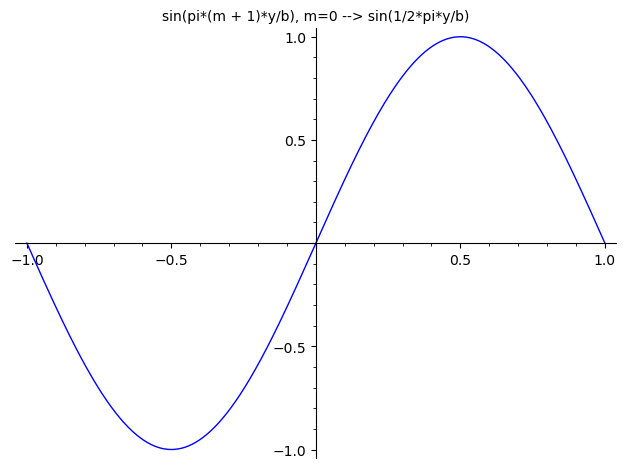

In [11]:

ky_TM_cos = (1+2*m)*pi/(2*b)
ky_TM_sin = (1+m)*pi/(b)
TM_Ez_cos = cos(ky_TM_cos*y)
TM_Ez_sin = sin(ky_TM_sin*y)
if is_TM:
    b_val = 1
    for m_val in [m_d]:
        if not is_cos_y_TM:
            plot(TM_Ez_cos.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
                title=f"cos({ky_TM_cos*y}), m={m_val} --> cos({ky_TM_cos.subs(m==m_val)*y})")
        else:
            plot(TM_Ez_sin.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
                title=f"sin({ky_TM_sin*y}), m={m_val} --> sin({ky_TM_cos.subs(m==m_val)*y})")

In [12]:
if is_TM or True:
    if is_cos_y_TM:
        phase_y_TM = TM_Ez_cos
        phase_y_TM = cos(ky_TM_cos*y)
        phase_y_TM = cos(k_y_E*y)
    else:
        phase_y_TM = TM_Ez_sin
        phase_y_TM = sin(ky_TM_sin*y)
        phase_y_TM = sin(k_y_E*y)
if is_TE or True:
    if is_cos_y_TE:
        phase_y_TE = TE_Hz_cos
        phase_y_TE = cos(ky_TE_cos*y)
        phase_y_TE = cos(k_y_H*y)
    else:
        phase_y_TE = TE_Hz_sin
        phase_y_TE = sin(ky_TE_sin*y)
        phase_y_TE = sin(k_y_H*y)

In [13]:
# отсутствие изменения поля вдоль оси y
# no field variation along the y axis
#k_re_im_subs = [k_z == kz + I * sz]
k_subs = [k_z == k_z_val]
if get_use_phase_y():
    if is_TM or True:
        if is_cos_y_TM:
            k_subs += [k_y_E == ky_TM_cos]
        else:
            k_subs += [k_y_E == ky_TM_sin]
    if is_TE or True:
        if is_cos_y_TE:
            k_subs += [k_y_H == ky_TE_cos]
        else:
            k_subs += [k_y_H == ky_TE_sin]
else:
    # старый режим рассчета когда поле не зависит от y
    k_subs += [k_y_E == 0]
    k_subs += [k_y_H == 0]
    phase_y_TE = 1
    phase_y_TM = 1
    # B = 1
k_subs

[k_z == pi/L_z, k_y_E == 1/2*pi*(2*m + 1)/b, k_y_H == 1/2*pi*(2*m + 1)/b]

In [14]:
# знак перед корнем корнем будем всегда выбирать так,
# чтобы корень имел положительнею мнимую часть
# (Зоммерфельд, Электродинамика, параграф 20, Б.
# Волновое поле и скин-эффект в полупространстве)
sign_K_E_l = var("sign_K_E_l")
sign_K_E_r = var("sign_K_E_r")
sign_K_H_l = var("sign_K_H_l")
sign_K_H_r = var("sign_K_H_r")

## Три конфигурации возбуждения

**1. TE, k_y = 0, накачка j_y** — текущая реализация. Дивергенция нулевая тривиально ($\partial_y j_y = 0$, других компонент нет).

**2. TM, накачка je_z** — вывод этапа 2, «штыревая» накачка электрическим током по скин поверхности левого проводника (алюминий, медь, серебро). 

**3. TE, накачка jm_z** - штыревая накачка магнитным током по скин поверхности правого проводника (феррита) для полуволнового резонатора

In [15]:
driving_mode_1 = 'je_y, k_y=0, TE'
driving_mode_2 = 'je_z, TM'
driving_mode_3 = 'jm_z, TE'
driving_mode = driving_mode_2

In [16]:
# --- Символьное представление j_ext ---
# j_ext_y_sym(x) — символьная функция, зависящая от x
# Её профиль задаём позже при подстановке числовых значений

je0_ext = var('je0_ext', domain='complex')            # амплитуда внешнего тока [СГС: с⁻¹]
jm0_ext = var('jm0_ext', domain='complex')            # амплитуда внешнего тока [СГС: с⁻¹]

je_ext_y_op = function('je_ext_y')                    # оператор функции внешнего тока
je_ext_z_op = function('je_ext_z')                    # оператор функции внешнего тока
jm_ext_z_op = function('jm_ext_z')                    # оператор функции внешнего тока

je_ext_y_sym = je_ext_y_op(x)                         # символьная функция от x внешнего тока
je_ext_z_sym = je_ext_z_op(x)                         # символьная функция от x внешнего тока
jm_ext_y_sym = jm_ext_z_op(x)                         # символьная функция от x внешнего тока

# Конкретный профиль (подставляется при численных расчётах):
# было:
# j_ext_y_profile(x) = j0_ext * exp(-I * K_left_conductor * (x + a))
# стало (источник несёт тот же y-профиль, что и поля -> mode-matched):

# if is_TE and not use_phase_y and driving_mode_1 == driving_mode:
je_ext_y_profile(x) = je0_ext * exp(-I * sign_K_H_l * K_H_left_conductor * (x + a)) * phase_y_TE

# if is_TM and use_phase_y and driving_mode_2 == driving_mode:
je_ext_z_profile(x) = je0_ext * exp(-I * sign_K_E_l * K_E_left_conductor * (x + a)) * phase_y_TM
    
# if is_TE and use_phase_y and driving_mode_3 == driving_mode:
jm_ext_z_profile(x) = jm0_ext * exp(-I * sign_K_H_r * K_H_right_conductor * (x + a)) * phase_y_TE

# т.е. тот же скин-профиль, что и у собственной моды

In [17]:
# толщина проводника
h_conductor_l = float(0.000375*A)
h_conductor_r = float(0.0125*A)

In [18]:
c_sgs_value       = [ c == c_d]
# c_sgns_value      = [ c == real128(299792458 * 100 * 1e-9)]
# omega_value       = [ omega  == omega_d ]
# omega_value       = [ omega  == ((real128(2*pi) * c)/ lambda_d).subs (c_sgns_value) ]
# kz_subs          = [k_z == k_z_val]
Lz_value          = [L_z == L_z_d]
digit_values_init = [a == real128(A),
                     k_y == 0,
                     mu_l_xx == mu_l_xx_d,
                     mu_l_yy == mu_l_yy_d,
                     mu_l_zz == mu_l_zz_d,

                     mu_r_xx == mu_r_xx_d,
                     mu_r_yy == mu_r_yy_d,
                     mu_r_zz == mu_r_zz_d,

                     mu_l_yz_c == mu_l_yz_d,
                     mu_l_zy_c == mu_l_zy_d,

                     mu_r_yz_c == mu_r_yz_d,
                     mu_r_zy_c == mu_r_zy_d,

                     sigma_e_l_xx == sigma_e_l_xx_d,
                     sigma_e_l_yy == sigma_e_l_yy_d,
                     sigma_e_l_zz == sigma_e_l_zz_d,

                     sigma_e_r_xx == sigma_e_r_xx_d, 
                     sigma_e_r_yy == sigma_e_r_yy_d, 
                     sigma_e_r_zz == sigma_e_r_zz_d, 

                     sigma_m_l_xx == sigma_m_l_xx_d,
                     sigma_m_l_yy == sigma_m_l_yy_d,
                     sigma_m_l_zz == sigma_m_l_zz_d,

                     sigma_m_r_xx == sigma_m_r_xx_d, 
                     sigma_m_r_yy == sigma_m_r_yy_d, 
                     sigma_m_r_zz == sigma_m_r_zz_d,

                     epsilon_l_xx == epsilon_l_xx_d,
                     epsilon_l_yy == epsilon_l_yy_d,
                     epsilon_l_zz == epsilon_l_zz_d,

                     epsilon_r_xx == epsilon_r_xx_d,
                     epsilon_r_yy == epsilon_r_yy_d,
                     epsilon_r_zz == epsilon_r_zz_d,
                     
                     h_l == h_conductor_l,
                     h_r == h_conductor_r,
                    ] + c_sgs_value

$$\kappa^2 = \epsilon \mu \frac{\omega^2}{c^2} + i\,\omega\,\sigma\,\mu\,\frac{4\pi}{c^2}$$

$$\kappa^2 = \mu \left(\epsilon  + i\,\frac{4\pi\,\sigma}{\omega} \right) \frac{\omega^2}{c^2}$$

In [19]:
# исходя из вида дифференциальных уравнений для вакуума внутри резонатора и проводящего металла с потерями
# записываем соотнощения для волнового вектора в виде уравнений
eq_kappa_inner_vacuum = kappa_vacuum^2 == omega^2 / c^2

print("eq_kappa_inner_vacuum =")
display(Math(latex(eq_kappa_inner_vacuum)))

eq_kappa_inner_vacuum =


<IPython.core.display.Math object>

принимая модель комплексного представления диэлектрической проницаемости $\epsilon' = \epsilon + \frac{4\pi\,\sigma}{\omega}\,i$ (плохой проводник)

In [20]:
# Тензор epsilon'
epsilon_l_c = matrix([
    [epsilon_l_xx_c,               0,              0],
    [             0,  epsilon_l_yy_c,              0],
    [             0,               0, epsilon_l_zz_c]
])

show(epsilon_l_c)

[epsilon_l_xx_c              0              0]
[             0 epsilon_l_yy_c              0]
[             0              0 epsilon_l_zz_c]

In [21]:
# Тензор epsilon'
epsilon_r_c = matrix([
    [epsilon_r_xx_c,               0,              0],
    [             0,  epsilon_r_yy_c,              0],
    [             0,               0, epsilon_r_zz_c]
])

show(epsilon_r_c)

[epsilon_r_xx_c              0              0]
[             0 epsilon_r_yy_c              0]
[             0              0 epsilon_r_zz_c]

In [22]:
mu_l_c = matrix([
    [mu_l_xx_c,   0,               0        ],
    [0,           mu_l_yy_c,       0        ],
    [0,           0,               mu_l_zz_c],
])
show(mu_l_c)

[mu_l_xx_c         0         0]
[        0 mu_l_yy_c         0]
[        0         0 mu_l_zz_c]

In [23]:
mu_r_c = matrix([
    [mu_r_xx_c,   0,               0        ],
    [0,           mu_r_yy_c,       0        ],
    [0,           0,               mu_r_zz_c],
])
show(mu_r_c)

[mu_r_xx_c         0         0]
[        0 mu_r_yy_c         0]
[        0         0 mu_r_zz_c]

In [24]:
epsilon_l_xx_complex = epsilon_l_xx + I * 4 * pi * sigma_e_l_xx / omega
epsilon_l_yy_complex = epsilon_l_yy + I * 4 * pi * sigma_e_l_yy / omega
epsilon_l_zz_complex = epsilon_l_zz + I * 4 * pi * sigma_e_l_zz / omega

epsilon_r_xx_complex = epsilon_r_xx + I * 4 * pi * sigma_e_r_xx / omega
epsilon_r_yy_complex = epsilon_r_yy + I * 4 * pi * sigma_e_r_yy / omega
epsilon_r_zz_complex = epsilon_r_zz + I * 4 * pi * sigma_e_r_zz / omega

In [25]:
epsilon_mu_subs = [epsilon_l_zz_c == epsilon_l_zz_complex,
                   epsilon_l_yy_c == epsilon_l_yy_complex,
                   epsilon_l_xx_c == epsilon_l_xx_complex,
                   epsilon_r_zz_c == epsilon_r_zz_complex,
                   epsilon_r_yy_c == epsilon_r_yy_complex,
                   epsilon_r_xx_c == epsilon_r_xx_complex,
                  ]

принимая модель комплексного представления магнитной проницаемости $\mu' = \mu + \frac{4\pi\,\sigma_m}{\omega}\,i$ (магнитный проводник)

In [26]:
mu_l_xx_complex = mu_l_xx + I * 4 * pi * sigma_m_l_xx / omega
mu_l_yy_complex = mu_l_yy + I * 4 * pi * sigma_m_l_yy / omega
mu_l_zz_complex = mu_l_zz + I * 4 * pi * sigma_m_l_zz / omega

mu_r_xx_complex = mu_r_xx + I * 4 * pi * sigma_m_r_xx / omega
mu_r_yy_complex = mu_r_yy + I * 4 * pi * sigma_m_r_yy / omega
mu_r_zz_complex = mu_r_zz + I * 4 * pi * sigma_m_r_zz / omega

In [27]:
epsilon_mu_subs += [
    mu_l_zz_c == mu_l_zz_complex,
    mu_l_yy_c == mu_l_yy_complex,
    mu_l_xx_c == mu_l_xx_complex,
    mu_r_zz_c == mu_r_zz_complex,
    mu_r_yy_c == mu_r_yy_complex,
    mu_r_xx_c == mu_r_xx_complex,
]

$${k'_z}^2=\left(k_z + i\,s_z \right)^2 = k_z^2 - s_z^2 + 2\,i\,k_z\,s_z$$

зависимость поля от $y$ отсутствует

In [28]:
B_E_zl = var ('B_E_zl')
B_H_zl = var ('B_H_zl')

B_E_zr = var ('B_E_zr')
B_H_zr = var ('B_H_zr')

A1_E_z = var ('A1_E_z')
A2_E_z = var ('A2_E_z')
A1_H_z = var ('A1_H_z')
A2_H_z = var ('A2_H_z')

A1_E_z_re = var("A1_E_z_re")
A1_E_z_im = var("A1_E_z_im")
A1_H_z_re = var("A1_H_z_re")
A1_H_z_im = var("A1_H_z_im")

A2_E_z_re = var("A2_E_z_re")
A2_E_z_im = var("A2_E_z_im")
A2_H_z_re = var("A2_H_z_re")
A2_H_z_im = var("A2_H_z_im")

B_E_zl_re = var("B_E_zl_re")
B_E_zl_im = var("B_E_zl_im")
B_H_zl_re = var("B_H_zl_re")
B_H_zl_im = var("B_H_zl_im")

B_E_zr_re = var("B_E_zr_re")
B_E_zr_im = var("B_E_zr_im")
B_H_zr_re = var("B_H_zr_re")
B_H_zr_im = var("B_H_zr_im")

assume(A1_E_z, "complex")
assume(A1_H_z, "complex")

assume(A1_E_z_re, "real")
assume(A1_E_z_im, "real")
assume(A1_H_z_re, "real")
assume(A1_H_z_im, "real")

assume(A2_E_z, "complex")
assume(A2_H_z, "complex")

assume(A2_E_z_re, "real")
assume(A2_E_z_im, "real")
assume(A2_H_z_re, "real")
assume(A2_H_z_im, "real")

assume(B_E_zl, "complex")
assume(B_H_zl, "complex")

assume(B_E_zl_re, "real")
assume(B_E_zl_im, "real")
assume(B_H_zl_re, "real")
assume(B_H_zl_im, "real")

assume(B_E_zr, "complex")
assume(B_H_zr, "complex")

assume(B_E_zr_re, "real")
assume(B_E_zr_im, "real")
assume(B_H_zr_re, "real")
assume(B_H_zr_im, "real")

In [29]:
# отсутствие изменения поля вдоль оси y
# no field variation along the y axis
# k_re_im_subs = [k_z == kz + I * sz, k_y == 0]

# k_subs = [k_z == k_z_val, k_y_E == 0, k_y_H == 0]
omega_qnm_subs = [omega == omega_re + I * omega_im]
omega_drive_subs = [omega == omega_re]

In [30]:
E_inner_vacuum_f_z = function("E_inner_vacuum_f_z")
E_left_conductor_f_z = function("E_left_conductor_f_z")
E_right_conductor_f_z = function("E_right_conductor_f_z")

E_inner_vacuum_f_x = function("E_inner_vacuum_f_x")
E_left_conductor_f_x = function("E_left_conductor_f_x")
E_right_conductor_f_x = function("E_right_conductor_f_x")

E_inner_vacuum_f_y = function("E_inner_vacuum_f_y")
E_left_conductor_f_y = function("E_left_conductor_f_y")
E_right_conductor_f_y = function("E_right_conductor_f_y")

E_inner_vacuum_fxy_x = function("E_inner_vacuum_fxy_x")(x,y)
E_left_conductor_fxy_x = function("E_left_conductor_fxy_x")(x,y)
E_right_conductor_fxy_x = function("E_right_conductor_fxy_x")(x,y)

E_inner_vacuum_fxy_y = function("E_inner_vacuum_fxy_y")(x,y)
E_left_conductor_fxy_y = function("E_left_conductor_fxy_y")(x,y)
E_right_conductor_fxy_y = function("E_right_conductor_fxy_y")(x,y)

In [31]:
H_inner_vacuum_f_x    = function("H_inner_vacuum_f_x")
H_left_conductor_f_x  = function("H_left_conductor_f_x")
H_right_conductor_f_x = function("H_right_conductor_f_x")

H_inner_vacuum_f_y    = function("H_inner_vacuum_f_y")
H_left_conductor_f_y  = function("H_left_conductor_f_y")
H_right_conductor_f_y = function("H_right_conductor_f_y")

H_inner_vacuum_f_z      = function("H_inner_vacuum_f_z")
H_left_conductor_f_z    = function("H_left_conductor_f_z")
H_right_conductor_f_z   = function("H_right_conductor_f_z")

H_inner_vacuum_fxy_x    = function("H_inner_vacuum_fxy_x")(x,y)
H_left_conductor_fxy_x  = function("H_left_conductor_fxy_x")(x,y)
H_right_conductor_fxy_x = function("H_right_conductor_fxy_x")(x,y)

H_inner_vacuum_fxy_y    = function("H_inner_vacuum_fxy_y")(x,y)
H_left_conductor_fxy_y  = function("H_left_conductor_fxy_y")(x,y)
H_right_conductor_fxy_y = function("H_right_conductor_fxy_y")(x,y)


#if is_TE:
H_inner_vacuum_fxy_z    = H_inner_vacuum_f_z(x) * phase_y_TE
H_left_conductor_fxy_z  = H_left_conductor_f_z(x) * phase_y_TE
H_right_conductor_fxy_z = H_right_conductor_f_z(x) * phase_y_TE

#if is_TM:
E_inner_vacuum_fxy_z    = E_inner_vacuum_f_z(x) * phase_y_TM
E_left_conductor_fxy_z  = E_left_conductor_f_z(x) * phase_y_TM
E_right_conductor_fxy_z = E_right_conductor_f_z(x) * phase_y_TM

In [32]:
# выражения для электрического поля
# в вакууме внутри резонатора

# знак перед корнем (K_vacuum) будем выбирать всегда так
# чтобы корень имел положительную мнимую часть

if is_TM:
    E_inner_vacuum_sol_z (x) = (A1_E_z*exp(- I * K_E_vacuum*x) + A2_E_z*exp( I * K_E_vacuum*x)) # * phase_y_TM

    if is_4x4:
        H_inner_vacuum_sol_z (x) = 0

    print ("E_inner_vacuum_sol_z (x) ")
    display(Math(latex(E_inner_vacuum_sol_z (x))))
    
if is_TE:
    H_inner_vacuum_sol_z (x) = (A1_H_z*exp(- I * K_H_vacuum*x) + A2_H_z*exp( I * K_H_vacuum*x)) # * phase_y_TE

    if is_4x4:
        E_inner_vacuum_sol_z (x) = 0

    print ("H_inner_vacuum_sol_z (x) ")
    display(Math(latex(H_inner_vacuum_sol_z (x))))

E_inner_vacuum_sol_z (x) 


<IPython.core.display.Math object>

решение для проводящего металла с потерями

для TМ волны

$\vec{E} = \vec{E}\,e^{i\,k_x'\,x}\,e^{i\,k_z\,z}\,e^{-i\,\omega\,t}$

$k_x' = k_x + i\,s_x$

$\vec{E} = \vec{E}\,e^{-s_x\,x}\,e^{i\,k_x\,x}\,e^{i\,k_z\,z}\,e^{-i\,\omega\,t}$


для TE волны

$\vec{H} = \vec{H}\,e^{i\,k_x'\,x}\,e^{i\,k_z\,z}\,e^{-i\,\omega\,t}$

$k_x' = k_x + i\,s_x$

$\vec{H} = \vec{H}\,e^{-s_x\,x}\,e^{i\,k_x\,x}\,e^{i\,k_z\,z}\,e^{-i\,\omega\,t}$


In [33]:
# x > a-{k'_x}^{2}-{k'_y}^{2} +
# в проводящем металле с потерями

# знак перед корнем будем выбирать всегда так
# чтобы корень имел положительную мнимую часть

if is_TM:
    E_left_conductor_sol_z (x) = (B_E_zl*exp(-I * sign_K_E_l * K_E_left_conductor*(x+a))) # * phase_y_TM

    if is_4x4:
        H_left_conductor_sol_z (x) = 0

    print ("E_left_conductor_sol_z (x) ")
    display(Math(latex(E_left_conductor_sol_z (x))))

if is_TE:
    H_left_conductor_sol_z (x) = (B_H_zl*exp(-I * sign_K_H_l * K_H_left_conductor*(x+a))) # * phase_y_TE

    if is_4x4:
        E_left_conductor_sol_z (x) = 0

    print ("H_left_conductor_sol_z (x) ")
    display(Math(latex(H_left_conductor_sol_z (x))))

E_left_conductor_sol_z (x) 


<IPython.core.display.Math object>

In [34]:
# x > a-{k'_x}^{2}-{k'_y}^{2} +
# в проводящем металле с потерями

# знак перед корнем будем выбирать всегда так
# чтобы корень имел положительную мнимую часть

if is_TM:
    E_right_conductor_sol_z (x) = (B_E_zr*exp(+I * sign_K_E_r * K_E_right_conductor*(x-a))) # * phase_y_TM

    if is_4x4:
        H_right_conductor_sol_z (x) = 0

    print ("E_right_conductor_sol_z (x) ")
    display(Math(latex(E_right_conductor_sol_z (x))))

if is_TE:
    H_right_conductor_sol_z (x) = (B_H_zr*exp(+I * sign_K_H_r * K_H_right_conductor*(x-a))) # * phase_y_TE

    if is_4x4:
        E_right_conductor_sol_z (x) = 0

    print ("H_right_conductor_sol_z (x) ")
    display(Math(latex(H_right_conductor_sol_z (x))))

E_right_conductor_sol_z (x) 


<IPython.core.display.Math object>

In [35]:
# выражения для магнитного поля в вакууме внутри резонатора и в проводящем металле с потерями
# rot E = -1/c dB/dt
# rot_E_x = diff(E_z, y) - diff(E_y, z)
# rot_E_y = diff(E_x, z) - diff(E_z, x)
# rot_E_z = diff(E_y, x) - diff(E_x, y)

# rot_E_x = diff(E_z, y) - diff(E_y, z)
if get_use_phase_y():
    rot_E_inner_vacuum_x    = diff(E_inner_vacuum_fxy_z, y)    - I*k_z*E_inner_vacuum_fxy_y
    rot_E_left_conductor_x  = diff(E_left_conductor_fxy_z, y)  - I*k_z*E_left_conductor_fxy_y
    rot_E_right_conductor_x = diff(E_right_conductor_fxy_z, y) - I*k_z*E_right_conductor_fxy_y
else:
    rot_E_inner_vacuum_x    = I*k_y_E*E_inner_vacuum_f_z(x)    - I*k_z*E_inner_vacuum_f_y(x)
    rot_E_left_conductor_x  = I*k_y_E*E_left_conductor_f_z(x)  - I*k_z*E_left_conductor_f_y(x)
    rot_E_right_conductor_x = I*k_y_E*E_right_conductor_f_z(x) - I*k_z*E_right_conductor_f_y(x)

# rot_E_y = diff(E_x, z) - diff(E_z, x)
if get_use_phase_y():
    rot_E_inner_vacuum_y    = I*k_z*E_inner_vacuum_fxy_x  - diff(E_inner_vacuum_fxy_z, x)
    rot_E_left_conductor_y  = I*k_z*E_left_conductor_fxy_x - diff(E_left_conductor_fxy_z, x)
    rot_E_right_conductor_y = I*k_z*E_right_conductor_fxy_x - diff(E_right_conductor_fxy_z, x)
else:
    rot_E_inner_vacuum_y    = I*k_z*E_inner_vacuum_f_x(x)  - diff(E_inner_vacuum_f_z(x), x)
    rot_E_left_conductor_y  = I*k_z*E_left_conductor_f_x(x) - diff(E_left_conductor_f_z(x), x)
    rot_E_right_conductor_y = I*k_z*E_right_conductor_f_x(x) - diff(E_right_conductor_f_z(x), x)

# rot_E_z = diff(E_y, x) - diff(E_x, y)
if get_use_phase_y():
    rot_E_inner_vacuum_z    = diff(E_inner_vacuum_fxy_y , x)   - diff(E_inner_vacuum_fxy_x, y)
    rot_E_left_conductor_z  = diff(E_left_conductor_fxy_y, x)  - diff(E_left_conductor_fxy_x, y)
    rot_E_right_conductor_z = diff(E_right_conductor_fxy_y, x) - diff(E_right_conductor_fxy_x, y)
else:
    rot_E_inner_vacuum_z    = diff(E_inner_vacuum_f_y(x) , x)   - I*k_y_E*E_inner_vacuum_f_x(x)
    rot_E_left_conductor_z  = diff(E_left_conductor_f_y(x), x)  - I*k_y_E*E_left_conductor_f_x(x)
    rot_E_right_conductor_z = diff(E_right_conductor_f_y(x), x) - I*k_y_E*E_right_conductor_f_x(x)

displ("rot\\_E\\_left\\_conductor\\_x =" + latex(rot_E_left_conductor_x))
displ("rot\\_E\\_left\\_conductor\\_y =" + latex(rot_E_left_conductor_y))
displ("rot\\_E\\_left\\_conductor\\_z =" + latex(rot_E_left_conductor_z))

displ("rot\\_E\\_inner\\_vacuum\\_x =" + latex(rot_E_inner_vacuum_x))
displ("rot\\_E\\_inner\\_vacuum\\_y =" + latex(rot_E_inner_vacuum_y))
displ("rot\\_E\\_inner\\_vacuum\\_z =" + latex(rot_E_inner_vacuum_z))

displ("rot\\_E\\_right\\_conductor\\_x =" + latex(rot_E_right_conductor_x))
displ("rot\\_E\\_right\\_conductor\\_y =" + latex(rot_E_right_conductor_y))
displ("rot\\_E\\_right\\_conductor\\_z =" + latex(rot_E_right_conductor_z))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [36]:
if get_use_phase_y():
    H_l = matrix([[H_left_conductor_fxy_x],
                  [H_left_conductor_fxy_y],
                  [H_left_conductor_fxy_z]])
else:
    H_l = matrix([[H_left_conductor_f_x(x)],
                  [H_left_conductor_f_y(x)],
                  [H_left_conductor_f_z(x)]])

show(H_l)
if get_use_phase_y():
    H_r = matrix([[H_right_conductor_fxy_x],
                  [H_right_conductor_fxy_y],
                  [H_right_conductor_fxy_z]])
else:
    H_r = matrix([[H_right_conductor_f_x(x)],
                  [H_right_conductor_f_y(x)],
                  [H_right_conductor_f_z(x)]])
    
show(H_r)

[        H_left_conductor_fxy_x(x, y)]
[        H_left_conductor_fxy_y(x, y)]
[H_left_conductor_f_z(x)*sin(k_y_H*y)]

[        H_right_conductor_fxy_x(x, y)]
[        H_right_conductor_fxy_y(x, y)]
[H_right_conductor_f_z(x)*sin(k_y_H*y)]

In [37]:
B_l = mu_l_c * H_l
show(B_l)
B_r = mu_r_c * H_r
show(B_r)

[        mu_l_xx_c*H_left_conductor_fxy_x(x, y)]
[        mu_l_yy_c*H_left_conductor_fxy_y(x, y)]
[mu_l_zz_c*H_left_conductor_f_z(x)*sin(k_y_H*y)]

[        mu_r_xx_c*H_right_conductor_fxy_x(x, y)]
[        mu_r_yy_c*H_right_conductor_fxy_y(x, y)]
[mu_r_zz_c*H_right_conductor_f_z(x)*sin(k_y_H*y)]

In [38]:
eq_rot_E_left_conductor_x = rot_E_left_conductor_x == (I*omega/c*B_l[0])[0]
eq_rot_E_left_conductor_y = rot_E_left_conductor_y == (I*omega/c*B_l[1])[0]
eq_rot_E_left_conductor_z = rot_E_left_conductor_z == (I*omega/c*B_l[2])[0]

In [39]:
eq_rot_E_left_conductor = [
    eq_rot_E_left_conductor_x,
    eq_rot_E_left_conductor_y,
    eq_rot_E_left_conductor_z,
]

show(eq_rot_E_left_conductor[0])
show(eq_rot_E_left_conductor[1])
show(eq_rot_E_left_conductor[2])

-k_y_E*E_left_conductor_f_z(x)*sin(k_y_E*y) - I*k_z*E_left_conductor_fxy_y(x, y) == I*mu_l_xx_c*omega*H_left_conductor_fxy_x(x, y)/c

I*k_z*E_left_conductor_fxy_x(x, y) - cos(k_y_E*y)*diff(E_left_conductor_f_z(x), x) == I*mu_l_yy_c*omega*H_left_conductor_fxy_y(x, y)/c

-diff(E_left_conductor_fxy_x(x, y), y) + diff(E_left_conductor_fxy_y(x, y), x) == I*mu_l_zz_c*omega*H_left_conductor_f_z(x)*sin(k_y_H*y)/c

In [40]:
eq_rot_E_right_conductor_x = rot_E_right_conductor_x == (I*omega/c*B_r[0])[0]
eq_rot_E_right_conductor_y = rot_E_right_conductor_y == (I*omega/c*B_r[1])[0]
if is_TE and get_use_phase_y() and driving_mode_3 == driving_mode:
    eq_rot_E_right_conductor_z = rot_E_right_conductor_z == (I*omega/c*B_r[2])[0] \
                                                          - 4*pi/c * jm_ext_z_sym
else:
    eq_rot_E_right_conductor_z = rot_E_right_conductor_z == (I*omega/c*B_r[2])[0]

In [41]:
eq_rot_E_right_conductor = [
    eq_rot_E_right_conductor_x,
    eq_rot_E_right_conductor_y,
    eq_rot_E_right_conductor_z,
]

show(eq_rot_E_right_conductor[0])
show(eq_rot_E_right_conductor[1])
show(eq_rot_E_right_conductor[2])

-k_y_E*E_right_conductor_f_z(x)*sin(k_y_E*y) - I*k_z*E_right_conductor_fxy_y(x, y) == I*mu_r_xx_c*omega*H_right_conductor_fxy_x(x, y)/c

I*k_z*E_right_conductor_fxy_x(x, y) - cos(k_y_E*y)*diff(E_right_conductor_f_z(x), x) == I*mu_r_yy_c*omega*H_right_conductor_fxy_y(x, y)/c

-diff(E_right_conductor_fxy_x(x, y), y) + diff(E_right_conductor_fxy_y(x, y), x) == I*mu_r_zz_c*omega*H_right_conductor_f_z(x)*sin(k_y_H*y)/c

In [42]:
if get_use_phase_y():
    eq_rot_E_inner_vacuum_x = rot_E_inner_vacuum_x == I*omega/c*H_inner_vacuum_fxy_x
    eq_rot_E_inner_vacuum_y = rot_E_inner_vacuum_y == I*omega/c*H_inner_vacuum_fxy_y
    eq_rot_E_inner_vacuum_z = rot_E_inner_vacuum_z == I*omega/c*H_inner_vacuum_fxy_z
else:
    eq_rot_E_inner_vacuum_x = rot_E_inner_vacuum_x == I*omega/c*H_inner_vacuum_f_x(x)
    eq_rot_E_inner_vacuum_y = rot_E_inner_vacuum_y == I*omega/c*H_inner_vacuum_f_y(x)
    eq_rot_E_inner_vacuum_z = rot_E_inner_vacuum_z == I*omega/c*H_inner_vacuum_f_z(x)

eq_rot_E_inner_vacuum = [
    eq_rot_E_inner_vacuum_x,
    eq_rot_E_inner_vacuum_y,
    eq_rot_E_inner_vacuum_z,
]
for eq in eq_rot_E_inner_vacuum:
    show(eq)

-k_y_E*E_inner_vacuum_f_z(x)*sin(k_y_E*y) - I*k_z*E_inner_vacuum_fxy_y(x, y) == I*omega*H_inner_vacuum_fxy_x(x, y)/c

I*k_z*E_inner_vacuum_fxy_x(x, y) - cos(k_y_E*y)*diff(E_inner_vacuum_f_z(x), x) == I*omega*H_inner_vacuum_fxy_y(x, y)/c

-diff(E_inner_vacuum_fxy_x(x, y), y) + diff(E_inner_vacuum_fxy_y(x, y), x) == I*omega*H_inner_vacuum_f_z(x)*sin(k_y_H*y)/c

In [43]:
# уравнение Максвелла для тока смещения
# rot_H   = - I * epsilon * omega / c * E
# rot_H_x = diff(H_z, y) - diff(H_y, z)
# rot_H_y = diff(H_x, z) - diff(H_z, x)
# rot_H_z = diff(H_y, x) - diff(H_x, y)

# rot_H_x = diff(H_z, y) - diff(H_y, z)
if get_use_phase_y():
    rot_H_inner_vacuum_x    = diff(H_inner_vacuum_fxy_z, y)    - I*k_z*H_inner_vacuum_fxy_y
    rot_H_left_conductor_x  = diff(H_left_conductor_fxy_z, y)  - I*k_z*H_left_conductor_fxy_y
    rot_H_right_conductor_x = diff(H_right_conductor_fxy_z, y) - I*k_z*H_right_conductor_fxy_y
else:
    rot_H_inner_vacuum_x    = I*k_y_H*H_inner_vacuum_f_z(x)    - I*k_z*H_inner_vacuum_f_y(x)
    rot_H_left_conductor_x  = I*k_y_H*H_left_conductor_f_z(x)  - I*k_z*H_left_conductor_f_y(x)
    rot_H_right_conductor_x = I*k_y_H*H_right_conductor_f_z(x) - I*k_z*H_right_conductor_f_y(x)

# rot_H_y = diff(H_x, z) - diff(H_z, x)
if get_use_phase_y():
    rot_H_inner_vacuum_y    = I*k_z*H_inner_vacuum_fxy_x    - diff(H_inner_vacuum_fxy_z, x)
    rot_H_left_conductor_y  = I*k_z*H_left_conductor_fxy_x  - diff(H_left_conductor_fxy_z, x)
    rot_H_right_conductor_y = I*k_z*H_right_conductor_fxy_x - diff(H_right_conductor_fxy_z, x)
else:
    rot_H_inner_vacuum_y    = I*k_z*H_inner_vacuum_f_x(x)    - diff(H_inner_vacuum_f_z(x), x)
    rot_H_left_conductor_y  = I*k_z*H_left_conductor_f_x(x)  - diff(H_left_conductor_f_z(x), x)
    rot_H_right_conductor_y = I*k_z*H_right_conductor_f_x(x) - diff(H_right_conductor_f_z(x), x)

# rot_H_z = diff(H_y, x) - diff(H_x, y)
if get_use_phase_y():
    rot_H_inner_vacuum_z    = diff(H_inner_vacuum_fxy_y , x)   - diff(H_inner_vacuum_fxy_x, y)
    rot_H_left_conductor_z  = diff(H_left_conductor_fxy_y, x)  - diff(H_left_conductor_fxy_x, y)
    rot_H_right_conductor_z = diff(H_right_conductor_fxy_y, x) - diff(H_right_conductor_fxy_x, y)
else:
    rot_H_inner_vacuum_z    = diff(H_inner_vacuum_f_y(x) , x)   - I*k_y_H*H_inner_vacuum_f_x(x)
    rot_H_left_conductor_z  = diff(H_left_conductor_f_y(x), x)  - I*k_y_H*H_left_conductor_f_x(x)
    rot_H_right_conductor_z = diff(H_right_conductor_f_y(x), x) - I*k_y_H*H_right_conductor_f_x(x)

displ("rot\\_H\\_left\\_conductor\\_x =" + latex(rot_H_left_conductor_x))
displ("rot\\_H\\_left\\_conductor\\_y =" + latex(rot_H_left_conductor_y))
displ("rot\\_H\\_left\\_conductor\\_z =" + latex(rot_H_left_conductor_z))

displ("rot\\_H\\_inner\\_vacuum\\_x =" + latex(rot_H_inner_vacuum_x))
displ("rot\\_H\\_inner\\_vacuum\\_y =" + latex(rot_H_inner_vacuum_y))
displ("rot\\_H\\_inner\\_vacuum\\_z =" + latex(rot_H_inner_vacuum_z))

displ("rot\\_H\\_right\\_conductor\\_x =" + latex(rot_H_right_conductor_x))
displ("rot\\_H\\_right\\_conductor\\_y =" + latex(rot_H_right_conductor_y))
displ("rot\\_H\\_right\\_conductor\\_z =" + latex(rot_H_right_conductor_z))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [44]:
H_inner_vacuum_fxy = [
    H_inner_vacuum_fxy_x,
    H_inner_vacuum_fxy_y,
    H_inner_vacuum_fxy_z,
]

H_left_conductor_fxy = [
    H_left_conductor_fxy_x,
    H_left_conductor_fxy_y,
    H_left_conductor_fxy_z,
]

H_right_conductor_fxy = [
    H_right_conductor_fxy_x,
    H_right_conductor_fxy_y,
    H_right_conductor_fxy_z,
]

H_inner_vacuum_fxy, H_left_conductor_fxy, H_right_conductor_fxy

([H_inner_vacuum_fxy_x(x, y),
  H_inner_vacuum_fxy_y(x, y),
  H_inner_vacuum_f_z(x)*sin(k_y_H*y)],
 [H_left_conductor_fxy_x(x, y),
  H_left_conductor_fxy_y(x, y),
  H_left_conductor_f_z(x)*sin(k_y_H*y)],
 [H_right_conductor_fxy_x(x, y),
  H_right_conductor_fxy_y(x, y),
  H_right_conductor_f_z(x)*sin(k_y_H*y)])

In [45]:
H_inner_vacuum_f = [
    H_inner_vacuum_f_x,
    H_inner_vacuum_f_y,
    H_inner_vacuum_f_z,
]

H_left_conductor_f = [
    H_left_conductor_f_x,
    H_left_conductor_f_y,
    H_left_conductor_f_z,
]

H_right_conductor_f = [
    H_right_conductor_f_x,
    H_right_conductor_f_y,
    H_right_conductor_f_z,
]

H_inner_vacuum_f, H_left_conductor_f, H_right_conductor_f

([H_inner_vacuum_f_x, H_inner_vacuum_f_y, H_inner_vacuum_f_z],
 [H_left_conductor_f_x, H_left_conductor_f_y, H_left_conductor_f_z],
 [H_right_conductor_f_x, H_right_conductor_f_y, H_right_conductor_f_z])

In [46]:
E_inner_vacuum_fxy = [
    E_inner_vacuum_fxy_x,
    E_inner_vacuum_fxy_y,
    E_inner_vacuum_fxy_z,
]

E_left_conductor_fxy = [
    E_left_conductor_fxy_x,
    E_left_conductor_fxy_y,
    E_left_conductor_fxy_z,
]

E_right_conductor_fxy = [
    E_right_conductor_fxy_x,
    E_right_conductor_fxy_y,
    E_right_conductor_fxy_z,
]

E_inner_vacuum_fxy, E_left_conductor_fxy, E_right_conductor_fxy

([E_inner_vacuum_fxy_x(x, y),
  E_inner_vacuum_fxy_y(x, y),
  E_inner_vacuum_f_z(x)*cos(k_y_E*y)],
 [E_left_conductor_fxy_x(x, y),
  E_left_conductor_fxy_y(x, y),
  E_left_conductor_f_z(x)*cos(k_y_E*y)],
 [E_right_conductor_fxy_x(x, y),
  E_right_conductor_fxy_y(x, y),
  E_right_conductor_f_z(x)*cos(k_y_E*y)])

In [47]:
E_inner_vacuum_f = [
    E_inner_vacuum_f_x,
    E_inner_vacuum_f_y,
    E_inner_vacuum_f_z,
]

E_left_conductor_f = [
    E_left_conductor_f_x,
    E_left_conductor_f_y,
    E_left_conductor_f_z,
]

E_right_conductor_f = [
    E_right_conductor_f_x,
    E_right_conductor_f_y,
    E_right_conductor_f_z,
]

E_inner_vacuum_f, E_left_conductor_f, E_right_conductor_f

([E_inner_vacuum_f_x, E_inner_vacuum_f_y, E_inner_vacuum_f_z],
 [E_left_conductor_f_x, E_left_conductor_f_y, E_left_conductor_f_z],
 [E_right_conductor_f_x, E_right_conductor_f_y, E_right_conductor_f_z])

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec E}{\partial t} = - \frac{i\,\omega}{c} \vec{E}$$

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec D}{\partial t} + \frac{4\pi}{c} \vec j = - \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E$$

принимая модель комплексного представления диэлектрической проницаемости $\epsilon' = \epsilon + \frac{4\pi\,\sigma}{\omega}\,i$ (плохой проводник)

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec D}{\partial t} + \frac{4\pi}{c} \vec j = - \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E  = - \frac{i\,\omega}{c} \epsilon' \vec{E}$$

In [48]:
if get_use_phase_y():
    E_l = matrix([[E_left_conductor_fxy_x],
                  [E_left_conductor_fxy_y],
                  [E_left_conductor_fxy_z]])
else:
    E_l = matrix([[E_left_conductor_f_x(x)],
                  [E_left_conductor_f_y(x)],
                  [E_left_conductor_f_z(x)]])

show(E_l)
if get_use_phase_y():
    E_r = matrix([[E_right_conductor_fxy_x],
                  [E_right_conductor_fxy_y],
                  [E_right_conductor_fxy_z]])
else:
    E_r = matrix([[E_right_conductor_f_x(x)],
                  [E_right_conductor_f_y(x)],
                  [E_right_conductor_f_z(x)]])

show(E_r)

[        E_left_conductor_fxy_x(x, y)]
[        E_left_conductor_fxy_y(x, y)]
[E_left_conductor_f_z(x)*cos(k_y_E*y)]

[        E_right_conductor_fxy_x(x, y)]
[        E_right_conductor_fxy_y(x, y)]
[E_right_conductor_f_z(x)*cos(k_y_E*y)]

In [49]:
D_l = epsilon_l_c * E_l
show(D_l)
D_r = epsilon_r_c * E_r
show(D_r)

[        epsilon_l_xx_c*E_left_conductor_fxy_x(x, y)]
[        epsilon_l_yy_c*E_left_conductor_fxy_y(x, y)]
[epsilon_l_zz_c*E_left_conductor_f_z(x)*cos(k_y_E*y)]

[        epsilon_r_xx_c*E_right_conductor_fxy_x(x, y)]
[        epsilon_r_yy_c*E_right_conductor_fxy_y(x, y)]
[epsilon_r_zz_c*E_right_conductor_f_z(x)*cos(k_y_E*y)]

In [50]:
if get_use_phase_y():
    eq_rot_H_inner_vacuum_x  = rot_H_inner_vacuum_x  == -I*omega/c*E_inner_vacuum_fxy_x
    eq_rot_H_inner_vacuum_y  = rot_H_inner_vacuum_y  == -I*omega/c*E_inner_vacuum_fxy_y
    eq_rot_H_inner_vacuum_z  = rot_H_inner_vacuum_z  == -I*omega/c*E_inner_vacuum_fxy_z
else:
    eq_rot_H_inner_vacuum_x  = rot_H_inner_vacuum_x  == -I*omega/c*E_inner_vacuum_f_x(x)
    eq_rot_H_inner_vacuum_y  = rot_H_inner_vacuum_y  == -I*omega/c*E_inner_vacuum_f_y(x)
    eq_rot_H_inner_vacuum_z  = rot_H_inner_vacuum_z  == -I*omega/c*E_inner_vacuum_f_z(x)

eq_rot_H_inner_vacuum = [
    eq_rot_H_inner_vacuum_x,
    eq_rot_H_inner_vacuum_y,
    eq_rot_H_inner_vacuum_z,
]
for eq in eq_rot_H_inner_vacuum:
    show(eq)

k_y_H*H_inner_vacuum_f_z(x)*cos(k_y_H*y) - I*k_z*H_inner_vacuum_fxy_y(x, y) == -I*omega*E_inner_vacuum_fxy_x(x, y)/c

I*k_z*H_inner_vacuum_fxy_x(x, y) - sin(k_y_H*y)*diff(H_inner_vacuum_f_z(x), x) == -I*omega*E_inner_vacuum_fxy_y(x, y)/c

-diff(H_inner_vacuum_fxy_x(x, y), y) + diff(H_inner_vacuum_fxy_y(x, y), x) == -I*omega*E_inner_vacuum_f_z(x)*cos(k_y_E*y)/c

## дуальность уравнений Максвелла

с магнитным током:

$$\mathrm{rot}\,\vec H = -\frac{i\omega}{c}\epsilon'\vec E + \frac{4\pi}{c}\vec j_e, \qquad
\mathrm{rot}\,\vec E = \frac{i\omega}{c}\mu'\vec H - \frac{4\pi}{c}\vec j_m$$

Подстановка дуальности $\vec E\to\vec H,\ \vec H\to-\vec E,\ \epsilon'\leftrightarrow\mu',\ \vec j_e\to\vec j_m$ переводит первое уравнение во второе. Значит весь вывод этапа 2 переносится заменой:

| TM (je_z, левый, электрический) | TE (jm_z, правый, магнитный) |
|---|---|
| входит в $\mathrm{rot}\,H_z$ | входит в $\mathrm{rot}\,E_z$ |
| $\epsilon'_{xx}, K_E$ | $\mu'_{xx}, K_H$ |
| ансатц $(x+a)$, `sign_K_E_l` | ансатц $(x-a)$, `sign_K_H_r` |
| знак источника $+$ | знак источника $-$ (из-за $-4\pi/c\,j_m$) |
| граница-получатель: `eq_Hy_l` | граница-получатель: `eq_Ey_r` |

In [51]:
# --- Модифицированное уравнение ротора H для левого металла (TE) ---
# Было:
#   eq_rot_H_left_conductor_y = rot_H_left_conductor_y == -(I*omega/c * D_l[1])[0]
# Стало (добавляем 4*pi/c * j_ext_y/z в правую часть):

eq_rot_H_left_conductor_x = rot_H_left_conductor_x == -(I*omega/c*D_l[0])[0]

# Для TE-моды j_ext направлен вдоль y (та же компонента, что E_y):
# j_ext_y ≠ 0, j_ext_x = j_ext_z = 0

if is_TE and not get_use_phase_y() and driving_mode_1 == driving_mode:
    eq_rot_H_left_conductor_y = rot_H_left_conductor_y == -(I*omega/c*D_l[1])[0] \
                                                             + 4*pi/c * je_ext_y_sym
else:
    eq_rot_H_left_conductor_y = rot_H_left_conductor_y == -(I*omega/c*D_l[1])[0]

if is_TM and get_use_phase_y() and driving_mode_2 == driving_mode:
    eq_rot_H_left_conductor_z = rot_H_left_conductor_z == -(I*omega/c*D_l[2])[0] \
                                                             + 4*pi/c * je_ext_z_sym
else:
    eq_rot_H_left_conductor_z = rot_H_left_conductor_z == -(I*omega/c*D_l[2])[0]


eq_rot_H_left_conductor = [
    eq_rot_H_left_conductor_x,
    eq_rot_H_left_conductor_y,
    eq_rot_H_left_conductor_z,
]

print("eq_rot_H_left_conductor_y_ext:")
show(eq_rot_H_left_conductor_y)
print("eq_rot_H_left_conductor_z_ext:")
show(eq_rot_H_left_conductor_z)

eq_rot_H_left_conductor_y_ext:


I*k_z*H_left_conductor_fxy_x(x, y) - sin(k_y_H*y)*diff(H_left_conductor_f_z(x), x) == -I*epsilon_l_yy_c*omega*E_left_conductor_fxy_y(x, y)/c

eq_rot_H_left_conductor_z_ext:


-diff(H_left_conductor_fxy_x(x, y), y) + diff(H_left_conductor_fxy_y(x, y), x) == -I*epsilon_l_zz_c*omega*E_left_conductor_f_z(x)*cos(k_y_E*y)/c + 4*pi*je_ext_z(x)/c

In [52]:
eq_rot_H_right_conductor_x = rot_H_right_conductor_x == -(I*omega/c*D_r[0])[0]
eq_rot_H_right_conductor_y = rot_H_right_conductor_y == -(I*omega/c*D_r[1])[0]
eq_rot_H_right_conductor_z = rot_H_right_conductor_z == -(I*omega/c*D_r[2])[0]

In [53]:
eq_rot_H_right_conductor = [
    eq_rot_H_right_conductor_x,
    eq_rot_H_right_conductor_y,
    eq_rot_H_right_conductor_z,
]
for eq in eq_rot_H_right_conductor:
    show(eq)

k_y_H*H_right_conductor_f_z(x)*cos(k_y_H*y) - I*k_z*H_right_conductor_fxy_y(x, y) == -I*epsilon_r_xx_c*omega*E_right_conductor_fxy_x(x, y)/c

I*k_z*H_right_conductor_fxy_x(x, y) - sin(k_y_H*y)*diff(H_right_conductor_f_z(x), x) == -I*epsilon_r_yy_c*omega*E_right_conductor_fxy_y(x, y)/c

-diff(H_right_conductor_fxy_x(x, y), y) + diff(H_right_conductor_fxy_y(x, y), x) == -I*epsilon_r_zz_c*omega*E_right_conductor_f_z(x)*cos(k_y_E*y)/c

In [54]:
if is_TM:
    # ТМ - волна
    if is_4x4:
        # H_z = 0
        H_inner_vacuum_sol_z   (x) = 0
        H_left_conductor_sol_z (x) = 0
        H_right_conductor_sol_z(x) = 0

if is_TE:
    # ТE - волна
    if is_4x4:
        # E_z = 0
        E_inner_vacuum_sol_z   (x) = 0
        E_left_conductor_sol_z (x) = 0
        E_right_conductor_sol_z(x) = 0
    
#         eq_rot_E_left_conductor_x = eq_rot_E_left_conductor_x.subs(E_left_conductor_f_z(x) == 0)
#         eq_rot_E_right_conductor_x = eq_rot_E_right_conductor_x.subs(E_right_conductor_f_z(x) == 0)

#         eq_rot_H_left_conductor_y = eq_rot_H_left_conductor_y.subs(E_left_conductor_f_z(x) == 0)
#         eq_rot_H_right_conductor_y = eq_rot_H_right_conductor_y.subs(E_right_conductor_f_z(x) == 0)

#         eq_rot_H_left_conductor_z = eq_rot_H_left_conductor_z.subs(E_left_conductor_f_z(x) == 0)
#         eq_rot_H_right_conductor_z = eq_rot_H_right_conductor_z.subs(E_right_conductor_f_z(x) == 0)

In [55]:
def get_field(eq_rot_E, eq_rot_H, eq_rot_E_index, eq_rot_H_index, field_for_exclude, field_for_solve):
    # Группируем уравнения в пары,
    # удобные для исключения переменных поля в левой части
    excluding_1 = solve(eq_rot_E[eq_rot_E_index], field_for_exclude)
    excluding_2 = solve(eq_rot_H[eq_rot_H_index], field_for_exclude)
    if len(excluding_1) > 0 and len(excluding_2):
        # Получаем выражение для поперечных
        # (по отношению к оси волновода z)
        # компонент поля через продольные
        return (solve(
            excluding_1[0].rhs() == \
            excluding_2[0].rhs(),
        field_for_solve))[0]
    else:
        print("eq_rot_E[eq_rot_E_index]")
        show(eq_rot_E[eq_rot_E_index])
        print("eq_rot_H[eq_rot_H_index]")
        show(eq_rot_H[eq_rot_H_index])
        print("field_for_exclude")
        show(field_for_exclude)
        print("field_for_solve")
        show(field_for_solve)

In [56]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = H_left_conductor_fxy[0]
    field_for_solve   = E_left_conductor_fxy[1]
else:
    field_for_exclude = H_left_conductor_f[0](x)
    field_for_solve   = E_left_conductor_f[1](x)

E_left_conductor_sb_y = get_field(eq_rot_E_left_conductor, eq_rot_H_left_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_left_conductor_sb_y)

E_left_conductor_fxy_y(x, y) == (I*c^2*k_y_E*k_z*E_left_conductor_f_z(x)*sin(k_y_E*y) + I*c*mu_l_xx_c*omega*sin(k_y_H*y)*diff(H_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

In [57]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = H_right_conductor_fxy[0]
    field_for_solve   = E_right_conductor_fxy[1]
else:
    field_for_exclude = H_right_conductor_f[0](x)
    field_for_solve   = E_right_conductor_f[1](x)

E_right_conductor_sb_y = get_field(eq_rot_E_right_conductor, eq_rot_H_right_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_right_conductor_sb_y)

E_right_conductor_fxy_y(x, y) == (I*c^2*k_y_E*k_z*E_right_conductor_f_z(x)*sin(k_y_E*y) + I*c*mu_r_xx_c*omega*sin(k_y_H*y)*diff(H_right_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [58]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = E_left_conductor_fxy[1]
    field_for_solve   = H_left_conductor_fxy[0]
else:
    field_for_exclude = E_left_conductor_f[1](x)
    field_for_solve   = H_left_conductor_f[0](x)

H_left_conductor_sb_x = get_field(eq_rot_E_left_conductor, eq_rot_H_left_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_left_conductor_sb_x)

H_left_conductor_fxy_x(x, y) == -(I*c*epsilon_l_yy_c*k_y_E*omega*E_left_conductor_f_z(x)*sin(k_y_E*y) + I*c^2*k_z*sin(k_y_H*y)*diff(H_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

In [59]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = E_right_conductor_fxy[1]
    field_for_solve   = H_right_conductor_fxy[0]
else:
    field_for_exclude = E_right_conductor_f[1](x)
    field_for_solve   = H_right_conductor_f[0](x)

H_right_conductor_sb_x = get_field(eq_rot_E_right_conductor, eq_rot_H_right_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_right_conductor_sb_x)

H_right_conductor_fxy_x(x, y) == -(I*c*epsilon_r_yy_c*k_y_E*omega*E_right_conductor_f_z(x)*sin(k_y_E*y) + I*c^2*k_z*sin(k_y_H*y)*diff(H_right_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [60]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = H_left_conductor_fxy[1]
    field_for_solve   = E_left_conductor_fxy[0]
else:
    field_for_exclude = H_left_conductor_f[1](x)
    field_for_solve   = E_left_conductor_f[0](x)

E_left_conductor_sb_x = get_field(eq_rot_E_left_conductor, eq_rot_H_left_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_left_conductor_sb_x)

E_left_conductor_fxy_x(x, y) == -(I*c*k_y_H*mu_l_yy_c*omega*H_left_conductor_f_z(x)*cos(k_y_H*y) + I*c^2*k_z*cos(k_y_E*y)*diff(E_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

In [61]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = H_right_conductor_fxy[1]
    field_for_solve   = E_right_conductor_fxy[0]
else:
    field_for_exclude = H_right_conductor_f[1](x)
    field_for_solve   = E_right_conductor_f[0](x)

E_right_conductor_sb_x = get_field(eq_rot_E_right_conductor, eq_rot_H_right_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_right_conductor_sb_x)

E_right_conductor_fxy_x(x, y) == -(I*c*k_y_H*mu_r_yy_c*omega*H_right_conductor_f_z(x)*cos(k_y_H*y) + I*c^2*k_z*cos(k_y_E*y)*diff(E_right_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

In [62]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = E_left_conductor_fxy[0]
    field_for_solve   = H_left_conductor_fxy[1]
else:
    field_for_exclude = E_left_conductor_f[0](x)
    field_for_solve   = H_left_conductor_f[1](x)

H_left_conductor_sb_y = get_field(eq_rot_E_left_conductor, eq_rot_H_left_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_left_conductor_sb_y)

H_left_conductor_fxy_y(x, y) == -(I*c^2*k_y_H*k_z*H_left_conductor_f_z(x)*cos(k_y_H*y) + I*c*epsilon_l_xx_c*omega*cos(k_y_E*y)*diff(E_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

In [63]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = E_right_conductor_fxy[0]
    field_for_solve   = H_right_conductor_fxy[1]
else:
    field_for_exclude = E_right_conductor_f[0](x)
    field_for_solve   = H_right_conductor_f[1](x)

H_right_conductor_sb_y = get_field(eq_rot_E_right_conductor, eq_rot_H_right_conductor,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_right_conductor_sb_y)

H_right_conductor_fxy_y(x, y) == -(I*c^2*k_y_H*k_z*H_right_conductor_f_z(x)*cos(k_y_H*y) + I*c*epsilon_r_xx_c*omega*cos(k_y_E*y)*diff(E_right_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

In [64]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = H_inner_vacuum_fxy[0]
    field_for_solve   = E_inner_vacuum_fxy[1]
else:
    field_for_exclude = H_inner_vacuum_f[0](x)
    field_for_solve   = E_inner_vacuum_f[1](x)
    
E_inner_vacuum_sb_y = get_field(eq_rot_E_inner_vacuum, eq_rot_H_inner_vacuum,
                               eq_rot_E_index, eq_rot_H_index,
                               field_for_exclude, field_for_solve)
show(E_inner_vacuum_sb_y)

E_inner_vacuum_fxy_y(x, y) == (I*c^2*k_y_E*k_z*E_inner_vacuum_f_z(x)*sin(k_y_E*y) + I*c*omega*sin(k_y_H*y)*diff(H_inner_vacuum_f_z(x), x))/(c^2*k_z^2 - omega^2)

In [65]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = E_inner_vacuum_fxy[1]
    field_for_solve   = H_inner_vacuum_fxy[0]
else:
    field_for_exclude = E_inner_vacuum_f[1](x)
    field_for_solve   = H_inner_vacuum_f[0](x)

H_inner_vacuum_sb_x = get_field(eq_rot_E_inner_vacuum, eq_rot_H_inner_vacuum,
                               eq_rot_E_index, eq_rot_H_index,
                               field_for_exclude, field_for_solve)
show(H_inner_vacuum_sb_x)

H_inner_vacuum_fxy_x(x, y) == -(I*c*k_y_E*omega*E_inner_vacuum_f_z(x)*sin(k_y_E*y) + I*c^2*k_z*sin(k_y_H*y)*diff(H_inner_vacuum_f_z(x), x))/(c^2*k_z^2 - omega^2)

In [66]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = H_inner_vacuum_fxy[1]
    field_for_solve   = E_inner_vacuum_fxy[0]
else:
    field_for_exclude = H_inner_vacuum_f[1](x)
    field_for_solve   = E_inner_vacuum_f[0](x)

E_inner_vacuum_sb_x = get_field(eq_rot_E_inner_vacuum, eq_rot_H_inner_vacuum,
                               eq_rot_E_index, eq_rot_H_index,
                               field_for_exclude, field_for_solve)
show(E_inner_vacuum_sb_x)

E_inner_vacuum_fxy_x(x, y) == -(I*c*k_y_H*omega*H_inner_vacuum_f_z(x)*cos(k_y_H*y) + I*c^2*k_z*cos(k_y_E*y)*diff(E_inner_vacuum_f_z(x), x))/(c^2*k_z^2 - omega^2)

In [67]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
if get_use_phase_y():
    field_for_exclude = E_inner_vacuum_fxy[0]
    field_for_solve   = H_inner_vacuum_fxy[1]
else:
    field_for_exclude = E_inner_vacuum_f[0](x)
    field_for_solve   = H_inner_vacuum_f[1](x)

H_inner_vacuum_sb_y = get_field(eq_rot_E_inner_vacuum, eq_rot_H_inner_vacuum,
                               eq_rot_E_index, eq_rot_H_index,
                               field_for_exclude, field_for_solve)
show(H_inner_vacuum_sb_y)

H_inner_vacuum_fxy_y(x, y) == -(I*c^2*k_y_H*k_z*H_inner_vacuum_f_z(x)*cos(k_y_H*y) + I*c*omega*cos(k_y_E*y)*diff(E_inner_vacuum_f_z(x), x))/(c^2*k_z^2 - omega^2)

In [68]:
# Получаем выражение для продольной (по отношению к оси волновода z) компоненте H_z поля
# исходя из выражения для ротора E

In [69]:
# Получаем выражение для продольной (по отношению к оси волновода z) компоненте E_z поля
# исходя из выражения для ротора H

In [70]:
H_inner_vacuum_sub_y (x, y) = H_inner_vacuum_sb_y.rhs() \
    .substitute_function(E_inner_vacuum_f_z,
                         E_inner_vacuum_sol_z) \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z).expand()
show(H_inner_vacuum_sub_y)

(x, y) |--> A2_E_z*K_E_vacuum*c*omega*cos(k_y_E*y)*e^(I*K_E_vacuum*x)/(c^2*k_z^2 - omega^2) - A1_E_z*K_E_vacuum*c*omega*cos(k_y_E*y)*e^(-I*K_E_vacuum*x)/(c^2*k_z^2 - omega^2)

In [71]:
H_left_conductor_sub_y (x, y) = H_left_conductor_sb_y.rhs() \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(je_ext_y_op,
                         je_ext_y_profile) \
    .substitute_function(je_ext_z_op,
                         je_ext_z_profile) \
    .expand()
show(H_left_conductor_sb_y)
show(H_left_conductor_sub_y)

H_left_conductor_fxy_y(x, y) == -(I*c^2*k_y_H*k_z*H_left_conductor_f_z(x)*cos(k_y_H*y) + I*c*epsilon_l_xx_c*omega*cos(k_y_E*y)*diff(E_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

(x, y) |--> -B_E_zl*K_E_left_conductor*c*epsilon_l_xx_c*omega*sign_K_E_l*cos(k_y_E*y)*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

In [72]:
H_right_conductor_sub_y (x, y) = H_right_conductor_sb_y.rhs() \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z).expand()
show(H_right_conductor_sb_y)
show(H_right_conductor_sub_y)

H_right_conductor_fxy_y(x, y) == -(I*c^2*k_y_H*k_z*H_right_conductor_f_z(x)*cos(k_y_H*y) + I*c*epsilon_r_xx_c*omega*cos(k_y_E*y)*diff(E_right_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

(x, y) |--> B_E_zr*K_E_right_conductor*c*epsilon_r_xx_c*omega*sign_K_E_r*cos(k_y_E*y)*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

In [73]:
H_inner_vacuum_sub_x (x, y) = H_inner_vacuum_sb_x.rhs() \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z) \
    .substitute_function(E_inner_vacuum_f_z,
                         E_inner_vacuum_sol_z) \
    .expand()
show(H_inner_vacuum_sb_x)
show(H_inner_vacuum_sub_x)

H_inner_vacuum_fxy_x(x, y) == -(I*c*k_y_E*omega*E_inner_vacuum_f_z(x)*sin(k_y_E*y) + I*c^2*k_z*sin(k_y_H*y)*diff(H_inner_vacuum_f_z(x), x))/(c^2*k_z^2 - omega^2)

(x, y) |--> -I*A2_E_z*c*k_y_E*omega*e^(I*K_E_vacuum*x)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2) - I*A1_E_z*c*k_y_E*omega*e^(-I*K_E_vacuum*x)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2)

In [74]:
H_left_conductor_sub_x (x, y) = H_left_conductor_sb_x.rhs() \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(je_ext_y_op,
                         je_ext_y_profile) \
    .substitute_function(je_ext_z_op,
                         je_ext_z_profile) \
    .expand()
show(H_left_conductor_sb_x)
show(H_left_conductor_sub_x)

H_left_conductor_fxy_x(x, y) == -(I*c*epsilon_l_yy_c*k_y_E*omega*E_left_conductor_f_z(x)*sin(k_y_E*y) + I*c^2*k_z*sin(k_y_H*y)*diff(H_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

(x, y) |--> -I*B_E_zl*c*epsilon_l_yy_c*k_y_E*omega*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

In [75]:
H_right_conductor_sub_x (x, y) = H_right_conductor_sb_x.rhs() \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z) \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .expand()
show(H_right_conductor_sb_x)
show(H_right_conductor_sub_x)

H_right_conductor_fxy_x(x, y) == -(I*c*epsilon_r_yy_c*k_y_E*omega*E_right_conductor_f_z(x)*sin(k_y_E*y) + I*c^2*k_z*sin(k_y_H*y)*diff(H_right_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

(x, y) |--> -I*B_E_zr*c*epsilon_r_yy_c*k_y_E*omega*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [76]:
E_inner_vacuum_sub_y (x, y) = E_inner_vacuum_sb_y.rhs() \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z) \
    .substitute_function(E_inner_vacuum_f_z,
                         E_inner_vacuum_sol_z) \
    .expand()
show(E_inner_vacuum_sb_y)
show(E_inner_vacuum_sub_y (x))

E_inner_vacuum_fxy_y(x, y) == (I*c^2*k_y_E*k_z*E_inner_vacuum_f_z(x)*sin(k_y_E*y) + I*c*omega*sin(k_y_H*y)*diff(H_inner_vacuum_f_z(x), x))/(c^2*k_z^2 - omega^2)

I*A2_E_z*c^2*k_y_E*k_z*e^(I*K_E_vacuum*x)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2) + I*A1_E_z*c^2*k_y_E*k_z*e^(-I*K_E_vacuum*x)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2)

In [77]:
E_left_conductor_sub_y (x, y) = E_left_conductor_sb_y.rhs() \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(je_ext_y_op,
                         je_ext_y_profile) \
    .substitute_function(je_ext_z_op,
                         je_ext_z_profile) \
    .expand()
show(E_left_conductor_sb_y)
show(E_left_conductor_sub_y (x))

E_left_conductor_fxy_y(x, y) == (I*c^2*k_y_E*k_z*E_left_conductor_f_z(x)*sin(k_y_E*y) + I*c*mu_l_xx_c*omega*sin(k_y_H*y)*diff(H_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

I*B_E_zl*c^2*k_y_E*k_z*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

In [78]:
E_right_conductor_sub_y (x, y) = E_right_conductor_sb_y.rhs() \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z) \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .expand()
show(E_right_conductor_sb_y)
show(E_right_conductor_sub_y (x))

E_right_conductor_fxy_y(x, y) == (I*c^2*k_y_E*k_z*E_right_conductor_f_z(x)*sin(k_y_E*y) + I*c*mu_r_xx_c*omega*sin(k_y_H*y)*diff(H_right_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

I*B_E_zr*c^2*k_y_E*k_z*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

In [79]:
E_inner_vacuum_sub_x (x, y) = E_inner_vacuum_sb_x.rhs() \
    .substitute_function(E_inner_vacuum_f_z,
                         E_inner_vacuum_sol_z) \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z).expand()
show(E_inner_vacuum_sb_x)
show(E_inner_vacuum_sub_x)

E_inner_vacuum_fxy_x(x, y) == -(I*c*k_y_H*omega*H_inner_vacuum_f_z(x)*cos(k_y_H*y) + I*c^2*k_z*cos(k_y_E*y)*diff(E_inner_vacuum_f_z(x), x))/(c^2*k_z^2 - omega^2)

(x, y) |--> A2_E_z*K_E_vacuum*c^2*k_z*cos(k_y_E*y)*e^(I*K_E_vacuum*x)/(c^2*k_z^2 - omega^2) - A1_E_z*K_E_vacuum*c^2*k_z*cos(k_y_E*y)*e^(-I*K_E_vacuum*x)/(c^2*k_z^2 - omega^2)

In [80]:
E_left_conductor_sub_x (x, y) = E_left_conductor_sb_x.rhs() \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(je_ext_y_op,
                         je_ext_y_profile) \
    .substitute_function(je_ext_z_op,
                         je_ext_z_profile) \
    .expand()
show(E_left_conductor_sb_x)
show(E_left_conductor_sub_x)

E_left_conductor_fxy_x(x, y) == -(I*c*k_y_H*mu_l_yy_c*omega*H_left_conductor_f_z(x)*cos(k_y_H*y) + I*c^2*k_z*cos(k_y_E*y)*diff(E_left_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

(x, y) |--> -B_E_zl*K_E_left_conductor*c^2*k_z*sign_K_E_l*cos(k_y_E*y)*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

In [81]:
E_right_conductor_sub_x (x, y) = E_right_conductor_sb_x.rhs() \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z).expand()
show(E_right_conductor_sb_x)
show(E_right_conductor_sub_x)

E_right_conductor_fxy_x(x, y) == -(I*c*k_y_H*mu_r_yy_c*omega*H_right_conductor_f_z(x)*cos(k_y_H*y) + I*c^2*k_z*cos(k_y_E*y)*diff(E_right_conductor_f_z(x), x))/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

(x, y) |--> B_E_zr*K_E_right_conductor*c^2*k_z*sign_K_E_r*cos(k_y_E*y)*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

$$\nabla \cdot \vec{B} = 0$$

$$\partial_x B_x + \partial_y B_y + \partial_z B_z = 0$$

$$
\hat{\mu}(\omega) = 
\begin{pmatrix}
\mu & i\kappa & 0 \\
-i\kappa & \mu & 0 \\
0 & 0 &  \mu_{||}
\end{pmatrix} =
\begin{pmatrix}
\mu_{11} & \mu_{12} & 0 \\
\mu_{21} & \mu_{22} & 0 \\
0 & 0 & \mu_{33}
\end{pmatrix}  =
\begin{pmatrix}
\mu_{xx} & \mu_{xy} & 0 \\
\mu_{yx} & \mu_{yy} & 0 \\
0 & 0 & \mu_{zz}
\end{pmatrix} 
$$


$$B'_x = \mu'_{xx} H_x + \mu'_{xy} H_y + \mu'_{xz} H_z$$
$$B'_y = \mu'_{yx} H_x + \mu'_{yy} H_y + \mu'_{yz} H_z$$
$$B'_x = \mu'_{zx} H_x + \mu'_{zy} H_y + \mu'_{zz} H_z$$

$$\nabla \cdot \vec{B}
= \frac{\partial}{\partial x}\left(\mu_{xx} H_x + \mu_{xy} H_y + \mu_{xz} H_z\right)
+ \frac{\partial}{\partial y}\left(\mu_{yx} H_x + \mu_{yy} H_y + \mu_{yz} H_z\right)
+ \frac{\partial}{\partial z}\left(\mu_{zx} H_x + \mu_{zy} H_y + \mu_{zz} H_z\right)
$$

In [82]:
H_inner_vacuum_sub_x(x,y)

-I*A2_E_z*c*k_y_E*omega*e^(I*K_E_vacuum*x)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2) - I*A1_E_z*c*k_y_E*omega*e^(-I*K_E_vacuum*x)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2)

In [83]:
Bx_vacuum = (H_inner_vacuum_sub_x(x,y))
By_vacuum = (H_inner_vacuum_sub_y(x,y))
Bz_vacuum = (H_inner_vacuum_sol_z(x) * phase_y_TE)

In [84]:
Dx_vacuum = (E_inner_vacuum_sub_x(x,y))
Dy_vacuum = (E_inner_vacuum_sub_y(x,y))
Dz_vacuum = (E_inner_vacuum_sol_z(x) * phase_y_TM)

In [85]:
if get_use_phase_y():
    Bx_left_conductor = B_l[0][0] \
        .substitute_function(H_left_conductor_fxy_x == H_left_conductor_sub_x)
    By_left_conductor = B_l[1][0] \
        .substitute_function(H_left_conductor_fxy_y == H_left_conductor_sub_y)
    Bz_left_conductor = B_l[2][0] \
        .substitute_function(H_left_conductor_f_z, H_left_conductor_sol_z)
else:
    Bx_left_conductor = B_l[0][0] \
        .substitute_function(H_left_conductor_f_x, H_left_conductor_sub_x)
    By_left_conductor = B_l[1][0] \
        .substitute_function(H_left_conductor_f_y, H_left_conductor_sub_y)
    Bz_left_conductor = B_l[2][0] \
        .substitute_function(H_left_conductor_f_z, H_left_conductor_sol_z)

show(Bx_left_conductor)
show(By_left_conductor)
show(Bz_left_conductor)

-I*B_E_zl*c*epsilon_l_yy_c*k_y_E*mu_l_xx_c*omega*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

-B_E_zl*K_E_left_conductor*c*epsilon_l_xx_c*mu_l_yy_c*omega*sign_K_E_l*cos(k_y_E*y)*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

0

In [86]:
B_l_sub = matrix([[Bx_left_conductor],
                  [By_left_conductor],
                  [Bz_left_conductor]])
show(B_l_sub)

[                      -I*B_E_zl*c*epsilon_l_yy_c*k_y_E*mu_l_xx_c*omega*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)]
[-B_E_zl*K_E_left_conductor*c*epsilon_l_xx_c*mu_l_yy_c*omega*sign_K_E_l*cos(k_y_E*y)*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)]
[                                                                                                                                                                                                            0]

In [87]:
if get_use_phase_y():
    Dx_left_conductor = D_l[0][0] \
        .substitute_function(E_left_conductor_fxy_x == E_left_conductor_sub_x)
    Dy_left_conductor = D_l[1][0] \
        .substitute_function(E_left_conductor_fxy_y == E_left_conductor_sub_y)
    Dz_left_conductor = D_l[2][0] \
        .substitute_function(E_left_conductor_f_z, E_left_conductor_sol_z)
else:
    Dx_left_conductor = D_l[0][0] \
        .substitute_function(E_left_conductor_f_x, E_left_conductor_sub_x)
    Dy_left_conductor = D_l[1][0] \
        .substitute_function(E_left_conductor_f_y, E_left_conductor_sub_y)
    Dz_left_conductor = D_l[2][0] \
        .substitute_function(E_left_conductor_f_z, E_left_conductor_sol_z)

show(Dx_left_conductor)
show(Dy_left_conductor)
show(Dz_left_conductor)

-B_E_zl*K_E_left_conductor*c^2*epsilon_l_xx_c*k_z*sign_K_E_l*cos(k_y_E*y)*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

I*B_E_zl*c^2*epsilon_l_yy_c*k_y_E*k_z*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

B_E_zl*epsilon_l_zz_c*cos(k_y_E*y)*e^(-I*K_E_left_conductor*(a + x)*sign_K_E_l)

In [88]:
D_l_sub = matrix([[Dx_left_conductor],
                  [Dy_left_conductor],
                  [Dz_left_conductor]])
show(D_l_sub)

[-B_E_zl*K_E_left_conductor*c^2*epsilon_l_xx_c*k_z*sign_K_E_l*cos(k_y_E*y)*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)]
[                       I*B_E_zl*c^2*epsilon_l_yy_c*k_y_E*k_z*e^(-I*K_E_left_conductor*a*sign_K_E_l - I*K_E_left_conductor*sign_K_E_l*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)]
[                                                                                                                    B_E_zl*epsilon_l_zz_c*cos(k_y_E*y)*e^(-I*K_E_left_conductor*(a + x)*sign_K_E_l)]

In [89]:
if get_use_phase_y():
    Bx_right_conductor = B_r[0][0] \
        .substitute_function(H_right_conductor_fxy_x == H_right_conductor_sub_x)
    By_right_conductor = B_r[1][0] \
        .substitute_function(H_right_conductor_fxy_y == H_right_conductor_sub_y)
    Bz_right_conductor = B_r[2][0] \
        .substitute_function(H_right_conductor_f_z, H_right_conductor_sol_z)
else:
    Bx_right_conductor = B_r[0][0] \
        .substitute_function(H_right_conductor_f_x, H_right_conductor_sub_x)
    By_right_conductor = B_r[1][0] \
        .substitute_function(H_right_conductor_f_y, H_right_conductor_sub_y)
    Bz_right_conductor = B_r[2][0] \
        .substitute_function(H_right_conductor_f_z, H_right_conductor_sol_z)

show(Bx_right_conductor)
show(By_right_conductor)
show(Bz_right_conductor)

-I*B_E_zr*c*epsilon_r_yy_c*k_y_E*mu_r_xx_c*omega*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

B_E_zr*K_E_right_conductor*c*epsilon_r_xx_c*mu_r_yy_c*omega*sign_K_E_r*cos(k_y_E*y)*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

0

In [90]:
B_r_sub = matrix([[Bx_right_conductor],
                  [By_right_conductor],
                  [Bz_right_conductor]])
show(B_r_sub)

[                      -I*B_E_zr*c*epsilon_r_yy_c*k_y_E*mu_r_xx_c*omega*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)]
[B_E_zr*K_E_right_conductor*c*epsilon_r_xx_c*mu_r_yy_c*omega*sign_K_E_r*cos(k_y_E*y)*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)]
[                                                                                                                                                                                                              0]

In [91]:
if get_use_phase_y():
    Dx_right_conductor = D_r[0][0] \
        .substitute_function(E_right_conductor_fxy_x == E_right_conductor_sub_x)
    Dy_right_conductor = D_r[1][0] \
        .substitute_function(E_right_conductor_fxy_y == E_right_conductor_sub_y)
    Dz_right_conductor = D_r[2][0] \
        .substitute_function(E_right_conductor_f_z, E_right_conductor_sol_z)
else:
    Dx_right_conductor = D_r[0][0] \
        .substitute_function(E_right_conductor_f_x, E_right_conductor_sub_x)
    Dy_right_conductor = D_r[1][0] \
        .substitute_function(E_right_conductor_f_y, E_right_conductor_sub_y)
    Dz_right_conductor = D_r[2][0] \
        .substitute_function(E_right_conductor_f_z, E_right_conductor_sol_z)

show(Dx_right_conductor)
show(Dy_right_conductor)
show(Dz_right_conductor)

B_E_zr*K_E_right_conductor*c^2*epsilon_r_xx_c*k_z*sign_K_E_r*cos(k_y_E*y)*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

I*B_E_zr*c^2*epsilon_r_yy_c*k_y_E*k_z*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

B_E_zr*epsilon_r_zz_c*cos(k_y_E*y)*e^(-I*K_E_right_conductor*(a - x)*sign_K_E_r)

In [92]:
D_r_sub = matrix([[Dx_right_conductor],
                  [Dy_right_conductor],
                  [Dz_right_conductor]])
show(D_r_sub)

[B_E_zr*K_E_right_conductor*c^2*epsilon_r_xx_c*k_z*sign_K_E_r*cos(k_y_E*y)*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)]
[                       I*B_E_zr*c^2*epsilon_r_yy_c*k_y_E*k_z*e^(-I*K_E_right_conductor*a*sign_K_E_r + I*K_E_right_conductor*sign_K_E_r*x)*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)]
[                                                                                                                     B_E_zr*epsilon_r_zz_c*cos(k_y_E*y)*e^(-I*K_E_right_conductor*(a - x)*sign_K_E_r)]

In [93]:
div_B_inner_vacuum =(diff(Bx_vacuum*e^(I*k_z*z), x) \
                   + diff(By_vacuum*e^(I*k_z*z), y) \
                   + diff(Bz_vacuum*e^(I*k_z*z), z))

In [94]:
div_D_inner_vacuum =(diff(Dx_vacuum*e^(I*k_z*z), x) \
                   + diff(Dy_vacuum*e^(I*k_z*z), y) \
                   + diff(Dz_vacuum*e^(I*k_z*z), z))

In [95]:
div_B_left_conductor =(diff(B_l[0]*e^(I*k_z*z), x) \
                     + diff(B_l[1]*e^(I*k_z*z), y) \
                     + diff(B_l[2]*e^(I*k_z*z), z)).subs(epsilon_mu_subs)

In [96]:
div_D_left_conductor =(diff(D_l[0]*e^(I*k_z*z), x) \
                     + diff(D_l[1]*e^(I*k_z*z), y) \
                     + diff(D_l[2]*e^(I*k_z*z), z)).subs(epsilon_mu_subs)

In [97]:
div_B_right_conductor  =(diff(B_r[0]*e^(I*k_z*z), x) \
                       + diff(B_r[1]*e^(I*k_z*z), y) \
                       + diff(B_r[2]*e^(I*k_z*z), z)).subs(epsilon_mu_subs)

In [98]:
div_D_right_conductor  =(diff(D_r[0]*e^(I*k_z*z), x) \
                       + diff(D_r[1]*e^(I*k_z*z), y) \
                       + diff(D_r[2]*e^(I*k_z*z), z)).subs(epsilon_mu_subs)

In [99]:
displ("\\nabla \\cdot \\vec{B}_{vac} =" + latex(div_B_inner_vacuum))

<IPython.core.display.Math object>

In [100]:
displ("\\nabla \\cdot \\vec{D}_{vac} =" + latex(div_D_inner_vacuum))

<IPython.core.display.Math object>

In [101]:
displ("\\nabla \\cdot \\vec{B'}_l =" + latex(div_B_left_conductor))

<IPython.core.display.Math object>

In [102]:
displ("\\nabla \\cdot \\vec{D'}_l =" + latex(div_D_left_conductor))

<IPython.core.display.Math object>

In [103]:
displ("\\nabla \\cdot \\vec{B'}_r =" + latex(div_B_right_conductor))

<IPython.core.display.Math object>

In [104]:
displ("\\nabla \\cdot \\vec{D'}_r =" + latex(div_D_right_conductor))

<IPython.core.display.Math object>

In [105]:
div_B_inner_vacuum_subs = div_B_inner_vacuum \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z) \
    .substitute_function(H_inner_vacuum_fxy_y == H_inner_vacuum_sub_y) \
    .substitute_function(H_inner_vacuum_fxy_x == H_inner_vacuum_sub_x)
displ("\\nabla \\cdot \\vec{B}_{vac} =" + latex(div_B_inner_vacuum_subs))

<IPython.core.display.Math object>

In [106]:
div_B_left_conductor_subs = div_B_left_conductor[0] \
    .substitute_function(H_left_conductor_f_z,
                         H_left_conductor_sol_z) \
    .substitute_function(H_left_conductor_fxy_y == H_left_conductor_sub_y) \
    .substitute_function(H_left_conductor_fxy_x == H_left_conductor_sub_x) \
    .substitute_function(H_left_conductor_f_y, H_left_conductor_sub_y) \
    .substitute_function(H_left_conductor_f_x, H_left_conductor_sub_x) \
    .substitute_function(je_ext_y_op,
                         je_ext_y_profile) \
    .substitute_function(je_ext_z_op,
                         je_ext_z_profile)

displ("\\nabla \\cdot \\vec{B} =" + latex(div_B_left_conductor_subs))

<IPython.core.display.Math object>

In [107]:
div_B_right_conductor_subs = div_B_right_conductor[0] \
    .substitute_function(H_right_conductor_f_z,
                         H_right_conductor_sol_z) \
    .substitute_function(H_right_conductor_fxy_y == H_right_conductor_sub_y) \
    .substitute_function(H_right_conductor_fxy_x == H_right_conductor_sub_x) \
    .substitute_function(H_right_conductor_f_y, H_right_conductor_sub_y) \
    .substitute_function(H_right_conductor_f_x, H_right_conductor_sub_x)
displ("\\nabla \\cdot \\vec{B'}_r =" + latex(div_B_right_conductor_subs))

<IPython.core.display.Math object>

In [108]:
div_D_inner_vacuum_subs = div_D_inner_vacuum \
    .substitute_function(H_inner_vacuum_f_z,
                         H_inner_vacuum_sol_z) \
    .substitute_function(H_inner_vacuum_f_y,
                         H_inner_vacuum_sub_y) \
    .substitute_function(H_inner_vacuum_f_x,
                         H_inner_vacuum_sub_x)
displ("\\nabla \\cdot \\vec{D}_{vac} =" + latex(div_D_inner_vacuum_subs))

<IPython.core.display.Math object>

In [109]:
div_D_left_conductor_subs = div_D_left_conductor[0] \
    .substitute_function(E_left_conductor_f_z,
                         E_left_conductor_sol_z) \
    .substitute_function(E_left_conductor_fxy_y == E_left_conductor_sub_y) \
    .substitute_function(E_left_conductor_fxy_x == E_left_conductor_sub_x) \
    .substitute_function(E_left_conductor_f_y, E_left_conductor_sub_y) \
    .substitute_function(E_left_conductor_f_x, E_left_conductor_sub_x)
displ("\\nabla \\cdot \\vec{D} =" + latex(div_D_left_conductor_subs))

<IPython.core.display.Math object>

In [110]:
div_D_right_conductor_subs = div_D_right_conductor[0] \
    .substitute_function(E_right_conductor_f_z,
                         E_right_conductor_sol_z) \
    .substitute_function(E_right_conductor_fxy_y == E_right_conductor_sub_y) \
    .substitute_function(E_right_conductor_fxy_x == E_right_conductor_sub_x) \
    .substitute_function(E_right_conductor_f_y, E_right_conductor_sub_y) \
    .substitute_function(E_right_conductor_f_x, E_right_conductor_sub_x)
displ("\\nabla \\cdot \\vec{D'}_r =" + latex(div_D_right_conductor_subs))

<IPython.core.display.Math object>

In [111]:
# выражения для электрического поля
# в вакууме внутри резонатора 
#    E_inner_vacuum_z (x) = A1_z_re*cos(sqrt(kappa_vacuum^2-k_z^2)*x) + A1_z_im*sin(sqrt(kappa_vacuum^2-k_z^2)*x)
#    E_inner_vacuum_x (x) = A1_x_re*cos(sqrt(kappa_vacuum^2-k_z^2)*x) + A1_x_im*sin(sqrt(kappa_vacuum^2-k_z^2)*x)
#    E_inner_vacuum_y (x) = A1_y_re*cos(sqrt(kappa_vacuum^2-k_z^2)*x) + A1_y_im*sin(sqrt(kappa_vacuum^2-k_z^2)*x)

In [112]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля
eqEz_r = E_right_conductor_sol_z(a) == E_inner_vacuum_sol_z(a)
eq_Ey_r = E_right_conductor_sub_y(a) == E_inner_vacuum_sub_y(a)

print ("eqEz_r = ")
display(Math(latex(eqEz_r)))

print ("eq_Ey_r = ")
display(Math(latex(eq_Ey_r)))

eqEz_r = 


<IPython.core.display.Math object>

eq_Ey_r = 


<IPython.core.display.Math object>

In [113]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля
eqEz_l = E_left_conductor_sol_z(-a) == E_inner_vacuum_sol_z(-a)
eq_Ey_l = E_left_conductor_sub_y(-a) == E_inner_vacuum_sub_y(-a)

print ("eqEz_l = ")
display(Math(latex(eqEz_l)))

print ("eq_Ey_l = ")
display(Math(latex(eq_Ey_l)))

eqEz_l = 


<IPython.core.display.Math object>

eq_Ey_l = 


<IPython.core.display.Math object>

In [114]:
# нормальная компонента электрического смещения
# численно равна заряду, "накапливающемуся" на поверхности раздела двух сред,
# деленному на площадь этой поверхности.
# Это связано с тем, что электрическое смещение связано с полным зарядом
# (как свободным, так и связанным) в данной области

# это уравнение исключаем так как поверхностная плотность свободных зарядов нам не известна

eq_Dx_l = Dx_left_conductor(x=-a) == E_inner_vacuum_sub_x(-a)
eq_Dx_r = E_inner_vacuum_sub_x(a) == Dx_right_conductor(x=a)

displ("eq_Dx_l ="+latex(eq_Dx_l))
displ("eq_Dx_r ="+latex(eq_Dx_r))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [115]:
# тангенциальная компонента напряженности магнитного поля
eqHz_l  = (H_left_conductor_sol_z(-a) == H_inner_vacuum_sol_z(-a))
eq_Hy_l = (H_left_conductor_sub_y(-a) == H_inner_vacuum_sub_y(-a))

print ("eqHz_l =")
display(Math(latex(eqHz_l)))

print ("eq_Hy_l =")
display(Math(latex(eq_Hy_l)))

eqHz_l =


<IPython.core.display.Math object>

eq_Hy_l =


<IPython.core.display.Math object>

In [116]:
# тангенциальная компонента напряженности магнитного поля
eqHz_r  = (H_right_conductor_sol_z(a) == H_inner_vacuum_sol_z(a))
eq_Hy_r = (H_right_conductor_sub_y(a) == H_inner_vacuum_sub_y(a))

print ("eqHz_r =")
display(Math(latex(eqHz_r)))

print ("eq_Hy_r =")
display(Math(latex(eq_Hy_r)))

eqHz_r =


<IPython.core.display.Math object>

eq_Hy_r =


<IPython.core.display.Math object>

In [117]:
# нормальная компонента индукции магнитного поля
eq_Bx_l = Bx_left_conductor (x=-a) == H_inner_vacuum_sub_x (-a)

print ("eq_Bx_l =")
display(Math(latex(eq_Bx_l)))

eq_Bx_l =


<IPython.core.display.Math object>

In [118]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# нормальная компонента индукции магнитного поля
eq_Bx_r  = Bx_right_conductor(x=a)  == H_inner_vacuum_sub_x (a)
eq_Bx_r  = Bx_right_conductor(x=a)  == Bx_vacuum (x=a)

print ("eq_Bx_r =")
display(Math(latex(eq_Bx_r)))

eq_Bx_r =


<IPython.core.display.Math object>

Из первой и второй троек уравнений Максвелла, учитывая зависимость фазового множителя от координаты и времени получаем

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec E}{\partial t} = - \frac{i\,\omega}{c} \vec{E} = - i\,\kappa \vec{E}$$

$$rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}\,\vec{H}$$

In [119]:
K_E_v_s = sqrt(kappa_vacuum^2-k_z^2-k_y_E^2)
K_H_v_s = sqrt(kappa_vacuum^2-k_z^2-k_y_H^2)

In [120]:
K_E_vacuum_subs = K_E_vacuum == K_E_v_s
K_H_vacuum_subs = K_H_vacuum == K_H_v_s
K_vacuum_subs = [K_E_vacuum_subs, K_H_vacuum_subs]
show(K_vacuum_subs)

[K_E_vacuum == sqrt(-k_y_E^2 - k_z^2 + kappa_vacuum^2),
 K_H_vacuum == sqrt(-k_y_H^2 - k_z^2 + kappa_vacuum^2)]

В случае если $\mu'_{yy}=\mu'_{xx}$

$$K_{x, TM}^2 = \left(\frac{\omega^2}{c^2} {\mu'}_{yy} {\epsilon'}_{zz} - { {k'_z}^2} \frac{ \epsilon'_{zz}}{ {\epsilon'}_{xx} }\right)$$

$$K_{x,TM}^2 = \frac{ \mu'_{xx}\epsilon'_{zz} \frac{\omega^2}{c^2}}{\left(1 - \frac{k'_z}{\left({ {k'_z}} - \frac{\omega^2}{{k'_z}c^2} {\mu'}_{yy} {\epsilon'}_{xx} \right)} - \frac{\left(\mu'_{yy}-\mu'_{xx}\right)}{\left({\mu'}_{yy}  - \frac{{k'_z}^2 c^2}{\omega^2 {\epsilon'}_{xx}} \right)}\right)}$$

In [121]:
epsilon_xx, epsilon_yy, epsilon_zz = var('epsilon_xx epsilon_yy epsilon_zz', domain='complex')
mu_xx, mu_yy, mu_zz                = var('mu_xx mu_yy mu_zz', domain='complex')
# from MenDrive_wave_equation
K2_x_TE = -(c^2*k_y_H^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2) \
          * (c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) \
          /((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2*mu_xx)

K2_x_TM = -(c^2*epsilon_yy*k_y_E^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2) \
          * (c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) \
          /((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2*epsilon_xx)
show(K2_x_TE)
show(K2_x_TM)

-(c^2*k_y_H^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2)*(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)/((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2*mu_xx)

-(c^2*epsilon_yy*k_y_E^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2)*(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)/((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2*epsilon_xx)

In [122]:
K2_x_TE = -(k_y_H^2*mu_yy + mu_zz*(k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)) \
          * (k_z^2 - epsilon_yy*mu_xx*omega^2/c^2) \
          /((k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)*mu_xx)

K2_x_TM = -(epsilon_yy*k_y_E^2 + epsilon_zz*(k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)) \
          * (k_z^2 - epsilon_xx*mu_yy*omega^2/c^2) \
          /((k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)*epsilon_xx)
show(K2_x_TE)
show(K2_x_TM)

-(k_y_H^2*mu_yy + (k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)*mu_zz)*(k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)/((k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)*mu_xx)

-(epsilon_yy*k_y_E^2 + (k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)*epsilon_zz)*(k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)/((k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)*epsilon_xx)

In [123]:
# Правильная ячейка 128: K²_x = -(kᵧ²·μ/D + μ_zz) · D_y / μ_xx
K2_x_TE = -(k_y_H**2*mu_yy/(k_z**2 - epsilon_xx*mu_yy*omega**2/c**2) + mu_zz) \
          * (k_z**2 - epsilon_yy*mu_xx*omega**2/c**2) / mu_xx

K2_x_TM = -(epsilon_yy*k_y_E**2/(k_z**2 - epsilon_yy*mu_xx*omega**2/c**2) + epsilon_zz) \
          * (k_z**2 - epsilon_xx*mu_yy*omega**2/c**2) / epsilon_xx
show(K2_x_TE)
show(K2_x_TM)

-(k_z^2 - epsilon_yy*mu_xx*omega^2/c^2)*(k_y_H^2*mu_yy/(k_z^2 - epsilon_xx*mu_yy*omega^2/c^2) + mu_zz)/mu_xx

-(epsilon_yy*k_y_E^2/(k_z^2 - epsilon_yy*mu_xx*omega^2/c^2) + epsilon_zz)*(k_z^2 - epsilon_xx*mu_yy*omega^2/c^2)/epsilon_xx

In [124]:
K2_x_TE = K2_x_TE.subs(omega_qnm_subs)
K2_x_TM = K2_x_TM.subs(omega_qnm_subs)

In [125]:
show(K2_x_TE)
show(K2_x_TM)

-(k_z^2 - epsilon_yy*mu_xx*(I*omega_im + omega_re)^2/c^2)*(k_y_H^2*mu_yy/(k_z^2 - epsilon_xx*mu_yy*(I*omega_im + omega_re)^2/c^2) + mu_zz)/mu_xx

-(epsilon_yy*k_y_E^2/(k_z^2 - epsilon_yy*mu_xx*(I*omega_im + omega_re)^2/c^2) + epsilon_zz)*(k_z^2 - epsilon_xx*mu_yy*(I*omega_im + omega_re)^2/c^2)/epsilon_xx

In [126]:
K_E_l_s = sqrt(K2_x_TM).subs([
               epsilon_xx == epsilon_l_xx_c,
               epsilon_yy == epsilon_l_yy_c,
               epsilon_zz == epsilon_l_zz_c,
               mu_xx == mu_l_xx_c,
               mu_yy == mu_l_yy_c,
               mu_zz == mu_l_zz_c,
              ])

K_E_r_s = sqrt(K2_x_TM).subs([
               epsilon_xx == epsilon_r_xx_c,
               epsilon_yy == epsilon_r_yy_c,
               epsilon_zz == epsilon_r_zz_c,
               mu_xx == mu_r_xx_c,
               mu_yy == mu_r_yy_c,
               mu_zz == mu_r_zz_c,
              ])

K_H_l_s  = sqrt(K2_x_TE).subs([
               epsilon_xx == epsilon_l_xx_c,
               epsilon_yy == epsilon_l_yy_c,
               epsilon_zz == epsilon_l_zz_c,
               mu_xx == mu_l_xx_c,
               mu_yy == mu_l_yy_c,
               mu_zz == mu_l_zz_c,
              ])

K_H_r_s = sqrt(K2_x_TE).subs([
               epsilon_xx == epsilon_r_xx_c,
               epsilon_yy == epsilon_r_yy_c,
               epsilon_zz == epsilon_r_zz_c,
               mu_xx == mu_r_xx_c,
               mu_yy == mu_r_yy_c,
               mu_zz == mu_r_zz_c,
              ])

In [127]:
if is_TM:
    K_E_left_conductor_subs  = K_E_left_conductor  == K_E_l_s
    K_E_right_conductor_subs = K_E_right_conductor == K_E_r_s
    show(K_E_left_conductor_subs)
    show(K_E_right_conductor_subs)

if is_TE:
    K_H_left_conductor_subs  = K_H_left_conductor  == K_H_l_s
    K_H_right_conductor_subs = K_H_right_conductor == K_H_r_s
    show(K_H_left_conductor_subs)
    show(K_H_right_conductor_subs)

K_E_left_conductor == sqrt(-(epsilon_l_yy_c*k_y_E^2/(k_z^2 - epsilon_l_yy_c*mu_l_xx_c*(I*omega_im + omega_re)^2/c^2) + epsilon_l_zz_c)*(k_z^2 - epsilon_l_xx_c*mu_l_yy_c*(I*omega_im + omega_re)^2/c^2)/epsilon_l_xx_c)

K_E_right_conductor == sqrt(-(epsilon_r_yy_c*k_y_E^2/(k_z^2 - epsilon_r_yy_c*mu_r_xx_c*(I*omega_im + omega_re)^2/c^2) + epsilon_r_zz_c)*(k_z^2 - epsilon_r_xx_c*mu_r_yy_c*(I*omega_im + omega_re)^2/c^2)/epsilon_r_xx_c)

В случае если $\epsilon'_{yy}=\epsilon'_{xx}$

$$K_{x, TE}^2 = \left( \frac{\omega^2 }{c^2}{\epsilon'}_{xx} {\mu'}_{xx} - {k'_z}^2\frac{\epsilon'_{xx}}{{\epsilon'}_{yy}}\right)  \frac{  \left( \mu'_{zz} - 
\frac{\mu'_{zy}{\mu'}_{yz}}{\left({\mu'}_{yy} - \frac{c^2 {k'_z}^2 }{\omega^2 {\epsilon'}_{xx}} \right) } \right)}{{\mu'}_{xx}}$$

$$K_{x,TE}^2 = \frac{\frac{\omega^2}{c^2} \epsilon'_{xx} \left( \mu'_{zz} - 
\frac{\mu'_{zy}{\mu'}_{yz}}{\left({\mu'}_{yy}  - \frac{c^2 {k'_z}^2 }{\omega^2 {\epsilon'}_{xx}} \right) } \right)}{\left(1  - \frac{{k'_z}}{ {k'_z} - \left(\frac{\omega^2 }{{k'_z} c^2}{\epsilon'}_{yy} {\mu'}_{xx} \right)}- \frac{\left(\epsilon'_{yy}-\epsilon'_{xx}\right)}{\left({\epsilon'}_{yy} - \frac{{k'_z}^2 c^2}{\omega^2 {\mu'}_{xx}} \right)}\right)}$$

In [128]:
if is_TM:
    show(K_E_left_conductor_subs)

K_E_left_conductor == sqrt(-(epsilon_l_yy_c*k_y_E^2/(k_z^2 - epsilon_l_yy_c*mu_l_xx_c*(I*omega_im + omega_re)^2/c^2) + epsilon_l_zz_c)*(k_z^2 - epsilon_l_xx_c*mu_l_yy_c*(I*omega_im + omega_re)^2/c^2)/epsilon_l_xx_c)

In [129]:
if is_TE:
    show(K_H_left_conductor_subs)

In [130]:
if is_TM:
    show(K_E_right_conductor_subs)

K_E_right_conductor == sqrt(-(epsilon_r_yy_c*k_y_E^2/(k_z^2 - epsilon_r_yy_c*mu_r_xx_c*(I*omega_im + omega_re)^2/c^2) + epsilon_r_zz_c)*(k_z^2 - epsilon_r_xx_c*mu_r_yy_c*(I*omega_im + omega_re)^2/c^2)/epsilon_r_xx_c)

In [131]:
if is_TE:
    show(K_H_right_conductor_subs)

In [132]:
if is_TM:
    K_E_left_conductor_subs = K_E_left_conductor_subs.subs(epsilon_mu_subs)

In [133]:
if is_TE:
    K_H_left_conductor_subs = K_H_left_conductor_subs.subs(epsilon_mu_subs)

In [134]:
if is_TM:
    K_E_right_conductor_subs = K_E_right_conductor_subs.subs(epsilon_mu_subs)

In [135]:
if is_TE:
    K_H_right_conductor_subs = K_H_right_conductor_subs.subs(epsilon_mu_subs)

In [136]:
if is_TM:
    show(K_E_left_conductor_subs)

K_E_left_conductor == sqrt(-((epsilon_l_yy + 4*I*pi*sigma_e_l_yy/omega)*k_y_E^2/(k_z^2 - (epsilon_l_yy + 4*I*pi*sigma_e_l_yy/omega)*(mu_l_xx + 4*I*pi*sigma_m_l_xx/omega)*(I*omega_im + omega_re)^2/c^2) + epsilon_l_zz + 4*I*pi*sigma_e_l_zz/omega)*(k_z^2 - (epsilon_l_xx + 4*I*pi*sigma_e_l_xx/omega)*(mu_l_yy + 4*I*pi*sigma_m_l_yy/omega)*(I*omega_im + omega_re)^2/c^2)/(epsilon_l_xx + 4*I*pi*sigma_e_l_xx/omega))

In [137]:
if is_TE:
    show(K_H_left_conductor_subs)

In [138]:
if is_TM:
    show(K_E_right_conductor_subs)

K_E_right_conductor == sqrt(-((epsilon_r_yy + 4*I*pi*sigma_e_r_yy/omega)*k_y_E^2/(k_z^2 - (epsilon_r_yy + 4*I*pi*sigma_e_r_yy/omega)*(mu_r_xx + 4*I*pi*sigma_m_r_xx/omega)*(I*omega_im + omega_re)^2/c^2) + epsilon_r_zz + 4*I*pi*sigma_e_r_zz/omega)*(k_z^2 - (epsilon_r_xx + 4*I*pi*sigma_e_r_xx/omega)*(mu_r_yy + 4*I*pi*sigma_m_r_yy/omega)*(I*omega_im + omega_re)^2/c^2)/(epsilon_r_xx + 4*I*pi*sigma_e_r_xx/omega))

In [139]:
if is_TE:
    show(K_H_right_conductor_subs)

In [140]:
K_left_conductor_subs = []
if is_TM:
    K_left_conductor_subs += [K_E_left_conductor_subs]
if is_TE:
    K_left_conductor_subs += [K_H_left_conductor_subs]

In [141]:
K_right_conductor_subs = []
if is_TM:
    K_right_conductor_subs += [K_E_right_conductor_subs]
if is_TE:
    K_right_conductor_subs += [K_H_right_conductor_subs]

проверяем чему равен градиент дивергенции

$$\left(grad \, div\,\vec{E}\right)_x = \left(\frac{\partial^2 E_x(x, y)}{\partial x^2} +  i\,k'_z \frac{\partial E_z(x, y)}{\partial x}\right)$$

$$\left(grad \, div\,\vec{E}\right)_y = 0$$

$$\left(grad \, div\,\vec{E}\right)_z = \left(i \,k'_z\,\frac{\partial E_x(x, y)}{\partial x} -\,{k'_z}^2 E_z(x, y)\right)$$

In [142]:
grad_div_left_E_z \
    = I * k_z * E_left_conductor_sub_x(x).subs(K_left_conductor_subs).diff(x).expand() \
    - k_z^2   * E_left_conductor_sol_z(x).subs(K_left_conductor_subs).expand()
grad_div_left_E_z.variables()

(B_E_zl,
 a,
 c,
 epsilon_l_xx,
 epsilon_l_xx_c,
 epsilon_l_yy,
 epsilon_l_zz,
 k_y_E,
 k_z,
 mu_l_xx,
 mu_l_yy,
 mu_l_yy_c,
 omega,
 omega_im,
 omega_re,
 sigma_e_l_xx,
 sigma_e_l_yy,
 sigma_e_l_zz,
 sigma_m_l_xx,
 sigma_m_l_yy,
 sign_K_E_l,
 x,
 y)

In [143]:
grad_div_right_E_z \
    = I * k_z * E_right_conductor_sub_x(x).subs(K_right_conductor_subs).diff(x).expand() \
    - k_z^2   * E_right_conductor_sol_z(x).subs(K_right_conductor_subs).expand()
grad_div_right_E_z.variables()

(B_E_zr,
 a,
 c,
 epsilon_r_xx,
 epsilon_r_xx_c,
 epsilon_r_yy,
 epsilon_r_zz,
 k_y_E,
 k_z,
 mu_r_xx,
 mu_r_yy,
 mu_r_yy_c,
 omega,
 omega_im,
 omega_re,
 sigma_e_r_xx,
 sigma_e_r_yy,
 sigma_e_r_zz,
 sigma_m_r_xx,
 sigma_m_r_yy,
 sign_K_E_r,
 x,
 y)

In [144]:
kappa_vacuum_sol = solve(eq_kappa_inner_vacuum, kappa_vacuum)
kappa_vacuum_sol = kappa_vacuum_sol[len(kappa_vacuum_sol) - 1]
print(kappa_vacuum_sol)

kappa_vacuum == omega/c


In [145]:
# display(Math(latex(omega_sol)))

In [146]:
# тангенциальная компонента напряженности магнитного поля
print ("eqHz_l =")
display(Math(latex(eqHz_l)))
print ("eqHz_r =")
display(Math(latex(eqHz_r)))


eqHz_l =


<IPython.core.display.Math object>

eqHz_r =


<IPython.core.display.Math object>

In [147]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля

print ("eqEz_l = ")
display(Math(latex(eqEz_l)))

print ("eqEz_r = ")
display(Math(latex(eqEz_r)))


eqEz_l = 


<IPython.core.display.Math object>

eqEz_r = 


<IPython.core.display.Math object>

In [148]:
# нормальная компонента индукции магнитного поля
#eqBx_a  = mu * H_bad_conductor_sol_x (0)  == H_inner_vacuum_sol_x (0)

print ("eq_Bx_l =")
display(Math(latex(eq_Bx_l)))
print ("eq_Bx_r =")
display(Math(latex(eq_Bx_r)))


eq_Bx_l =


<IPython.core.display.Math object>

eq_Bx_r =


<IPython.core.display.Math object>

In [149]:
def GenerateMatrix(equsys, vars):
    A=matrix(SR, [[(equ.lhs() - equ.rhs()).expand().coefficient(v) for v in vars] for equ in equsys])
    return A

def GenerateRHS(equsys, vars):
    """
    Зеркало GenerateMatrix: извлекает свободные члены уравнений --
    то, что GenerateMatrix отбрасывает при .coefficient(v).

    Для неоднородной системы M*X = B:
      M = GenerateMatrix(equsys, vars)   -- коэффициенты при неизвестных
      B = GenerateRHS(equsys, vars)      -- свободные члены (правая часть)

    При j_ext = 0:  B = нулевой вектор  →  однородная задача (det = 0)
    При j_ext ≠ 0:  B ≠ 0              →  вынужденные колебания (M*X = B)

    M4_K при этом НЕ меняется -- корни det(M4_K) = 0 те же самые.
    """
    return vector(SR, [
        -(equ.lhs() - equ.rhs()).expand().subs({v: 0 for v in vars})
        for equ in equsys
    ])

In [150]:
# sqrt(mu / epsilon_complex) = omega/c * mu / kappa
# sqrt(mu / epsilon_complex) = omega/c * mu_rel * mu_0 / kappa

# kappa/mu == omega * sqrt(epsilon_complex/mu)
# sqrt(mu_0 / epsilon_0) = omega * mu_0 / kappa_vacuum

# kappa_vacuum == omega/c
# sqrt(mu_0 / epsilon_0) = c * mu_0
# c = 1 / sqrt(mu_0 * epsilon_0)

# kappa = omega/c * sqrt(epsilon_comlex*mu)
# kappa_vacuum = omega/c * sqrt(epsilon_0*mu_0) = omega/c

# sqrt(mu_0 / epsilon_0) = 1/(c*epsilon_0) = omega/c * mu_0 / kappa_vacuum
# sqrt(mu / epsilon_complex) = 1/(c*epsilon_complex) = omega/c * mu / kappa

# 1/mu_0 = c^2*epsolon_0

In [151]:
Hz_left_conductor  (x, y) = H_left_conductor_sol_z(x)  * phase_y_TE
Hz_vacuum          (x, y) = H_inner_vacuum_sol_z(x)    * phase_y_TE
Hz_right_conductor (x, y) = H_right_conductor_sol_z(x) * phase_y_TE

In [152]:
Hy_left_conductor  = H_left_conductor_sub_y(x)
Hy_vacuum          = H_inner_vacuum_sub_y(x)
Hy_right_conductor = H_right_conductor_sub_y(x)

In [153]:
Hx_left_conductor  = H_left_conductor_sub_x(x)
Hx_vacuum          = H_inner_vacuum_sub_x(x)
Hx_right_conductor = H_right_conductor_sub_x(x)

In [154]:
Ex_left_conductor  = E_left_conductor_sub_x(x)
Ex_vacuum          = E_inner_vacuum_sub_x(x)
Ex_right_conductor = E_right_conductor_sub_x(x)

In [155]:
Ey_left_conductor  = E_left_conductor_sub_y(x)
Ey_vacuum          = E_inner_vacuum_sub_y(x)
Ey_right_conductor = E_right_conductor_sub_y(x)

In [156]:
Ez_left_conductor  (x, y) = E_left_conductor_sol_z(x)  * phase_y_TM
Ez_vacuum          (x, y) = E_inner_vacuum_sol_z(x)    * phase_y_TM
Ez_right_conductor (x, y) = E_right_conductor_sol_z(x) * phase_y_TM

сшивая решения уравнений Максвелла на границах сред, учитывая известные граничные условия

In [157]:
sys8_boundaries = []
if is_TM:
    sys8_boundaries += [
        eqEz_l,
        eqEz_r,
        eq_Hy_l,
        eq_Hy_r,
]

if is_TE:
    sys8_boundaries += [
        eqHz_l,
        eqHz_r,
        eq_Ey_l,
        eq_Ey_r,
]

# должны расходиться на величину объёмных магнитного и электрического зарядов
sys8_boundaries += [
    eq_Bx_l,
    eq_Bx_r,
    eq_Dx_l,
    eq_Dx_r,
]

for eq in sys8_boundaries:
    show(eq)
    print("")

B_E_zl == A1_E_z*e^(I*K_E_vacuum*a) + A2_E_z*e^(-I*K_E_vacuum*a)

B_E_zr == A2_E_z*e^(I*K_E_vacuum*a) + A1_E_z*e^(-I*K_E_vacuum*a)

-B_E_zl*K_E_left_conductor*c*epsilon_l_xx_c*omega*sign_K_E_l*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2) == -A1_E_z*K_E_vacuum*c*omega*cos(k_y_E*y)*e^(I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2) + A2_E_z*K_E_vacuum*c*omega*cos(k_y_E*y)*e^(-I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2)

B_E_zr*K_E_right_conductor*c*epsilon_r_xx_c*omega*sign_K_E_r*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2) == A2_E_z*K_E_vacuum*c*omega*cos(k_y_E*y)*e^(I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2) - A1_E_z*K_E_vacuum*c*omega*cos(k_y_E*y)*e^(-I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2)

-I*B_E_zl*c*epsilon_l_yy_c*k_y_E*mu_l_xx_c*omega*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2) == -I*A1_E_z*c*k_y_E*omega*e^(I*K_E_vacuum*a)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2) - I*A2_E_z*c*k_y_E*omega*e^(-I*K_E_vacuum*a)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2)

-I*B_E_zr*c*epsilon_r_yy_c*k_y_E*mu_r_xx_c*omega*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2) == -I*A2_E_z*c*k_y_E*omega*e^(I*K_E_vacuum*a)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2) - I*A1_E_z*c*k_y_E*omega*e^(-I*K_E_vacuum*a)*sin(k_y_E*y)/(c^2*k_z^2 - omega^2)

-B_E_zl*K_E_left_conductor*c^2*epsilon_l_xx_c*k_z*sign_K_E_l*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2) == -A1_E_z*K_E_vacuum*c^2*k_z*cos(k_y_E*y)*e^(I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2) + A2_E_z*K_E_vacuum*c^2*k_z*cos(k_y_E*y)*e^(-I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2)

A2_E_z*K_E_vacuum*c^2*k_z*cos(k_y_E*y)*e^(I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2) - A1_E_z*K_E_vacuum*c^2*k_z*cos(k_y_E*y)*e^(-I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2) == B_E_zr*K_E_right_conductor*c^2*epsilon_r_xx_c*k_z*sign_K_E_r*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

Получаем систему 4 комплексных уравнений относительно 4 неизвестных комплексных коэффициентов $B1_{zl},A1_z, A2_z, B1_{zr}$.

In [158]:
sys4 = []

if not get_use_phase_y():
    if is_TM:
        sys4 += [
            eqEz_l,
            eqEz_r,
            eq_Hy_l,
            eq_Hy_r,
            ]

    if is_TE:
        sys4 += [
            eqHz_l,
            eqHz_r,
            eq_Ey_l,
            eq_Ey_r,
            ]
else:
    if is_TM:
        sys4 += [
            eqEz_l,
            eqEz_r,
            (eq_Hy_l/phase_y_TM).expand(),
            (eq_Hy_r/phase_y_TM).expand(),
            ]

    if is_TE:
        sys4 += [
            eqHz_l,
            eqHz_r,
            (eq_Ey_l/phase_y_TE).expand(),
            (eq_Ey_r/phase_y_TE).expand(),
            ]


**Проблема с eq_Bx:**

Невязка eq_Bx_r - самая большая невязка. Условия eq_Bx (непрерывность нормальной компоненты B_x) не включены в систему для решения. Их большая невязка указывает на то, что для полного описания задачи нужно учитывать экспоненциально убывающую плотность заряда в объёме правой и левой пластины - объёмную плотность электрического заряда и объёмную плотность магнитного через дивергенцию D и B.

с учётом налиния магнитного объёмного заряда нормальная компонента В уже не будет сохраняться, таким образом я могу редуцировать мою систему до 8 на 8, а плотности магнитного и электрического зарядов затем искать уже через дивергенцию D и B

In [159]:
for eq in sys4:
    show(eq)
    print("")

B_E_zl == A1_E_z*e^(I*K_E_vacuum*a) + A2_E_z*e^(-I*K_E_vacuum*a)

B_E_zr == A2_E_z*e^(I*K_E_vacuum*a) + A1_E_z*e^(-I*K_E_vacuum*a)

-B_E_zl*K_E_left_conductor*c*epsilon_l_xx_c*omega*sign_K_E_l/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2) == -A1_E_z*K_E_vacuum*c*omega*e^(I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2) + A2_E_z*K_E_vacuum*c*omega*e^(-I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2)

B_E_zr*K_E_right_conductor*c*epsilon_r_xx_c*omega*sign_K_E_r/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2) == A2_E_z*K_E_vacuum*c*omega*e^(I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2) - A1_E_z*K_E_vacuum*c*omega*e^(-I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2)

In [160]:
vars4 = []

if is_TM:
    vars4 += [
        B_E_zl,
        A1_E_z,
        A2_E_z,
        B_E_zr,
    ]
if is_TE:
    vars4 += [
        B_H_zl,
        A1_H_z,
        A2_H_z,
        B_H_zr,
    ]

In [161]:
M_boundaries_K = GenerateMatrix(sys8_boundaries, vars4)
# M_boundaries_K

Данная система имеет нетривиальные решения, если ее определитель равен нулю

Составляем матрицу определителя

In [162]:
M4_K = GenerateMatrix(sys4, vars4)
B4_K = GenerateRHS(sys4, vars4)

# --- Быстрая проверка ---
print("B4_K (должен содержать j0_ext только в [2], остальные = 0):")
for i, b in enumerate(B4_K):
    print(f"  B4_K[{i}]: {'0' if b == 0 else str(b)[:80]}")

# --- Контрольная проверка разбиения: M4_K * vars4 - B4_K == исходное уравнение ---
print("\nКонтроль: разбиение без потерь (должны быть нули):")
for i, equ in enumerate(sys4):
    original   = (equ.lhs() - equ.rhs()).expand()
    restored   = sum(M4_K[i,j] * vars4[j] for j in range(len(vars4))) - B4_K[i]
    difference = (original - restored).simplify_full()
    status     = 'OK' if difference == 0 else f'ОШИБКА: {difference}'
    print(f"  sys4[{i}]: {status}")

B4_K (должен содержать j0_ext только в [2], остальные = 0):
  B4_K[0]: 0
  B4_K[1]: 0
  B4_K[2]: 0
  B4_K[3]: 0

Контроль: разбиение без потерь (должны быть нули):
  sys4[0]: OK
  sys4[1]: OK
  sys4[2]: OK
  sys4[3]: OK


In [163]:
M4_K.nrows(), M4_K.ncols()

(4, 4)

In [164]:
disp(M4_K)

<IPython.core.display.Math object>

Находим выражение детерминанта

In [165]:
M4_det_K = M4_K.det()

In [166]:
show(M4_det_K)

-K_E_left_conductor*K_E_right_conductor*c^2*epsilon_l_xx_c*epsilon_r_xx_c*omega^2*sign_K_E_l*sign_K_E_r*e^(2*I*K_E_vacuum*a)/((c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)) + K_E_left_conductor*K_E_right_conductor*c^2*epsilon_l_xx_c*epsilon_r_xx_c*omega^2*sign_K_E_l*sign_K_E_r*e^(-2*I*K_E_vacuum*a)/((c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)) + K_E_left_conductor*K_E_vacuum*c^2*epsilon_l_xx_c*omega^2*sign_K_E_l*e^(2*I*K_E_vacuum*a)/((c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)*(c^2*k_z^2 - omega^2)) + K_E_right_conductor*K_E_vacuum*c^2*epsilon_r_xx_c*omega^2*sign_K_E_r*e^(2*I*K_E_vacuum*a)/((c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)*(c^2*k_z^2 - omega^2)) + K_E_left_conductor*K_E_vacuum*c^2*epsilon_l_xx_c*omega^2*sign_K_E_l*e^(-2*I*K_E_vacuum*a)/((c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)*(c^2*k_z^2 - omega^2)) + K_E_right_conductor*K_E_vacuum*c^2*epsilon_r_xx_c*omega^2*sign_K_E_r*e^(-2*I*K_E_vacuum*a)/((c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)*(c^2*k_z^2 - omega^2)) - K_E_vacuum^2*c^2*omega^2*e^(2*I*K_E_vacuum*a)/(c^4*k_z^4 - 2*c^2*k_z^2*omega^2 + omega^4) + K_E_vacuum^2*c^2*omega^2*e^(-2*I*K_E_vacuum*a)/(c^2*k_z^2 - omega^2)^2

In [167]:
M4_det_K.variables()

(K_E_left_conductor,
 K_E_right_conductor,
 K_E_vacuum,
 a,
 c,
 epsilon_l_xx_c,
 epsilon_r_xx_c,
 k_z,
 mu_l_yy_c,
 mu_r_yy_c,
 omega,
 sign_K_E_l,
 sign_K_E_r)

In [168]:
M4_det = M4_det_K \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs)

In [169]:
M4 = M4_K \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs)

In [170]:
K_vacuum_subs

[K_E_vacuum == sqrt(-k_y_E^2 - k_z^2 + kappa_vacuum^2),
 K_H_vacuum == sqrt(-k_y_H^2 - k_z^2 + kappa_vacuum^2)]

In [171]:
show(K_left_conductor_subs)

[K_E_left_conductor == sqrt(-((epsilon_l_yy + 4*I*pi*sigma_e_l_yy/omega)*k_y_E^2/(k_z^2 - (epsilon_l_yy + 4*I*pi*sigma_e_l_yy/omega)*(mu_l_xx + 4*I*pi*sigma_m_l_xx/omega)*(I*omega_im + omega_re)^2/c^2) + epsilon_l_zz + 4*I*pi*sigma_e_l_zz/omega)*(k_z^2 - (epsilon_l_xx + 4*I*pi*sigma_e_l_xx/omega)*(mu_l_yy + 4*I*pi*sigma_m_l_yy/omega)*(I*omega_im + omega_re)^2/c^2)/(epsilon_l_xx + 4*I*pi*sigma_e_l_xx/omega))]

In [172]:
M4_det_K_omega_re_im = M4_det_K.subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs).expand()
M4_det_K_omega_re_im.variables()

(K_E_left_conductor,
 K_E_right_conductor,
 K_E_vacuum,
 L_z,
 a,
 c,
 epsilon_l_xx,
 epsilon_r_xx,
 mu_l_yy,
 mu_r_yy,
 omega_im,
 omega_re,
 sigma_e_l_xx,
 sigma_e_r_xx,
 sigma_m_l_yy,
 sigma_m_r_yy,
 sign_K_E_l,
 sign_K_E_r)

In [173]:
K_E_v_sub = K_E_v_s.subs(kappa_vacuum_sol).subs(k_subs).subs(omega_qnm_subs)
K_H_v_sub = K_H_v_s.subs(kappa_vacuum_sol).subs(k_subs).subs(omega_qnm_subs)

K_E_l_sub = K_E_l_s.subs(kappa_vacuum_sol).subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs)
K_H_l_sub = K_H_l_s.subs(kappa_vacuum_sol).subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs)

K_E_r_sub = K_E_r_s.subs(kappa_vacuum_sol).subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs)
K_H_r_sub = K_H_r_s.subs(kappa_vacuum_sol).subs(epsilon_mu_subs).subs(k_subs).subs(omega_qnm_subs)

In [174]:
M4_det_omega_re_im = M4_det.subs(k_subs).subs(omega_qnm_subs)
M4_det_omega_re_im.variables()

(L_z,
 a,
 b,
 c,
 epsilon_l_xx,
 epsilon_l_yy,
 epsilon_l_zz,
 epsilon_r_xx,
 epsilon_r_yy,
 epsilon_r_zz,
 m,
 mu_l_xx,
 mu_l_yy,
 mu_r_xx,
 mu_r_yy,
 omega_im,
 omega_re,
 sigma_e_l_xx,
 sigma_e_l_yy,
 sigma_e_l_zz,
 sigma_e_r_xx,
 sigma_e_r_yy,
 sigma_e_r_zz,
 sigma_m_l_xx,
 sigma_m_l_yy,
 sigma_m_r_xx,
 sigma_m_r_yy,
 sign_K_E_l,
 sign_K_E_r)

генерация C-кода

In [175]:
# MENDRIVE_LIB_PRECISION='long_double'
# # MENDRIVE_LIB_PRECISION='float128'
from mendrivepylib.mendrivelibc.common import MENDRIVE_LIB_PRECISION

In [176]:
from mendrivepylib.mendrivelibc.qnm import create_det_c
from mendrivepylib.mendrivelibc.qnm import compile_lib
from mendrivepylib.mendrivelibc.qnm import init_lib

In [177]:
from mendrivepylib.mendrivelibc.common import unload_lib

In [178]:
from mendrivepylib.mendrivelibc.common import get_numeric_type, to_numeric, float128_to_str

In [179]:
from mendrivepylib.mendrivelibc.common import load_lib
from mendrivepylib.mendrivelibc.common import det_eval_fast
from mendrivepylib.mendrivelibc.common import get_sign_K_fast

In [180]:
make_investigation_plots = True
N_re = 1000
N_im = 1000

In [181]:
# deprecated
def init_det_plot2d(omegare_min, omegare_max, n_re, gamma_min, gamma_max, n_im):
    import numpy as np

    omegare_linspace = np.linspace(real128(omegare_min), real128(omegare_max), n_re)
    gamma_linspace = np.linspace(real128(gamma_min), real128(gamma_max), n_im)

    omegare_list = omegare_linspace.tolist()
    gamma_list = gamma_linspace.tolist()

    omegare_grid, gamma_grid = np.meshgrid(omegare_linspace, gamma_linspace)

    u = omegare_grid * np.nan
    v = gamma_grid * np.nan
    
    return omegare_grid, gamma_grid, omegare_list, gamma_list, u, v

In [182]:
# deprecated
def make_det_plot2d(lib, omega_re_list, omega_im_list, u, v):
    import numpy as np
    for ikz in np.arange(0, len(omega_re_list), 1):
        # print(ikz, len(omegare_list))
        for isz in np.arange(0, len(omega_im_list), 1):
            omega_re_i = omega_re_list[ikz]
            omega_im_i = omega_im_list[isz]
            u[isz][ikz], v[isz][ikz] = det_eval_fast(lib, omega_re_i, omega_im_i)
    return u, v

In [183]:
from mendrivepylib.common import calc_extrap_len
from mendrivepylib.common import plotDetContoursResult
from mendrivepylib.common import find_matplotlib_contour_intersections_c
from mendrivepylib.common import find_resonance_roots_fast
from mendrivepylib.common import find_resonance_roots_fast_с

метод ньютона для комплексной функции от комплексного аргумента
комплексная функция представляется в виде двух функций: ее действительной и мнимой частей
также мы предварительно должны посчитать все четыре варианта первых производных: действительной компоненты функции от обоих компонент аргумента и также и для мнимой части

на вход метода find_newton_complex_root() подается:

- выражения для действительной и мнимой частей исследуемой комплексной функции

- четыре выражения для отношения каждой компоненты комплексной функции к ее производной по каждой компоненте аргумента

- символьное представление действительной и мнимой части аргумента

- начальные значения действительной и мнимой части аргумента

In [184]:
from mendrivepylib.common import NewtonPrecC
from mendrivepylib.common import NewtonRootAdaptiveSolver

In [185]:
from mendrivepylib.common import NewtonRootClassicSolver
from mendrivepylib.common import NewtonRootSolver

In [186]:
sign_K_1_subs_l = [sign_K_H_l == 1, sign_K_E_l == 1]
sign_K_1_subs_r = [sign_K_H_r == 1, sign_K_E_r == 1]
sign_K_1_subs = sign_K_1_subs_l + sign_K_1_subs_r

In [187]:
def subs_fields(omega_sol, K_left_conductor_subs_d, K_vacuum_subs_d, K_right_conductor_subs_d, coeffs_subs, digit_values):

    Dx_left_conductor_subs  = Dx_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Dx_right_conductor_subs = Dx_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Dx_vacuum_subs          = Dx_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)

    Dy_left_conductor_subs  = Dy_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Dy_right_conductor_subs = Dy_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Dy_vacuum_subs          = Dy_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)

    Dz_left_conductor_subs  = Dz_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Dz_right_conductor_subs = Dz_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Dz_vacuum_subs          = Dz_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)

    Ex_left_conductor_subs  = Ex_left_conductor.subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Ex_right_conductor_subs = Ex_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Ex_vacuum_subs          = Ex_vacuum        .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)

    Ey_left_conductor_subs  = Ey_left_conductor.subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Ey_right_conductor_subs = Ey_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Ey_vacuum_subs          = Ey_vacuum       .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)

    Bx_left_conductor_subs  = Bx_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Bx_right_conductor_subs = Bx_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Bx_vacuum_subs          = Bx_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)

    By_left_conductor_subs  = By_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    By_right_conductor_subs = By_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    By_vacuum_subs          = By_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)

    Bz_left_conductor_subs  = Bz_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Bz_right_conductor_subs = Bz_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Bz_vacuum_subs          = Bz_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)


    Hy_left_conductor_subs  = Hy_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Hy_right_conductor_subs = Hy_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Hy_vacuum_subs          = Hy_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)

    Hx_left_conductor_subs  = Hx_left_conductor .subs(K_left_conductor_subs_d).subs(kappa_vacuum_sol)
    Hx_right_conductor_subs = Hx_right_conductor.subs(K_right_conductor_subs_d).subs(kappa_vacuum_sol)
    Hx_vacuum_subs          = Hx_vacuum         .subs(K_vacuum_subs_d)   .subs(kappa_vacuum_sol)



    Ex_left_conductor_d  = Ex_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Ex_right_conductor_d = Ex_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Ex_vacuum_d          = Ex_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Ey_left_conductor_d  = Ey_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Ey_right_conductor_d = Ey_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Ey_vacuum_d          = Ey_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Dx_left_conductor_d  = Dx_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Dx_right_conductor_d = Dx_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Dx_vacuum_d          = Dx_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Dy_left_conductor_d  = Dy_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Dy_right_conductor_d = Dy_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Dy_vacuum_d          = Dy_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Dz_left_conductor_d  = Dz_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Dz_right_conductor_d = Dz_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Dz_vacuum_d          = Dz_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Hy_left_conductor_d  = Hy_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Hy_right_conductor_d = Hy_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Hy_vacuum_d          = Hy_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Hx_left_conductor_d  = Hx_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Hx_right_conductor_d = Hx_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Hx_vacuum_d          = Hx_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Bx_left_conductor_d  = Bx_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Bx_right_conductor_d = Bx_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Bx_vacuum_d          = Bx_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    By_left_conductor_d  = By_left_conductor_subs .subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    By_right_conductor_d = By_right_conductor_subs.subs(epsilon_mu_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    By_vacuum_d          = By_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Bz_left_conductor_d  = Bz_left_conductor_subs .subs(k_subs).subs(epsilon_mu_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Bz_right_conductor_d = Bz_right_conductor_subs.subs(k_subs).subs(epsilon_mu_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Bz_vacuum_d          = Bz_vacuum_subs         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Ez_vacuum          = E_inner_vacuum_sol_z   .subs(K_vacuum_subs_d).subs(kappa_vacuum_sol)
    Ez_left_conductor  = E_left_conductor_sol_z .subs(K_left_conductor_subs_d)
    Ez_right_conductor = E_right_conductor_sol_z.subs(K_right_conductor_subs_d)

    Ez_left_conductor_d  = Ez_left_conductor .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Ez_right_conductor_d = Ez_right_conductor.subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Ez_vacuum_d          = Ez_vacuum         .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    Hz_left_conductor_d  = Hz_left_conductor .subs(k_subs).subs(K_left_conductor_subs_d).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Hz_right_conductor_d = Hz_right_conductor.subs(k_subs).subs(K_right_conductor_subs_d).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
    Hz_vacuum_d          = Hz_vacuum         .subs(k_subs).subs(K_vacuum_subs_d).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

    div_B_left_conductor_d  = div_B_left_conductor_subs .subs(k_subs).subs(K_left_conductor_subs_d).subs(epsilon_mu_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs).subs(sign_K_1_subs_l).subs(z == 0)
    div_B_vacuum_d          = div_B_inner_vacuum_subs   .subs(k_subs).subs(K_vacuum_subs_d).subs(k_subs).subs(kappa_vacuum_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs).subs(z == 0)
    div_B_right_conductor_d = div_B_right_conductor_subs.subs(k_subs).subs(K_right_conductor_subs_d).subs(epsilon_mu_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs).subs(sign_K_1_subs_r).subs(z == 0)

    div_D_left_conductor_d  = div_D_left_conductor_subs .subs(k_subs).subs(K_left_conductor_subs_d) .subs(omega_sol).subs(epsilon_mu_subs).subs(digit_values).subs(coeffs_subs).subs(sign_K_1_subs_l).subs(z == 0)
    div_D_vacuum_d          = div_D_inner_vacuum_subs   .subs(k_subs).subs(K_vacuum_subs_d).subs(k_subs).subs(kappa_vacuum_sol).subs(omega_sol).subs(digit_values).subs(coeffs_subs).subs(z == 0)
    div_D_right_conductor_d = div_D_right_conductor_subs.subs(k_subs).subs(K_right_conductor_subs_d).subs(omega_sol).subs(epsilon_mu_subs).subs(digit_values).subs(coeffs_subs).subs(sign_K_1_subs_r).subs(z == 0)

    Ex_left_conductor_d  = Ex_left_conductor_d .subs(sign_K_1_subs_l)
    Ex_right_conductor_d = Ex_right_conductor_d.subs(sign_K_1_subs_r)

    Ey_left_conductor_d  = Ey_left_conductor_d .subs(sign_K_1_subs_l)
    Ey_right_conductor_d = Ey_right_conductor_d.subs(sign_K_1_subs_r)

    Ez_left_conductor_d  = Ez_left_conductor_d .subs(sign_K_1_subs_l)
    Ez_right_conductor_d = Ez_right_conductor_d.subs(sign_K_1_subs_r)

    Dx_left_conductor_d  = Dx_left_conductor_d .subs(sign_K_1_subs_l)
    Dx_right_conductor_d = Dx_right_conductor_d.subs(sign_K_1_subs_r)

    Dy_left_conductor_d  = Dy_left_conductor_d .subs(sign_K_1_subs_l)
    Dy_right_conductor_d = Dy_right_conductor_d.subs(sign_K_1_subs_r)

    Dz_left_conductor_d  = Dz_left_conductor_d .subs(sign_K_1_subs_l)
    Dz_right_conductor_d = Dz_right_conductor_d.subs(sign_K_1_subs_r)

    Hx_left_conductor_d  = Hx_left_conductor_d .subs(sign_K_1_subs_l)
    Hx_right_conductor_d = Hx_right_conductor_d.subs(sign_K_1_subs_r)

    Hy_left_conductor_d  = Hy_left_conductor_d .subs(sign_K_1_subs_l)
    Hy_right_conductor_d = Hy_right_conductor_d.subs(sign_K_1_subs_r)

    Hz_left_conductor_d  = Hz_left_conductor_d .subs(sign_K_1_subs_l)
    Hz_right_conductor_d = Hz_right_conductor_d.subs(sign_K_1_subs_r)

    Bx_left_conductor_d  = Bx_left_conductor_d .subs(sign_K_1_subs_l)
    Bx_right_conductor_d = Bx_right_conductor_d.subs(sign_K_1_subs_r)

    By_left_conductor_d  = By_left_conductor_d .subs(sign_K_1_subs_l)
    By_right_conductor_d = By_right_conductor_d.subs(sign_K_1_subs_r)

    Bz_left_conductor_d  = Bz_left_conductor_d .subs(sign_K_1_subs_l)
    Bz_right_conductor_d = Bz_right_conductor_d.subs(sign_K_1_subs_r)

    return \
        Ex_left_conductor_d, Ex_right_conductor_d, Ex_vacuum_d, \
        Ey_left_conductor_d, Ey_right_conductor_d, Ey_vacuum_d, \
        Ez_left_conductor_d, Ez_right_conductor_d, Ez_vacuum_d, \
        Dx_left_conductor_d, Dx_right_conductor_d, Dx_vacuum_d, \
        Dy_left_conductor_d, Dy_right_conductor_d, Dy_vacuum_d, \
        Dz_left_conductor_d, Dz_right_conductor_d, Dz_vacuum_d, \
        Hx_left_conductor_d, Hx_right_conductor_d, Hx_vacuum_d, \
        Hy_left_conductor_d, Hy_right_conductor_d, Hy_vacuum_d, \
        Hz_left_conductor_d, Hz_right_conductor_d, Hz_vacuum_d, \
        Bx_left_conductor_d, Bx_right_conductor_d, Bx_vacuum_d, \
        By_left_conductor_d, By_right_conductor_d, By_vacuum_d, \
        Bz_left_conductor_d, Bz_right_conductor_d, Bz_vacuum_d, \
        div_B_left_conductor_d, div_B_right_conductor_d, div_B_vacuum_d, \
        div_D_left_conductor_d, div_D_right_conductor_d, div_D_vacuum_d,

In [188]:
from mendrivepylib.forces.common import compute_maxwell_stress_tensor_symbolic_ED
from mendrivepylib.forces.common import compute_maxwell_stress_tensor_symbolic_HB
from mendrivepylib.forces.common import compute_maxwell_stress_tensor_symbolic
from mendrivepylib.forces.common import compute_convective_stress_tensor_symbolic_PE
from mendrivepylib.forces.common import compute_convective_stress_tensor_symbolic_IH

## Аналитический вывод формул пондеромоторных сил

посчитаем:

1) пондеромоторную силу, приложенную к хорошему проводнику

2) пондеромоторную силу, приложенную к магнетику типа феррита


In [189]:
mu_l_perp_c = mu_l_zz_c
mu_r_perp_c = mu_r_zz_c

In [190]:
omega_t = var("omega_t")
assume(omega_t, "real")

In [191]:
K_E_r = var("K_E_r")
K_H_r = var("K_H_r")
assume(K_E_r, "complex")
assume(K_H_r, "complex")

assume(imag_part(K_H_r)>0)
assume(imag_part(K_E_r)>0)


K_E_l = var("K_E_l")
K_H_l = var("K_H_l")
assume(K_E_l, "complex")
assume(K_H_l, "complex")

assume(imag_part(K_H_l)>0)
assume(imag_part(K_E_l)>0)


# CE_zr = var("CE_zr")
# assume(CE_zr,"complex")
# CH_zr = var("CH_zr")
# assume(CH_zr,"complex")

# CE_zl = var("CE_zl")
# assume(CE_zl,"complex")
# CH_zl = var("CH_zl")
# assume(CH_zl,"complex")

# phi_zr = - arg(C1_zr)
# phi_zr

In [192]:
def calc_M_matrix(side='left'):
    """Вычисляет матрицу M(4×2) для указанного проводника."""

    if side == 'left':
        Hx_full = H_left_conductor_sub_x(x)
        Hy_full = H_left_conductor_sub_y(x)   # = Hy_left_conductor
        Ex_full = E_left_conductor_sub_x(x)
        Ey_full = E_left_conductor_sub_y(x)
        
        Bx_full = Bx_left_conductor
        By_full = By_left_conductor
        Dx_full = Dx_left_conductor
        Dy_full = Dy_left_conductor
        
        B_E_sym = B_E_zl
        B_H_sym = B_H_zl
        exp_E   = exp(-I*sign_K_E_l*K_E_left_conductor*(a + x))
        exp_H   = exp(-I*sign_K_H_l*K_H_left_conductor*(a + x))
    else:
        Hx_full = H_right_conductor_sub_x(x)
        Hy_full = H_right_conductor_sub_y(x)
        Ex_full = E_right_conductor_sub_x(x)
        Ey_full = E_right_conductor_sub_y(x)
        
        Bx_full = Bx_right_conductor
        By_full = By_right_conductor
        Dx_full = Dx_right_conductor
        Dy_full = Dy_right_conductor
        
        B_E_sym = B_E_zr
        B_H_sym = B_H_zr
        exp_E   = exp(-I*sign_K_E_r*K_E_right_conductor*(a - x))
        exp_H   = exp(-I*sign_K_H_r*K_H_right_conductor*(a - x))

    fields = [Hx_full, Hy_full, Ex_full, Ey_full,
              Bx_full, By_full, Dx_full, Dy_full]
    field_names = ['Hx', 'Hy', 'Ex', 'Ey',
                   'Bx', 'By', 'Dx', 'Dy']

    M = {}

    for name, field in zip(field_names, fields):
        # Столбец E: подставляем B_H=0, делим на B_E·exp_E
        # должна остаться const · φ(y)

        field_E = field.subs(B_H_sym == 0)
        m_E = (field_E / (B_E_sym * exp_E)).expand().simplify() \
               .subs([ K_H_left_conductor == K_H_l/sign_K_H_l,
                       K_E_left_conductor == K_E_l/sign_K_E_l ]) \
               .subs([ K_H_right_conductor == K_H_r/sign_K_H_r,
                       K_E_right_conductor == K_E_r/sign_K_E_r ])

        M[name, 'Ez'] = m_E

        # Столбец H: подставляем B_E=0, делим на B_H·exp_H
        field_H = field.subs(B_E_sym == 0)
        m_H = (field_H / (B_H_sym * exp_H)).expand().simplify() \
               .subs([ K_H_left_conductor == K_H_l/sign_K_H_l,
                       K_E_left_conductor == K_E_l/sign_K_E_l ]) \
               .subs([ K_H_right_conductor == K_H_r/sign_K_H_r,
                       K_E_right_conductor == K_E_r/sign_K_E_r ])
        M[name, 'Hz'] = m_H

    return M

In [193]:
M_left = calc_M_matrix()
for key_val in M_left:
    show(key_val, "   :   ", M_left[key_val])

('Hx', 'Ez') '   :   ' -I*c*epsilon_l_yy_c*k_y_E*omega*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

('Hx', 'Hz') '   :   ' 0

('Hy', 'Ez') '   :   ' -K_E_l*c*epsilon_l_xx_c*omega*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

('Hy', 'Hz') '   :   ' 0

('Ex', 'Ez') '   :   ' -K_E_l*c^2*k_z*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

...

('By', 'Hz') '   :   ' 0

('Dx', 'Ez') '   :   ' -K_E_l*c^2*epsilon_l_xx_c*k_z*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

('Dx', 'Hz') '   :   ' 0

('Dy', 'Ez') '   :   ' I*c^2*epsilon_l_yy_c*k_y_E*k_z*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)

('Dy', 'Hz') '   :   ' 0

In [194]:
M_right = calc_M_matrix(side='right')
for key_val in M_right:
    show(key_val, "   :   ", M_right[key_val])

('Hx', 'Ez') '   :   ' -I*c*epsilon_r_yy_c*k_y_E*omega*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

('Hx', 'Hz') '   :   ' 0

('Hy', 'Ez') '   :   ' K_E_r*c*epsilon_r_xx_c*omega*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

('Hy', 'Hz') '   :   ' 0

('Ex', 'Ez') '   :   ' K_E_r*c^2*k_z*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

...

('By', 'Hz') '   :   ' 0

('Dx', 'Ez') '   :   ' K_E_r*c^2*epsilon_r_xx_c*k_z*cos(k_y_E*y)/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

('Dx', 'Hz') '   :   ' 0

('Dy', 'Ez') '   :   ' I*c^2*epsilon_r_yy_c*k_y_E*k_z*sin(k_y_E*y)/(c^2*k_z^2 - epsilon_r_yy_c*mu_r_xx_c*omega^2)

('Dy', 'Hz') '   :   ' 0

Определим магнитное и электрическое поля в скин слое в упрощённом аналитическом виде

In [195]:
if is_TM:
    E_z_r (x) = B_E_zr * exp(-I*K_E_r*(a - x))
    #H_y_r (x) = B_E_zr * CH_zr * exp(-I*K_E_r*(a - x))
    print("E_z_r (x)")
    show(E_z_r (x))
    #show(H_y_r (x))
if is_TE:
    H_z_r (x) = B_H_zr * exp(-I*K_H_r*(a - x))
    #E_y_r (x) = B_H_zr * CE_zr * exp(-I*K_H_r*(a - x))
    print("H_z_r (x)")
    show(H_z_r (x))
    #show(E_y_r (x))

E_z_r (x)


B_E_zr*e^(-I*K_E_r*(a - x))

In [196]:
if is_TM:
    E_z_l (x) = B_E_zl * exp(-I*K_E_l*(a + x))
    #H_y_l (x) = B_E_zl * CH_zl * exp(-I*K_E_l*(a + x))
    print("E_z_l (x)")
    show(E_z_l (x))
    #show(H_y_l (x))
if is_TE:
    H_z_l (x) = B_H_zl * exp(-I*K_H_l*(a + x))
    #E_y_l (x) = B_H_zl * CE_zl * exp(-I*K_H_l*(a + x))
    print("H_z_l (x)")
    show(H_z_l (x))
    #show(E_y_l (x))

E_z_l (x)


B_E_zl*e^(-I*K_E_l*(a + x))

In [197]:
# =====================================================
# ЗАМЕНА ЯЧЕЕК 604-605: Полные поля через матрицу M
# =====================================================

# Продольные (без изменений):
# E_z_l(x) = B_E_zl * exp(-I*K_E_l*(a + x)) * phase_y_TM    # как было
# H_z_l(x) = B_H_zl * exp(-I*K_H_l*(a + x)) * phase_y_TE    # как было

# Поперечные (НОВОЕ: два слагаемых каждое):
H_y_l(x) = M_left[('Hy','Ez')] * B_E_zl * exp(-I*K_E_l*(a+x)) * phase_y_TM \
         + M_left[('Hy','Hz')] * B_H_zl * exp(-I*K_H_l*(a+x)) * phase_y_TE
    # phase_y_Hy_from_H = cos(k_y·y)·(k_y/k_y) — уточнить по ∂H_z/∂y

E_y_l(x) = M_left[('Ey','Ez')] * B_E_zl * exp(-I*K_E_l*(a+x)) * phase_y_TM \
         + M_left[('Ey','Hz')] * B_H_zl * exp(-I*K_H_l*(a+x)) * phase_y_TE
    # phase_y_Ey_from_E = -sin(k_y·y)·k_y — уточнить по ∂E_z/∂y

H_x_l(x) = M_left[('Hx','Ez')] * B_E_zl * exp(-I*K_E_l*(a+x)) * phase_y_TM \
         + M_left[('Hx','Hz')] * B_H_zl * exp(-I*K_H_l*(a+x)) * phase_y_TE

E_x_l(x) = M_left[('Ex','Ez')] * B_E_zl * exp(-I*K_E_l*(a+x)) * phase_y_TM \
         + M_left[('Ex','Hz')] * B_H_zl * exp(-I*K_H_l*(a+x)) * phase_y_TE

# # Аналогичные B-компоненты:
if is_TE:
    B_z_l(x) = mu_l_zz_c * H_z_l(x)

# B_y_l(x) = mu_l_yy_c * H_y_l(x)
# B_x_l(x) = mu_l_xx_c * H_x_l(x)

B_y_l(x) = M_left[('Dy','Ez')] * B_E_zl * exp(-I*K_E_l*(a+x)) * phase_y_TM \
         + M_left[('Dy','Hz')] * B_H_zl * exp(-I*K_H_l*(a+x)) * phase_y_TE
    # phase_y_Hy_from_H = cos(k_y·y)·(k_y/k_y) — уточнить по ∂H_z/∂y

D_y_l(x) = M_left[('Dy','Ez')] * B_E_zl * exp(-I*K_E_l*(a+x)) * phase_y_TM \
         + M_left[('Dy','Hz')] * B_H_zl * exp(-I*K_H_l*(a+x)) * phase_y_TE
    # phase_y_Ey_from_E = -sin(k_y·y)·k_y — уточнить по ∂E_z/∂y

B_x_l(x) = M_left[('Bx','Ez')] * B_E_zl * exp(-I*K_E_l*(a+x)) * phase_y_TM \
         + M_left[('Bx','Hz')] * B_H_zl * exp(-I*K_H_l*(a+x)) * phase_y_TE

D_x_l(x) = M_left[('Dx','Ez')] * B_E_zl * exp(-I*K_E_l*(a+x)) * phase_y_TM \
         + M_left[('Dx','Hz')] * B_H_zl * exp(-I*K_H_l*(a+x)) * phase_y_TE



In [198]:
# =====================================================
# ЗАМЕНА ЯЧЕЕК 604-605: Полные поля через матрицу M
# =====================================================

# Продольные (без изменений):
# E_z_r(x) = B_E_zr * exp(-I*K_E_r*(a - x)) * phase_y_TM    # как было
# H_z_r(x) = B_H_zr * exp(-I*K_H_r*(a - x)) * phase_y_TE    # как было

# Поперечные (НОВОЕ: два слагаемых каждое):
H_y_r(x) = M_right[('Hy','Ez')] * B_E_zr * exp(-I*K_E_r*(a-x)) * phase_y_TM \
         + M_right[('Hy','Hz')] * B_H_zr * exp(-I*K_H_r*(a-x)) * phase_y_TE
    # phase_y_Hy_from_H = cos(k_y·y)·(k_y/k_y) — уточнить по ∂H_z/∂y

E_y_r(x) = M_right[('Ey','Ez')] * B_E_zr * exp(-I*K_E_r*(a-x)) * phase_y_TM \
         + M_right[('Ey','Hz')] * B_H_zr * exp(-I*K_H_r*(a-x)) * phase_y_TE
    # phase_y_Ey_from_E = -sin(k_y·y)·k_y — уточнить по ∂E_z/∂y

H_x_r(x) = M_right[('Hx','Ez')] * B_E_zr * exp(-I*K_E_r*(a-x)) * phase_y_TM \
         + M_right[('Hx','Hz')] * B_H_zr * exp(-I*K_H_r*(a-x)) * phase_y_TE

E_x_r(x) = M_right[('Ex','Ez')] * B_E_zr * exp(-I*K_E_r*(a-x)) * phase_y_TM \
         + M_right[('Ex','Hz')] * B_H_zr * exp(-I*K_H_r*(a-x)) * phase_y_TE

# # Аналогичные B-компоненты:
if is_TE:
    B_z_r(x) = mu_r_zz_c * H_z_r(x)
# B_y_r(x) = mu_r_yy_c * H_y_r(x)
# B_x_r(x) = mu_r_xx_c * H_x_r(x)

B_y_r(x) = M_right[('Dy','Ez')] * B_E_zr * exp(-I*K_E_r*(a-x)) * phase_y_TM \
         + M_right[('Dy','Hz')] * B_H_zr * exp(-I*K_H_r*(a-x)) * phase_y_TE
    # phase_y_Hy_from_H = cos(k_y·y)·(k_y/k_y) — уточнить по ∂H_z/∂y

D_y_r(x) = M_right[('Dy','Ez')] * B_E_zr * exp(-I*K_E_r*(a-x)) * phase_y_TM \
         + M_right[('Dy','Hz')] * B_H_zr * exp(-I*K_H_r*(a-x)) * phase_y_TE
    # phase_y_Ey_from_E = -sin(k_y·y)·k_y — уточнить по ∂E_z/∂y

B_x_r(x) = M_right[('Bx','Ez')] * B_E_zr * exp(-I*K_E_r*(a-x)) * phase_y_TM \
         + M_right[('Bx','Hz')] * B_H_zr * exp(-I*K_H_r*(a-x)) * phase_y_TE

D_x_r(x) = M_right[('Dx','Ez')] * B_E_zr * exp(-I*K_E_r*(a-x)) * phase_y_TM \
         + M_right[('Dx','Hz')] * B_H_zr * exp(-I*K_H_r*(a-x)) * phase_y_TE



In [199]:
# if is_TE and not use_phase_y and driving_mode_1 == driving_mode:
je_ext_y(x) = je0_ext * exp(-I * K_H_l * (x + a)) * phase_y_TE

# if is_TM and use_phase_y and driving_mode_2 == driving_mode:
je_ext_z(x) = je0_ext * exp(-I * K_E_l * (x + a)) * phase_y_TM
    
# if is_TE and use_phase_y and driving_mode_3 == driving_mode:
jm_ext_z(x) = jm0_ext * exp(-I * K_H_r * (x + a)) * phase_y_TE

И чтобы взять этот интеграл нужно произвести замену комплексной переменной $K$ на ее выражение через сумму ее действительной и мнимой частей

In [200]:
ReK_E_r = var("ReK_E_r")
ReK_H_r = var("ReK_H_r")

ImK_E_r = var("ImK_E_r")
ImK_H_r = var("ImK_H_r")

ReK_E_l = var("ReK_E_l")
ReK_H_l = var("ReK_H_l")

ImK_E_l = var("ImK_E_l")
ImK_H_l = var("ImK_H_l")

assume(ReK_E_r, "real")
assume(ReK_H_r, "real")
assume(ImK_E_r, "real")
assume(ImK_H_r, "real")

assume(ImK_E_r > 0)
assume(ImK_H_r > 0)

assume(ReK_E_l, "real")
assume(ReK_H_l, "real")
assume(ImK_E_l, "real")
assume(ImK_H_l, "real")

assume(ImK_E_l > 0)
assume(ImK_H_l > 0)


Поскольку в полученных при решении задачи о резонаторе значениях переменных $K$ как мнимые так и действительные части положительны 

При этом нужно вспомнить что по поводу знака мнимой части переменной $K$ писал Зоммерфельд

```
знак перед корнем будем всегда выбирать так, чтобы корень имел положительнею мнимую часть (Зоммерфельд, Электродинамика, параграф 20, Б. Волновое поле и скин-эффект в полупространстве)
```

Это как раз соответствует нашему выбору решения

И поэтому мы делаем следующие assumes необходимые при дальнейшем взятии интеграла по глубине скин слоя

In [201]:
assume(ReK_E_r > 0)
assume(ReK_H_r > 0)
assume(ImK_E_r > 0)
assume(ImK_H_r > 0)
assume(ReK_E_l > 0)
assume(ReK_H_l > 0)
assume(ImK_E_l > 0)
assume(ImK_H_l > 0)

Делая подстановки и упрощая мы видим, что интеграл $G_{conj} = e^{\left(-i \, K a + i \, a \overline{K}\right)} \int_{a}^{+\infty} e^{\left(i \, K x - i \, x \overline{K}\right)}\,{d x}$ взят

С помощью такой же подстановки мы можем упростить выражение для силы $F_{conj} = \frac{\mathit{B1}_{\mathit{zr}} \sigma_{e_{r_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zr}}} \overline{\mathit{C1}_{\mathit{zr}}} e^{\left(-i \, K a + i \, a \overline{K}\right)} \int_{a}^{+\infty} e^{\left(i \, K x - i \, x \overline{K}\right)}\,{d x}}{2 \, c}$

In [202]:
# вычисление Роторная rotE сила на поляризацию P
f_P_rotE_conj_l = 0
f_P_rotE_conj_r = 0
if is_TM:
    f_P_rotE_conj_l += (1/2*((epsilon_l_zz_c-1)/(4*pi) * E_z_l(x)) \
             * I*omega/c*conjugate(mu_l_perp_c * H_y_l(x))) \
             .subs(k_subs).simplify()
             #.subs(epsilon_mu_subs)

    f_P_rotE_conj_r += (1/2*((epsilon_r_zz_c-1)/(4*pi) * E_z_r(x)) \
             * I*omega/c*conjugate(mu_r_perp_c * H_y_r(x))) \
             .subs(k_subs).simplify()
             #.subs(epsilon_mu_subs)

if is_TE:
    f_P_rotE_conj_l += -(1/2*((epsilon_l_yy_c-1)/(4*pi) * E_y_l(x)) \
             * I*omega/c*conjugate(mu_l_perp_c * H_z_l(x))) \
             .subs(k_subs).simplify()
             #.subs(epsilon_mu_subs)

    f_P_rotE_conj_r += -(1/2*((epsilon_r_yy_c-1)/(4*pi) * E_y_r(x)) \
             * I*omega/c*conjugate(mu_r_perp_c * H_z_r(x))) \
             .subs(k_subs).simplify()
             #.subs(epsilon_mu_subs)

show(f_P_rotE_conj_l)
show(f_P_rotE_conj_r)

1/8*I*B_E_zl*(epsilon_l_zz_c - 1)*omega*conjugate(B_E_zl)*conjugate(K_E_l)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2))

-1/8*I*B_E_zr*(epsilon_r_zz_c - 1)*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(K_E_r)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2*e^(-I*K_E_r*(a - x) + I*(a - x)*conjugate(K_E_r))/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2))

In [203]:
# вычисление Роторная rotB сила на намагниченность I
f_I_rotB_conj_l = 0
f_I_rotB_conj_r = 0
if is_TM:
    f_I_rotB_conj_l += (1/2*((mu_l_perp_c-1)/(4*pi) * H_y_l(x)) \
             * I*omega/c*conjugate(mu_l_perp_c * epsilon_l_zz_c * E_z_l(x))) \
             .subs(k_subs).simplify()
             #.subs(epsilon_mu_subs)

    f_I_rotB_conj_r += (1/2*((mu_r_perp_c-1)/(4*pi) * H_y_r(x)) \
             * I*omega/c*conjugate(mu_r_perp_c * epsilon_r_zz_c * E_z_r(x))) \
             .subs(k_subs).simplify()
             #.subs(epsilon_mu_subs)

if is_TE:
    f_I_rotB_conj_l += -(1/2*((mu_l_perp_c-1)/(4*pi) * H_z_l(x)) \
             * I*omega/c*conjugate(mu_l_perp_c * epsilon_l_yy_c * E_y_l(x))) \
             .subs(k_subs).simplify()
             #.subs(epsilon_mu_subs)

    f_I_rotB_conj_r += -(1/2*((mu_r_perp_c-1)/(4*pi) * H_z_r(x)) \
             * I*omega/c*conjugate(mu_r_perp_c * epsilon_r_yy_c * E_y_r(x))) \
             .subs(k_subs).simplify()
             #.subs(epsilon_mu_subs)

show(f_I_rotB_conj_l)
show(f_I_rotB_conj_r)

1/8*I*B_E_zl*K_E_l*epsilon_l_xx_c*(mu_l_zz_c - 1)*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2))

-1/8*I*B_E_zr*K_E_r*epsilon_r_xx_c*(mu_r_zz_c - 1)*mu_r_zz_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2*e^(-I*K_E_r*(a - x) + I*(a - x)*conjugate(K_E_r))/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2))

In [204]:
f_P_rotE_conj_r = \
f_P_rotE_conj_r.subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                       K_H_r == ReK_H_r + I*ImK_H_r ]).expand() \
                .collect(e^(2*ImK_H_r*a - 2*ImK_H_r*x)) \
                .collect(e^(2*ImK_E_r*a - 2*ImK_E_r*x)) \
                
show(f_P_rotE_conj_r)

-1/8*(B_E_zr*ImK_E_r*epsilon_r_zz_c*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) + I*B_E_zr*ReK_E_r*epsilon_r_zz_c*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) - B_E_zr*ImK_E_r*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) - I*B_E_zr*ReK_E_r*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)))*e^(2*ImK_E_r*a - 2*ImK_E_r*x)

In [205]:
f_P_rotE_conj_l = \
f_P_rotE_conj_l.subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                       K_H_l == ReK_H_l + I*ImK_H_l ]).expand() \
                .collect(e^(2*ImK_H_l*a + 2*ImK_H_l*x)) \
                .collect(e^(2*ImK_E_l*a + 2*ImK_E_l*x))
                
show(f_P_rotE_conj_l)

1/8*(B_E_zl*ImK_E_l*epsilon_l_zz_c*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) + I*B_E_zl*ReK_E_l*epsilon_l_zz_c*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) - B_E_zl*ImK_E_l*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) - I*B_E_zl*ReK_E_l*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)))*e^(2*ImK_E_l*a + 2*ImK_E_l*x)

In [206]:
def m_integrate(f, x, a, b):
    m = 1
    for operand2 in f.operands():
        if x in operand2.variables():
            integral2 = integrate(operand2, x, a, b)
            m *= integral2
        else:
            m *= operand2
    return m

def f_integrate(f, x, a, b):
    result = 0
    if is_TM and is_TE:
        for operand1 in f.operands():
            m = m_integrate(operand1, x, a, b)
            result += m
    else:
        m = m_integrate(f, x, a, b)
        result += m
    show(result)
    return result

In [207]:
F_P_rotE_conj_r = f_integrate(f_P_rotE_conj_r, x, a, Infinity)

-1/16*(B_E_zr*ImK_E_r*epsilon_r_zz_c*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) + I*B_E_zr*ReK_E_r*epsilon_r_zz_c*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) - B_E_zr*ImK_E_r*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) - I*B_E_zr*ReK_E_r*mu_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(mu_r_yy_c*conjugate(epsilon_r_xx_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)))/ImK_E_r

In [208]:
F_P_rotE_conj_l = f_integrate(f_P_rotE_conj_l, x, -Infinity, -a)

1/16*(B_E_zl*ImK_E_l*epsilon_l_zz_c*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) + I*B_E_zl*ReK_E_l*epsilon_l_zz_c*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) - B_E_zl*ImK_E_l*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)) - I*B_E_zl*ReK_E_l*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_zz_c)*conjugate(omega)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2 - pi^2*c^2/L_z^2)))/ImK_E_l

In [209]:
f_I_rotB_conj_r = \
f_I_rotB_conj_r.subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                       K_H_r == ReK_H_r + I*ImK_H_r ]).expand() \
                .collect(e^(2*ImK_H_r*a - 2*ImK_H_r*x)) \
                .collect(e^(2*ImK_E_r*a - 2*ImK_E_r*x))

show(f_I_rotB_conj_r)

1/8*(B_E_zr*ImK_E_r*epsilon_r_xx_c*mu_r_zz_c^2*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2)) - I*B_E_zr*ReK_E_r*epsilon_r_xx_c*mu_r_zz_c^2*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2)) - B_E_zr*ImK_E_r*epsilon_r_xx_c*mu_r_zz_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2)) + I*B_E_zr*ReK_E_r*epsilon_r_xx_c*mu_r_zz_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2)))*e^(2*ImK_E_r*a - 2*ImK_E_r*x)

In [210]:
f_I_rotB_conj_l = \
f_I_rotB_conj_l.subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                       K_H_l == ReK_H_l + I*ImK_H_l ]).expand() \
                .collect(e^(2*ImK_H_l*a + 2*ImK_H_l*x)) \
                .collect(e^(2*ImK_E_l*a + 2*ImK_E_l*x))

show(f_I_rotB_conj_l)

-1/8*(B_E_zl*ImK_E_l*epsilon_l_xx_c*mu_l_zz_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2)) - I*B_E_zl*ReK_E_l*epsilon_l_xx_c*mu_l_zz_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2)) - B_E_zl*ImK_E_l*epsilon_l_xx_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2)) + I*B_E_zl*ReK_E_l*epsilon_l_xx_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2)))*e^(2*ImK_E_l*a + 2*ImK_E_l*x)

In [211]:
F_I_rotB_conj_r = f_integrate(f_I_rotB_conj_r, x, a, Infinity)

1/16*(B_E_zr*ImK_E_r*epsilon_r_xx_c*mu_r_zz_c^2*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2)) - I*B_E_zr*ReK_E_r*epsilon_r_xx_c*mu_r_zz_c^2*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2)) - B_E_zr*ImK_E_r*epsilon_r_xx_c*mu_r_zz_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2)) + I*B_E_zr*ReK_E_r*epsilon_r_xx_c*mu_r_zz_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_r_xx_c*mu_r_yy_c*omega^2 - pi^2*c^2/L_z^2)))/ImK_E_r

In [212]:
F_I_rotB_conj_l = f_integrate(f_I_rotB_conj_l, x, -Infinity, -a)

-1/16*(B_E_zl*ImK_E_l*epsilon_l_xx_c*mu_l_zz_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2)) - I*B_E_zl*ReK_E_l*epsilon_l_xx_c*mu_l_zz_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2)) - B_E_zl*ImK_E_l*epsilon_l_xx_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2)) + I*B_E_zl*ReK_E_l*epsilon_l_xx_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*conjugate(mu_l_zz_c)*cos(pi*m*y/b + 1/2*pi*y/b)^2/(pi*(epsilon_l_xx_c*mu_l_yy_c*omega^2 - pi^2*c^2/L_z^2)))/ImK_E_l

In [213]:
# ============================================================
# ДИНАМИЧЕСКИЕ ЧЛЕНЫ ИЗ ФОРМУЛЫ (18.9)
# ============================================================

# 1. Сила от изменения поляризации: (1/c)[∂P/∂t × B]
f_P_dynamic_conj_r = 0
f_P_dynamic_conj_l = 0

if is_TE:
    # P_y = (ε-1)/(4π) E_y, ∂P/∂t = -iω P
    f_P_dynamic_conj_r += 1/2*(-I*omega/c * (epsilon_r_yy_c - 1)/(4*pi) 
                           * E_y_r(x) * exp(-I*omega_t) 
                           * conjugate(mu_r_zz_c * H_z_r(x) * exp(-I*omega_t)))
    
    f_P_dynamic_conj_l += 1/2*(-I*omega/c * (epsilon_l_yy_c - 1)/(4*pi) 
                           * E_y_l(x) * exp(-I*omega_t) 
                           * conjugate(mu_l_zz_c * H_z_l(x) * exp(-I*omega_t)))

if is_TM:
    # Аналогично для TM-моды
    f_P_dynamic_conj_r += 1/2*(-I*omega/c * (epsilon_r_zz_c - 1)/(4*pi) 
                           * E_z_r(x) * exp(-I*omega_t) 
                           * conjugate(mu_r_yy_c * H_y_r(x) * exp(-I*omega_t)))
    
    f_P_dynamic_conj_l += 1/2*(-I*omega/c * (epsilon_l_zz_c - 1)/(4*pi) 
                           * E_z_l(x) * exp(-I*omega_t) 
                           * conjugate(mu_l_yy_c * H_y_l(x) * exp(-I*omega_t)))
show(f_P_dynamic_conj_r)
show(f_P_dynamic_conj_l)

-1/8*I*B_E_zr*(epsilon_r_zz_c - 1)*omega*conjugate(B_E_zr)*conjugate(K_E_r)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2*e^(-I*K_E_r*(a - x) + I*(a - x)*conjugate(K_E_r))/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2))

1/8*I*B_E_zl*(epsilon_l_zz_c - 1)*omega*conjugate(B_E_zl)*conjugate(K_E_l)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2))

In [214]:
f_P_dynamic_conj_r = \
f_P_dynamic_conj_r.subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                       K_H_r == ReK_H_r + I*ImK_H_r ]).expand() \
                .collect(e^(2*ImK_H_r*a - 2*ImK_H_r*x)) \
                .collect(e^(2*ImK_E_r*a - 2*ImK_E_r*x)) \
                .collect(e^(+ ImK_E_r*a + ImK_H_r*a - I*ReK_E_r*a + I*ReK_H_r*a
                            - ImK_E_r*x - ImK_H_r*x + I*ReK_E_r*x - I*ReK_H_r*x))
                
show(f_P_dynamic_conj_r)

-1/8*(B_E_zr*ImK_E_r*epsilon_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)) + I*B_E_zr*ReK_E_r*epsilon_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)) - B_E_zr*ImK_E_r*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)) - I*B_E_zr*ReK_E_r*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)))*e^(2*ImK_E_r*a - 2*ImK_E_r*x)

In [215]:
f_P_dynamic_conj_l = \
f_P_dynamic_conj_l.subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                          K_H_l == ReK_H_l + I*ImK_H_l ]).expand() \
                  .collect(e^(2*ImK_H_l*a + 2*ImK_H_l*x)) \
                  .collect(e^(2*ImK_E_l*a + 2*ImK_E_l*x)) \
                  .collect(e^(+ ImK_E_l*a + ImK_H_l*a - I*ReK_E_l*a + I*ReK_H_l*a
                              + ImK_E_l*x + ImK_H_l*x - I*ReK_E_l*x + I*ReK_H_l*x))
                
show(f_P_dynamic_conj_l)

1/8*(B_E_zl*ImK_E_l*epsilon_l_zz_c*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)) + I*B_E_zl*ReK_E_l*epsilon_l_zz_c*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)) - B_E_zl*ImK_E_l*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)) - I*B_E_zl*ReK_E_l*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)))*e^(2*ImK_E_l*a + 2*ImK_E_l*x)

In [216]:
F_P_dynamic_conj_r = f_integrate(f_P_dynamic_conj_r, x, a, Infinity)

-1/16*(B_E_zr*ImK_E_r*epsilon_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)) + I*B_E_zr*ReK_E_r*epsilon_r_zz_c*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)) - B_E_zr*ImK_E_r*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)) - I*B_E_zr*ReK_E_r*omega*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)))/ImK_E_r

In [217]:
F_P_dynamic_conj_l = f_integrate(f_P_dynamic_conj_l, x, -Infinity, -a)

1/16*(B_E_zl*ImK_E_l*epsilon_l_zz_c*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)) + I*B_E_zl*ReK_E_l*epsilon_l_zz_c*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)) - B_E_zl*ImK_E_l*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)) - I*B_E_zl*ReK_E_l*omega*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)))/ImK_E_l

In [218]:
# 2. Сила от изменения намагниченности: -(1/c)[∂M/∂t × D]
f_I_dynamic_conj_r = 0
f_I_dynamic_conj_l = 0

if is_TE:
    # M_z = (μ-1)/(4π) H_z, ∂M/∂t = -iω M
    # -(1/c)[∂M/∂t × D] = (iω/c)[M × D]
    f_I_dynamic_conj_r += 1/2*(+I*omega/c * (mu_r_zz_c - 1)/(4*pi) 
                           * H_z_r(x) * exp(-I*omega_t) 
                           * conjugate(epsilon_r_yy_c * E_y_r(x) * exp(-I*omega_t)))
    
    f_I_dynamic_conj_l += 1/2*(+I*omega/c * (mu_l_zz_c - 1)/(4*pi) 
                           * H_z_l(x) * exp(-I*omega_t) 
                           * conjugate(epsilon_l_yy_c * E_y_l(x) * exp(-I*omega_t)))

if is_TM:
    # Аналогично для TM-моды
    f_I_dynamic_conj_r += 1/2*(+I*omega/c * (mu_r_yy_c - 1)/(4*pi) 
                           * H_y_r(x) * exp(-I*omega_t) 
                           * conjugate(epsilon_r_zz_c * E_z_r(x) * exp(-I*omega_t)))
    
    f_I_dynamic_conj_l += 1/2*(+I*omega/c * (mu_l_yy_c - 1)/(4*pi) 
                           * H_y_l(x) * exp(-I*omega_t) 
                           * conjugate(epsilon_l_zz_c * E_z_l(x) * exp(-I*omega_t)))

show(f_I_dynamic_conj_r)
show(f_I_dynamic_conj_l)

1/8*I*B_E_zr*K_E_r*epsilon_r_xx_c*(mu_r_yy_c - 1)*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2*e^(-I*K_E_r*(a - x) + I*(a - x)*conjugate(K_E_r))/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2))

-1/8*I*B_E_zl*K_E_l*epsilon_l_xx_c*(mu_l_yy_c - 1)*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2))

In [219]:
f_I_dynamic_conj_r = \
f_I_dynamic_conj_r.subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                          K_H_r == ReK_H_r + I*ImK_H_r ]).expand() \
                .collect(e^(2*ImK_H_r*a - 2*ImK_H_r*x)) \
                .collect(e^(2*ImK_E_r*a - 2*ImK_E_r*x)) \
                .collect(e^(+ ImK_E_r*a + ImK_H_r*a + I*ReK_E_r*a - I*ReK_H_r*a
                            - ImK_E_r*x - ImK_H_r*x - I*ReK_E_r*x + I*ReK_H_r*x))
                
show(f_I_dynamic_conj_r)

-1/8*(B_E_zr*ImK_E_r*epsilon_r_xx_c*mu_r_yy_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)) - I*B_E_zr*ReK_E_r*epsilon_r_xx_c*mu_r_yy_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)) - B_E_zr*ImK_E_r*epsilon_r_xx_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)) + I*B_E_zr*ReK_E_r*epsilon_r_xx_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)))*e^(2*ImK_E_r*a - 2*ImK_E_r*x)

In [220]:
f_I_dynamic_conj_l = \
f_I_dynamic_conj_l.subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                          K_H_l == ReK_H_l + I*ImK_H_l ]).expand() \
                  .collect(e^(2*ImK_H_l*a + 2*ImK_H_l*x)) \
                  .collect(e^(2*ImK_E_l*a + 2*ImK_E_l*x)) \
                  .collect(e^(+ ImK_E_l*a + ImK_H_l*a + I*ReK_E_l*a - I*ReK_H_l*a
                              + ImK_E_l*x + ImK_H_l*x + I*ReK_E_l*x - I*ReK_H_l*x))
                
show(f_I_dynamic_conj_l)

1/8*(B_E_zl*ImK_E_l*epsilon_l_xx_c*mu_l_yy_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)) - I*B_E_zl*ReK_E_l*epsilon_l_xx_c*mu_l_yy_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)) - B_E_zl*ImK_E_l*epsilon_l_xx_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)) + I*B_E_zl*ReK_E_l*epsilon_l_xx_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)))*e^(2*ImK_E_l*a + 2*ImK_E_l*x)

In [221]:
F_I_dynamic_conj_r = f_integrate(f_I_dynamic_conj_r, x, a, Infinity)

-1/16*(B_E_zr*ImK_E_r*epsilon_r_xx_c*mu_r_yy_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)) - I*B_E_zr*ReK_E_r*epsilon_r_xx_c*mu_r_yy_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)) - B_E_zr*ImK_E_r*epsilon_r_xx_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)) + I*B_E_zr*ReK_E_r*epsilon_r_xx_c*omega^2*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)))/ImK_E_r

In [222]:
F_I_dynamic_conj_l = f_integrate(f_I_dynamic_conj_l, x, -Infinity, -a)

1/16*(B_E_zl*ImK_E_l*epsilon_l_xx_c*mu_l_yy_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)) - I*B_E_zl*ReK_E_l*epsilon_l_xx_c*mu_l_yy_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)) - B_E_zl*ImK_E_l*epsilon_l_xx_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)) + I*B_E_zl*ReK_E_l*epsilon_l_xx_c*omega^2*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)))/ImK_E_l

In [223]:
# вычисляем мгновенную силу
# действующую со электрического смещения
# на магнитный ток Фуко в скин слое
# методом комплексного сопряжения

# f_x = +1/c*(je_y*B_z - je_z*B_y)
# f_x = -1/c*(jm_y*D_z - jm_z*D_y)

f_jmD_conj_r = 0
f_jmD_conj_l = 0

if is_TE:
    f_jmD_conj_r += -(-sigma_m_r_zz*H_z_r (x)/c \
             * conjugate(epsilon_r_yy_c * E_y_r (x)))/2

    f_jmD_conj_l += -(-sigma_m_l_zz*H_z_l (x)/c \
             * conjugate(epsilon_l_yy_c * E_y_l(x)))/2

if is_TM:
    f_jmD_conj_r += -(sigma_m_r_yy*H_y_r (x)/c \
             * conjugate(epsilon_r_zz_c * E_z_r (x)))/2

    f_jmD_conj_l += -(sigma_m_l_yy*H_y_l (x)/c \
             * conjugate(epsilon_l_zz_c * E_z_l(x)))/2

show(f_jmD_conj_r)
show(f_jmD_conj_l)

-1/2*B_E_zr*K_E_r*epsilon_r_xx_c*omega*sigma_m_r_yy*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2*e^(-I*K_E_r*(a - x) + I*(a - x)*conjugate(K_E_r))/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)

1/2*B_E_zl*K_E_l*epsilon_l_xx_c*omega*sigma_m_l_yy*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)

In [224]:
f_jmD_conj_r = \
f_jmD_conj_r.subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                    K_H_r == ReK_H_r + I*ImK_H_r ]).expand() \
                .collect(e^(2*ImK_H_r*a - 2*ImK_H_r*x)) \
                .collect(e^(2*ImK_E_r*a - 2*ImK_E_r*x)) \
                .collect(e^(+ ImK_E_r*a + ImK_H_r*a + I*ReK_E_r*a - I*ReK_H_r*a
                            - ImK_E_r*x - ImK_H_r*x - I*ReK_E_r*x + I*ReK_H_r*x))
                
show(f_jmD_conj_r)

-1/2*(I*B_E_zr*ImK_E_r*epsilon_r_xx_c*omega*sigma_m_r_yy*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2) + B_E_zr*ReK_E_r*epsilon_r_xx_c*omega*sigma_m_r_yy*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2))*e^(2*ImK_E_r*a - 2*ImK_E_r*x)

In [225]:
f_jmD_conj_l = \
f_jmD_conj_l.subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                    K_H_l == ReK_H_l + I*ImK_H_l ]).expand() \
                  .collect(e^(2*ImK_H_l*a + 2*ImK_H_l*x)) \
                  .collect(e^(2*ImK_E_l*a + 2*ImK_E_l*x)) \
                  .collect(e^(+ ImK_E_l*a + ImK_H_l*a + I*ReK_E_l*a - I*ReK_H_l*a
                              + ImK_E_l*x + ImK_H_l*x + I*ReK_E_l*x - I*ReK_H_l*x))
                
show(f_jmD_conj_l)

-1/2*(-I*B_E_zl*ImK_E_l*epsilon_l_xx_c*omega*sigma_m_l_yy*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2) - B_E_zl*ReK_E_l*epsilon_l_xx_c*omega*sigma_m_l_yy*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2))*e^(2*ImK_E_l*a + 2*ImK_E_l*x)

In [226]:
F_jmD_conj_r = f_integrate(f_jmD_conj_r, x, a, Infinity)

-1/4*(I*B_E_zr*ImK_E_r*epsilon_r_xx_c*omega*sigma_m_r_yy*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2) + B_E_zr*ReK_E_r*epsilon_r_xx_c*omega*sigma_m_r_yy*conjugate(B_E_zr)*conjugate(epsilon_r_zz_c)*cos(k_y_E*y)^2/(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2))/ImK_E_r

In [227]:
F_jmD_conj_l = f_integrate(f_jmD_conj_l, x, -Infinity, -a)

-1/4*(-I*B_E_zl*ImK_E_l*epsilon_l_xx_c*omega*sigma_m_l_yy*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2) - B_E_zl*ReK_E_l*epsilon_l_xx_c*omega*sigma_m_l_yy*conjugate(B_E_zl)*conjugate(epsilon_l_zz_c)*cos(k_y_E*y)^2/(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2))/ImK_E_l

In [228]:
# вычисляем мгновенную силу
# действующую со стороны магнитного поля
# на ток возбуждения в скин слое
# методом комплексного сопряжения

# f_x = +1/c*(je_y*B_z - je_z*B_y)
# f_x = -1/c*(jm_y*D_z - jm_z*D_y)

f_je_ext_B_conj_l = 0
f_jm_ext_D_conj_r = 0

if is_TE and not get_use_phase_y() and driving_mode_1 == driving_mode:
    print("mode_1")
    f_je_ext_B_conj_l += (je_ext_y(x)/c \
             * conjugate(B_z_l(x)))/2

if is_TM and get_use_phase_y() and driving_mode_2 == driving_mode:
    print("mode_2")
    f_je_ext_B_conj_l += (-je_ext_z(x)/c \
             * conjugate(B_y_l(x)))/2

if is_TE and get_use_phase_y() and driving_mode_3 == driving_mode:
    print("mode_3")
    f_jm_ext_D_conj_r += -(-jm_ext_z(x)/c \
             * conjugate(D_y_r (x)))/2

show(f_je_ext_B_conj_l)
show(f_jm_ext_D_conj_r)

mode_2


1/2*I*c*je0_ext*k_y_E*k_z*conjugate(B_E_zl)*conjugate(epsilon_l_yy_c)*cos(k_y_E*y)^2*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))*sin(k_y_E*y)/(c^2*k_z^2 - conjugate(epsilon_l_yy_c)*conjugate(mu_l_xx_c)*conjugate(omega)^2)

0

In [229]:
f_je_ext_B_conj_l

1/2*I*c*je0_ext*k_y_E*k_z*conjugate(B_E_zl)*conjugate(epsilon_l_yy_c)*cos(k_y_E*y)^2*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))*sin(k_y_E*y)/(c^2*k_z^2 - conjugate(epsilon_l_yy_c)*conjugate(mu_l_xx_c)*conjugate(omega)^2)

In [230]:
f_je_ext_B_conj_l = \
f_je_ext_B_conj_l.subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                    K_H_l == ReK_H_l + I*ImK_H_l ]).expand() \
                  .collect(e^(2*ImK_H_l*a + 2*ImK_H_l*x)) \
                  .collect(e^(2*ImK_E_l*a + 2*ImK_E_l*x)) \
                  .collect(e^(+ ImK_E_l*a + ImK_H_l*a - I*ReK_E_l*a + I*ReK_H_l*a
                              + ImK_E_l*x + ImK_H_l*x - I*ReK_E_l*x + I*ReK_H_l*x))
                
show(f_je_ext_B_conj_l)

1/2*I*c*je0_ext*k_y_E*k_z*conjugate(B_E_zl)*conjugate(epsilon_l_yy_c)*cos(k_y_E*y)^2*e^(2*ImK_E_l*a + 2*ImK_E_l*x)*sin(k_y_E*y)/(c^2*k_z^2 - conjugate(epsilon_l_yy_c)*conjugate(mu_l_xx_c)*conjugate(omega)^2)

In [231]:
if is_TE and get_use_phase_y() and driving_mode_3 == driving_mode:
    f_jm_ext_D_conj_r = \
    f_jm_ext_D_conj_r.subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                        K_H_r == ReK_H_r + I*ImK_H_r ]).expand() \
                    .collect(e^(2*ImK_H_r*a - 2*ImK_H_r*x)) \
                    .collect(e^(2*ImK_E_r*a - 2*ImK_E_r*x)) \
                    .collect(e^(+ ImK_E_r*a + ImK_H_r*a - I*ReK_E_r*a + I*ReK_H_r*a
                                - ImK_E_r*x - ImK_H_r*x + I*ReK_E_r*x - I*ReK_H_r*x))
                
show(f_jm_ext_D_conj_r)

0

In [232]:
F_je_ext_B_conj_l = f_integrate(f_je_ext_B_conj_l, x, -Infinity, -a)

1/4*I*c*je0_ext*k_y_E*k_z*conjugate(B_E_zl)*conjugate(epsilon_l_yy_c)*cos(k_y_E*y)^2*sin(k_y_E*y)/((c^2*k_z^2 - conjugate(epsilon_l_yy_c)*conjugate(mu_l_xx_c)*conjugate(omega)^2)*ImK_E_l)

In [233]:
if is_TE and get_use_phase_y() and driving_mode_3 == driving_mode:
    F_jm_ext_D_conj_r = f_integrate(f_jm_ext_D_conj_r, x, a, Infinity)
else:
    F_jm_ext_D_conj_r = 0

In [234]:
# вычисляем мгновенную силу
# действующую со стороны магнитного поля
# на ток Фуко в скин слое
# методом комплексного сопряжения

# f_x = 1/c*(je_y*B_z - je_z*B_y)

f_jeH_conj_r = 0
f_jeH_conj_l = 0

if is_TM:
    f_jeH_conj_r += (-sigma_e_r_zz*E_z_r (x)/c \
             * conjugate(H_y_r (x)))/2

    f_jeH_conj_l += (-sigma_e_l_zz*E_z_l (x)/c \
             * conjugate(H_y_l(x)))/2

if is_TE:
    f_jeH_conj_r += (sigma_e_r_yy*E_y_r (x)/c \
             * conjugate(H_z_r (x)))/2

    f_jeH_conj_l += (sigma_e_l_yy*E_y_l (x)/c \
             * conjugate(H_z_l(x)))/2

show(f_jeH_conj_r)
show(f_jeH_conj_l)

-1/2*B_E_zr*sigma_e_r_zz*conjugate(B_E_zr)*conjugate(K_E_r)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(k_y_E*y)^2*e^(-I*K_E_r*(a - x) + I*(a - x)*conjugate(K_E_r))/(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2)

1/2*B_E_zl*sigma_e_l_zz*conjugate(B_E_zl)*conjugate(K_E_l)*conjugate(epsilon_l_xx_c)*conjugate(omega)*cos(k_y_E*y)^2*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))/(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2)

In [235]:
f_jeH_conj_r = \
f_jeH_conj_r.subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                    K_H_r == ReK_H_r + I*ImK_H_r ]).expand() \
                .collect(e^(2*ImK_H_r*a - 2*ImK_H_r*x)) \
                .collect(e^(2*ImK_E_r*a - 2*ImK_E_r*x)) \
                .collect(e^(+ ImK_E_r*a + ImK_H_r*a - I*ReK_E_r*a + I*ReK_H_r*a
                            - ImK_E_r*x - ImK_H_r*x + I*ReK_E_r*x - I*ReK_H_r*x))
                
show(f_jeH_conj_r)

-1/2*(-I*B_E_zr*ImK_E_r*sigma_e_r_zz*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(k_y_E*y)^2/(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2) + B_E_zr*ReK_E_r*sigma_e_r_zz*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(k_y_E*y)^2/(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2))*e^(2*ImK_E_r*a - 2*ImK_E_r*x)

In [236]:
f_jeH_conj_l = \
f_jeH_conj_l.subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                    K_H_l == ReK_H_l + I*ImK_H_l ]).expand() \
                  .collect(e^(2*ImK_H_l*a + 2*ImK_H_l*x)) \
                  .collect(e^(2*ImK_E_l*a + 2*ImK_E_l*x)) \
                  .collect(e^(+ ImK_E_l*a + ImK_H_l*a - I*ReK_E_l*a + I*ReK_H_l*a
                              + ImK_E_l*x + ImK_H_l*x - I*ReK_E_l*x + I*ReK_H_l*x))
                
show(f_jeH_conj_l)

-1/2*(I*B_E_zl*ImK_E_l*sigma_e_l_zz*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(omega)*cos(k_y_E*y)^2/(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2) - B_E_zl*ReK_E_l*sigma_e_l_zz*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(omega)*cos(k_y_E*y)^2/(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2))*e^(2*ImK_E_l*a + 2*ImK_E_l*x)

In [237]:
F_jeH_conj_r = f_integrate(f_jeH_conj_r, x, a, Infinity)

-1/4*(-I*B_E_zr*ImK_E_r*sigma_e_r_zz*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(k_y_E*y)^2/(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2) + B_E_zr*ReK_E_r*sigma_e_r_zz*conjugate(B_E_zr)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(k_y_E*y)^2/(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2))/ImK_E_r

In [238]:
F_jeH_conj_l = f_integrate(f_jeH_conj_l, x, -Infinity, -a)

-1/4*(I*B_E_zl*ImK_E_l*sigma_e_l_zz*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(omega)*cos(k_y_E*y)^2/(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2) - B_E_zl*ReK_E_l*sigma_e_l_zz*conjugate(B_E_zl)*conjugate(epsilon_l_xx_c)*conjugate(omega)*cos(k_y_E*y)^2/(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2))/ImK_E_l

In [239]:
# вычисляем мгновенную силу
# действующую со стороны магнитного поля
# на ток Фуко в скин слое
# методом комплексного сопряжения

# f_x = 1/c*(je_y*B_z - je_z*B_y)

f_jeB_conj_r = 0
f_jeB_conj_l = 0

if is_TM:
    f_jeB_conj_r += (-sigma_e_r_zz*E_z_r (x)/c \
             * conjugate(B_y_r (x)))/2

    f_jeB_conj_l += (-sigma_e_l_zz*E_z_l (x)/c \
             * conjugate(B_y_l(x)))/2

if is_TE:
    f_jeB_conj_r += (sigma_e_r_yy*E_y_r (x)/c \
             * conjugate(B_z_r (x)))/2


    f_jeB_conj_l += (sigma_e_l_yy*E_y_l (x)/c \
             * conjugate(B_z_l(x)))/2

show(f_jeB_conj_r)
show(f_jeB_conj_l)

1/2*I*B_E_zr*c*k_y_E*k_z*sigma_e_r_zz*conjugate(B_E_zr)*conjugate(epsilon_r_yy_c)*cos(k_y_E*y)*e^(-I*K_E_r*(a - x) + I*(a - x)*conjugate(K_E_r))*sin(k_y_E*y)/(c^2*k_z^2 - conjugate(epsilon_r_yy_c)*conjugate(mu_r_xx_c)*conjugate(omega)^2)

1/2*I*B_E_zl*c*k_y_E*k_z*sigma_e_l_zz*conjugate(B_E_zl)*conjugate(epsilon_l_yy_c)*cos(k_y_E*y)*e^(-I*K_E_l*(a + x) + I*(a + x)*conjugate(K_E_l))*sin(k_y_E*y)/(c^2*k_z^2 - conjugate(epsilon_l_yy_c)*conjugate(mu_l_xx_c)*conjugate(omega)^2)

формула давления магнитного поля на материалл в которой сдвиг фаз должен быть учтён неявно через $\phi_{zr} = - arg(C1_{zr})$
$$F_{conj} = \frac{\mathit{B1}_{\mathit{zr}} \sigma_{e_{r_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zr}}} \overline{\mathit{C1}_{\mathit{zr}}}  }{2 \, c} \cdot e^{\left(-i \, K a + i \, a \overline{K}\right)} \cdot \int_{a}^{+\infty} e^{\left(i \, K x - i \, x \overline{K}\right)}\,{d x}$$

$$F_{conj_l} = \frac{\mathit{B1}_{\mathit{zl}} \sigma_{e_{l_{\mathit{zz}}}} \overline{\mathit{B1}_{\mathit{zl}}} \overline{\mathit{C1}_{\mathit{zl}}}  }{2 \, c} \cdot e^{\left(-i \, K_{l} a + i \, a \overline{K_{l}}\right)} \cdot \int_{-\infty}^{-a} e^{\left(-i \, K_{l} x + i \, x \overline{K_{l}}\right)}\,{d x}$$

In [240]:
f_jeB_conj_r = \
f_jeB_conj_r.subs([ K_E_r == ReK_E_r + I*ImK_E_r,
                    K_H_r == ReK_H_r + I*ImK_H_r ]).expand() \
                .collect(e^(2*ImK_H_r*a - 2*ImK_H_r*x)) \
                .collect(e^(2*ImK_E_r*a - 2*ImK_E_r*x)) \
                .collect(e^(+ ImK_E_r*a + ImK_H_r*a - I*ReK_E_r*a + I*ReK_H_r*a
                            - ImK_E_r*x - ImK_H_r*x + I*ReK_E_r*x - I*ReK_H_r*x))
                
show(f_jeB_conj_r)

1/2*I*B_E_zr*c*k_y_E*k_z*sigma_e_r_zz*conjugate(B_E_zr)*conjugate(epsilon_r_yy_c)*cos(k_y_E*y)*e^(2*ImK_E_r*a - 2*ImK_E_r*x)*sin(k_y_E*y)/(c^2*k_z^2 - conjugate(epsilon_r_yy_c)*conjugate(mu_r_xx_c)*conjugate(omega)^2)

In [241]:
f_jeB_conj_l = \
f_jeB_conj_l.subs([ K_E_l == ReK_E_l + I*ImK_E_l,
                    K_H_l == ReK_H_l + I*ImK_H_l ]).expand() \
                  .collect(e^(2*ImK_H_l*a + 2*ImK_H_l*x)) \
                  .collect(e^(2*ImK_E_l*a + 2*ImK_E_l*x)) \
                  .collect(e^(+ ImK_E_l*a + ImK_H_l*a - I*ReK_E_l*a + I*ReK_H_l*a
                              + ImK_E_l*x + ImK_H_l*x - I*ReK_E_l*x + I*ReK_H_l*x))
                
show(f_jeB_conj_l)

1/2*I*B_E_zl*c*k_y_E*k_z*sigma_e_l_zz*conjugate(B_E_zl)*conjugate(epsilon_l_yy_c)*cos(k_y_E*y)*e^(2*ImK_E_l*a + 2*ImK_E_l*x)*sin(k_y_E*y)/(c^2*k_z^2 - conjugate(epsilon_l_yy_c)*conjugate(mu_l_xx_c)*conjugate(omega)^2)

In [242]:
F_jeB_conj_r = f_integrate(f_jeB_conj_r, x, a, Infinity)

1/4*I*B_E_zr*c*k_y_E*k_z*sigma_e_r_zz*conjugate(B_E_zr)*conjugate(epsilon_r_yy_c)*cos(k_y_E*y)*sin(k_y_E*y)/((c^2*k_z^2 - conjugate(epsilon_r_yy_c)*conjugate(mu_r_xx_c)*conjugate(omega)^2)*ImK_E_r)

In [243]:
F_jeB_conj_l = f_integrate(f_jeB_conj_l, x, -Infinity, -a)

1/4*I*B_E_zl*c*k_y_E*k_z*sigma_e_l_zz*conjugate(B_E_zl)*conjugate(epsilon_l_yy_c)*cos(k_y_E*y)*sin(k_y_E*y)/((c^2*k_z^2 - conjugate(epsilon_l_yy_c)*conjugate(mu_l_xx_c)*conjugate(omega)^2)*ImK_E_l)

In [244]:
# формула давления магнитного поля на металл из учебников
# не учитывающая сдвиг фаз

F_book_r = 0
F_book_l = 0

if is_TM:
    F_book_r += H_y_r (x = a) * conjugate(H_y_r (x = a)) / (2*8*pi)
    show(F_book_r)

    F_book_l += H_y_l (x = -a) * conjugate(H_y_l (x = -a)) / (2*8*pi)
    show(F_book_l)
if is_TE:
    F_book_r += H_z_r (x = a) * conjugate(H_z_r (x = a)) / (2*8*pi)
    show(F_book_r)

    F_book_l += H_z_l (x = -a) * conjugate(H_z_l (x = -a)) / (2*8*pi)
    show(F_book_l)

1/16*B_E_zr*K_E_r*c^2*epsilon_r_xx_c*omega*conjugate(B_E_zr)*conjugate(K_E_r)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(k_y_E*y)^4/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2))

1/16*B_E_zl*K_E_l*c^2*epsilon_l_xx_c*omega*conjugate(B_E_zl)*conjugate(K_E_l)*conjugate(epsilon_l_xx_c)*conjugate(omega)*cos(k_y_E*y)^4/(pi*(c^2*k_z^2 - epsilon_l_xx_c*mu_l_yy_c*omega^2)*(c^2*k_z^2 - conjugate(epsilon_l_xx_c)*conjugate(mu_l_yy_c)*conjugate(omega)^2))

Вопрос могу ли я здесь использовать формулу $\frac{H_{0}^{2} \cos\left(\phi\right)}{16 \, \pi} + \frac{H_{0}^{2} \sin\left(\phi\right)}{16 \, \pi}$ пролученную в работе skin_force_phi если в качестве сдвига фаз использовать $\phi_{zr} = - arg(C1_{zr})$

$$F_{book} = \frac{\mathit{B1}_{\mathit{zr}}^{2} \mathit{C1}_{\mathit{zr}}^{2} }{16 \, \pi}$$

Будет ли $$\frac{F_{conj}}{F_{book}} = cos\left(\phi_{zr}\right) + sin\left(\phi_{zr}\right) \,\, ???$$

Итак мы имеем определённый интеграл в выражении отношения нашей формулы силы к книжной формуле силы 

In [245]:
disp((F_jeH_conj_r / F_book_r))
disp((F_jeH_conj_l / F_book_l))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [246]:
def calc_F_dyn_I_D_conj_left (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_I_dynamic_conj_l_subs1 = F_I_dynamic_conj_l

    F_I_dynamic_conj_l_subs1 = avg_over_y(F_I_dynamic_conj_l_subs1) \
        .subs([ ReK_H_l == K_H_left_conductor.real(),
                ReK_E_l == K_E_left_conductor.real() ]) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_I_dynamic_conj_l)
        show(F_I_dynamic_conj_l_subs1)

    F_I_dynamic_conj_left = real128(F_I_dynamic_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_I_dynamic_conj_left

In [247]:
def calc_F_dyn_I_D_conj_right(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_I_dynamic_conj_r_subs1 = F_I_dynamic_conj_r

    F_I_dynamic_conj_r_subs1 = avg_over_y(F_I_dynamic_conj_r_subs1) \
        .subs([ ReK_H_r == K_H_right_conductor.real(),
                ReK_E_r == K_E_right_conductor.real() ]) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_I_dynamic_conj_r)
        disp_sp(F_I_dynamic_conj_r_subs1)

    F_I_dynamic_conj_right = real128(F_I_dynamic_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_I_dynamic_conj_right

In [248]:
def calc_F_dyn_P_B_conj_left (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_P_dynamic_conj_l_subs1 = F_P_dynamic_conj_l

    F_P_dynamic_conj_l_subs1 = avg_over_y(F_P_dynamic_conj_l_subs1) \
        .subs([ ReK_H_l == K_H_left_conductor.real(),
                ReK_E_l == K_E_left_conductor.real() ]) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_P_dynamic_conj_l)
        show(F_P_dynamic_conj_l_subs1)

    F_P_dynamic_conj_left = real128(F_P_dynamic_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_P_dynamic_conj_left

In [249]:
def calc_F_dyn_P_B_conj_right(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_P_dynamic_conj_r_subs1 = F_P_dynamic_conj_r

    F_P_dynamic_conj_r_subs1 = avg_over_y(F_P_dynamic_conj_r_subs1) \
        .subs([ ReK_H_r == K_H_right_conductor.real(),
                ReK_E_r == K_E_right_conductor.real() ]) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_P_dynamic_conj_r)
        disp_sp(F_P_dynamic_conj_r_subs1)

    F_P_dynamic_conj_right = real128(F_P_dynamic_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_P_dynamic_conj_right

In [250]:
def calc_F_jmD_conj_left (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jmD_conj_l_subs1 = F_jmD_conj_l

    F_jmD_conj_l_subs1 = avg_over_y(F_jmD_conj_l_subs1) \
        .subs([ ReK_H_l == K_H_left_conductor.real(),
                ReK_E_l == K_E_left_conductor.real() ]) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_jmD_conj_l)
        show(F_jmD_conj_l_subs1)

    F_jmD_conj_left = real128(F_jmD_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_jmD_conj_left

In [251]:
def calc_F_jm_ext_D_conj_right(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jm_ext_D_conj_r_subs1 = F_jm_ext_D_conj_r

    F_jm_ext_D_conj_r_subs1 = avg_over_y(F_jm_ext_D_conj_r_subs1) \
        .subs([ ReK_H_r == K_H_right_conductor.real(),
                ReK_E_r == K_E_right_conductor.real() ]) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_jm_ext_D_conj_r)
        disp_sp(F_jm_ext_D_conj_r_subs1)

    F_jm_ext_D_conj_right = real128(F_jm_ext_D_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_jm_ext_D_conj_right

In [252]:
def calc_F_jmD_conj_right(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jmD_conj_r_subs1 = F_jmD_conj_r

    F_jmD_conj_r_subs1 = avg_over_y(F_jmD_conj_r_subs1) \
        .subs([ ReK_H_r == K_H_right_conductor.real(),
                ReK_E_r == K_E_right_conductor.real() ]) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_jmD_conj_r)
        disp_sp(F_jmD_conj_r_subs1)

    F_jmD_conj_right = real128(F_jmD_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return F_jmD_conj_right

In [253]:
def calc_p_Ht_left_jeH_conj (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jeH_conj_l_subs1 = F_jeH_conj_l

    F_jeH_conj_l_subs1 = avg_over_y(F_jeH_conj_l_subs1) \
        .subs([ ReK_H_l == K_H_left_conductor.real(),
                ReK_E_l == K_E_left_conductor.real() ]) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_jeH_conj_l)
        show(F_jeH_conj_l_subs1)

    p_Ht_left_jeH_conj = real128(F_jeH_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Ht_left_jeH_conj

In [254]:
def calc_p_Ht_right_jeH_conj(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jeH_conj_r_subs1 = F_jeH_conj_r

    F_jeH_conj_r_subs1 = avg_over_y(F_jeH_conj_r_subs1) \
        .subs([ ReK_H_r == K_H_right_conductor.real(),
                ReK_E_r == K_E_right_conductor.real() ]) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_jeH_conj_r)
        disp_sp(F_jeH_conj_r_subs1)

    p_Ht_right_jeH_conj = real128(F_jeH_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Ht_right_jeH_conj

In [255]:
def calc_p_Bt_left_je_ext_B_conj (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_je_ext_B_conj_l_subs1 = F_je_ext_B_conj_l

    F_je_ext_B_conj_l_subs1 = avg_over_y(F_je_ext_B_conj_l_subs1) \
        .subs([ ReK_H_l == K_H_left_conductor.real(),
                ReK_E_l == K_E_left_conductor.real() ]) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_je_ext_B_conj_l)
        show(F_je_ext_B_conj_l_subs1)

    p_Bt_left_je_ext_B_conj = real128(F_je_ext_B_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Bt_left_je_ext_B_conj

In [256]:
def calc_p_Bt_left_jeB_conj (K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jeB_conj_l_subs1 = F_jeB_conj_l

    F_jeB_conj_l_subs1 = avg_over_y(F_jeB_conj_l_subs1) \
        .subs([ ReK_H_l == K_H_left_conductor.real(),
                ReK_E_l == K_E_left_conductor.real() ]) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    if logging:
        disp(F_jeB_conj_l)
        show(F_jeB_conj_l_subs1)

    p_Bt_left_jeB_conj = real128(F_jeB_conj_l_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Bt_left_jeB_conj

In [257]:
def calc_p_Bt_right_jeB_conj(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs, logging=False):
    F_jeB_conj_r_subs1 = F_jeB_conj_r

    F_jeB_conj_r_subs1 = avg_over_y(F_jeB_conj_r_subs1) \
        .subs([ ReK_H_r == K_H_right_conductor.real(),
                ReK_E_r == K_E_right_conductor.real() ]) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    if logging:
        disp(F_jeB_conj_r)
        disp_sp(F_jeB_conj_r_subs1)

    p_Bt_right_jeB_conj = real128(F_jeB_conj_r_subs1 \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol).subs(coeffs_subs).real())

    return p_Bt_right_jeB_conj

Таким образом получив упрощённое аналитическое выражение для силы давления магнитного поля на стенку нашего резонатора $F_{{conj}_{subs2}} = \frac{\mathit{B1}_{\mathit{zr}}^{2} \sigma_{e_{r_{\mathit{zz}}}} \overline{\mathit{C1}_{\mathit{zr}}}}{4 \, \mathit{ImK} c}$ найдём отношение найденного только что выражения к выражению книжной формулы $F_{book} = \frac{H^2}{16 \pi}$

In [258]:
m_phi_r = (F_jeH_conj_r.subs([K_E_r == ReK_E_r + I*ImK_E_r,
                              K_H_r == ReK_H_r + I*ImK_H_r]) / F_book_r)

displ("\\frac{F_{conj_r}}{F_{book_r}} =" + latex(m_phi_r))

# m_phi_r = m_phi_r.full_simplify()
# displ("\\frac{F_{conj_r}}{F_{book_r}} =" + latex(m_phi_r))

<IPython.core.display.Math object>

In [259]:
m_phi_l = (F_jeH_conj_l.subs([K_E_l == ReK_E_l + I*ImK_E_l,
                              K_H_l == ReK_H_l + I*ImK_H_l]) / F_book_l)
displ("\\frac{F_{conj_l}}{F_{book_l}} =" + latex(m_phi_l))

# m_phi_l = m_phi_l.full_simplify()
# displ("\\frac{F_{conj_l}}{F_{book_l}} =" + latex(m_phi_l))

<IPython.core.display.Math object>

In [260]:
show(F_book_r)

1/16*B_E_zr*K_E_r*c^2*epsilon_r_xx_c*omega*conjugate(B_E_zr)*conjugate(K_E_r)*conjugate(epsilon_r_xx_c)*conjugate(omega)*cos(k_y_E*y)^4/(pi*(c^2*k_z^2 - epsilon_r_xx_c*mu_r_yy_c*omega^2)*(c^2*k_z^2 - conjugate(epsilon_r_xx_c)*conjugate(mu_r_yy_c)*conjugate(omega)^2))

можем ли мы аналитически подобрать такие параметры резонатора для которых влияние сдвига фаз на дисбалланс пондеромоторных сил был максимальным

Абрагам-подобные компоненты

In [261]:
def calc_F_I_rotB_conj_l_d(K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs):
    F_I_rotB_conj_l_subs = F_I_rotB_conj_l

    F_I_rotB_conj_l_subs = avg_over_y(F_I_rotB_conj_l_subs) \
        .subs([ ReK_H_l == K_H_left_conductor.real(),
                ReK_E_l == K_E_left_conductor.real() ]) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    F_I_rotB_conj_l_d = F_I_rotB_conj_l_subs \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol) \
        .subs(coeffs_subs).real().n(prec=128)

    return F_I_rotB_conj_l_d

In [262]:
def calc_F_P_rotE_conj_l_d(K_left_conductor_subs_d, digit_values, omega_sol, coeffs_subs):
    F_P_rotE_conj_l_subs = F_P_rotE_conj_l

    F_P_rotE_conj_l_subs = avg_over_y(F_P_rotE_conj_l_subs) \
        .subs([ ReK_H_l == K_H_left_conductor.real(),
                ReK_E_l == K_E_left_conductor.real() ]) \
        .subs([ ImK_H_l == K_H_left_conductor.imag(),
                ImK_E_l == K_E_left_conductor.imag() ])

    F_P_rotE_conj_l_d = F_P_rotE_conj_l_subs \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_left_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol) \
        .subs(coeffs_subs).real().n(prec=128)

    return F_P_rotE_conj_l_d

In [263]:
def calc_F_I_rotB_conj_r_d(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs):
    F_I_rotB_conj_r_subs = F_I_rotB_conj_r

    F_I_rotB_conj_r_subs = avg_over_y(F_I_rotB_conj_r_subs) \
        .subs([ ReK_H_r == K_H_right_conductor.real(),
                ReK_E_r == K_E_right_conductor.real() ]) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    F_I_rotB_conj_r_d = F_I_rotB_conj_r_subs \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol) \
        .subs(coeffs_subs).real().n(prec=128)

    return F_I_rotB_conj_r_d

In [264]:
def calc_F_P_rotE_conj_r_d(K_right_conductor_subs_d, digit_values, omega_sol, coeffs_subs):
    F_P_rotE_conj_r_subs = F_P_rotE_conj_r

    F_P_rotE_conj_r_subs = avg_over_y(F_P_rotE_conj_r_subs) \
        .subs([ ReK_H_r == K_H_right_conductor.real(),
                ReK_E_r == K_E_right_conductor.real() ]) \
        .subs([ ImK_H_r == K_H_right_conductor.imag(),
                ImK_E_r == K_E_right_conductor.imag() ])

    F_P_rotE_conj_r_d = F_P_rotE_conj_r_subs \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(K_right_conductor_subs_d) \
        .subs(digit_values) \
        .subs(omega_sol) \
        .subs(coeffs_subs).real().n(prec=128)

    return F_P_rotE_conj_r_d

In [265]:
def calc_p_I_conv_Ht_left_conductor_conj(Hy_vacuum_d, Hz_vacuum_d, digit_values, omega_sol):
    # bad conductor force
    # additional 1/2 arises as result of integration on period
    p_I_conv_Ht_left_conductor = 0
    if is_TM:
        p_I_conv_Ht_left_conductor += real128(avg_over_y(
            ((mu_l_yy_complex - 1.0)*Hy_vacuum_d(x=-a))
            *
            conjugate(Hy_vacuum_d(x=-a))/(2*8*pi)
        ).subs(digit_values).subs(omega_sol).real())

    if is_TE:
        p_I_conv_Ht_left_conductor += real128(avg_over_y(
            ((mu_l_zz_complex - 1.0)*Hz_vacuum_d(x=-a))
            *
            conjugate(Hz_vacuum_d(x=-a))/(2*8*pi)
        ).subs(digit_values).subs(omega_sol).real())

    return p_I_conv_Ht_left_conductor

In [266]:
def calc_p_I_conv_Ht_right_conductor_conj(Hy_vacuum_d, Hz_vacuum_d, digit_values, omega_sol):
    # bad conductor force
    # additional 1/2 arises as result of integration on period
    p_Ht_right_conductor = 0
    if is_TM:
        p_Ht_right_conductor += real128(avg_over_y(
            ((1.0-mu_r_yy_complex)*Hy_vacuum_d(x=a))
            *
            conjugate(Hy_vacuum_d(x=a))/(2*8*pi)
        ).subs(digit_values).subs(omega_sol).real())
    if is_TE:
        ## TODO: include mu_r_yz, mu_r_zy tensor elements here
        p_Ht_right_conductor += real128(avg_over_y(
            ((1.0-mu_r_zz_complex)*Hz_vacuum_d(x=a))
            *
            conjugate(Hz_vacuum_d(x=a))/(2*8*pi)
        ).subs(digit_values).subs(omega_sol).real())
    return p_Ht_right_conductor

In [267]:
def calc_t_I_conv_Hn_left_conductor_conj(Hx_left_conductor_d, digit_values, omega_sol):
    # bad conductor force
    # additional 1/2 arises as result of integration on period

    t_I_conv_Hn_left_conductor = real128(avg_over_y(
        ((mu_l_xx_complex-1.0)*Hx_left_conductor_d(x=-a))
        *
        conjugate(Hx_left_conductor_d(x=-a))/(2*8*pi)
    ).subs(digit_values).subs(omega_sol).real())

    return t_I_conv_Hn_left_conductor

In [268]:
def calc_t_I_conv_Hn_right_conductor_conj(Hx_right_conductor_d, digit_values, omega_sol):
    # bad conductor force
    # additional 1/2 arises as result of integration on period

    ## TODO: include mu_r_yz, mu_r_zy tensor elements here
    t_I_conv_Hn_right_conductor = real128(avg_over_y(
        ((1.0-mu_r_xx_complex)*Hx_right_conductor_d(x=a))
        *
        conjugate(Hx_right_conductor_d(x=a))/(2*8*pi)
    ).subs(digit_values).subs(omega_sol).real())
    return t_I_conv_Hn_right_conductor


$$
\int f_x \, dx
= \int \frac{1}{c} \left[\vec {j_e} \times \vec{B} \right]_x \, dx
+ \left(\frac{\mu_{xx} - 1}{4 \pi}H_x\right) \frac{H_x}{2} \Bigg|_{0}^{\infty}
+ \left(\frac{\mu_{yy} - 1}{4 \pi}H_y\right) \frac{H_y}{2} \Bigg|_{0}^{\infty}
+ \left(\frac{\mu_{zz} - 1}{4 \pi}H_z\right) \frac{H_z}{2} \Bigg|_{0}^{\infty}
+ \int \left[\left(\frac{\mu - 1}{4 \pi}\vec{H}\right) \times rot \vec{B}\right]_x dx
$$

при условии полного угасания поля в скин слое первые три слагаемые приводят к магнитостатическим формулам аналогичным формулам Смайта

Упрощая эти формулы за счёт преобразования первого интеграла, получаем
$$
\int f_x \, dx
= \int \frac{1}{c} \left[\vec {j_e} \times \vec{H} \right]_x \, dx
+ \left(\frac{\mu_{xx} - 1}{4 \pi}H_x\right) \frac{H_x}{2} \Bigg|_{0}^{\infty}
+ \int \left[\left(\frac{\mu - 1}{4 \pi}\vec{H}\right) \times rot \vec{B}\right]_x dx
$$

In [269]:
epsilon_l_yy_complex.variables()

(epsilon_l_yy, omega, sigma_e_l_yy)

In [270]:
def calc_p_Et_left_conductor_conj(Ez_vacuum_d, Ey_vacuum_d, digit_values, omega_sol):
    # bad conductor force
    # additional 1/2 arises as result of integration on period
    p_Et_left_conductor = 0
    if is_TM:
        p_Et_left_conductor += real128(avg_over_y(
            ((epsilon_l_zz_complex - 1.0)*Ez_vacuum_d(x=-a))
            *
            conjugate(Ez_vacuum_d(x=-a))/(2*8*pi)
        ).subs(digit_values).subs(omega_sol).real())
    if is_TE:
        p_Et_left_conductor += real128(avg_over_y(
            ((epsilon_l_yy_complex - 1.0)*Ey_vacuum_d(x=-a))
            *
            conjugate(Ey_vacuum_d(x=-a))/(2*8*pi)
        ).subs(digit_values).subs(omega_sol).real())
    return p_Et_left_conductor

In [271]:
def calc_p_Et_right_conductor_conj(Ez_vacuum_d, Ey_vacuum_d, digit_values, omega_sol):
    # bad conductor force
    # additional 1/2 arises as result of integration on period
    p_Et_right_conductor = 0
    if is_TM:
        p_Et_right_conductor += real128(avg_over_y(
            ((1.0 - epsilon_r_zz_complex)*Ez_vacuum_d(x=a))
            *
            conjugate(Ez_vacuum_d(x=a))/(2*8*pi)).subs(digit_values).subs(omega_sol).real())
    if is_TE:
        p_Et_right_conductor += real128(avg_over_y(
            ((1.0 - epsilon_r_yy_complex)*Ey_vacuum_d(x=a))
            *
            conjugate(Ey_vacuum_d(x=a))/(2*8*pi)).subs(digit_values).subs(omega_sol).real())
    return p_Et_right_conductor

In [272]:
def calc_t_Dn_left_conductor_conj(Ex_left_conductor_d, digit_values, omega_sol):
    # bad conductor force
    # additional 1/2 arises as result of integration on period

    t_Dn_left_conductor = real128(avg_over_y(
        ((epsilon_l_xx_complex - 1.0)*Ex_left_conductor_d(x=-a))
        *
        conjugate(Ex_left_conductor_d(x=-a))/(2*8*pi)
    ).subs(digit_values).subs(omega_sol).real())

    return t_Dn_left_conductor

In [273]:
def calc_t_Dn_right_conductor_conj(Ex_right_conductor_d, digit_values, omega_sol):
    # bad conductor force
    # additional 1/2 arises as result of integration on period

    t_Dn_right_conductor = real128(avg_over_y(
        ((1.0 - epsilon_r_xx_complex)*Ex_right_conductor_d(x=a))
        *
        conjugate(Ex_right_conductor_d(x=a))/(2*8*pi)).subs(digit_values).subs(omega_sol).real())

    return t_Dn_right_conductor

In [274]:
#мощность выделения тепла в единице объёма
#https://ru.wikipedia.org/wiki/%D0%97%D0%B0%D0%BA%D0%BE%D0%BD_%D0%94%D0%B6%D0%BE%D1%83%D0%BB%D1%8F_%E2%80%94_%D0%9B%D0%B5%D0%BD%D1%86%D0%B0
# https://en.wikipedia.org/wiki/Joule_heating
# additional 1/2 arises as result of integration on period
# dPdV = E^2*sigma / 2
# dPdS = integrate(E^2*sigma / 2, x)

In [275]:
# Обновлённые функции с учётом магнитных потерь

# Правый проводник (x > A)
wr = lambda Ex_right_conductor_d, Ey_right_conductor_d, Ez_right_conductor_d, \
            Hx_right_conductor_d, Hy_right_conductor_d, Hz_right_conductor_d, digit_values, x: \
    avg_over_y( sigma_e_r_zz * (Ez_right_conductor_d(x=x) * Ez_right_conductor_d(x=x).conjugate())
    + sigma_e_r_yy * (Ey_right_conductor_d(x=x) * Ey_right_conductor_d(x=x).conjugate())
    + sigma_e_r_xx * (Ex_right_conductor_d(x=x) * Ex_right_conductor_d(x=x).conjugate())
    + sigma_m_r_zz * (Hz_right_conductor_d(x=x) * Hz_right_conductor_d(x=x).conjugate())
    + sigma_m_r_yy * (Hy_right_conductor_d(x=x) * Hy_right_conductor_d(x=x).conjugate())
    + sigma_m_r_xx * (Hx_right_conductor_d(x=x) * Hx_right_conductor_d(x=x).conjugate())
    ).real().expand().subs(epsilon_mu_subs).subs(digit_values) / Integer(2)

# Левый проводник (x < -A)
wl = lambda Ex_left_conductor_d, Ey_left_conductor_d, Ez_left_conductor_d, \
            Hx_left_conductor_d, Hy_left_conductor_d, Hz_left_conductor_d, digit_values, x: \
    avg_over_y( sigma_e_l_zz * (Ez_left_conductor_d(x=x) * Ez_left_conductor_d(x=x).conjugate())
    + sigma_e_l_yy * (Ey_left_conductor_d(x=x) * Ey_left_conductor_d(x=x).conjugate())
    + sigma_e_l_xx * (Ex_left_conductor_d(x=x) * Ex_left_conductor_d(x=x).conjugate())
    + sigma_m_l_zz * (Hz_left_conductor_d(x=x) * Hz_left_conductor_d(x=x).conjugate())
    + sigma_m_l_yy * (Hy_left_conductor_d(x=x) * Hy_left_conductor_d(x=x).conjugate())
    + sigma_m_l_xx * (Hx_left_conductor_d(x=x) * Hx_left_conductor_d(x=x).conjugate())
    ).real().expand().subs(epsilon_mu_subs).subs(digit_values) / Integer(2)

In [276]:
# ============================================================================
# РАСШИРЕННОЕ ПАРАМЕТРИЧЕСКОЕ ИССЛЕДОВАНИЕ MenDrive
# ============================================================================

import numpy as np
import time
import json
from datetime import datetime
import matplotlib.pyplot as plt
import os

# Создаём директорию для результатов
# results_dir = f"parametric_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
# os.makedirs(results_dir, exist_ok=True)

print("="*80)
print("ПАРАМЕТРИЧЕСКОЕ ИССЛЕДОВАНИЕ ВОЛНОВОГО ДВИГАТЕЛЯ МЕНДЕ")
# print(f"Результаты будут сохранены в: {results_dir}")
print("="*80)

ПАРАМЕТРИЧЕСКОЕ ИССЛЕДОВАНИЕ ВОЛНОВОГО ДВИГАТЕЛЯ МЕНДЕ


In [277]:
from mendrivepylib.common import find_resonance_roots_refine_and_cluster_them
from mendrivepylib.common import cluster_roots
from mendrivepylib.common import prec_graphic_solutions
from mendrivepylib.common import fix_K_sign
from mendrivepylib.common import svd_X4
from mendrivepylib.common import override_params

In [278]:
# ============================================================================
# ГЛАВНАЯ ФУНКЦИЯ РАСЧЁТА ДЛЯ ОДНОГО НАБОРА ПАРАМЕТРОВ
# ============================================================================

def calculate_single_point(lib, param_overrides, val_prev, val_next, base_digit_values,
                           re_range=(-0.5, 0.5), im_range=(-50, 50),
                           n_re=N_re, n_im=N_im,
                           precision=MENDRIVE_LIB_PRECISION,
                           sharp=1,
                           eps_sin_r_s=1e-3,
                           window_size=5,
                           cluster_eps=1e-3,
                           use_clustering=True,
                           clustering_method='simple',  # 'simple' или 'hierarchical'
                           steps_number = 9,
                           verbose=True,
                           make_plot=False,
                           log_trust=False):
    """
    Выполняет полный расчёт для заданных параметров.
    
    Args:
        param_overrides: словарь {'имя_параметра': значение}
        base_digit_values: исходный digit_values из notebook
        re_range, im_range: диапазон поиска корней
        mode_index: какую моду использовать (0 = первая)
        verbose: выводить ли отладочную информацию
    
    Returns:
        tuple: (results, best_root, best_thrust, best_data) или None при ошибке
    """

    # 1. Формируем новые параметры
    dv = override_params(base_digit_values, param_overrides)
    
    # 2. Перекомпилируем библиотеку с новыми параметрами

    init_lib(lib, dv)
    if use_old_solver:
        solver = NewtonRootSolver(lib)
        preciser = NewtonPrecC(lib, precision=precision)
    else:
        solver   = NewtonRootClassicSolver(lib, precision=precision)
        preciser = NewtonRootAdaptiveSolver(lib, precision=precision)

    # 3. Находим резонансные корни
    resonance_roots = find_resonance_roots_refine_and_cluster_them(
            lib, param_overrides, solver, preciser,
            re_range, im_range,
            n_re, n_im,
            sharp,
            eps_sin_r_s       = eps_sin_r_s,
            window_size       = window_size,
            cluster_eps       = cluster_eps,
            use_clustering    = use_clustering,
            clustering_method = clustering_method,  # 'simple' или 'hierarchical'
            verbose           = verbose,
            make_plot         = make_plot
        )

    if resonance_roots is None:
        return None
    
    omega_graphic_solutions, refined_roots, clustered_roots, refined_clustered_roots, (cu, cv, pl) = resonance_roots
    
    if verbose:
        print(f"  ✓ Будет рассчитано {len(clustered_roots)} уникальных корней\n")

    # 6. Расчёт тяги для каждого представителя кластера
    best_thrust = -float('inf')
    best_root = None
    best_data = None
    results = []

    for idx, root_info in enumerate(refined_clustered_roots):
        re_sol = root_info['re']
        im_sol = root_info['im']

        # Формируем omega_sol_cur для calc_thrust
        omega_sol_cur = [
            omega_re == re_sol,
            omega_im == im_sol,
            omega == re_sol + I * im_sol,
            je0_ext == 0,
            jm0_ext == 0,
        ]

        result = calc_thrust(
            omega_sol_cur, param_overrides, dv,
            verbose=verbose, make_plot=make_plot
        )

        if result is None:
            continue

        # Добавляем информацию о корне
        result['sol_num']       = root_info['sol_num']
        result['sol_index']     = root_info['sol_num'] - len(clustered_roots)/2
        result['re']            = re_sol
        result['im']            = im_sol
        result['det_residual']  = root_info['det_residual']
        result['cluster_index'] = idx

        if log_trust:
            print(f"\n  📋 Результат расчёта для кластера {idx}:")
            keys = ["params", "re", "im", "residual", "det_residual",
                    "thrust_N_per_kW", "thrust_N_per_kW_left", "thrust_N_per_kW_right",
                    "N_per_kW_maxwell_walls", "N_per_kW_maxwell_inner_vacuum",
                    "N_per_kW_maxwell_left_wall", "N_per_kW_maxwell_right_wall",
                    'N_per_kW_F_jm_ext_D_conj_right',
                    'N_per_kW_p_Bt_je_ext_B_conj_left',
                   ]
            for k in keys:
                print(f"    {k} = {result[k]}")

        thrust_N_per_kW = result['thrust_N_per_kW']
        if best_thrust < abs(thrust_N_per_kW):
            best_thrust = abs(thrust_N_per_kW)
            best_root = (re_sol, im_sol)
            best_data = result

        if verbose:
            print( "val_prev", val_prev )
            print( "val_next", val_next )

        ###############################################
        thrust_appendix = []

        if val_prev is not None and True:
            # print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")

            override_names = set(param_overrides.keys())
            for override_name in override_names:

                max_val = param_overrides[override_name]

                step = (max_val - val_prev ) / steps_number

                re0_i = re_sol
                im0_i = im_sol

                val_i = max_val
                while val_i >= val_prev:
                    param_overrides_i = {override_name:val_i}
                    dv_i = override_params(base_digit_values, param_overrides_i)
                    init_lib(lib, dv_i)

                    # Уточняем корень методом Ньютона (первая стадия)
                    re_root_num_i, im_root_num_i = preciser.solve(re0=re0_i, im0=im0_i)
                    det_re_i, det_im_i = det_eval_fast(lib, re_root_num_i, im_root_num_i)
                    sHl, sEl, sHr, sEr = get_sign_K_fast(lib)
                    det_residual_num_i = float(np.sqrt((det_re_i)**2 + (det_im_i)**2))

                    # Формируем k_z_sol_cur для calc_thrust
                    omega_sol_cur_i = [
                        omega_re == re_root_num_i,
                        omega_im == im_root_num_i,
                        omega == re_root_num_i + I * im_root_num_i,
                        je0_ext == 0,
                        jm0_ext == 0,
                    ]

                    if verbose:
                        print( "param_overrides_i", param_overrides_i )

                    thrust_i = calc_thrust(
                        omega_sol_cur_i, param_overrides_i, dv_i,
                        verbose=verbose, make_plot=make_plot
                    )

                    if thrust_i is not None:
                        thrust_i['params'] = param_overrides_i
                        thrust_i['re'] = re_root_num_i
                        thrust_i['im'] = im_root_num_i
                        thrust_i['det_residual'] = det_residual_num_i
                        thrust_i['sign_K'] = (sHl, sEl, sHr, sEr)

                        if log_trust:
                            print(f"\n  📋 Результат расчёта для кластера {idx} val_i {val_i}:")
                            for k in keys:
                                print(f"    {k} = {thrust_i[k]}")

                        thrust_appendix.append(thrust_i)
                    else:
                        if log_trust:
                            print(f"\n  📋 Результат расчёта для val_i {val_i}: None")

                    re0_i = re_root_num_i
                    im0_i = im_root_num_i
                    val_i = val_i - step

            # print("<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<")


        if val_next is not None and False:
            # print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")

            override_names = set(param_overrides.keys())
            for override_name in override_names:

                min_val = param_overrides[override_name]

                step = (val_next - min_val) / steps_number

                re0_i = re_sol
                im0_i = im_sol

                val_i = min_val
                while val_i <= val_next:
                    param_overrides_i = {override_name:val_i}
                    dv_i = override_params(base_digit_values, param_overrides_i)
                    init_lib(lib, dv_i)

                    # Уточняем корень методом Ньютона (первая стадия)
                    re_root_num_i, im_root_num_i = preciser.solve(re0=re0_i, im0=im0_i)
                    det_re_i, det_im_i = det_eval_fast(lib, re_root_num_i, im_root_num_i)
                    sHl, sEl, sHr, sEr = get_sign_K_fast(lib)
                    det_residual_num_i = float(np.sqrt((det_re_i)**2 + (det_im_i)**2))

                    # Формируем k_z_sol_cur для calc_thrust
                    omega_sol_cur_i = [
                        omega_re == re_root_num_i,
                        omega_im == im_root_num_i,
                        omega == re_root_num_i + I * im_root_num_i,
                        je0_ext == 0,
                        jm0_ext == 0,
                    ]

                    if verbose:
                        print( "param_overrides_i", param_overrides_i )

                    thrust_i = calc_thrust(
                        omega_sol_cur_i, param_overrides_i, dv_i,
                        verbose=verbose, make_plot=make_plot
                    )

                    if thrust_i is not None:
                        thrust_i['params'] = param_overrides_i
                        thrust_i['re'] = re_root_num_i
                        thrust_i['im'] = im_root_num_i
                        thrust_i['det_residual'] = det_residual_num_i
                        thrust_i['sign_K'] = (sHl, sEl, sHr, sEr)

                        if log_trust:
                            print(f"\n  📋 Результат расчёта для кластера {idx} val_i {val_i}:")
                            for k in keys:
                                print(f"    {k} = {thrust_i[k]}")

                        thrust_appendix.append(thrust_i)
                    else:
                        if log_trust:
                            print(f"\n  📋 Результат расчёта для val_i {val_i}: None")

                    re0_i = re_root_num_i
                    im0_i = im_root_num_i
                    val_i = val_i + step

            # print("<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<")

        result['thrust_appendix'] = thrust_appendix
        results.append(result)

    if len(results) == 0:
        print(f"    ⚠️ Не удалось рассчитать тягу ни для одного корня")
        return None

    if verbose:
        print(f"\n  ✅ Расчёт завершён. Лучшая тяга: {best_thrust:.4f} Н/кВт")
        print(f"     Лучший корень: re={best_root[0]:.6f}, im={best_root[1]:.6f}\n")

    return results, best_root, best_thrust, best_data, (cu, cv, pl)

In [279]:
def calc_thrust(omega_sol_cur, param_overrides, dv, verbose=True, make_plot=False):
    # 6. Вычисляем волновые постоянные K
    K_v_d = [K_v_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_sol_cur).subs(dv) for K_v_s in K_vacuum_subs]
    K_l_d = [K_l_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_sol_cur).subs(dv) for K_l_s in K_left_conductor_subs]
    K_r_d = [K_r_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_sol_cur).subs(dv) for K_r_s in K_right_conductor_subs]

    # Выбираем знак корня (Im > 0 для затухания в глубину)
    # K_v_d = fix_K_sign(K_v_d)
    K_l_d = fix_K_sign(K_l_d)
    K_r_d = fix_K_sign(K_r_d)

    if False:
        print("K_v_d", K_v_d)
        print("K_l_d", K_l_d)
        print("K_r_d", K_r_d)

    M4_d_cur = M4_K \
        .subs(K_v_d) \
        .subs(K_l_d) \
        .subs(K_r_d) \
        .subs(kappa_vacuum_sol) \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(dv) \
        .subs(omega_sol_cur) \
        .subs(sign_K_1_subs)

    # 7. Решаем систему для коэффициентов полей
    X4, ans = svd_X4(M4_d_cur)

    # Невязка
    if ans['residual'] > 2e-1:
        print(f"    ⚠️ Большая невязка системы: {ans['residual']:.2e}")

    # 8. Подстановки коэффициентов
    coeffs_subs_d = [vars4[i] == X4[i] for i in range(len(vars4))]

    # 9. Вычисляем поля
    fields = subs_fields(omega_sol_cur, K_l_d, K_v_d, K_r_d, coeffs_subs_d, dv)

    Ex_l_d, Ex_r_d, Ex_v_d, \
    Ey_l_d, Ey_r_d, Ey_v_d, \
    Ez_l_d, Ez_r_d, Ez_v_d, \
    Dx_l_d, Dx_r_d, Dx_v_d, \
    Dy_l_d, Dy_r_d, Dy_v_d, \
    Dz_l_d, Dz_r_d, Dz_v_d, \
    Hx_l_d, Hx_r_d, Hx_v_d, \
    Hy_l_d, Hy_r_d, Hy_v_d, \
    Hz_l_d, Hz_r_d, Hz_v_d, \
    Bx_l_d, Bx_r_d, Bx_v_d, \
    By_l_d, By_r_d, By_v_d, \
    Bz_l_d, Bz_r_d, Bz_v_d, \
    divB_l_d, divB_r_d, divB_v_d, \
    divD_l_d, divD_r_d, divD_v_d \
        = fields

    # Получаем значение A из параметров
    A_val = None
    for eq in dv:
        if str(eq.lhs()) == 'a':
            A_val = float(eq.rhs())
            break
    if A_val is None:
        A_val = 0.5  # значение по умолчанию

    maxwell_tensor_l = compute_maxwell_stress_tensor_symbolic(
        Ex = Ex_l_d(x=x, y=y), Ey = Ey_l_d(x=x, y=y), Ez = Ez_l_d(x=x, y=y),
        Dx = Dx_l_d(x=x, y=y), Dy = Dy_l_d(x=x, y=y), Dz = Dz_l_d(x=x, y=y),
        Hx = Hx_l_d(x=x, y=y), Hy = Hy_l_d(x=x, y=y), Hz = Hz_l_d(x=x, y=y),
        Bx = Bx_l_d(x=x, y=y), By = By_l_d(x=x, y=y), Bz = Bz_l_d(x=x, y=y),
    )

    maxwell_tensor_r = compute_maxwell_stress_tensor_symbolic(
        Ex = Ex_r_d(x=x, y=y), Ey = Ey_r_d(x=x, y=y), Ez = Ez_r_d(x=x, y=y),
        Dx = Dx_r_d(x=x, y=y), Dy = Dy_r_d(x=x, y=y), Dz = Dz_r_d(x=x, y=y),
        Hx = Hx_r_d(x=x, y=y), Hy = Hy_r_d(x=x, y=y), Hz = Hz_r_d(x=x, y=y),
        Bx = Bx_r_d(x=x, y=y), By = By_r_d(x=x, y=y), Bz = Bz_r_d(x=x, y=y),
    )

    maxwell_tensor_v = compute_maxwell_stress_tensor_symbolic(
        Ex = Ex_v_d(x=x, y=y), Ey = Ey_v_d(x=x, y=y), Ez = Ez_v_d(x=x, y=y),
        Dx = Dx_v_d(x=x, y=y), Dy = Dy_v_d(x=x, y=y), Dz = Dz_v_d(x=x, y=y),
        Hx = Hx_v_d(x=x, y=y), Hy = Hy_v_d(x=x, y=y), Hz = Hz_v_d(x=x, y=y),
        Bx = Bx_v_d(x=x, y=y), By = By_v_d(x=x, y=y), Bz = Bz_v_d(x=x, y=y),
    )
    
    maxwell_stress_tensor = {
        'T_xx_l': maxwell_tensor_l['T_xx'],
        'T_xy_l': maxwell_tensor_l['T_xy'],
        'T_xz_l': maxwell_tensor_l['T_xz'],

        'T_xx_r': maxwell_tensor_r['T_xx'],
        'T_xy_r': maxwell_tensor_r['T_xy'],
        'T_xz_r': maxwell_tensor_r['T_xz'],

        'T_xx_v': maxwell_tensor_v['T_xx'],
        'T_xy_v': maxwell_tensor_v['T_xy'],
        'T_xz_v': maxwell_tensor_v['T_xz'],

        "div_T_x_l" : maxwell_tensor_l['div_T_x'],
        "div_T_x_r" : maxwell_tensor_r['div_T_x'],
        "div_T_x_v" : maxwell_tensor_v['div_T_x'],        
    }

    convective_tensor_IH_l = compute_convective_stress_tensor_symbolic_IH(
        Ex = Ex_l_d(x=x, y=y), Ey = Ey_l_d(x=x, y=y), Ez = Ez_l_d(x=x, y=y),
        Dx = Dx_l_d(x=x, y=y), Dy = Dy_l_d(x=x, y=y), Dz = Dz_l_d(x=x, y=y),
        Hx = Hx_l_d(x=x, y=y), Hy = Hy_l_d(x=x, y=y), Hz = Hz_l_d(x=x, y=y),
        Bx = Bx_l_d(x=x, y=y), By = By_l_d(x=x, y=y), Bz = Bz_l_d(x=x, y=y),
    )

    convective_tensor_IH_r = compute_convective_stress_tensor_symbolic_IH(
        Ex = Ex_r_d(x=x, y=y), Ey = Ey_r_d(x=x, y=y), Ez = Ez_r_d(x=x, y=y),
        Dx = Dx_r_d(x=x, y=y), Dy = Dy_r_d(x=x, y=y), Dz = Dz_r_d(x=x, y=y),
        Hx = Hx_r_d(x=x, y=y), Hy = Hy_r_d(x=x, y=y), Hz = Hz_r_d(x=x, y=y),
        Bx = Bx_r_d(x=x, y=y), By = By_r_d(x=x, y=y), Bz = Bz_r_d(x=x, y=y),
    )

    convective_tensor_IH_v = compute_convective_stress_tensor_symbolic_IH(
        Ex = Ex_v_d(x=x, y=y), Ey = Ey_v_d(x=x, y=y), Ez = Ez_v_d(x=x, y=y),
        Dx = Dx_v_d(x=x, y=y), Dy = Dy_v_d(x=x, y=y), Dz = Dz_v_d(x=x, y=y),
        Hx = Hx_v_d(x=x, y=y), Hy = Hy_v_d(x=x, y=y), Hz = Hz_v_d(x=x, y=y),
        Bx = Bx_v_d(x=x, y=y), By = By_v_d(x=x, y=y), Bz = Bz_v_d(x=x, y=y),
    )

    convective_stress_tensor_IH = {
        'T_xx_l': convective_tensor_IH_l['T_xx'],
        'T_xy_l': convective_tensor_IH_l['T_xy'],
        'T_xz_l': convective_tensor_IH_l['T_xz'],

        'T_xx_r': convective_tensor_IH_r['T_xx'],
        'T_xy_r': convective_tensor_IH_r['T_xy'],
        'T_xz_r': convective_tensor_IH_r['T_xz'],

        'T_xx_v': convective_tensor_IH_v['T_xx'],
        'T_xy_v': convective_tensor_IH_v['T_xy'],
        'T_xz_v': convective_tensor_IH_v['T_xz'],

        "div_T_x_l" : convective_tensor_IH_l['div_T_x'],
        "div_T_x_r" : convective_tensor_IH_r['div_T_x'],
        "div_T_x_v" : convective_tensor_IH_v['div_T_x'],        
    }

    convective_tensor_PE_l = compute_convective_stress_tensor_symbolic_PE(
        Ex = Ex_l_d(x=x, y=y), Ey = Ey_l_d(x=x, y=y), Ez = Ez_l_d(x=x, y=y),
        Dx = Dx_l_d(x=x, y=y), Dy = Dy_l_d(x=x, y=y), Dz = Dz_l_d(x=x, y=y),
        Hx = Hx_l_d(x=x, y=y), Hy = Hy_l_d(x=x, y=y), Hz = Hz_l_d(x=x, y=y),
        Bx = Bx_l_d(x=x, y=y), By = By_l_d(x=x, y=y), Bz = Bz_l_d(x=x, y=y),
    )

    convective_tensor_PE_r = compute_convective_stress_tensor_symbolic_PE(
        Ex = Ex_r_d(x=x, y=y), Ey = Ey_r_d(x=x, y=y), Ez = Ez_r_d(x=x, y=y),
        Dx = Dx_r_d(x=x, y=y), Dy = Dy_r_d(x=x, y=y), Dz = Dz_r_d(x=x, y=y),
        Hx = Hx_r_d(x=x, y=y), Hy = Hy_r_d(x=x, y=y), Hz = Hz_r_d(x=x, y=y),
        Bx = Bx_r_d(x=x, y=y), By = By_r_d(x=x, y=y), Bz = Bz_r_d(x=x, y=y),
    )

    convective_tensor_PE_v = compute_convective_stress_tensor_symbolic_PE(
        Ex = Ex_v_d(x=x, y=y), Ey = Ey_v_d(x=x, y=y), Ez = Ez_v_d(x=x, y=y),
        Dx = Dx_v_d(x=x, y=y), Dy = Dy_v_d(x=x, y=y), Dz = Dz_v_d(x=x, y=y),
        Hx = Hx_v_d(x=x, y=y), Hy = Hy_v_d(x=x, y=y), Hz = Hz_v_d(x=x, y=y),
        Bx = Bx_v_d(x=x, y=y), By = By_v_d(x=x, y=y), Bz = Bz_v_d(x=x, y=y),
    )

    convective_stress_tensor_PE = {
        'T_xx_l': convective_tensor_PE_l['T_xx'],
        'T_xy_l': convective_tensor_PE_l['T_xy'],
        'T_xz_l': convective_tensor_PE_l['T_xz'],

        'T_xx_r': convective_tensor_PE_r['T_xx'],
        'T_xy_r': convective_tensor_PE_r['T_xy'],
        'T_xz_r': convective_tensor_PE_r['T_xz'],

        'T_xx_v': convective_tensor_PE_v['T_xx'],
        'T_xy_v': convective_tensor_PE_v['T_xy'],
        'T_xz_v': convective_tensor_PE_v['T_xz'],

        "div_T_x_l" : convective_tensor_PE_l['div_T_x'],
        "div_T_x_r" : convective_tensor_PE_r['div_T_x'],
        "div_T_x_v" : convective_tensor_PE_v['div_T_x'],        
    }
    stress_tensor = {
        'T_xx_l': maxwell_tensor_l['T_xx']+convective_tensor_IH_l['T_xx']+convective_tensor_PE_l['T_xx'],
        'T_xy_l': maxwell_tensor_l['T_xy']+convective_tensor_IH_l['T_xy']+convective_tensor_PE_l['T_xy'],
        'T_xz_l': maxwell_tensor_l['T_xy']+convective_tensor_IH_l['T_xy']+convective_tensor_PE_l['T_xz'],

        'T_xx_r': maxwell_tensor_r['T_xx']+convective_tensor_IH_r['T_xx']+convective_tensor_PE_r['T_xx'],
        'T_xy_r': maxwell_tensor_r['T_xy']+convective_tensor_IH_r['T_xy']+convective_tensor_PE_r['T_xy'],
        'T_xz_r': maxwell_tensor_r['T_xz']+convective_tensor_IH_r['T_xz']+convective_tensor_PE_r['T_xz'],

        'T_xx_v': maxwell_tensor_v['T_xx']+convective_tensor_IH_v['T_xx']+convective_tensor_PE_v['T_xx'],
        'T_xy_v': maxwell_tensor_v['T_xy']+convective_tensor_IH_v['T_xy']+convective_tensor_PE_v['T_xy'],
        'T_xz_v': maxwell_tensor_v['T_xz']+convective_tensor_IH_v['T_xz']+convective_tensor_PE_v['T_xz'],

        "div_T_x_l" : maxwell_tensor_l['div_T_x']+convective_tensor_IH_l['div_T_x']+convective_tensor_PE_l['div_T_x'],
        "div_T_x_r" : maxwell_tensor_r['div_T_x']+convective_tensor_IH_r['div_T_x']+convective_tensor_PE_r['div_T_x'],
        "div_T_x_v" : maxwell_tensor_v['div_T_x']+convective_tensor_IH_v['div_T_x']+convective_tensor_PE_v['div_T_x'],        
    }

    # Опора на вакуум через разницу тензора Максвелла на границах вакуумного промежутка
    f_maxwell_inner_vacuum = maxwell_tensor_v['T_xx'].subs(x == A_val).n(prec=128).real() \
                           - maxwell_tensor_v['T_xx'].subs(x == -A_val).n(prec=128).real()

    # Скачок тензора Максвелла на границе вакуума и левого проводника
    f_jump_maxwell_left = maxwell_tensor_v['T_xx'].subs(x == -A_val).n(prec=128).real() \
                        - maxwell_tensor_l['T_xx'].subs(x == -A_val).n(prec=128).real()

    # Скачок тензора Максвелла на границе вакуума и правого проводника
    f_jump_maxwell_right = maxwell_tensor_r['T_xx'].subs(x == A_val).n(prec=128).real() \
                         - maxwell_tensor_v['T_xx'].subs(x == A_val).n(prec=128).real()

    # Разница тензоров Маквелла между правой и левой внутренними границами резонатора,
    # рассчитанными со стороны твёрдого тела, равный суммарной разнице тензоров
    # на поверхностях обоих объёмов правого и левого проводников
    f_maxwell_left_right_hard = 0 - maxwell_tensor_r['T_xx'].subs(x == A_val).n(prec=128).real() \
                              + maxwell_tensor_l['T_xx'].subs(x == -A_val).n(prec=128).real() - 0
    
    f_maxwell_left_hard  = + maxwell_tensor_l['T_xx'].subs(x == -A_val).n(prec=128).real() - 0
    f_maxwell_right_hard = 0 - maxwell_tensor_r['T_xx'].subs(x == A_val).n(prec=128).real()

    # Если в соотвествии с интерпертацией формулы (34.8) рассматривать скачок тензора на поверхности
    # как силу со стороны поля на поверхность заряженную свободным поверхностным электричеством
    # (или манитными зарядами), то есть другими словами компоненты поверхностной силы
    # f_jump_maxwell_left и f_jump_maxwell_right - это компоненты силы,
    # приложенные именно к веществу (к поверхности стенок резонатора). 

    # f_maxwell_left_right_hard - это по своему смыслу объёмная сила
    # приложенная к материалу обоих стенок резонатора, то есть тоже сила к веществу.

    # Таким образом суммарная сила к веществу, выражаемая через тензор максвелла равна
    f_maxwell_walls = f_maxwell_left_right_hard + f_jump_maxwell_left + f_jump_maxwell_right
    f_maxwell_left_wall  = f_maxwell_left_hard  + f_jump_maxwell_left
    f_maxwell_right_wall = f_maxwell_right_hard + f_jump_maxwell_right

    # и она по модулю в точности равна и противоположна по модулю силе опоры на вакуум
    # в промежутке резонатора f_maxwell_inner_vacuum, что подтверждает идею
    # реальной опоры на вакуум как материальную среду в соотвествии с теориями эфира XIX века
    f_maxwell_inner_vacuum

    # сила действующую со электрического смещения D на магнитный ток Фуко в скин слое
    F_jmD_conj_left     = calc_F_jmD_conj_left (K_l_d, dv, omega_sol_cur, coeffs_subs_d)
    F_jmD_conj_right    = calc_F_jmD_conj_right(K_r_d, dv, omega_sol_cur, coeffs_subs_d)
    F_jm_ext_D_conj_right    = calc_F_jm_ext_D_conj_right(K_r_d, dv, omega_sol_cur, coeffs_subs_d)

    # интеграл силы действующей со стороны магнитного поля H на электрический ток je Фуко в скин слое
    p_Ht_jeH_conj_left  = calc_p_Ht_left_jeH_conj (K_l_d, dv, omega_sol_cur, coeffs_subs_d)
    p_Ht_jeH_conj_right = calc_p_Ht_right_jeH_conj(K_r_d, dv, omega_sol_cur, coeffs_subs_d)

    # интеграл силы действующей со стороны магнитного поля B на электрический ток je Фуко в скин слое
    p_Bt_je_ext_B_conj_left  = calc_p_Bt_left_je_ext_B_conj (K_l_d, dv, omega_sol_cur, coeffs_subs_d)
    p_Bt_jeB_conj_left  = calc_p_Bt_left_jeB_conj (K_l_d, dv, omega_sol_cur, coeffs_subs_d)
    p_Bt_jeB_conj_right = calc_p_Bt_right_jeB_conj(K_r_d, dv, omega_sol_cur, coeffs_subs_d)

    # тангенциальная компонента конвективной силы на вектор намагниченности I
    # со стороны напряжённости магнитного поля H
    p_I_conv_Ht_conj_left  = calc_p_I_conv_Ht_left_conductor_conj (Hy_v_d, Hz_v_d, dv, omega_sol_cur)
    p_I_conv_Ht_conj_right = calc_p_I_conv_Ht_right_conductor_conj(Hy_v_d, Hz_v_d, dv, omega_sol_cur)

    # нормальная компонента конвективной силы на вектор намагниченности I
    # со стороны напряжённости магнитного поля H
    t_I_conv_Hn_conj_left  = calc_t_I_conv_Hn_left_conductor_conj (Hx_l_d, dv, omega_sol_cur)
    t_I_conv_Hn_conj_right = calc_t_I_conv_Hn_right_conductor_conj(Hx_r_d, dv, omega_sol_cur)

    # Абрагам-подобная роторная компонента на вектор намагниченности I со стороны ротора магнитной индукции B
    F_I_rotB_conj_l = calc_F_I_rotB_conj_l_d(K_l_d, dv, omega_sol_cur, coeffs_subs_d)
    F_I_rotB_conj_r = calc_F_I_rotB_conj_r_d(K_r_d, dv, omega_sol_cur, coeffs_subs_d)

    # динамическая сила на магнитный ток перемагничивания (изменяющуюся во времени I) в поле индукции D
    F_dyn_I_D_l = calc_F_dyn_I_D_conj_left (K_l_d, dv, omega_sol_cur, coeffs_subs_d)
    F_dyn_I_D_r = calc_F_dyn_I_D_conj_right(K_r_d, dv, omega_sol_cur, coeffs_subs_d)

    # Абрагам-подобная роторная компонента на вектор электрической поляризации P со стороны ротора электрического поля E
    F_P_rotE_conj_l = calc_F_P_rotE_conj_l_d(K_l_d, dv, omega_sol_cur, coeffs_subs_d)
    F_P_rotE_conj_r = calc_F_P_rotE_conj_r_d(K_r_d, dv, omega_sol_cur, coeffs_subs_d)

    # динамическая сила на ток переполяризации (изменяющуюся во времени P) в поле магнитной индукции B
    F_dyn_P_B_l = calc_F_dyn_P_B_conj_left (K_l_d, dv, omega_sol_cur, coeffs_subs_d)
    F_dyn_P_B_r = calc_F_dyn_P_B_conj_right(K_r_d, dv, omega_sol_cur, coeffs_subs_d)

    # Static and dynamic electricity by William R. Smythe, second edition, 1950
    # paragraph 18 formula 1.47
    # давление на границу равно разности давлений по обе стороны от нее
    # $$ P_n = \frac{1}{2} \epsilon'{{E'}_t}^2 - \frac{1}{2} \epsilon''{{E''}_t}^2 $$
    p_Et_conj_l = calc_p_Et_left_conductor_conj (Ez_v_d, Ey_v_d, dv, omega_sol_cur)
    p_Et_conj_r = calc_p_Et_right_conductor_conj(Ez_v_d, Ey_v_d, dv, omega_sol_cur)

    # Static and dynamic electricity by William R. Smythe, second edition, 1950
    # paragraph 18 formula 1.45
    # натяжение на границе, созданное нормальными компонентами индукции
    # должно равняться разности натяжений по обе стороны от границы
    # $$ T_n = \frac{{{D'}_n}^2}{2 \epsilon'} - \frac{{{D''}_n}^2}{2 \epsilon''} $$
    t_Dn_conj_l = calc_t_Dn_left_conductor_conj (Ex_l_d, dv, omega_sol_cur)
    t_Dn_conj_r = calc_t_Dn_right_conductor_conj(Ex_r_d, dv, omega_sol_cur)

    force_dyn_left = (
        + F_jmD_conj_left
        + p_Bt_jeB_conj_left
        + p_I_conv_Ht_conj_left
        + t_I_conv_Hn_conj_left
        + F_I_rotB_conj_l
        + F_dyn_I_D_l
        + t_Dn_conj_l
        + p_Et_conj_l
        + F_P_rotE_conj_l
        + F_dyn_P_B_l
        + f_jump_maxwell_left
        + p_Bt_je_ext_B_conj_left
    ).n(prec=128)

    force_dyn_right = (
        + F_jmD_conj_right
        + p_Bt_jeB_conj_right
        + p_I_conv_Ht_conj_right
        + t_I_conv_Hn_conj_right
        + F_I_rotB_conj_r
        + F_dyn_I_D_r
        + t_Dn_conj_r
        + p_Et_conj_r
        + F_P_rotE_conj_r
        + F_dyn_P_B_r
        + f_jump_maxwell_right
        + F_jm_ext_D_conj_right
    ).n(prec=128)

    force_dyn = force_dyn_left + force_dyn_right

    force_N_left  = force_dyn_left  * 1e-5
    force_N_right = force_dyn_right * 1e-5
    force_N       = force_dyn       * 1e-5

    # 11. Вычисляем мощность
    Wr_int = wr(Ex_r_d, Ey_r_d, Ez_r_d, Hx_r_d, Hy_r_d, Hz_r_d, dv, x=x).integrate(x)
    Wl_int = wl(Ex_l_d, Ey_l_d, Ez_l_d, Hx_l_d, Hy_l_d, Hz_l_d, dv, x=x).integrate(x)

    h_l = h_conductor_l
    h_r = h_conductor_r

    W_r_val =  Wr_int.subs(x ==  A_val + h_r).n(prec=128) - Wr_int.subs(x ==  A_val).n(prec=128)
    W_l_val = -Wl_int.subs(x == -A_val - h_l).n(prec=128) + Wl_int.subs(x == -A_val).n(prec=128)

    W_total_ergs = W_l_val + W_r_val
    W_total_W = W_total_ergs * 1e-7

    # 12. Удельная тягаeq_TM_final
    N_per_kW_left  = (force_N_left  / W_total_W) * 1e3
    N_per_kW_right = (force_N_right / W_total_W) * 1e3
    N_per_kW       = (force_N       / W_total_W) * 1e3
    
    if False:
        counterforce_per_excitation_wires(A_val,
                                      Hz_v_d,
                                      Ey_v_d,
                                      force_N,
                                      W_total_W)

    if False:
        print("k_z:", k_z.subs(omega_sol_cur))
        print("K_l_d = ", K_l_d)
        print("K_v_d = ", K_v_d)
        print("K_r_d = ", K_r_d)
        print("N_per_kW:", N_per_kW_left, "+", N_per_kW_right, "=", N_per_kW, "\n")

    result = {
        'params':       param_overrides.copy(),
        'residual':     ans['residual'],
        'force_N':      force_N,
        'W_total_W':    W_total_W,

        # Таким образом суммарная сила к веществу, выражаемая через тензор максвелла равна
        "f_maxwell_walls":           f_maxwell_walls,
        "f_maxwell_left_wall":       f_maxwell_left_wall,
        "f_maxwell_right_wall":      f_maxwell_right_wall,

        # её компоненты, приложенные именно к веществу
        "f_maxwell_left_right_hard": f_maxwell_left_right_hard,
        "f_jump_maxwell_left":       f_jump_maxwell_left,
        "f_jump_maxwell_right":      f_jump_maxwell_right,

        # и она по модулю в точности равна и противоположна по модулю силе опоры на вакуум
        # в промежутке резонатора f_maxwell_inner_vacuum, что подтверждает идею
        # реальной опоры на вакуум как материальную среду в соотвествии с теориями эфира XIX века
        "f_maxwell_inner_vacuum":    f_maxwell_inner_vacuum,

        # Таким образом суммарная сила к веществу, выражаемая через тензор максвелла равна
        "N_per_kW_maxwell_walls":           f_maxwell_walls           / W_total_W * 1e-2,
        "N_per_kW_maxwell_left_wall":       f_maxwell_left_wall       / W_total_W * 1e-2,
        "N_per_kW_maxwell_right_wall":      f_maxwell_right_wall      / W_total_W * 1e-2,

        # её компоненты, приложенные именно к веществу
        "N_per_kW_maxwell_left_right_hard": f_maxwell_left_right_hard / W_total_W * 1e-2,
        "N_per_kW_jump_maxwell_left":       f_jump_maxwell_left       / W_total_W * 1e-2,
        "N_per_kW_jump_maxwell_right":      f_jump_maxwell_right      / W_total_W * 1e-2,

        # и она по модулю в точности равна и противоположна по модулю силе опоры на вакуум
        # в промежутке резонатора f_maxwell_inner_vacuum, что подтверждает идею
        # реальной опоры на вакуум как материальную среду в соотвествии с теориями эфира XIX века
        "N_per_kW_maxwell_inner_vacuum":    f_maxwell_inner_vacuum    / W_total_W * 1e-2,

        'force_dyn':       force_dyn,
        'force_dyn_left':  force_dyn_left,
        'force_dyn_right': force_dyn_right,

        'thrust_N_per_kW_left':   N_per_kW_left,
        'thrust_N_per_kW_right':  N_per_kW_right,
        'thrust_N_per_kW':        N_per_kW,

        'F_jmD_conj_left':        F_jmD_conj_left,
        'F_jmD_conj_right':       F_jmD_conj_right,
        'F_jm_ext_D_conj_right':  F_jm_ext_D_conj_right,
        'p_Bt_je_ext_B_conj_left': p_Bt_je_ext_B_conj_left,
        'p_Bt_jeB_conj_left':     p_Bt_jeB_conj_left,
        'p_Bt_jeB_conj_right':    p_Bt_jeB_conj_right,
        'p_Ht_jeH_conj_left':     p_Ht_jeH_conj_left,
        'p_Ht_jeH_conj_right':    p_Ht_jeH_conj_right,

        'p_I_conv_Ht_conj_left':  p_I_conv_Ht_conj_left,
        'p_I_conv_Ht_conj_right': p_I_conv_Ht_conj_right,
        't_I_conv_Hn_conj_left':  t_I_conv_Hn_conj_left,
        't_I_conv_Hn_conj_right': t_I_conv_Hn_conj_right,

        'F_I_rotB_conj_l':        F_I_rotB_conj_l,
        'F_I_rotB_conj_r':        F_I_rotB_conj_r,

        'F_dyn_I_D_l':            F_dyn_I_D_l,
        'F_dyn_I_D_r':            F_dyn_I_D_r,

        't_Dn_conj_l':            t_Dn_conj_l,
        't_Dn_conj_r':            t_Dn_conj_r,
        'p_Et_conj_l':            p_Et_conj_l,
        'p_Et_conj_r':            p_Et_conj_r,

        'F_P_rotE_conj_l':        F_P_rotE_conj_l,
        'F_P_rotE_conj_r':        F_P_rotE_conj_r,

        'F_dyn_P_B_conj_l':       F_dyn_P_B_l,
        'F_dyn_P_B_conj_r':       F_dyn_P_B_r,

        'F_jmD_conj':             (F_jmD_conj_left       + F_jmD_conj_right),
        'p_Bt_jeB_conj':          (p_Bt_jeB_conj_left    + p_Bt_jeB_conj_right),
        'p_Ht_jeH_conj':          (p_Ht_jeH_conj_left    + p_Ht_jeH_conj_right),
        'p_I_conv_Ht_conj':       (p_I_conv_Ht_conj_left + p_I_conv_Ht_conj_right),
        't_I_conv_Hn_conj':       (t_I_conv_Hn_conj_left + t_I_conv_Hn_conj_right),
        'F_I_rotB_conj':          (F_I_rotB_conj_l       + F_I_rotB_conj_r),
        'F_P_rotE_conj':          (F_P_rotE_conj_l       + F_P_rotE_conj_r),

        't_Dn_conj':              (t_Dn_conj_l           + t_Dn_conj_r),
        'p_Et_conj':              (p_Et_conj_l           + p_Et_conj_r),

        'N_per_kW_F_jmD_conj_left':         F_jmD_conj_left        / W_total_W * 1e-2,
        'N_per_kW_F_jmD_conj_right':        F_jmD_conj_right       / W_total_W * 1e-2,
        'N_per_kW_F_jm_ext_D_conj_right':   F_jm_ext_D_conj_right  / W_total_W * 1e-2,
        'N_per_kW_p_Bt_je_ext_B_conj_left': p_Bt_je_ext_B_conj_left/ W_total_W * 1e-2,
        'N_per_kW_p_Bt_jeB_conj_left':      p_Bt_jeB_conj_left     / W_total_W * 1e-2,
        'N_per_kW_p_Bt_jeB_conj_right':     p_Bt_jeB_conj_right    / W_total_W * 1e-2,
        'N_per_kW_p_Ht_jeH_conj_left':      p_Ht_jeH_conj_left     / W_total_W * 1e-2,
        'N_per_kW_p_Ht_jeH_conj_right':     p_Ht_jeH_conj_right    / W_total_W * 1e-2,

        'N_per_kW_p_I_conv_Ht_conj_left':   p_I_conv_Ht_conj_left  / W_total_W * 1e-2,
        'N_per_kW_p_I_conv_Ht_conj_right':  p_I_conv_Ht_conj_right / W_total_W * 1e-2,
        'N_per_kW_t_I_conv_Hn_conj_left':   t_I_conv_Hn_conj_left  / W_total_W * 1e-2,
        'N_per_kW_t_I_conv_Hn_conj_right':  t_I_conv_Hn_conj_right / W_total_W * 1e-2,

        'N_per_kW_F_I_rotB_conj_left':      F_I_rotB_conj_l        / W_total_W * 1e-2,
        'N_per_kW_F_I_rotB_conj_right':     F_I_rotB_conj_r        / W_total_W * 1e-2,
        'N_per_kW_F_P_rotE_conj_left':      F_P_rotE_conj_l        / W_total_W * 1e-2,
        'N_per_kW_F_P_rotE_conj_right':     F_P_rotE_conj_r        / W_total_W * 1e-2,

        'N_per_kW_F_dyn_I_D_conj_left':     F_dyn_I_D_l            / W_total_W * 1e-2,
        'N_per_kW_F_dyn_I_D_conj_right':    F_dyn_I_D_r            / W_total_W * 1e-2,
        'N_per_kW_F_dyn_P_B_conj_left':     F_dyn_P_B_l            / W_total_W * 1e-2,
        'N_per_kW_F_dyn_P_B_conj_right':    F_dyn_P_B_r            / W_total_W * 1e-2,

        'N_per_kW_t_Dn_conj_left':          t_Dn_conj_l            / W_total_W * 1e-2,
        'N_per_kW_t_Dn_conj_right':         t_Dn_conj_r            / W_total_W * 1e-2,
        'N_per_kW_p_Et_conj_left':          p_Et_conj_l            / W_total_W * 1e-2,
        'N_per_kW_p_Et_conj_right':         p_Et_conj_r            / W_total_W * 1e-2,

        'K_left':   K_l_d,
        'K_vacuum': K_v_d,
        'K_right':  K_r_d,

        'N_per_kW_F_jmD_conj':       (F_jmD_conj_left       + F_jmD_conj_right)       / W_total_W * 1e-2,
        'N_per_kW_p_Bt_jeB_conj':    (p_Bt_jeB_conj_left    + p_Bt_jeB_conj_right)    / W_total_W * 1e-2,
        'N_per_kW_p_Ht_jeH_conj':    (p_Ht_jeH_conj_left    + p_Ht_jeH_conj_right)    / W_total_W * 1e-2,

        'N_per_kW_p_I_conv_Ht_conj': (p_I_conv_Ht_conj_left + p_I_conv_Ht_conj_right) / W_total_W * 1e-2,
        'N_per_kW_t_I_conv_Hn_conj': (t_I_conv_Hn_conj_left + t_I_conv_Hn_conj_right) / W_total_W * 1e-2,

        'N_per_kW_F_I_rotB_conj':    (F_I_rotB_conj_l       + F_I_rotB_conj_r)        / W_total_W * 1e-2,
        'N_per_kW_F_P_rotE_conj':    (F_P_rotE_conj_l       + F_P_rotE_conj_r)        / W_total_W * 1e-2,

        'N_per_kW_F_dyn_I_D_conj':   (F_dyn_I_D_l           + F_dyn_I_D_r)            / W_total_W * 1e-2,
        'N_per_kW_F_dyn_P_B_conj':   (F_dyn_P_B_l           + F_dyn_P_B_r)            / W_total_W * 1e-2,

        'N_per_kW_t_Dn_conj':        (t_Dn_conj_l           + t_Dn_conj_r)            / W_total_W * 1e-2,
        'N_per_kW_p_Et_conj':        (p_Et_conj_l           + p_Et_conj_r)            / W_total_W * 1e-2,

        'stress_tensor' : stress_tensor,
        'maxwell_stress_tensor' : maxwell_stress_tensor,
        'convective_stress_tensor_PE' : convective_stress_tensor_PE,
        'convective_stress_tensor_IH' : convective_stress_tensor_IH,
    }

    return result

In [280]:
# ============================================================================
# ФУНКЦИИ СКАНИРОВАНИЯ И ВИЗУАЛИЗАЦИИ
# ============================================================================

def scan_parameter(lib, param_names, param_values, base_dv,
                   re_range, im_range,
                   n_re=N_re, n_im=N_im,
                   sharp = 0,
                   eps_sin_r_s=1e-3,
                   window_size = 5,
                   cluster_eps = 1e-3,
                   use_clustering = False,
                   steps_number = 9,
                   fixed_overrides=None,
                   verbose=False,
                   make_plot=False,
                   log_trust=False):
    """
    Сканирование по одному параметру.
    """
    best_data_array = []
    results_array = []
    det_plot_array = []
    fixed = fixed_overrides or {}

    print(f"\n{'='*60}")
    print(f"СКАНИРОВАНИЕ: {param_names}")
    print(f"Диапазон: {float(param_values[0]):.4e} — {float(param_values[-1]):.4e}")
    print(f"Точек: {len(param_values)}")
    print(f"{'='*60}")

    t0 = time.time()

    for i, val in enumerate(param_values):
        pct = float((i+1) / len(param_values) * 100)
        val_float = float(val)
        print(f"[{pct:5.1f}%] {param_names} = {val_float:.4e}")

        if i > 0:
            val_prev = param_values[i-1]
        else:
            val_prev = None

        if i+1 < len(param_values):
            val_next = param_values[i+1]
        else:
            val_next = None

        overrides = {}
        for param_name in param_names:
            overrides.update({param_name: val})
        overrides.update(fixed)

        result = calculate_single_point(lib,
            overrides, val_prev, val_next,
            base_dv, re_range, im_range,
            n_re = n_re,    n_im = n_im,
            sharp          = sharp,
            eps_sin_r_s    = eps_sin_r_s,
            window_size    = window_size,
            cluster_eps    = cluster_eps,
            use_clustering = use_clustering,
            steps_number   = steps_number,
            verbose        = verbose,
            make_plot      = make_plot,
            log_trust      = log_trust)

        if result is None:
            print(f"        → ❌ ошибка расчёта")
            continue
           
        results, best_root, best_thrust, best_data, (cu, cv, pl) = result
        if best_data is None:
            print(f"        → ❌ ошибка расчёта")
            continue
            
        best_data_array.append(best_data)
        results_array.extend([results])
        det_plot_array.append((cu, cv, pl))
        print(f"        → best_root = {best_root} N/kW = {best_data['thrust_N_per_kW']} Н/кВт, P = {best_data['W_total_W']} Вт")

    elapsed = time.time() - t0
    print(f"\nЗавершено за {elapsed:.1f} сек")
    print(f"Успешных точек: {len(results_array)}/{len(param_values)}")

    return best_data_array, results_array, det_plot_array

In [281]:
from mendrivepylib.report import save_detplots
from mendrivepylib.report import match_branches_between_intervals
from mendrivepylib.report import get_branches_count

from mendrivepylib.report import plot_all_branches_with_detplots

from mendrivepylib.report import plot_branch_thrust_components
from mendrivepylib.report import plot_field_report_for_branch
from mendrivepylib.report import plot_tensor_report_for_branch
from mendrivepylib.report import plot_tensor_report_for_branch_2

from mendrivepylib.report import compute_surface_integral_force
from mendrivepylib.report import plot_surface_integral_results

from mendrivepylib.report import get_best_solution_branch
from mendrivepylib.report import get_solution_branch

from mendrivepylib.report import report_branch_results

In [282]:
# ============================================================================
# СОХРАНЯЕМ ИСХОДНЫЕ ПАРАМЕТРЫ
# ============================================================================

original_digit_values = digit_values_init.copy() + Lz_value.copy()
print("Исходные параметры сохранены")
print(f"Число параметров: {len(original_digit_values)}")

Исходные параметры сохранены
Число параметров: 34


In [283]:
omega_re_range=(-1e+11, +1e+11)
omega_im_range=(-1e+10, +1e+10)

In [284]:
omega_re_range=(-1e+10, +1e+10)
omega_im_range=(-1e+9, +1e+9)

In [285]:
language ='en'

In [286]:
precision='long_double'

create_det_c( M_det   = M4_det_omega_re_im,
              M_det_K = M4_det_K_omega_re_im,
              K_E_v   = K_E_v_sub,
              K_H_v   = K_H_v_sub,
              K_E_l   = K_E_l_sub,
              K_E_r   = K_E_r_sub,
              K_H_l   = K_H_l_sub,
              K_H_r   = K_H_r_sub, precision=MENDRIVE_LIB_PRECISION)

In [287]:
compile_lib("mendrive_qnm", loglevel='NONE')
lib = load_lib("mendrive_qnm")

🔧 Компиляция (long_double):
   gcc -shared -fPIC  -O3 -DQNM -o mendrive_qnm.so         mendrive_det_qnm.c         mendrive_isolines.c         mendrive_isolines_traced.c         mendrive_contour_intersections.c         mendrive_contour_intersections_sharp.c         mendrive_characteristic_roots.c         mendrive_root.c         mendrive_newton.c         mendrive_newton_classic/mendrive_newton_classic.c         mendrive_linsolve.c         -I../vimaniks/gsl/local/include         -L../vimaniks/gsl/local/lib         -DARITH_LONG_DOUBLE -DMPREC_LOG_LEVEL=MPREC_LOG_LEVEL_OFF -DLOGGING         -DKY         -Wl,-rpath='$ORIGIN/../vimaniks/gsl/local/lib'         -lgsl -lgslcblas -lm -lm
    
✅ Библиотека mendrive_qnm.so скомпилирована (long_double)


## Этап 1: Сканирование по расстоянию между пластинами (a)


СКАНИРОВАНИЕ: ['a']
Диапазон: 5.0000e+00 — 1.0000e+01
Точек: 2
[ 50.0%] ['a'] = 5.0000e+00
Найдено корней: 0


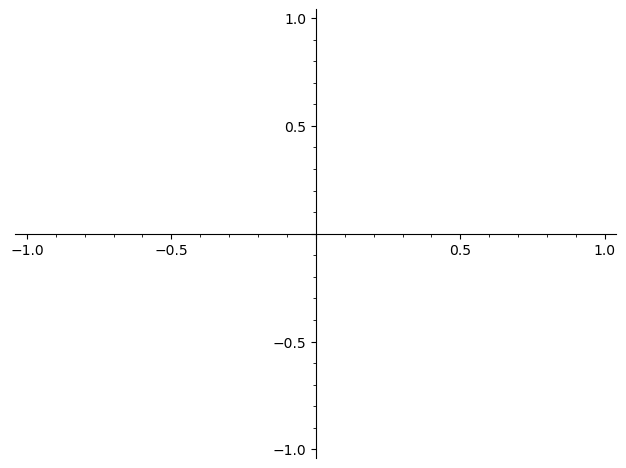

    ⚠️ Корни не найдены для параметров {'a': 5.0}
        → ❌ ошибка расчёта
[100.0%] ['a'] = 1.0000e+01
Найдено корней: 0


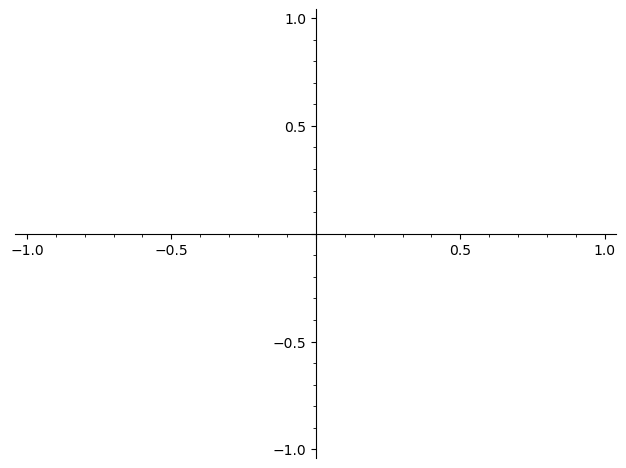

    ⚠️ Корни не найдены для параметров {'a': 10.0}
        → ❌ ошибка расчёта

Завершено за 583.7 сек
Успешных точек: 0/2


In [288]:
scan_investigation_a = True
if scan_investigation_a:
    # Сканирование по расстоянию между пластинами
    import numpy as np
    a_values = np.array([5.0, 10.0])  # см
    best_data_a, results_a, detplots_a = scan_parameter(lib, ['a'],
                                                        a_values,
                                                        original_digit_values,
                                                        omega_re_range,
                                                        omega_im_range,
                                                        verbose=False,
                                                        make_plot=True,
                                                        log_trust=True)

In [289]:
if scan_investigation_a:
    # Узнать количество ветвей
    n_branches = get_branches_count(results_a, 'a', distance_threshold=0.1, 
                                    use_K_params=False)
    print(f"Количество ветвей: {n_branches}")
#   n_branches = 1

Количество ветвей: 0


In [290]:
if scan_investigation_a:
    best_branch_id = 8
    best_branch_points = get_solution_branch(results = results_a,
                                         param_name = 'a',
                                         branch_id = best_branch_id)

❌ Ветвь 8 не найдена


In [291]:
# Перебор всех ветвей
figdir="../mendrive_qnm"

In [292]:
matched_branches_cache = match_branches_between_intervals(
    results_a, param_name='a', distance_threshold=0.1, use_K_params=False
)

for branch_id in range(n_branches):
    bp = matched_branches_cache.get(branch_id)
    if not bp:
        continue
    report_branch_results(results=results_a, param_name='a', figdir=figdir,
                          problem_type='qnm', branch_id=branch_id,
                          base_digit_values=original_digit_values,
                          language=language, max_points_to_show=5,
                          branch_points=bp, verbose=False)

In [293]:
# scan_results[0]  — список ветвей при omega=1e4
# detplots_omega[0] — (cu, cv, pl) при omega=1e4
if scan_investigation_a:
    plot_all_branches_with_detplots(
        scan_results   = results_a,   # list of lists of branch dicts
        detplots       = detplots_a,  # list of (cu, cv, pl)
        param_values   = a_values,    # или весь список omega если сканировали
        param_name     = 'a',
        output_dir     = figdir,
        marker_size    = 60,
        marker_color   = 'red',
        thrust_key     = 'thrust_N_per_kW',
    )

IndexError: list index out of range

In [ ]:
# Assuming detplots_omega and omega_values are already computed:
if scan_investigation_a:
    saved = save_detplots(
        detplots_a,
        param_values=a_values,   # the list/array of omega values you scanned
        param_name='a',
        output_dir=figdir+'/detplots_a',
        file_format='png',
        figsize=(9, 7),
        dpi=150,
        show=False   # set True to also display inline
    )


## Этап 2: Сканирование по магнитной проницаемости (μ_r)

In [ ]:
scan_investigation_mu = False
if scan_investigation_mu:
    # Сканирование по магнитной проницаемости правого материала (изотропный)
    mu_r_values = np.logspace(0, 3, 48)  # от 1 до 1000
    results_mu = []

    print(f"\n{'='*60}")
    print("СКАНИРОВАНИЕ: μ_r (изотропный материал)")
    print(f"{'='*60}")

    for mu_val in mu_r_values:
        print(f"μ_r = {mu_val:.2e} (изотропный)")
        result = calculate_single_point(
            {'mu_r_xx': mu_val, 'mu_r_yy': mu_val, 'mu_r_zz': mu_val},
            original_digit_values, verbose=False
        )
        if result is not None:
            results_mu.append(result)
            print(f"    → N/kW = {result['thrust_N_per_kW']:.6f} Н/кВт")
        else:
            print(f"    → ❌ ошибка")

    if len(results_mu) > 0:
        plot_scan_results(results_mu, 'mu_r_xx', save_path=f'{results_dir}/scan_mu_r.png')

        with open(f'{results_dir}/results_mu_r.json', 'w') as f:
            json.dump(results_mu, f, indent=2, default=str)

## Этап 3: Сканирование по диэлектрической проницаемости (ε_r)

In [ ]:
scan_investigation_epsilon = False
if scan_investigation_epsilon:
    # Сканирование по диэлектрической проницаемости правого материала
    eps_r_values = np.logspace(0, 3, 6)  # от 1 до 1000
    results_eps = []

    print(f"\n{'='*60}")
    print("СКАНИРОВАНИЕ: ε_r (изотропный материал)")
    print(f"{'='*60}")

    for eps_val in eps_r_values:
        print(f"ε_r = {eps_val:.2e} (изотропный)")
        result = calculate_single_point(
            {'epsilon_r_xx': eps_val, 'epsilon_r_yy': eps_val, 'epsilon_r_zz': eps_val},
            original_digit_values, verbose=False
        )
        if result is not None:
            results_eps.append(result)
            print(f"    → N/kW = {result['thrust_N_per_kW']:.6f} Н/кВт")
        else:
            print(f"    → ❌ ошибка")

    if len(results_eps) > 0:
        plot_scan_results(results_eps, 'epsilon_r_xx', save_path=f'{results_dir}/scan_eps_r.png')

        with open(f'{results_dir}/results_eps_r.json', 'w') as f:
            json.dump(results_eps, f, indent=2, default=str)

## Этап 4: Сканирование по частоте (ω)

In [ ]:
scan_investigation_omega = False
if scan_investigation_omega:
    # Сканирование по частоте
    omega_values = np.logspace(5, 9, 16)  # от 10^6 до 10^8 рад/с
    results_omega = scan_parameter('omega', omega_values, original_digit_values)

    if len(results_omega) > 0:
        plot_scan_results(results_omega, 'omega', save_path=f'{results_dir}/scan_omega.png')

        with open(f'{results_dir}/results_omega.json', 'w') as f:
            json.dump(results_omega, f, indent=2, default=str)

In [294]:
# после загрузки:
#lib = ctypes.CDLL("./mendrive_det.so")

# ... работа ...

# перед перекомпиляцией:
if 'lib' in locals():
    unload_lib(lib)
    del lib
    import gc; gc.collect()

# перекомпилируем
#!gcc -shared -fPIC -O3 -o mendrive_det.so mendrive_det.c -lm

# загружаем заново
#lib = ctypes.CDLL("./mendrive_det.so")

✅ Библиотека ./mendrive_qnm.so выгружена из памяти.


In [295]:
#digit_values = digit_values_init + non_diagonal_zero_permeabilities
#digit_values, omega_value[0].rhs(), lambda_d

digit_values = digit_values_init.copy()
digit_values += Lz_value.copy()
print (digit_values_init)

[a == 0.50000000000000000000000000000000000000, k_y == 0, mu_l_xx == 1.0000000000000000000000000000000000000, mu_l_yy == 1.0000000000000000000000000000000000000, mu_l_zz == 1.0000000000000000000000000000000000000, mu_r_xx == 100.00000000000000000000000000000000000, mu_r_yy == 100.00000000000000000000000000000000000, mu_r_zz == 100.00000000000000000000000000000000000, mu_l_yz_c == 0.00000000000000000000000000000000000000, mu_l_zy_c == 0.00000000000000000000000000000000000000, mu_r_yz_c == 0.00000000000000000000000000000000000000, mu_r_zy_c == 0.00000000000000000000000000000000000000, sigma_e_l_xx == 5.6250000000000000000000000000000000000e17, sigma_e_l_yy == 5.6250000000000000000000000000000000000e17, sigma_e_l_zz == 5.6250000000000000000000000000000000000e17, sigma_e_r_xx == 9.9000000000000000000000000000000000000e12, sigma_e_r_yy == 9.9000000000000000000000000000000000000e12, sigma_e_r_zz == 9.9000000000000000000000000000000000000e12, sigma_m_l_xx == 0.00000000000000000000000000000000

In [296]:
compile_lib("mendrive_qnm", loglevel='NONE')
lib = load_lib("mendrive_qnm")
init_lib(lib, digit_values, precision=MENDRIVE_LIB_PRECISION)

🔧 Компиляция (long_double):
   gcc -shared -fPIC  -O3 -DQNM -o mendrive_qnm.so         mendrive_det_qnm.c         mendrive_isolines.c         mendrive_isolines_traced.c         mendrive_contour_intersections.c         mendrive_contour_intersections_sharp.c         mendrive_characteristic_roots.c         mendrive_root.c         mendrive_newton.c         mendrive_newton_classic/mendrive_newton_classic.c         mendrive_linsolve.c         -I../vimaniks/gsl/local/include         -L../vimaniks/gsl/local/lib         -DARITH_LONG_DOUBLE -DMPREC_LOG_LEVEL=MPREC_LOG_LEVEL_OFF -DLOGGING         -DKY         -Wl,-rpath='$ORIGIN/../vimaniks/gsl/local/lib'         -lgsl -lgslcblas -lm -lm
    
✅ Библиотека mendrive_qnm.so скомпилирована (long_double)


In [297]:
omega_re_i = 100000
omega_im_i = 100000
det_eval_fast(lib, omega_re_i, omega_im_i)

(NaN, NaN)

In [298]:
def makeInvestigationPlots(omega_re_range, omega_im_range, N_re=1000, N_im=1000, debug_plot = False):
    omegare_grid, gamma_grid, omegare_list, gamma_list, u, v = init_det_plot2d(
        omegare_min = omega_re_range[0], omegare_max = omega_re_range[1], n_re = N_re,
        gamma_min   = omega_im_range[0], gamma_max   = omega_im_range[1], n_im = N_im)
    
    u, v = make_det_plot2d(lib,
                           omega_re_list = omegare_list,
                           omega_im_list = gamma_list,
                           u = u,
                           v = v)
    if debug_plot:
        import matplotlib.pyplot as plt
        fig,ax=plt.subplots(1,1)

        cp = ax.contourf(omegare_grid,gamma_grid, u)
        fig.colorbar(cp) # Add a colorbar to a plot
        ax.set_title('M8_subs_det_re')
        ax.set_xlabel('kz')
        ax.set_ylabel('sz')
        plt.show()

        import matplotlib.pyplot as plt
        fig,ax=plt.subplots(1,1)

        cp = ax.contourf(omegare_grid,gamma_grid, v)
        fig.colorbar(cp) # Add a colorbar to a plot
        ax.set_title('M8_subs_det_im')
        ax.set_xlabel('kz')
        ax.set_ylabel('sz')
        plt.show()
    
    # Искомую комплексную частоту
    # можно найти графическим методом
    # как точку пересечения двух нулевых изолиний
    # на контурных графиках зависимости
    # действительной и мнимой компонент
    # детерминанта от действительной и мнимой компонент комплексной частоты
    
    # Get coordinates from a contour
    # https://stackoverflow.com/questions/19418901/get-coordinates-from-a-contour

    import matplotlib.pyplot as plt
    fig, ax=plt.subplots(1,1)
    cu = ax.contour(omegare_grid, gamma_grid, u)
    cv = ax.contour(omegare_grid, gamma_grid, v)
    plt.show()
    
    cu_index_of_zero_level=cu.levels.tolist().index(0.)
    cv_index_of_zero_level=cv.levels.tolist().index(0.)
    cu_zero_levels_number = len(cu.allsegs[cu_index_of_zero_level])
    cv_zero_levels_number = len(cv.allsegs[cv_index_of_zero_level])
    cu_zero_levels_number, cv_zero_levels_number
    
    pl = Graphics()
    for seg in cu.allsegs[cu_index_of_zero_level]:
        #print("seg", seg)
        pl += list_plot(seg)
        pl += line(seg)
    for seg in cv.allsegs[cv_index_of_zero_level]:
        #print("seg", seg)
        pl += list_plot(seg, color="red")
        pl += line(seg, color="red")
    pl.show()
    
    omega_graphic_solutions, (cu, cv, pl) = find_resonance_roots_fast(lib,
                                                                      omega_re_range, omega_im_range,
                                                                      n_re = N_re, n_im = N_im)
    
    solver = NewtonRootSolver(lib)
    omega_prec_solutions = []
    
    for omega_sol_re, omega_sol_im in omega_graphic_solutions:

        det_sol = det_eval_fast(lib, omega_sol_re, omega_sol_im)
        print("Graphic sol:", omega_sol_re, omega_sol_im, det_sol)

        omegare_root, gamma_root = solver.solve(re0 = omega_sol_re, im0 = omega_sol_im)
        det_root = det_eval_fast(lib, omegare_root, gamma_root)
        print("Root:", omegare_root, gamma_root, det_root)

        omega_prec_solutions += [(omegare_root, gamma_root, det_root)]
    return omega_graphic_solutions, omega_prec_solutions

In [299]:
omega_re_range=(-3e+11, +3e+11)
omega_im_range=(-3e+10, +3e+10)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

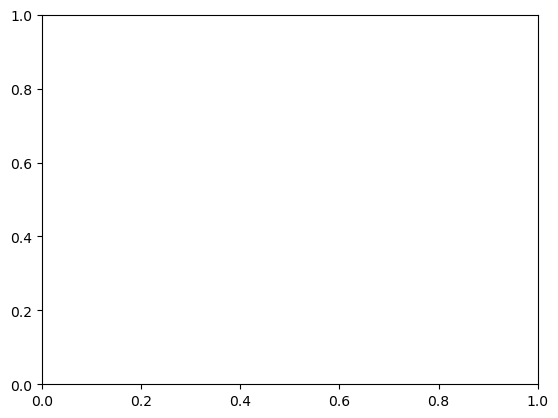

In [300]:
omega_graphic_solutions, omega_prec_solutions = makeInvestigationPlots(
    omega_re_range = omega_re_range,
    omega_im_range = omega_im_range)

omega_graphic_solutions, omega_prec_solutions

In [ ]:
if make_investigation_plots:
    omegare_grid, gamma_grid, omegare_list, gamma_list, u, v = init_det_plot2d(
        omegare_min = omega_re_range[0], omegare_max = omega_re_range[1], n_re = N_re,
        gamma_min   = omega_im_range[0], gamma_max   = omega_im_range[1], n_im = N_im)

In [ ]:
if make_investigation_plots:
    u, v = make_det_plot2d(lib, omegare_list, gamma_list, u, v)

In [ ]:
if make_investigation_plots:
    import matplotlib.pyplot as plt
    fig,ax=plt.subplots(1,1)

    cp = ax.contourf(omegare_grid,gamma_grid, u)
    fig.colorbar(cp) # Add a colorbar to a plot
    ax.set_title('M8_subs_det_re')
    ax.set_xlabel('omega_re')
    ax.set_ylabel('omega_im')
    plt.show()

In [ ]:
if make_investigation_plots:
    import matplotlib.pyplot as plt
    fig,ax=plt.subplots(1,1)

    cp = ax.contourf(omegare_grid,gamma_grid, v)
    fig.colorbar(cp) # Add a colorbar to a plot
    ax.set_title('M8_subs_det_im')
    ax.set_xlabel('omega_re')
    ax.set_ylabel('omega_im')
    plt.show()

Искомый волновой вектор можно найти графическим методом как точку пересечения двух нулевых изолиний на контурных графиках зависимости действительной и мнимой компонент детерминанта от действительной и мнимой компонент волнового вектора

In [ ]:
# Get coordinates from a contour
# https://stackoverflow.com/questions/19418901/get-coordinates-from-a-contour

import matplotlib.pyplot as plt
fig, ax=plt.subplots(1,1)
cu = ax.contour(omegare_grid,gamma_grid, u)
cv = ax.contour(omegare_grid,gamma_grid, v)
plt.show()

In [ ]:
cu_index_of_zero_level=cu.levels.tolist().index(0.)
cv_index_of_zero_level=cv.levels.tolist().index(0.)
cu_zero_levels_number = len(cu.allsegs[cu_index_of_zero_level])
cv_zero_levels_number = len(cv.allsegs[cv_index_of_zero_level])
cu_zero_levels_number, cv_zero_levels_number

Get coordinates from a contour

https://stackoverflow.com/questions/19418901/get-coordinates-from-a-contour

In [ ]:
pl = Graphics()
for seg in cu.allsegs[cu_index_of_zero_level]:
    #print("seg", seg)
    pl += list_plot(seg)
    pl += line(seg)
for seg in cv.allsegs[cv_index_of_zero_level]:
    #print("seg", seg)
    pl += list_plot(seg, color="red")
    pl += line(seg, color="red")
pl.show()

In [ ]:
def test_contour_line_intersection(M, i, j, cu, cv, cu_index, cv_index):
    dat_u = cu.allsegs[cu_index][i]
    dat_v = cv.allsegs[cv_index][j]
    
    xu = dat_u[:,0]
    yu = dat_u[:,1]
    xv = dat_v[:,0]
    yv = dat_v[:,1]
    
    if len(xu) < 2:
        return None
    if len(xv) < 2:
        return None
    
    return intersect_interp1d(M, xu, yu, xv, yv, ax)

Искомый волновой вектор можно найти графическим методом как точку пересечения двух нулевых изолиний на контурных графиках зависимости действительной и мнимой компонент детерминанта от действительной и мнимой компонент волнового вектора

Get coordinates from a contour

https://stackoverflow.com/questions/19418901/get-coordinates-from-a-contour

In [ ]:
omega_graphic_solutions, (cu, cv, pl) = find_resonance_roots_fast(lib, omega_re_range, omega_im_range)

In [ ]:
omega_graphic_solutions

```
знак перед корнем будем всегда выбирать так, чтобы корень имел положительнею мнимую часть (Зоммерфельд, Электродинамика, параграф 20, Б. Волновое поле и скин-эффект в полупространстве)
```

In [ ]:
if is_TM and is_TE and not is_4x4:
    omega_solution_number = 3
else:
    omega_solution_number = len(omega_graphic_solutions)-1
omega_solution_number

In [ ]:
max_abs_omega_sol = 0

for omega_sol_i in [omega_graphic_solutions[omega_solution_number]]:
    omega_sol_i_re = float(omega_sol_i[0])
    omega_sol_i_im = float(omega_sol_i[1])
    print(omega_sol_i_re, omega_sol_i_im)
    # знак перед корнем будем всегда выбирать так, чтобы корень имел положительнею мнимую часть (Зоммерфельд, Электродинамика, параграф 20, Б)
    # потому что нужно обеспечить затухание поля в проводнике
    # E_right_conductor_sol_z (x) = B1_zr*exp(+I * K_right_conductor*(x-a))
    # E_right_conductor_sol_x (x) = B1_xr*exp(+I * K_right_conductor*(x-a))
    for K_right_i in K_right_conductor_subs:
        K_right = K_right_i \
            .subs(kappa_vacuum_sol) \
            .subs(k_subs) \
            .subs(digit_values) \
            .subs(omega == omega_sol_i_re + I * omega_sol_i_im) \
            .subs(omega_re == omega_sol_i_re, omega_im == omega_sol_i_im)
        show(K_right)
        show(K_right.lhs() == K_right.rhs().n())
        # plot(E_right_conductor_sol_z (x).subs(K_right, a == A, B1_zr == 1+I).real(), x, 0, h_conductor).show()
    
    abs_omega_sol = omega_sol_i_re^2 + omega_sol_i_im^2
    print("abs_omega_sol,", abs_omega_sol)
    #if max_abs_k_z_sol < abs_k_z_sol:
    #    max_abs_k_z_sol = abs_k_z_sol
        # выберем решение с максимальным модулем
        # для того чтобы обеспечить лучшую сходимость итерационной процедуры

    omega_sol_re = omega_sol_i_re 
    omega_sol_im = omega_sol_i_im 

In [ ]:
if make_investigation_plots:
    from mpl_toolkits import mplot3d
    import numpy as np
    import matplotlib.pyplot as plt
    fig = plt.figure()

    ax = plt.axes(projection='3d')
    ax.set_xlabel('kz')
    ax.set_ylabel('sz')
    ax.plot_surface(omegare_grid, gamma_grid, u, cmap='viridis', edgecolor='none')
    ax.set_title('M6_subs_det_re')
    plt.show()

In [ ]:
if make_investigation_plots:
    from mpl_toolkits import mplot3d
    import numpy as np
    import matplotlib.pyplot as plt
    fig = plt.figure()

    ax = plt.axes(projection='3d')
    ax.set_xlabel('kz')
    ax.set_ylabel('sz')
    ax.plot_surface(omegare_grid, gamma_grid, v, cmap='viridis', edgecolor='none')
    ax.set_title('M6_subs_det_im')
    plt.show()

In [ ]:
print(f"{omega_sol_re:0.36e}, {omega_sol_im:0.36e}")

In [ ]:
solver = NewtonRootSolver(lib)
omegare_root, gamma_root = solver.solve(re0 = omega_sol_re, im0 = omega_sol_im)
print("Root:", omegare_root, gamma_root)

In [ ]:
omega_qnm_sol = [omega_re == omegare_root,
             omega_im == gamma_root,
             omega == omegare_root + I * gamma_root,
             # в режиме QNM внешний ток возбуждения выключен
             je0_ext == 0,
             jm0_ext == 0,
            ]

In [ ]:
#omega_sol = [omega_re == omega_sol_re,  omega_im == omega_sol_im,
#           omega == omega_sol_re + I * omega_sol_im]

In [ ]:
M4_d = M4 \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs) \
    .subs(k_subs) \
    .subs(sign_K_1_subs) \
    .subs(digit_values) \
    .subs(omega_qnm_sol)

In [ ]:
M4_d.variables()

In [ ]:
complex128(M4_d.det())

In [ ]:
omega_sol_re, omega_sol_im

In [ ]:
# ============================================================================
# ИСПРАВЛЕНИЕ: восстановление вектора B_ext, потерянного при GenerateMatrix
# Вставить СРАЗУ ПОСЛЕ Cell 485 (M4_K = GenerateMatrix(sys4, vars4))
# ============================================================================
 
# Свободный член (всё, что НЕ умножается на vars4) для каждого уравнения sys4.
# Это именно то, что GenerateMatrix отбросил при .coefficient(v).
 
# неизвестные амплитуды -- те же, что переданы в GenerateMatrix(sys4, vars4),
# имена зависят от режима (TE: B_H_*, TM: B_E_*)
vars4 = []
if is_TM:
    vars4 += [B_E_zl, A1_E_z, A2_E_z, B_E_zr]
if is_TE:
    vars4 += [B_H_zl, A1_H_z, A2_H_z, B_H_zr]

B_ext_symbolic = vector(SR, [
    -(eq.lhs() - eq.rhs()).expand().subs({v: 0 for v in vars4})
    for eq in sys4
])

# --- восстановление y-профиля моды в источнике j_ext ---
# sys4 нормирована делением на phase_y_* (чтобы убрать y из матрицы M4),
# но ток возбуждения j_ext профиль sin(k_y*y) не нёс -> в B_ext возник 1/phase_y_*
# (а при k_y=0 это деление на ноль). Домножение на phase_y_* сокращает 1/phase_y_*
# и эквивалентно согласованию источника с поперечным профилем моды (mode-matched).
#if is_TE:
#    B_ext_symbolic = B_ext_symbolic.apply_map(lambda e: (phase_y_TE*e).simplify_full())
#if is_TM:
#    B_ext_symbolic = B_ext_symbolic.apply_map(lambda e: (phase_y_TM*e).simplify_full())

print("Вектор B_ext (свободные члены, потерянные GenerateMatrix):")
for i, b in enumerate(B_ext_symbolic):
    show(b)

# Проверка: третья строка (eq_Ey_l) должна содержать j_ext_y(-a)
print("\nB_ext[2] должен содержать j_ext_y(-a):")
show(B_ext_symbolic[2])

# Контрольная проверка, что матрица M4_K действительно не зависит от j_ext
# (это ОЖИДАЕМО и ПРАВИЛЬНО — резонансные частоты не меняются)
print("\nM4_K.variables():")
print(M4_K.variables())
print("(в списке не должно быть j_ext_y -- это корректно)")

In [ ]:
# ============================================================================
# ПРОВЕРКА: где именно произошла подстановка j_ext_y(x) -> j0_ext?
# Вставить ПЕРЕД блоком B_ext_symbolic, чтобы проверить исходное состояние
# ============================================================================

# Тест 1: что стоит в исходном sys4[2] (eq_Ey_l) ДО любой подстановки?
print("sys4[2] (eq_Ey_l) — переменные:")
print(sys4[2].variables())
print()
print("Содержит ли sys4[2] функцию j_ext_y (символьную, не подставленную)?")
has_function_form = any('j_ext_y' in str(op) and op.operator() is not None
                         for op in sys4[2].lhs().operands() + sys4[2].rhs().operands()
                         if hasattr(op, 'operator')) if False else 'j_ext_y' in str(sys4[2])
print(f"  'j_ext_y' встречается в строковом представлении: {has_function_form}")
show(sys4[2])

# Тест 2: B_ext_symbolic[2] — что именно там стоит?
# Если там j_ext_y(-a) как ФУНКЦИЯ -- профиль ещё НЕ подставлен,
# тогда new-вариант (j0_ext == число) ОШИБОЧЕН: подставляется голая
# амплитуда без учёта exp(-I*K_l*(x+a))|_{x=-a} = exp(0) = 1 -- что
# на границе x=-a КОРРЕКТНО (экспонента вырождается в 1!), НО только
# если K_left_conductor в показателе совпадает с тем K_left_conductor,
# который уже использован в матрице M4_K -- иначе профиль рассинхронизирован.

print("\nB_ext_symbolic[2] — точная форма:")
show(B_ext_symbolic[2])
print("\nЭто j_ext_y(-a) уже свёрнутое в j0_ext, ИЛИ всё ещё функция j_ext_y(-a)?")
print(f"  variables: {B_ext_symbolic[2].variables()}")

# ВЫВОД:
# Если на экране 'j_ext_y' НЕ встречается, а виден 'j0_ext' напрямую --
# значит где-то РАНЬШЕ в блокноте (между Cell 285 и Cell 349) уже было:
#   j_ext_y_sym = j0_ext  (БЕЗ exp-профиля)
# Это означает, что скин-профиль j_ext ВООБЩЕ НЕ ВНЕДРЁН -- источник
# моделируется как ПОСТОЯННЫЙ (не зависящий от x) ток, что физически
# неверно для тока, распределённого по глубине скин-слоя.
#
# Если же на экране всё ещё 'j_ext_y(-a)' -- профиль нужно подставить
# ЯВНО перед численным решением (как в блоке ниже).

In [ ]:
B4 = B4_K \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs)          # аналогично M4 в M4 * X = B_ext

In [ ]:
# ============================================================================
# СЛЕДУЮЩИЙ ШАГ: проверка знаменателя B_ext и решение неоднородной СЛАУ
# Вставить СРАЗУ ПОСЛЕ блока B_ext_symbolic (после Cell 485+)
# ============================================================================

# --- Проверка 1: знаменатель не должен совпадать с условием резонанса ---
denom_Bext2 = (c^2*k_z^2 - epsilon_l_yy_c*mu_l_xx_c*omega^2)
print("Знаменатель B_ext[2]:")
show(denom_Bext2)

# Знаменатель связан с K_left_conductor:
#   K_left_conductor^2 = epsilon_l_yy_c*mu_l_xx_c*omega^2/c^2 - k_z^2  (примерно)
# Если это так, denom_Bext2 = -c^2 * K_left_conductor^2 (с точностью до знака)
# Это ВАЖНО: при численной подстановке K_left_conductor берётся из РЕШЁННОЙ
# однородной задачи -- то есть знаменатель ВСЕГДА конечен и не равен 0,
# если только сам K_left_conductor не обращается в ноль (не должно происходить
# для проводника с конечной sigma).

# --- Проверка 3: задаём конкретную амплитуду j0_ext и решаем ---
j0_ext_value_d = complex128(1.0e6)  # А/см² (или с^-1 в СГС) -- варьируется

# --- Проверка 2: подставляем численные значения и решаем M4 * X = B_ext ---
def calc_omega_re_point(omegare_root):
    omega_drive_d = omegare_root
    #omega_drive_d = omega_sol_re
    omega_drive_d_subs = [omega == omega_drive_d,
                          omega_re == omega_drive_d,
                          omega_im == 0]

    M4_d = M4_K \
        .subs(K_vacuum_subs) \
        .subs(K_left_conductor_subs) \
        .subs(K_right_conductor_subs) \
        .subs(kappa_vacuum_sol) \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(sign_K_1_subs) \
        .subs(digit_values).subs(omega_drive_d_subs).n(prec=128)

    M4_det = M4_d.det()

    B_ext_num = B_ext_symbolic \
        .subs(K_vacuum_subs) \
        .subs(K_left_conductor_subs) \
        .subs(K_right_conductor_subs) \
        .subs(kappa_vacuum_sol) \
        .subs(epsilon_mu_subs) \
        .subs(k_subs) \
        .subs(sign_K_1_subs) \
        .subs(digit_values).subs(omega_drive_d_subs)

    print("\nM4_d (численная матрица):")
    print("M4_det =", M4_det)
    show(M4_d)

    print("\nB_ext_num (численный вектор источника, без амплитуды j0_ext):")
    #print(B_ext_num[2].variables())
    show(B_ext_num)


    B_ext_final = B_ext_num.subs([
        je0_ext == j0_ext_value_d,
        jm0_ext == j0_ext_value_d,
    ]).n(prec=128)

    print(f"\nB_ext_final (j0_ext = {j0_ext_value_d}):")
    show(B_ext_final)

    # --- Решение неоднородной СЛАУ ---
    X_sol_ext = M4_d.solve_right(B_ext_final)
    # B1_zl_sol, A1_z_sol, A2_z_sol, B1_zr_sol = X_sol_ext

    coeffs_drive_subs = [vars4[i] == X_sol_ext[i] for i in range(len(vars4))]
    for s in coeffs_drive_subs:
        print(s)

    # print(f"\nB1_zl_sol = {B1_zl_sol}")
    # print(f"A1_z_sol  = {A1_z_sol}")
    # print(f"A2_z_sol  = {A2_z_sol}")
    # print(f"B1_zr_sol = {B1_zr_sol}")

    # --- Контрольная проверка: при j0_ext=0 решение должно быть нулевым ---
#     B_ext_zero = B_ext_num.subs(j0_ext == 0)
#     print(f"\nПри j0_ext=0, B_ext должен быть нулевым вектором: {B_ext_zero}")
    # Если M4_d невырождена (det != 0), то решение при B_ext=0 -- тривиальное (все нули)
    # Это и ожидается ВНЕ резонанса. На самой резонансной частоте det(M4_d) -> 0,
    # и решение системы M4*X=0 становится неединственным (собственный вектор).

    # --- Сканирование omega для построения резонансной кривой ---
    print("\n" + "="*60)
    print("СКАНИРОВАНИЕ ПО omega: |B1_zl(omega)| вблизи резонанса")
    print("="*60)
    print("Запустите отдельным циклом по omega_re, варьируя digit_values,")
    print("и постройте |B1_zl_sol| -- должен показать лоренцеву кривую")
    print("с максимумом на резонансной частоте, найденной из det(M4_K)=0.")

def scan_omega_re(omegare_min, omegare_max, n_re, dv, make_plot=True, log_trust=True):
    import numpy as np

    omegare_linspace = np.linspace(real128(omegare_min), real128(omegare_max), n_re)
    omegare_list     = omegare_linspace.tolist()
 
    for ikz in np.arange(0, len(omegare_list), 1):
        omega_re_i = omegare_list[ikz]

        # Формируем omega_sol_cur для calc_thrust
        omega_sol_cur = [
            omega_re == omega_re_i,
            omega_im == 0,
            omega == omega_re_i,
            je0_ext == j0_ext_value_d,
            jm0_ext == j0_ext_value_d,
        ]
        
        param_overrides_i = { "omega" : omega_re_i }

        result = calc_thrust(
            omega_sol_cur, param_overrides_i, dv,
            verbose=verbose, make_plot=make_plot
        )

        if result is None:
            continue

        if log_trust:
            print(f"\n  📋 Результат расчёта для omega {omega_re_i}:")
            keys = ["params", "residual",
                    "thrust_N_per_kW", "thrust_N_per_kW_left", "thrust_N_per_kW_right",
                    "N_per_kW_maxwell_walls", "N_per_kW_maxwell_inner_vacuum",
                    "N_per_kW_maxwell_left_wall", "N_per_kW_maxwell_right_wall",
                    'N_per_kW_F_jm_ext_D_conj_right',
                    'N_per_kW_p_Bt_je_ext_B_conj_left',
                   ]
            for k in keys:
                print(f"    {k} = {result[k]}")

In [ ]:
calc_omega_re_point(omegare_root)

In [ ]:
omegare_min = 1e6
omegare_max=1e7
n_re=10

In [ ]:
scan_omega_re(omegare_min, omegare_max, n_re, digit_values)

инициализируем метод Ньютона значениями найденными графическим методом

In [ ]:
M4_det_d = M4_det_omega_re_im.subs(digit_values)
M4_det_d.variables()

In [ ]:
omega_qnm_sol

Итак, графическим методом как точку пересечения двух нулевых изолиний на контурных графиках зависимости действительной и мнимой компонент детерминанта от действительной и мнимой компонент волнового вектора, были найдены приблизительные значения действительной и мнимой компонент волнового вектора, которые затем в итерационной процедуре были уточнены методом градиентного спуска Ньютона

# Substitutions

In [ ]:
show(K_left_conductor_subs)

In [ ]:
show(K_right_conductor_subs)

In [ ]:
K_vacuum_qnm_subs_d          = [K_v_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_qnm_sol).subs(digit_values) for K_v_s in K_vacuum_subs]
K_left_conductor_qnm_subs_d  = [K_l_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_qnm_sol).subs(digit_values) for K_l_s in K_left_conductor_subs]
K_right_conductor_qnm_subs_d = [K_r_s.subs(k_subs).subs(kappa_vacuum_sol).subs(omega_qnm_sol).subs(digit_values) for K_r_s in K_right_conductor_subs]

In [ ]:
[complex128(eq.rhs()) for eq in K_left_conductor_qnm_subs_d]

In [ ]:
[complex128(eq.rhs()) for eq in K_right_conductor_qnm_subs_d]

знак перед корнем будем всегда выбирать так, чтобы корень имел положительнею мнимую часть (Зоммерфельд, Электродинамика, параграф 20, Б)

In [ ]:
K_vacuum_qnm_subs_d

In [ ]:
# Выбираем знак корня (Im > 0 для затухания в глубину)
# K_vacuum_subs_d          = fix_K_sign(K_vacuum_subs_d)
K_left_conductor_qnm_subs_d  = fix_K_sign(K_left_conductor_qnm_subs_d)
K_right_conductor_qnm_subs_d = fix_K_sign(K_right_conductor_qnm_subs_d)

In [ ]:
K_right_conductor_qnm_subs_d

In [ ]:
K_left_conductor_qnm_subs_d

In [ ]:
M4_qnm_d = M4 \
    .subs(K_vacuum_subs) \
    .subs(K_left_conductor_subs) \
    .subs(K_right_conductor_subs) \
    .subs(kappa_vacuum_sol) \
    .subs(epsilon_mu_subs) \
    .subs(k_subs) \
    .subs(sign_K_1_subs) \
    .subs(digit_values) \
    .subs(omega_qnm_sol)

In [ ]:
M4_qnm_d.variables()

In [ ]:
complex128(M4_qnm_d.det())

Используем SVD для гарантированной симметрии

Самый надёжный метод — найти ядро матрицы через сингулярное разложение:

In [ ]:
X4, residual = svd_X4(M4_qnm_d)
X4, residual

In [ ]:
coeffs_qnm_subs = [vars4[i] == X4[i] for i in range(len(vars4))]
coeffs_qnm_subs

In [ ]:
sys4

In [ ]:
sys4_subs_d = [eq.subs(K_vacuum_qnm_subs_d) \
                 .subs(K_left_conductor_qnm_subs_d) \
                 .subs(K_right_conductor_qnm_subs_d)
                 .subs(epsilon_mu_subs) \
                 .subs(k_subs).subs(sign_K_1_subs).subs(omega_qnm_sol) \
                 .subs(digit_values) for eq in sys4]
#sys4_subs_d

In [ ]:
for i, eq in enumerate(sys4_subs_d):
    diff_expr = (eq.lhs() - eq.rhs())
    free_vars = set(diff_expr.variables()) - set(vars4)
    print(f"Уравнение {i}: посторонние переменные = {free_vars}")

In [ ]:
Ex_left_conductor_d, Ex_right_conductor_d, Ex_vacuum_d, \
Ey_left_conductor_d, Ey_right_conductor_d, Ey_vacuum_d, \
Ez_left_conductor_d, Ez_right_conductor_d, Ez_vacuum_d, \
Dx_left_conductor_d, Dx_right_conductor_d, Dx_vacuum_d, \
Dy_left_conductor_d, Dy_right_conductor_d, Dy_vacuum_d, \
Dz_left_conductor_d, Dz_right_conductor_d, Dz_vacuum_d, \
Hx_left_conductor_d, Hx_right_conductor_d, Hx_vacuum_d, \
Hy_left_conductor_d, Hy_right_conductor_d, Hy_vacuum_d, \
Hz_left_conductor_d, Hz_right_conductor_d, Hz_vacuum_d, \
Bx_left_conductor_d, Bx_right_conductor_d, Bx_vacuum_d, \
By_left_conductor_d, By_right_conductor_d, By_vacuum_d, \
Bz_left_conductor_d, Bz_right_conductor_d, Bz_vacuum_d, \
div_B_left_conductor_d, div_B_right_conductor_d, div_B_vacuum_d, \
div_D_left_conductor_d, div_D_right_conductor_d, div_D_vacuum_d \
    = subs_fields(omega_qnm_sol,
                  K_left_conductor_qnm_subs_d,
                  K_vacuum_qnm_subs_d,
                  K_right_conductor_qnm_subs_d,
                  coeffs_qnm_subs, digit_values)

In [ ]:
print(Ex_left_conductor_d.variables(), Ex_right_conductor_d.variables(), Ex_vacuum_d.variables())
print(Ey_left_conductor_d.variables(), Ey_right_conductor_d.variables(), Ey_vacuum_d.variables(), )
print(Ez_left_conductor_d.variables(), Ez_right_conductor_d.variables(), Ez_vacuum_d.variables(), )
print(Dx_left_conductor_d.variables(), Dx_right_conductor_d.variables(), Dx_vacuum_d.variables(), )
print(Dy_left_conductor_d.variables(), Dy_right_conductor_d.variables(), Dy_vacuum_d.variables(), )
print(Dz_left_conductor_d.variables(), Dz_right_conductor_d.variables(), Dz_vacuum_d.variables(), )
print(Hx_left_conductor_d.variables(), Hx_right_conductor_d.variables(), Hx_vacuum_d.variables(), )
print(Hy_left_conductor_d.variables(), Hy_right_conductor_d.variables(), Hy_vacuum_d.variables(), )
print(Hz_left_conductor_d.variables(), Hz_right_conductor_d.variables(), Hz_vacuum_d.variables(), )
print(Bx_left_conductor_d.variables(), Bx_right_conductor_d.variables(), Bx_vacuum_d.variables(), )
print(By_left_conductor_d.variables(), By_right_conductor_d.variables(), By_vacuum_d.variables(), )
print(Bz_left_conductor_d.variables(), Bz_right_conductor_d.variables(), Bz_vacuum_d.variables(), )
print(div_B_left_conductor_d.variables(), div_B_right_conductor_d.variables(), div_B_vacuum_d.variables(), )
print(div_D_left_conductor_d.variables(), div_D_right_conductor_d.variables(), div_D_vacuum_d.variables() )

In [ ]:
# divE_vacuum = I*k_z * Ez_vacuum_d (x=x) + Ex_vacuum_d (x=x).diff(x)

In [ ]:
# divE_vacuum_d = divE_vacuum.subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

In [ ]:
#divE_left_conductor  = I*k_z * Ez_left_conductor_d (x=x) + Ex_left_conductor_d (x=x).diff(x)
#divE_right_conductor = I*k_z * Ez_right_conductor_d (x=x) + Ex_right_conductor_d (x=x).diff(x)

In [ ]:
#divE_left_conductor_d  = divE_left_conductor .subs(K_left_conductor_subs) .subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)
#divE_right_conductor_d = divE_right_conductor.subs(K_right_conductor_subs).subs(k_subs).subs(omega_sol).subs(digit_values).subs(coeffs_subs)

In [ ]:
x = var('x')
print(set(div_B_left_conductor_d.variables()) - {x})
print(set(div_B_vacuum_d.variables()) - {x})
print(set(div_B_right_conductor_d.variables()) - {x})

In [ ]:
test_val = div_B_left_conductor_d.subs(x == -A - h_conductor_l)
print(type(test_val))
print(test_val)
print(test_val.variables() if hasattr(test_val, 'variables') else "не символьное")

In [ ]:
print(div_B_left_conductor_d.variables())

In [ ]:
h_conductor_l_step = h_conductor_l / 10
for x in np.arange(-A-h_conductor_l, -A+h_conductor_l_step, h_conductor_l_step):
    print(x, div_B_left_conductor_d(x = x).n(prec=128))

In [ ]:
h_conductor_r_step = h_conductor_r / 10
for x in np.arange(A, A+h_conductor_r+h_conductor_r_step, h_conductor_r_step):
    print(x, div_B_right_conductor_d(x = x).n(prec=128))

In [ ]:
pl = Graphics()
if is_TM:
    pl += plot(Ez_left_conductor_d.real(), (x, -A-h_conductor_l, -A), color="green")
    pl += plot(Ez_vacuum_d.real(), (x, -A, -A+h_conductor_l), color="green")
if is_TE:
    pl += plot(Ey_left_conductor_d.real(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.real(), (x, -A, -A+h_conductor_l))

pl.show(title="График Re тангенциальной компоненты электрического поля")

In [ ]:
pl = Graphics()
if is_TM:
    pl += plot(Ez_vacuum_d.real(), (x, A-h_conductor_r, A), color="green")
    pl += plot(Ez_right_conductor_d.real(), (x, A, A+h_conductor_r), color="green")
if is_TE:
    pl += plot(Ey_vacuum_d.real(), (x, A-h_conductor_r, A))
    pl += plot(Ey_right_conductor_d.real(), (x, A, A+h_conductor_r))

pl.show(title="График Re тангенциальной компоненты электрического поля")

In [ ]:
pl = Graphics()
if is_TM:
    pl += plot(Ez_left_conductor_d.real(), (x, -A-h_conductor_l, -A), color="green")
    pl += plot(Ez_vacuum_d.real(), (x, -A, A), color="green")
    pl += plot(Ez_right_conductor_d.real(), (x, A, A+h_conductor_r), color="green")
if is_TE:
    pl += plot(Ey_left_conductor_d.real(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.real(), (x, -A, A))
    pl += plot(Ey_right_conductor_d.real(), (x, A, A+h_conductor_r))

pl.show(title="График Re тангенциальной компоненты электрического поля")

In [ ]:
pl = Graphics()
if is_TM:
    pl += plot(Ez_left_conductor_d.imag(), (x, -A-h_conductor_l, -A), color="green")
    pl += plot(Ez_vacuum_d.imag(), (x, -A, A), color="green")
    pl += plot(Ez_right_conductor_d.imag(), (x, A, A+h_conductor_r), color="green")
if is_TE:
    pl += plot(Ey_left_conductor_d.imag(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.imag(), (x, -A, A))
    pl += plot(Ey_right_conductor_d.imag(), (x, A, A+h_conductor_r))

pl.show(title="График Im тангенциальной компоненты электрического поля")

In [ ]:
pl = Graphics()
if is_TM:
    pl += plot(Ez_left_conductor_d.imag(), (x, -A-h_conductor_l, -A), color="green")
    pl += plot(Ez_vacuum_d.imag(), (x, -A, A), color="green")
    pl += plot(Ez_right_conductor_d.imag(), (x, A, A+h_conductor_r), color="green")
if is_TE:
    pl += plot(Ey_left_conductor_d.imag(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.imag(), (x, -A, A))
    pl += plot(Ey_right_conductor_d.imag(), (x, A, A+h_conductor_r))

pl.show(title="График Im тангенциальной компоненты электрического поля")

In [ ]:
pl = Graphics()
if is_TM:
    pl += plot(Ez_left_conductor_d.abs(), (x, -A-h_conductor_l, -A), color="green")
    pl += plot(Ez_vacuum_d.abs(), (x, -A, A), color="green")
    pl += plot(Ez_right_conductor_d.abs(), (x, A, A+h_conductor_r), color="green")
if is_TE:
    pl +=  plot(Ey_left_conductor_d.abs(), (x, -A-h_conductor_l, -A))
    pl += plot(Ey_vacuum_d.abs(), (x, -A, A))
    pl += plot(Ey_right_conductor_d.abs(), (x, A, A+h_conductor_r))

pl.show(title="График Abs тангенциальной компоненты электрического поля")

In [ ]:
if is_TM:
    pl  = plot(arg(Ez_left_conductor_d(x=x))/pi, (x, -h_conductor_l-A, -A), color="green")
    pl += plot(arg(Ez_vacuum_d(x=x))/pi, (x, -A, A), color="green")
    pl += plot(arg(Ez_right_conductor_d(x=x))/pi, (x, A, A+h_conductor_r), color="green")
if is_TE:
    pl  = plot(arg(Ey_left_conductor_d)/pi, (x, -h_conductor_l-A, -A))
    pl += plot(arg(Ey_vacuum_d)/pi, (x, -A, A))
    pl += plot(arg(Ey_right_conductor_d)/pi, (x, A, A+h_conductor_r))

pl.show(title="График Arg тангенциальной компоненты электрического поля")

In [ ]:
pl = Graphics()
for y_d in np.arange(-B, B+y_step, y_step):
    pl += plot(Dx_left_conductor_d.subs(y == y_d).real(), (x, -A-h_conductor_l, -A))
    pl += plot(Dx_vacuum_d.subs(y == y_d).real(), (x, -A, A))
    pl += plot(Dx_right_conductor_d.subs(y == y_d).real(), (x, A, A+h_conductor_r))

pl.show(title="График Re нормальной компоненты электрического смещения")

In [ ]:
pl = Graphics()
for y_d in np.arange(-B, B+y_step, y_step):
    pl += plot(Dx_left_conductor_d.subs(y == y_d).imag(), (x, -h_conductor_l-A, -A))
    pl += plot(Dx_vacuum_d.subs(y == y_d).imag(), (x, -A, A))
    pl += plot(Dx_right_conductor_d.subs(y == y_d).imag(), (x, A, A+h_conductor_r))

pl.show(title="График Im нормальной компоненты электрического смещения")

In [ ]:
pl = Graphics()
for y_d in np.arange(-B, B+y_step, y_step):
    pl += plot(Dx_left_conductor_d.subs(y == y_d).abs(), (x, -h_conductor_l-A, -A))
    pl += plot(Dx_vacuum_d.subs(y == y_d).abs(), (x, -A, A))
    pl += plot(Dx_right_conductor_d.subs(y == y_d).abs(), (x, A, A+h_conductor_r))

pl.show(title="График Abs нормальной компоненты электрического смещения")

In [ ]:
pl = Graphics()

for y_d in np.arange(-B, B+y_step, y_step):
    pl += plot(arg(Dx_left_conductor_d.subs(y == y_d))/pi, (x, -h_conductor_l-A, -A))
    pl += plot(arg(Dx_vacuum_d.subs(y == y_d))/pi, (x, -A, A))
    pl += plot(arg(Dx_right_conductor_d.subs(y == y_d))/pi, (x, A, A+h_conductor_r))

pl.show(title="График Arg нормальной компоненты электрического смещения")

In [ ]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hy_left_conductor_d.subs(y=y_d).real(), (x, -h_conductor_l-A, -A), color="green")
        pl += plot(Hy_vacuum_d.subs(y=y_d).real(), (x, -A, A), color="green")
        pl += plot(Hy_right_conductor_d.subs(y=y_d).real(), (x, A, A+h_conductor_r), color="green")
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hz_left_conductor_d(y=y_d).real(), (x, -h_conductor_l-A, -A))
        pl += plot(Hz_vacuum_d(y=y_d).real(), (x, -A, A))
        pl += plot(Hz_right_conductor_d(y=y_d).real(), (x, A, A+h_conductor_r))

pl.show(title="График Re тангенциальной компоненты напряженности магнитного поля H")

In [ ]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hy_left_conductor_d.subs(y=y_d).imag(), (x, -h_conductor_l-A, -A), color="green")
        pl += plot(Hy_vacuum_d.subs(y=y_d).imag(), (x, -A, A), color="green")
        pl += plot(Hy_right_conductor_d.subs(y=y_d).imag(), (x, A, A+h_conductor_r), color="green")
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hz_left_conductor_d(y=y_d).imag(), (x, -h_conductor_l-A, -A))
        pl += plot(Hz_vacuum_d(y=y_d).imag(), (x, -A, A))
        pl += plot(Hz_right_conductor_d(y=y_d).imag(), (x, A, A+h_conductor_r))

pl.show(title="График Im тангенциальной компоненты напряженности магнитного поля H")

In [ ]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hy_left_conductor_d.subs(y=y_d).abs(), (x, -h_conductor_l-A, -A), color="green")
        pl += plot(Hy_vacuum_d.subs(y=y_d).abs(), (x, -A, A), color="green")
        pl += plot(Hy_right_conductor_d.subs(y=y_d).abs(), (x, A, A+h_conductor_r), color="green")
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(Hz_left_conductor_d(y=y_d).abs(), (x, -h_conductor_l-A, -A))
        pl += plot(Hz_vacuum_d(y=y_d).abs(), (x, -A, A))
        pl += plot(Hz_right_conductor_d(y=y_d).abs(), (x, A, A+h_conductor_r))

pl.show(title="График Abs тангенциальной компоненты напряженности магнитного поля H")

In [ ]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(arg(Hy_left_conductor_d.subs(y=y_d))/pi, (x, -h_conductor_l-A, -A), color="green")
        pl += plot(arg(Hy_vacuum_d.subs(y=y_d))/pi, (x, -A, A), color="green")
        pl += plot(arg(Hy_right_conductor_d.subs(y=y_d))/pi, (x, A, A+h_conductor_r), color="green")
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(arg(Hz_left_conductor_d(y=y_d))/pi, (x, -h_conductor_l-A, -A))
        pl += plot(arg(Hz_vacuum_d(y=y_d))/pi, (x, -A, A))
        pl += plot(arg(Hz_right_conductor_d(y=y_d))/pi, (x, A, A+h_conductor_r))

pl.show(title="График Arg тангенциальной компоненты напряженности магнитного поля H")

In [ ]:
pl = Graphics()
if is_TM:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(arg(Hy_left_conductor_d.subs(y=y_d))/pi  - arg(Ez_left_conductor_d(x=x))/pi, (x, -h_conductor_l-A, -A), color="green")
        pl += plot(arg(Hy_vacuum_d.subs(y=y_d))/pi          - arg(Ez_vacuum_d(x=x))/pi, (x, -A, A), color="green")
        pl += plot(arg(Hy_right_conductor_d.subs(y=y_d))/pi - arg(Ez_right_conductor_d(x=x))/pi, (x, A, A+h_conductor_r), color="green")
if is_TE:
    for y_d in np.arange(-B, B+y_step, y_step):
        pl += plot(arg(Hz_left_conductor_d(y=y_d))/pi  - arg(Ez_left_conductor_d(x=x))/pi, (x, -h_conductor_l-A, -A))
        pl += plot(arg(Hz_vacuum_d(y=y_d))/pi          - arg(Ez_vacuum_d(x=x))/pi, (x, -A, A))
        pl += plot(arg(Hz_right_conductor_d(y=y_d))/pi - arg(Ez_right_conductor_d(x=x))/pi, (x, A, A+h_conductor_r))

pl.show(title="График delta Arg тангенциальных компонент H и E")

In [ ]:
x=var("x")
phase_EzEx_left (x, y) = (arg(Ez_left_conductor_d(x=x, y=y))/pi
                       -  arg(Ex_left_conductor_d(x=x, y=y))/pi)

In [ ]:
phase_EzEx_right (x, y) = (arg(Ez_right_conductor_d(x=x, y=y))/pi
                        -  arg(Ex_right_conductor_d(x=x, y=y))/pi)

In [ ]:
phase_EzEx_left (x =-h_conductor_l-A), \
phase_EzEx_right(x = A+h_conductor_r)

In [ ]:
# - pi/4 + phi
if is_TM:
    phase_EH_left_ (x, y) = ((arg(Ez_left_conductor_d(x=x, y=y))/pi
                          -   arg(Hy_left_conductor_d(x=x, y=y))/pi))
    phase_EH_right_ (x, y) = ((arg(Ez_right_conductor_d(x=x, y=y))/pi
                           -   arg(Hy_right_conductor_d(x=x, y=y))/pi))
if is_TE:
    phase_EH_left_ (x, y) = ((arg(Ey_left_conductor_d(x=x, y=y))/pi
                          -   arg(Hz_left_conductor_d(x=x, y=y))/pi))
    phase_EH_right_ (x, y) = ((arg(Ey_right_conductor_d(x=x, y=y))/pi
                           -   arg(Hz_right_conductor_d(x=x, y=y))/pi))

In [ ]:
# - pi/4 + phi
if is_TM:
    phase_EB_left (x, y) = ((arg(Ez_left_conductor_d(x=x, y=y))/pi
                         -   arg(By_left_conductor_d(x=x, y=y))/pi))
    phase_EB_right (x, y) = ((arg(Ez_right_conductor_d(x=x, y=y))/pi
                          -   arg(By_right_conductor_d(x=x, y=y))/pi))
if is_TE:
    phase_EB_left (x, y) = ((arg(Ey_left_conductor_d(x=x, y=y))/pi
                         -   arg(Bz_left_conductor_d(x=x, y=y))/pi))
    phase_EB_right (x, y) = ((arg(Ey_right_conductor_d(x=x, y=y))/pi
                          -   arg(Bz_right_conductor_d(x=x, y=y))/pi))

In [ ]:
print(Ey_left_conductor_d(x=-A))
print(Hz_left_conductor_d(x=-A))
print(Ey_right_conductor_d(x=A))
print(Hz_right_conductor_d(x=A))

In [ ]:
phase_EH_left_ (x = -A).n(prec=128), \
phase_EH_right_(x = A).n(prec=128)

In [ ]:
phase_EB_left (x = -A).n(prec=128), \
phase_EB_right(x = A).n(prec=128)

In [ ]:
phase_EB_left (x = -h_conductor_l-A).n(prec=128), \
phase_EB_right(x = A+h_conductor_r).n(prec=128)

In [ ]:
plot(phase_EB_left (x), -h_conductor_l-A, -A)

In [ ]:
plot(phase_EB_right (x), A, A+h_conductor_r)

Решение получено.

In [ ]:
F_I_rotB_conj_l_d = calc_F_I_rotB_conj_l_d(K_left_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)
F_P_rotE_conj_l_d = calc_F_P_rotE_conj_l_d(K_left_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)

F_I_rotB_conj_r_d = calc_F_I_rotB_conj_r_d(K_right_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)
F_P_rotE_conj_r_d = calc_F_P_rotE_conj_r_d(K_right_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)

In [ ]:
F_P_rotE_conj_d = F_P_rotE_conj_l_d + F_P_rotE_conj_r_d
F_P_rotE_conj_d

In [ ]:
F_I_rotB_conj_d = F_I_rotB_conj_l_d + F_I_rotB_conj_r_d
F_I_rotB_conj_d

In [ ]:
def plot_r(expression, y):
    v = []
    s = [(A,0)]
    sum_int = 0

    mn = 0
    mx = h_conductor_r
    st = h_conductor_r / 250

    import numpy as np
    for vx in np.arange(mn, mx+st, st):
        _Wx = expression(x = A + vx, y=y)
        #if not isinstance(_Wx, float) and not isinstance(_Wx, RealField):
        #    _Wx = _Wx.n()
        v += [(A + vx, _Wx)]
        if vx != 0:
            sum_int += (_Wx + _Wx_pre) / 2 * st
            s += [(A + vx, sum_int)]
        #print("x =", vx, "_Wx =", _Wx, "sum_int = ", sum_int)
        _Wx_pre = _Wx

    return v, s, sum_int

In [ ]:
def plot_l(expression, y):
    v = []
    s = [(-A,0)]
    sum_int = 0

    mn = 0
    mx = h_conductor_l
    st = h_conductor_l / 250

    import numpy as np
    for vx in np.arange(mn, mx+st, st):
        _Wx = expression(x = -A - vx, y=y)
        #if not isinstance(_Wx, float) and not isinstance(_Wx, RealField):
        #    _Wx = _Wx.n()
        v += [(-A - vx, _Wx)]
        if vx != 0:
            sum_int += (_Wx + _Wx_pre) / 2 * st
            s += [(-A - vx, sum_int)]
        #print("x =", vx, "_Wx =", _Wx, "sum_int = ", sum_int)
        _Wx_pre = _Wx

    return v, s, sum_int

1) пондеромоторная сила, приложенная к идеальному проводнику

In [ ]:
p_Ht_left_jeH_conj  = calc_p_Ht_left_jeH_conj (K_left_conductor_qnm_subs_d,  digit_values, omega_qnm_sol, coeffs_qnm_subs)

In [ ]:
print("p_Ht_left_jeH_conj =", p_Ht_left_jeH_conj)

In [ ]:
p_Bt_left_jeB_conj = calc_p_Bt_left_jeB_conj (K_left_conductor_qnm_subs_d,  digit_values, omega_qnm_sol, coeffs_qnm_subs)

print("p_Bt_left_jeB_conj =", p_Bt_left_jeB_conj)

In [ ]:
F_jmD_conj_left  = calc_F_jmD_conj_left (K_left_conductor_qnm_subs_d,  digit_values, omega_qnm_sol, coeffs_qnm_subs)
F_jmD_conj_right = calc_F_jmD_conj_right(K_right_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)
F_jmD_conj_left, F_jmD_conj_right

2) пондеромоторная сила, приложенная к плохому проводнику

In [ ]:
p_Ht_right_jeH_conj = calc_p_Ht_right_jeH_conj(K_right_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)
print("p_Ht_right_jeH_conj =", p_Ht_right_jeH_conj)

In [ ]:
p_Bt_right_jeB_conj = calc_p_Bt_right_jeB_conj (K_right_conductor_qnm_subs_d,  digit_values, omega_qnm_sol, coeffs_qnm_subs)

print("p_Bt_right_jeB_conj =", p_Bt_right_jeB_conj)

In [ ]:
# skin_force_m_phi
# arg(E/H) = - pi/4 + -2*pi + phi        :  cos(phi) + sin(phi)
# arg(E/H) = - pi/4 + -3/2*pi + phi      :  cos(phi) - sin(phi)
# arg(E/H) = - pi/4 + -pi + phi          : -cos(phi) - sin(phi)
# arg(E/H) = - pi/4 + -1/2*pi + phi      : -cos(phi) + sin(phi)
# arg(E/H) = - pi/4 + phi                :  cos(phi) + sin(phi)
# arg(E/H) = - pi/4 + 1/2*pi + phi       :  cos(phi) - sin(phi)
# arg(E/H) = - pi/4 + pi + phi           : -cos(phi) - sin(phi)
# arg(E/H) = - pi/4 + 3/2*pi + phi       : -cos(phi) + sin(phi)
# arg(E/H) = - pi/4 + 2*pi + phi         :  cos(phi) + sin(phi)

In [ ]:
#                  (- pi/4 + phi)
#                   -1.249875
def get_m_phi(phase_EH):
    # arg(E/H) = - pi/4 + -pi + phi          : -cos(phi) - sin(phi)
    if -1.5 < phase_EH and phase_EH <= -1.0:
        print(f"-1.5 < phase_EH and phase_EH < -1.0 : {phase_EH}")
        print("arg(E/H) = - pi/4 + -pi + phi          : -cos(phi) - sin(phi)")
        phi = +1.25 + phase_EH
        m_phi = (-cos(phi * pi) - sin(phi * pi))

    # arg(E/H) = - pi/4 + -1/2*pi + phi      : -cos(phi) + sin(phi)
    if  -1.0 < phase_EH  and phase_EH <= -0.5:
        print(f"-1.0 < phase_EH  and phase_EH < -0.5 : {phase_EH}")
        print("arg(E/H) = - pi/4 + -1/2*pi + phi      : -cos(phi) + sin(phi)")
        phi = 0.75 + phase_EH
        m_phi  = (-cos(phi  * pi) + sin(phi  * pi))

    # arg(E/H) = - pi/4 + phi                :  cos(phi) + sin(phi)
    if  -0.5 < phase_EH  and phase_EH <= 0:
        print(f"-0.5 < phase_EH  and phase_EH < 0 :  {phase_EH}")
        print("arg(E/H) = - pi/4 + phi                :  cos(phi) + sin(phi)")
        phi = 0.25 + phase_EH
        m_phi  = ( cos(phi  * pi) + sin(phi  * pi))

    # arg(E/H) = - pi/4 + 1/2*pi + phi       :  cos(phi) - sin(phi)
    if  0 < phase_EH  and phase_EH <= 0.5:
        print(f"0 < phase_EH  and phase_EH < 0.5 :  {phase_EH}")
        print("arg(E/H) = - pi/4 + 1/2*pi + phi       :  cos(phi) - sin(phi)")
        phi = -0.25 + phase_EH
        m_phi  = ( cos(phi  * pi) - sin(phi  * pi))

    # arg(E/H) = - pi/4 + pi + phi           : -cos(phi) - sin(phi)
    if  0.5 < phase_EH  and phase_EH <= 1:
        print(f"0.5 < phase_EH  and phase_EH < 1 : {phase_EH}")
        print("arg(E/H) = - pi/4 + pi + phi           : -cos(phi) - sin(phi)")
        phi = -0.75 + phase_EH
        m_phi  = (-cos(phi  * pi) - sin(phi  * pi))

    return phi, m_phi.n(prec=128)

In [ ]:
# "руками подобранный" множитель для p_Ht
# исходя из того что для левого (немагнитный металл) и
# правого (феррит) материала
# знаки этих множителей различны
# это подтверждает идею Каравашкина в статье
# https://karavashkin3.blogspot.com/2025/06/the-reality-of-emdrive-in-terms-of.html
# The Reality of EmDrive in Terms of Discoveries in Electromagnetism


$$\vec{E} = \vec{E}(x, y)\,e^{i\,(k_z + i\,s_z)\,z}\,e^{-i\,\omega\,t}$$


In [ ]:
# Произведём расчёт пондеромоторной силы p_Ht 
# способом аналогичному в skin_force_phi.ipynb
# а именно интегрированием по объёму
# силы взамодействия поверхностных токов Фуко
# с магнитным полем проникшим внутрь материала


In [ ]:
# магнитное поле в проводнике
# Ландау Лифшиц. Электродинамика сплошных сред (59.3)
# H_y(x) = H_0 * exp(-x/delta) * exp(I*(x/delta - omega * t))
# Ландау Лифшиц. Электродинамика сплошных сред (59.6)
# re_H_y(x) = H_0 * exp(-x/delta) * cos(x/delta - omega * t)

# а что если в данном расчете изменится сдвиг фаз между электрическим и магнитным полем?
# re_E_z(x) = H_0 * sqrt(omega/(4*pi*sigma)) * exp(-x/delta) * cos(x/delta - omega * t - pi - pi/4 + phi)

# ток проводимости вызванный электрическим полем
# Ландау Лифшиц. Электродинамика сплошных сред (58.4)
# j_z(x) = sigma * re_E_z(x)
# je_z_l(x) = sigma_e_l_d * (Ez_left_conductor_d (x=x)*exp(-I*omega_t)).real()
# je_z_r(x) = sigma_e_r_d * (Ez_right_conductor_d(x=x)*exp(-I*omega_t)).real()
if is_TM:
    je_z_l(x, y) = sigma_e_l_zz.subs(digit_values) * Ez_left_conductor_d (x=x, y=y)*exp(-I*omega_t)
    je_z_r(x, y) = sigma_e_r_zz.subs(digit_values) * Ez_right_conductor_d(x=x, y=y)*exp(-I*omega_t)
if is_TE:
    je_y_l(x, y) = sigma_e_l_yy.subs(digit_values) * Ey_left_conductor_d (x=x, y=y)*exp(-I*omega_t)
    je_y_r(x, y) = sigma_e_r_yy.subs(digit_values) * Ey_right_conductor_d(x=x, y=y)*exp(-I*omega_t)

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# fe_x(x) = 1 / c * je_z(x) * re_H_y(x)
if is_TM:
    fjeH_x_l(x, y, omega_t) = - 1 / c_d * je_z_l(x=x, y=y) * (Hy_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
    fjeH_x_r(x, y, omega_t) = - 1 / c_d * je_z_r(x=x, y=y) * (Hy_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
if is_TE:
    fjeH_x_l(x, y, omega_t) = + 1 / c_d * je_y_l(x=x, y=y) * (Hz_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
    fjeH_x_r(x, y, omega_t) = + 1 / c_d * je_y_r(x=x, y=y) * (Hz_right_conductor_d(x=x, y=y) * exp(-I*omega_t))

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# fe_x(x) = 1 / c * je_z(x) * re_B_y(x)
if is_TM:
    fjeB_x_l(x, y, omega_t) = - 1 / c_d * je_z_l(x=x, y=y) * (By_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
    fjeB_x_r(x, y, omega_t) = - 1 / c_d * je_z_r(x=x, y=y) * (By_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
if is_TE:
    fjeB_x_l(x, y, omega_t) = + 1 / c_d * je_y_l(x=x, y=y) * (Bz_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
    fjeB_x_r(x, y, omega_t) = + 1 / c_d * je_y_r(x=x, y=y) * (Bz_right_conductor_d(x=x, y=y) * exp(-I*omega_t))

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# fe_x(x) = 1 / c * je_z(x) * re_H_y(x)
# здесь учитываем то
if is_TM:
    fjeH_x_l_rere(x, y, omega_t) = - 1 / c_d * je_z_l(x=x, y=y).real() * ( Hy_left_conductor_d (x=x, y=y) * exp(-I*omega_t)).real()
    fjeH_x_r_rere(x, y, omega_t) = - 1 / c_d * je_z_r(x=x, y=y).real() * ( Hy_right_conductor_d(x=x, y=y) * exp(-I*omega_t)).real()

    fjeH_x_l_conj(x, y, omega_t) = (
                              - 1 / 2 / c_d * je_z_l(x=x, y=y) * conjugate( Hy_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
                              ).real()
    fjeH_x_r_conj(x, y, omega_t) = (
                              - 1 / 2 / c_d * je_z_r(x=x, y=y) * conjugate( Hy_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
                              ).real()
if is_TE:
    fjeH_x_l_rere(x, y, omega_t) = + 1 / c_d * je_y_l(x=x, y=y).real() * ( Hz_left_conductor_d (x=x, y=y) * exp(-I*omega_t)).real()
    fjeH_x_r_rere(x, y, omega_t) = + 1 / c_d * je_y_r(x=x, y=y).real() * ( Hz_right_conductor_d(x=x, y=y) * exp(-I*omega_t)).real()

    fjeH_x_l_conj(x, y, omega_t) = (
                              + 1 / 2 / c_d * je_y_l(x=x, y=y) * conjugate( Hz_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
                              ).real()
    fjeH_x_r_conj(x, y, omega_t) = (
                              + 1 / 2 / c_d * je_y_r(x=x, y=y) * conjugate( Hz_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
                              ).real()

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# fe_x(x) = 1 / c * je_z(x) * re_B_y(x)
# здесь учитываем то
if is_TM:
    fjeB_x_l_rere(x, y, omega_t) = - 1 / c_d * je_z_l(x=x, y=y).real() * ( By_left_conductor_d (x=x, y=y) * exp(-I*omega_t)).real()
    fjeB_x_r_rere(x, y, omega_t) = - 1 / c_d * je_z_r(x=x, y=y).real() * ( By_right_conductor_d(x=x, y=y) * exp(-I*omega_t)).real()

    fjeB_x_l_conj(x, y, omega_t) = (
                              - 1 / 2 / c_d * je_z_l(x=x, y=y) * conjugate( By_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
                              ).real()
    fjeB_x_r_conj(x, y, omega_t) = (
                              - 1 / 2 / c_d * je_z_r(x=x, y=y) * conjugate( By_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
                              ).real()
if is_TE:
    fjeB_x_l_rere(x, y, omega_t) = + 1 / c_d * je_y_l(x=x, y=y).real() * ( Bz_left_conductor_d (x=x, y=y) * exp(-I*omega_t)).real()
    fjeB_x_r_rere(x, y, omega_t) = + 1 / c_d * je_y_r(x=x, y=y).real() * ( Bz_right_conductor_d(x=x, y=y) * exp(-I*omega_t)).real()

    fjeB_x_l_conj(x, y, omega_t) = (
                              + 1 / 2 / c_d * je_y_l(x=x, y=y) * conjugate( Bz_left_conductor_d (x=x, y=y) * exp(-I*omega_t))
                              ).real()
    fjeB_x_r_conj(x, y, omega_t) = (
                              + 1 / 2 / c_d * je_y_r(x=x, y=y) * conjugate( Bz_right_conductor_d(x=x, y=y) * exp(-I*omega_t))
                              ).real()

In [ ]:
# усредняем по периоду колебаний
# F_x(x) = (1/(2*pi))*integrate(fe_x(x), (omega_t, 0, 2*pi))
# display(Math(latex(F_x(x))))

In [ ]:
# интегрируем по глубине
#int_fe_x(x, omega_t) = integrate(fe_x(x, omega_t), x)

In [ ]:
# интегрируем по глубине
#int_F_x(x) = integrate(F_x(x), x)

In [ ]:
from scipy import integrate as scipy_integrate
opts = {'epsabs': 1e-15, 'epsrel': 1e-12, 'limit': 200}

In [ ]:
# усредняем по периоду колебаний
fjeH_l = lambda x, y : scipy_integrate.quad( \
    lambda _omega_t_ : \
        real128(fjeH_x_l_conj(x = x, y = y, omega_t = _omega_t_)), \
            0, real128(2*pi))[0] / real128(2*pi)

In [ ]:
# усредняем по периоду колебаний
fjeB_l = lambda x, y : scipy_integrate.quad( \
    lambda _omega_t_ : \
        real128(fjeB_x_l_conj(x = x, y = y, omega_t = _omega_t_)), \
            0, real128(2*pi))[0] / real128(2*pi)

In [ ]:
# усредняем по периоду колебаний
fjeH_r = lambda x, y : scipy_integrate.quad( \
    lambda _omega_t_ : \
        real128(fjeH_x_r_conj(x = x, y = y, omega_t = _omega_t_)), \
            0, real128(2*pi))[0] / real128(2*pi)

In [ ]:
# усредняем по периоду колебаний
fjeB_r = lambda x, y : scipy_integrate.quad( \
    lambda _omega_t_ : \
        real128(fjeB_x_r_conj(x = x, y = y, omega_t = _omega_t_)), \
            0, real128(2*pi))[0] / real128(2*pi)

In [ ]:
fjeH_l(x=-A, y = 0), fjeH_l(x=-A-h_conductor_l, y = 0)

In [ ]:
fjeB_l(x=-A, y = 0), fjeB_l(x=-A-h_conductor_l, y = 0)

In [ ]:
fjeH_r(x=A, y = 0), fjeH_r(x=A+h_conductor_r, y = 0)

In [ ]:
fjeB_r(x=A, y = 0), fjeB_r(x=A+h_conductor_r, y = 0)

In [ ]:
fjeHr_x, sfjeHr_x, sum_int_fjeHr = plot_r(fjeH_r, y = 0)

In [ ]:
fjeBr_x, sfjeBr_x, sum_int_fjeBr = plot_r(fjeB_r, y = 0)

In [ ]:
fjeHl_x, sfjeHl_x, sum_int_fjeHl = plot_l(fjeH_l, y = 0)

In [ ]:
fjeBl_x, sfjeBl_x, sum_int_fjeBl = plot_l(fjeB_l, y = 0)

In [ ]:
list_plt_fjeHr_x  = list_plot(fjeHr_x)
list_plt_sfjeHr_x = list_plot(sfjeHr_x)

In [ ]:
list_plt_fjeBr_x = list_plot(fjeBr_x)
list_plt_sfjer_x = list_plot(sfjeBr_x)

In [ ]:
list_plt_fjeHl_x  = list_plot(fjeHl_x)
list_plt_sfjeHl_x = list_plot(sfjeHl_x)

In [ ]:
list_plt_fjeBl_x  = list_plot(fjeBl_x)
list_plt_sfjeBl_x = list_plot(sfjeBl_x)

In [ ]:
if make_investigation_plots:
    (list_plt_fjeHr_x).show(title = "сила действующая на ток Фуко со стороны магнитного поля,\n проникшего в правый проводник\n")

In [ ]:
if make_investigation_plots:
    (list_plt_fjeBr_x).show(title = "сила действующая на ток Фуко со стороны магнитного поля,\n проникшего в правый проводник\n")

In [ ]:
if make_investigation_plots:
    (list_plt_fjeHl_x).show(title = "сила действующая на ток Фуко со стороны магнитного поля,\n проникшего в левый проводник\n")

In [ ]:
if make_investigation_plots:
    (list_plt_fjeBl_x).show(title = "сила действующая на ток Фуко со стороны магнитного поля,\n проникшего в левый проводник\n")

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# усредняем по периоду колебаний
# и интегрируем по глубине
FjeHl_conj = scipy_integrate.nquad( \
    lambda _x_, _omega_t_ : \
        real128(fjeH_x_l_conj(x = _x_, omega_t = _omega_t_)), \
            [[real128(-A-h_conductor_l), -real128(A)], [0, real128(2*pi)]])[0] / real128(2*pi)

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# усредняем по периоду колебаний
# и интегрируем по глубине
FjeBl_conj = scipy_integrate.nquad( \
    lambda _x_, _omega_t_ : \
        real128(fjeB_x_l_conj(x = _x_, omega_t = _omega_t_)), \
            [[real128(-A-h_conductor_l), -real128(A)], [0, real128(2*pi)]])[0] / real128(2*pi)

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# усредняем по периоду колебаний
# и интегрируем по глубине
FjeHr_conj = scipy_integrate.nquad( \
    lambda _x_, _omega_t_ : \
        real128(fjeH_x_r_conj(x = _x_, omega_t = _omega_t_)), \
            [[real128(A), real128(A +h_conductor_r)],[0, real128(2*pi)]])[0] / real128(2*pi)

In [ ]:
# сила действующая на ток проводимости со стороны магнитного поля
# усредняем по периоду колебаний
# и интегрируем по глубине
FjeBr_conj = scipy_integrate.nquad( \
    lambda _x_, _omega_t_ : \
        real128(fjeB_x_r_conj(x = _x_, omega_t = _omega_t_)), \
            [[real128(A), real128(A +h_conductor_r)],[0, real128(2*pi)]])[0] / real128(2*pi)

In [ ]:
t_I_conv_Hn_left  = calc_t_I_conv_Hn_left_conductor_conj (Hx_vacuum_d, digit_values, omega_qnm_sol)
t_I_conv_Hn_right = calc_t_I_conv_Hn_right_conductor_conj(Hx_vacuum_d, digit_values, omega_qnm_sol)

In [ ]:
p_Bt_left_jeB_conj  = calc_p_Bt_left_jeB_conj (K_left_conductor_qnm_subs_d,  digit_values, omega_qnm_sol, coeffs_qnm_subs)
p_Bt_right_jeB_conj = calc_p_Bt_right_jeB_conj(K_right_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)

# p_I_conv_Ht_left    = calc_p_I_conv_Ht_left_conductor (Hy_vacuum_d, Hz_vacuum_d, digit_values)
# p_I_conv_Ht_right   = calc_p_I_conv_Ht_right_conductor(Hy_vacuum_d, Hz_vacuum_d, digit_values)

In [ ]:
# тангенциальная компонента конвективной силы на вектор намагниченности I
# со стороны напряжённости магнитного поля H
p_I_conv_Ht_left  = calc_p_I_conv_Ht_left_conductor_conj (Hy_vacuum_d, Hz_vacuum_d, digit_values, omega_qnm_sol)
p_I_conv_Ht_right = calc_p_I_conv_Ht_right_conductor_conj(Hy_vacuum_d, Hz_vacuum_d, digit_values, omega_qnm_sol)

In [ ]:
p_I_conv_Ht_left, p_I_conv_Ht_right

In [ ]:
sum_int_fjeHl, sum_int_fjeHr

In [ ]:
sum_int_fjeBl, sum_int_fjeBr

### интеграл усреднённой по периоду силы действующей на ток проводимости со стороны магнитного поля


In [ ]:
# численный интеграл комплексно сопряжённого произведения
FjeHl_conj, FjeHr_conj

In [ ]:
# численный интеграл комплексно сопряжённого произведения
FjeBl_conj, FjeBr_conj

In [ ]:
# аналитический интеграл комплексно сопряжённого произведения
p_Ht_left_jeH_conj, p_Ht_right_jeH_conj

In [ ]:
# Static and dynamic electricity by William R. Smythe, second edition, 1950
# paragraph 18 formula 1.47
# давление на границу равно разности давлений по обе стороны от нее
# $$ P_n = \frac{1}{2} \epsilon'{{E'}_t}^2 - \frac{1}{2} \epsilon''{{E''}_t}^2 $$

$$ P_n = \frac{1}{2} \epsilon'{{E'}_t}^2 - \frac{1}{2} \epsilon''{{E''}_t}^2 $$

In [ ]:
# bad conductor force
# additional 1/2 arises as result of integration on period
p_Et_left_conductor = calc_p_Et_left_conductor_conj(Ez_vacuum_d, Ey_vacuum_d, digit_values, omega_qnm_sol)
print("p_Et_left_conductor =", p_Et_left_conductor)

In [ ]:
# bad conductor force
# additional 1/2 arises as result of integration on period
p_Et_right_conductor = calc_p_Et_right_conductor_conj(Ez_vacuum_d, Ey_vacuum_d, digit_values, omega_qnm_sol)
print("p_Et_right_conductor =", p_Et_right_conductor)

In [ ]:
# Static and dynamic electricity by William R. Smythe, second edition, 1950
# paragraph 18 formula 1.45
# натяжение на границе, созданное нормальными компонентами индукции
# должно равняться разности натяжений по обе стороны от границы
# $$ T_n = \frac{{{D'}_n}^2}{2 \epsilon'} - \frac{{{D''}_n}^2}{2 \epsilon''} $$

$$ T_n = \frac{{{D'}_n}^2}{2 \epsilon'} - \frac{{{D''}_n}^2}{2 \epsilon''} $$

In [ ]:
# super conductor tension
# additional 1/2 arises as result of integration on period
# epsilon_superconductor -> Infinity
# 1 / epsilon_superconductor -> 0.0

t_Dn_left_conductor = calc_t_Dn_left_conductor_conj(Ex_left_conductor_d, digit_values, omega_qnm_sol)
print("t_Dn_left_conductor =", t_Dn_left_conductor.n(prec=128))

In [ ]:
# bad conductor force
# additional 1/2 arises as result of integration on period
t_Dn_right_conductor = calc_t_Dn_right_conductor_conj(Ex_right_conductor_d, digit_values, omega_qnm_sol)
print("t_Dn_right_conductor =", t_Dn_right_conductor.n(prec=128))

In [ ]:
# динамическая сила на магнитный ток перемагничивания (изменяющуюся во времени I) в поле индукции D
F_dyn_I_D_l = calc_F_dyn_I_D_conj_left (K_left_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)
F_dyn_I_D_r = calc_F_dyn_I_D_conj_right(K_right_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)

# динамическая сила на ток переполяризации (изменяющуюся во времени P) в поле магнитной индукции B
F_dyn_P_B_l = calc_F_dyn_P_B_conj_left (K_left_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)
F_dyn_P_B_r = calc_F_dyn_P_B_conj_right(K_right_conductor_qnm_subs_d, digit_values, omega_qnm_sol, coeffs_qnm_subs)


# Расчёт тензоров натяжения

In [ ]:
convective_tensor_IH_left_conductor = compute_convective_stress_tensor_symbolic_IH(
    Ex = Ex_left_conductor_d(x=x, y=y), Ey = Ey_left_conductor_d(x=x, y=y), Ez = Ez_left_conductor_d(x=x, y=y),
    Dx = Dx_left_conductor_d(x=x, y=y), Dy = Dy_left_conductor_d(x=x, y=y), Dz = Dz_left_conductor_d(x=x, y=y),
    Hx = Hx_left_conductor_d(x=x, y=y), Hy = Hy_left_conductor_d(x=x, y=y), Hz = Hz_left_conductor_d(x=x, y=y),
    Bx = Bx_left_conductor_d(x=x, y=y), By = By_left_conductor_d(x=x, y=y), Bz = Bz_left_conductor_d(x=x, y=y),
)

In [ ]:
convective_tensor_IH_inner_vacuum = compute_convective_stress_tensor_symbolic_IH(
    Ex = Ex_vacuum_d(x=x, y=y), Ey = Ey_vacuum_d(x=x, y=y), Ez = Ez_vacuum_d(x=x, y=y),
    Dx = Dx_vacuum_d(x=x, y=y), Dy = Dy_vacuum_d(x=x, y=y), Dz = Dz_vacuum_d(x=x, y=y),
    Hx = Hx_vacuum_d(x=x, y=y), Hy = Hy_vacuum_d(x=x, y=y), Hz = Hz_vacuum_d(x=x, y=y),
    Bx = Bx_vacuum_d(x=x, y=y), By = By_vacuum_d(x=x, y=y), Bz = Bz_vacuum_d(x=x, y=y),
)

In [ ]:
convective_tensor_IH_right_conductor = compute_convective_stress_tensor_symbolic_IH(
    Ex = Ex_right_conductor_d(x=x, y=y), Ey = Ey_right_conductor_d(x=x, y=y), Ez = Ez_right_conductor_d(x=x, y=y),
    Dx = Dx_right_conductor_d(x=x, y=y), Dy = Dy_right_conductor_d(x=x, y=y), Dz = Dz_right_conductor_d(x=x, y=y),
    Hx = Hx_right_conductor_d(x=x, y=y), Hy = Hy_right_conductor_d(x=x, y=y), Hz = Hz_right_conductor_d(x=x, y=y),
    Bx = Bx_right_conductor_d(x=x, y=y), By = By_right_conductor_d(x=x, y=y), Bz = Bz_right_conductor_d(x=x, y=y),
)

In [ ]:
convective_tensor_PE_left_conductor = compute_convective_stress_tensor_symbolic_PE(
    Ex = Ex_left_conductor_d(x=x, y=y), Ey = Ey_left_conductor_d(x=x, y=y), Ez = Ez_left_conductor_d(x=x, y=y),
    Dx = Dx_left_conductor_d(x=x, y=y), Dy = Dy_left_conductor_d(x=x, y=y), Dz = Dz_left_conductor_d(x=x, y=y),
    Hx = Hx_left_conductor_d(x=x, y=y), Hy = Hy_left_conductor_d(x=x, y=y), Hz = Hz_left_conductor_d(x=x, y=y),
    Bx = Bx_left_conductor_d(x=x, y=y), By = By_left_conductor_d(x=x, y=y), Bz = Bz_left_conductor_d(x=x, y=y),
)

In [ ]:
convective_tensor_PE_inner_vacuum = compute_convective_stress_tensor_symbolic_PE(
    Ex = Ex_vacuum_d(x=x, y=y), Ey = Ey_vacuum_d(x=x, y=y), Ez = Ez_vacuum_d(x=x, y=y),
    Dx = Dx_vacuum_d(x=x, y=y), Dy = Dy_vacuum_d(x=x, y=y), Dz = Dz_vacuum_d(x=x, y=y),
    Hx = Hx_vacuum_d(x=x, y=y), Hy = Hy_vacuum_d(x=x, y=y), Hz = Hz_vacuum_d(x=x, y=y),
    Bx = Bx_vacuum_d(x=x, y=y), By = By_vacuum_d(x=x, y=y), Bz = Bz_vacuum_d(x=x, y=y),
)

In [ ]:
convective_tensor_PE_right_conductor = compute_convective_stress_tensor_symbolic_PE(
    Ex = Ex_right_conductor_d(x=x, y=y), Ey = Ey_right_conductor_d(x=x, y=y), Ez = Ez_right_conductor_d(x=x, y=y),
    Dx = Dx_right_conductor_d(x=x, y=y), Dy = Dy_right_conductor_d(x=x, y=y), Dz = Dz_right_conductor_d(x=x, y=y),
    Hx = Hx_right_conductor_d(x=x, y=y), Hy = Hy_right_conductor_d(x=x, y=y), Hz = Hz_right_conductor_d(x=x, y=y),
    Bx = Bx_right_conductor_d(x=x, y=y), By = By_right_conductor_d(x=x, y=y), Bz = Bz_right_conductor_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_ED_left_conductor = compute_maxwell_stress_tensor_symbolic_ED(
    Ex = Ex_left_conductor_d(x=x, y=y), Ey = Ey_left_conductor_d(x=x, y=y), Ez = Ez_left_conductor_d(x=x, y=y),
    Dx = Dx_left_conductor_d(x=x, y=y), Dy = Dy_left_conductor_d(x=x, y=y), Dz = Dz_left_conductor_d(x=x, y=y),
    Hx = Hx_left_conductor_d(x=x, y=y), Hy = Hy_left_conductor_d(x=x, y=y), Hz = Hz_left_conductor_d(x=x, y=y),
    Bx = Bx_left_conductor_d(x=x, y=y), By = By_left_conductor_d(x=x, y=y), Bz = Bz_left_conductor_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_ED_inner_vacuum = compute_maxwell_stress_tensor_symbolic_ED(
    Ex = Ex_vacuum_d(x=x, y=y), Ey = Ey_vacuum_d(x=x, y=y), Ez = Ez_vacuum_d(x=x, y=y),
    Dx = Dx_vacuum_d(x=x, y=y), Dy = Dy_vacuum_d(x=x, y=y), Dz = Dz_vacuum_d(x=x, y=y),
    Hx = Hx_vacuum_d(x=x, y=y), Hy = Hy_vacuum_d(x=x, y=y), Hz = Hz_vacuum_d(x=x, y=y),
    Bx = Bx_vacuum_d(x=x, y=y), By = By_vacuum_d(x=x, y=y), Bz = Bz_vacuum_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_ED_right_conductor = compute_maxwell_stress_tensor_symbolic_ED(
    Ex = Ex_right_conductor_d(x=x, y=y), Ey = Ey_right_conductor_d(x=x, y=y), Ez = Ez_right_conductor_d(x=x, y=y),
    Dx = Dx_right_conductor_d(x=x, y=y), Dy = Dy_right_conductor_d(x=x, y=y), Dz = Dz_right_conductor_d(x=x, y=y),
    Hx = Hx_right_conductor_d(x=x, y=y), Hy = Hy_right_conductor_d(x=x, y=y), Hz = Hz_right_conductor_d(x=x, y=y),
    Bx = Bx_right_conductor_d(x=x, y=y), By = By_right_conductor_d(x=x, y=y), Bz = Bz_right_conductor_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_HB_left_conductor = compute_maxwell_stress_tensor_symbolic_HB(
    Ex = Ex_left_conductor_d(x=x, y=y), Ey = Ey_left_conductor_d(x=x, y=y), Ez = Ez_left_conductor_d(x=x, y=y),
    Dx = Dx_left_conductor_d(x=x, y=y), Dy = Dy_left_conductor_d(x=x, y=y), Dz = Dz_left_conductor_d(x=x, y=y),
    Hx = Hx_left_conductor_d(x=x, y=y), Hy = Hy_left_conductor_d(x=x, y=y), Hz = Hz_left_conductor_d(x=x, y=y),
    Bx = Bx_left_conductor_d(x=x, y=y), By = By_left_conductor_d(x=x, y=y), Bz = Bz_left_conductor_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_HB_inner_vacuum = compute_maxwell_stress_tensor_symbolic_HB(
    Ex = Ex_vacuum_d(x=x, y=y), Ey = Ey_vacuum_d(x=x, y=y), Ez = Ez_vacuum_d(x=x, y=y),
    Dx = Dx_vacuum_d(x=x, y=y), Dy = Dy_vacuum_d(x=x, y=y), Dz = Dz_vacuum_d(x=x, y=y),
    Hx = Hx_vacuum_d(x=x, y=y), Hy = Hy_vacuum_d(x=x, y=y), Hz = Hz_vacuum_d(x=x, y=y),
    Bx = Bx_vacuum_d(x=x, y=y), By = By_vacuum_d(x=x, y=y), Bz = Bz_vacuum_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_HB_right_conductor = compute_maxwell_stress_tensor_symbolic_HB(
    Ex = Ex_right_conductor_d(x=x, y=y), Ey = Ey_right_conductor_d(x=x, y=y), Ez = Ez_right_conductor_d(x=x, y=y),
    Dx = Dx_right_conductor_d(x=x, y=y), Dy = Dy_right_conductor_d(x=x, y=y), Dz = Dz_right_conductor_d(x=x, y=y),
    Hx = Hx_right_conductor_d(x=x, y=y), Hy = Hy_right_conductor_d(x=x, y=y), Hz = Hz_right_conductor_d(x=x, y=y),
    Bx = Bx_right_conductor_d(x=x, y=y), By = By_right_conductor_d(x=x, y=y), Bz = Bz_right_conductor_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_left_conductor = compute_maxwell_stress_tensor_symbolic(
    Ex = Ex_left_conductor_d(x=x, y=y), Ey = Ey_left_conductor_d(x=x, y=y), Ez = Ez_left_conductor_d(x=x, y=y),
    Dx = Dx_left_conductor_d(x=x, y=y), Dy = Dy_left_conductor_d(x=x, y=y), Dz = Dz_left_conductor_d(x=x, y=y),
    Hx = Hx_left_conductor_d(x=x, y=y), Hy = Hy_left_conductor_d(x=x, y=y), Hz = Hz_left_conductor_d(x=x, y=y),
    Bx = Bx_left_conductor_d(x=x, y=y), By = By_left_conductor_d(x=x, y=y), Bz = Bz_left_conductor_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_inner_vacuum = compute_maxwell_stress_tensor_symbolic(
    Ex = Ex_vacuum_d(x=x, y=y), Ey = Ey_vacuum_d(x=x, y=y), Ez = Ez_vacuum_d(x=x, y=y),
    Dx = Dx_vacuum_d(x=x, y=y), Dy = Dy_vacuum_d(x=x, y=y), Dz = Dz_vacuum_d(x=x, y=y),
    Hx = Hx_vacuum_d(x=x, y=y), Hy = Hy_vacuum_d(x=x, y=y), Hz = Hz_vacuum_d(x=x, y=y),
    Bx = Bx_vacuum_d(x=x, y=y), By = By_vacuum_d(x=x, y=y), Bz = Bz_vacuum_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_right_conductor = compute_maxwell_stress_tensor_symbolic(
    Ex = Ex_right_conductor_d(x=x, y=y), Ey = Ey_right_conductor_d(x=x, y=y), Ez = Ez_right_conductor_d(x=x, y=y),
    Dx = Dx_right_conductor_d(x=x, y=y), Dy = Dy_right_conductor_d(x=x, y=y), Dz = Dz_right_conductor_d(x=x, y=y),
    Hx = Hx_right_conductor_d(x=x, y=y), Hy = Hy_right_conductor_d(x=x, y=y), Hz = Hz_right_conductor_d(x=x, y=y),
    Bx = Bx_right_conductor_d(x=x, y=y), By = By_right_conductor_d(x=x, y=y), Bz = Bz_right_conductor_d(x=x, y=y),
)

Опора на вакуум через разницу тензора Максвелла на границах вакуумного промежутка

In [ ]:
f_maxwell_inner_vacuum = maxwell_tensor_inner_vacuum['T_xx'].subs(x == A).n(prec=128) \
                       - maxwell_tensor_inner_vacuum['T_xx'].subs(x == -A).n(prec=128)
f_maxwell_inner_vacuum

Разница тензоров Маквелла между правой и левой внутренними границами резонатора, рассчитанными со стороны твёрдого тела, равный суммарной разнице тензоров на поверхностях обоих объёмов правого и левого проводников

In [ ]:
f_maxwell_left_right_hard = 0 - maxwell_tensor_right_conductor['T_xx'].subs(x == A).n(prec=128).real() \
                          + maxwell_tensor_left_conductor['T_xx'].subs(x == -A).n(prec=128).real() - 0
f_maxwell_left_right_hard

Скачок тензора Максвелла на границе вакуума и правого проводника

In [ ]:
f_jump_maxwell_right = maxwell_tensor_right_conductor['T_xx'].subs(x == A).n(prec=128).real() \
                     - maxwell_tensor_inner_vacuum['T_xx'].subs(x == A).n(prec=128)
f_jump_maxwell_right

In [ ]:
f_jump_maxwell_HB_right = maxwell_tensor_HB_right_conductor['T_xx'].subs(x == A).n(prec=128).real() \
                        - maxwell_tensor_HB_inner_vacuum['T_xx'].subs(x == A).n(prec=128)
f_jump_maxwell_HB_right

In [ ]:
f_jump_maxwell_ED_right = maxwell_tensor_ED_right_conductor['T_xx'].subs(x == A).n(prec=128).real() \
                        - maxwell_tensor_ED_inner_vacuum['T_xx'].subs(x == A).n(prec=128)
f_jump_maxwell_ED_right

Скачок тензора Максвелла на границе вакуума и левого проводника

In [ ]:
f_jump_maxwell_left = maxwell_tensor_inner_vacuum['T_xx'].subs(x == -A).n(prec=128) \
                    - maxwell_tensor_left_conductor['T_xx'].subs(x == -A).n(prec=128).real()
f_jump_maxwell_left

In [ ]:
f_jump_maxwell_HB_left = maxwell_tensor_HB_inner_vacuum['T_xx'].subs(x == -A).n(prec=128) \
                    - maxwell_tensor_HB_left_conductor['T_xx'].subs(x == -A).n(prec=128).real()
f_jump_maxwell_HB_left

In [ ]:
f_jump_maxwell_ED_left = maxwell_tensor_ED_inner_vacuum['T_xx'].subs(x == -A).n(prec=128) \
                    - maxwell_tensor_ED_left_conductor['T_xx'].subs(x == -A).n(prec=128).real()
f_jump_maxwell_ED_left

можно ли скачок тензора Максвелла на границе интерпретировать в соотвествии с рассуждениями Тамма перед формулой (34.8) как силу со стороны поля к поверхности заряженной свободным электричеством (или манитными зарядами)?

In [ ]:
Hx_right_conductor_d(x=A, y=0).n(prec=128)

In [ ]:
Bx_right_conductor_d(x=A, y=0).n(prec=128)

In [ ]:
Bx_vacuum_d(x=A, y=0).n(prec=128)

In [ ]:
Bx_vacuum_d(x=A, y=0).n(prec=128)

поверхностную плотность магнитных зарядов на поверхности правого проводника пытаемся приблизительно оценить c помощью формул из параграфов 73 и 74 Тамма

In [ ]:
Bx_right_conductor_d(x=A, y=0).n(prec=128) - Bx_vacuum_d(x=A, y=0).n(prec=128)

In [ ]:
Hx_right_conductor_d(x=A, y=0).n(prec=128) - Hx_vacuum_d(x=A, y=0).n(prec=128)

In [ ]:
((mu_r_xx_complex-1)*Hx_right_conductor_d(x=A, y=0)).subs(digit_values).subs(omega_qnm_sol).n(prec=128)# - (mu_vacuum_complex-1)*Hx_vacuum_d(x=A, y=0).n(prec=128)

In [ ]:
(Hx_right_conductor_d(x=A, y=0).n(prec=128) - Hx_vacuum_d(x=A, y=0).n(prec=128))*conjugate(Bx_right_conductor_d(x=A, y=0).n(prec=128))

In [ ]:
(Hx_right_conductor_d(x=A, y=0).n(prec=128) - Hx_vacuum_d(x=A, y=0).n(prec=128))*conjugate(Hx_right_conductor_d(x=A, y=0).n(prec=128))/(8*pi)

In [ ]:
((Hx_right_conductor_d(x=A, y=0).n(prec=128) - Hx_vacuum_d(x=A, y=0).n(prec=128))*conjugate(Bx_vacuum_d(x=A, y=0).n(prec=128))/(8*pi)).n(prec=128)/2

In [ ]:
f_jump_maxwell_right

In [ ]:
(Hx_right_conductor_d(x=A, y=0).n(prec=128) - Hx_vacuum_d(x=A, y=0).n(prec=128))*conjugate(Hx_vacuum_d(x=A, y=0).n(prec=128))

мы видим, что поверхностная плотность зарядов весьма существенно отличается от нуля, прямое произведение этой поверхностной плотности, поэтому если магнитный аналог формулы (34.8) действительно можно интерпретировать этот скачок тензора на повехности как силу со стороны поля на поверхностные заряды, то мы получаем ещё одну компоненту не объёмной, но поверхностной силы к веществу, которую нужно учесть в общем рассчете тяги

In [ ]:
f_maxwell_left_right_hard, f_jump_maxwell_left, f_maxwell_inner_vacuum, f_jump_maxwell_right

In [ ]:
f_maxwell_left_right_hard + f_jump_maxwell_left + f_maxwell_inner_vacuum + f_jump_maxwell_right

скачок тензора максвелла на поверхности по порядку величины похож на силу опоры на внутренний вакуум, за вычетом разницы тензоров Маквелла между правой и левой внутренними границами резонатора, рассчитанными со стороны твёрдого тела.

Если в соотвествии с интерпертацией формулы (34.8) рассматривать скачок тензора на поверхности как силу со стороны поля на поверхность заряженную свободным поверхностным электричеством (или манитными зарядами), то есть другими словами компоненты поверхностной силы f_jump_maxwell_left и f_jump_maxwell_right - это компоненты силы, приложенные именно к веществу (к поверхности стенок резонатора). 

f_maxwell_left_right_hard - это по своему смыслу объёмная сила приложенная к материалу обоих стенок резонатора, то есть тоже сила к веществу.

Таким образом суммарная сила к веществу, выражаемая через тензор максвелла равна

In [ ]:
f_maxwell_left_right_hard + f_jump_maxwell_left + f_jump_maxwell_right

и она по модулю в точности равна и противоположна по модулю силе опоры на вакуум в промежутке резонатора f_maxwell_inner_vacuum, что подтверждает идею реальной опоры на вакуум как материальную среду в соотвествии с теориями эфира XIX века

In [ ]:
f_maxwell_inner_vacuum

# конвективный тензор

In [ ]:
convective_tensor_IH_left_conductor['T_xx'].subs(x == -A).n(prec=128)

In [ ]:
convective_tensor_IH_right_conductor['T_xx'].subs(x == A).n(prec=128)

In [ ]:
convective_tensor_IH_right_conductor['T_xz'].subs(x == A).n(prec=128)

In [ ]:
convective_tensor_PE_left_conductor['T_xx'].subs(x == -A).n(prec=128)

In [ ]:
convective_tensor_PE_right_conductor['T_xx'].subs(x == A).n(prec=128)

Опора на вакуум через разницу коовективного тензора на границах вакуумного промежутка

In [ ]:
f_convective_PE_inner_vacuum = convective_tensor_PE_inner_vacuum['T_xx'].subs(x == A).n(prec=128) \
                             - convective_tensor_PE_inner_vacuum['T_xx'].subs(x == -A).n(prec=128)
f_convective_PE_inner_vacuum

In [ ]:
f_convective_IH_inner_vacuum = convective_tensor_IH_inner_vacuum['T_xx'].subs(x == A).n(prec=128) \
                             - convective_tensor_IH_inner_vacuum['T_xx'].subs(x == -A).n(prec=128)
f_convective_IH_inner_vacuum

Разница конвективных тензоров между правой и левой внутренними границами резонатора, рассчитанными со стороны твёрдого тела, равный суммарной разнице тензоров на поверхностях обоих объёмов правого и левого проводников

In [ ]:
f_convective_IH_left_right_hard = 0 - convective_tensor_IH_right_conductor['T_xx'].subs(x == A).n(prec=128).real() \
                                + convective_tensor_IH_left_conductor['T_xx'].subs(x == -A).n(prec=128).real() - 0
f_convective_IH_left_right_hard

In [ ]:
f_convective_PE_left_right_hard = 0 - convective_tensor_PE_right_conductor['T_xx'].subs(x == A).n(prec=128).real() \
                                + convective_tensor_PE_left_conductor['T_xx'].subs(x == -A).n(prec=128).real() - 0
f_convective_PE_left_right_hard

Скачок конвективного тензора на границе вакуума и правого проводника

In [ ]:
f_jump_convective_IH_right = convective_tensor_IH_right_conductor['T_xx'].subs(x == A).n(prec=128).real() \
                           - convective_tensor_IH_inner_vacuum['T_xx'].subs(x == A).n(prec=128)
f_jump_convective_IH_right

In [ ]:
f_jump_convective_PE_right = convective_tensor_PE_right_conductor['T_xx'].subs(x == A).n(prec=128).real() \
                           - convective_tensor_PE_inner_vacuum['T_xx'].subs(x == A).n(prec=128)
f_jump_convective_PE_right

In [ ]:
f_jump_conv_right = f_jump_convective_IH_right+f_jump_convective_PE_right
f_jump_conv_right

Скачок конвективного тензора на границе вакуума и левого проводника

In [ ]:
f_jump_convective_IH_left = convective_tensor_IH_inner_vacuum['T_xx'].subs(x == -A).n(prec=128) \
                          - convective_tensor_IH_left_conductor['T_xx'].subs(x == -A).n(prec=128).real()
f_jump_convective_IH_left

In [ ]:
f_jump_convective_PE_left = convective_tensor_PE_inner_vacuum['T_xx'].subs(x == -A).n(prec=128) \
                          - convective_tensor_PE_left_conductor['T_xx'].subs(x == -A).n(prec=128).real()
f_jump_convective_PE_left

In [ ]:
f_jump_conv_left = f_jump_convective_IH_left+f_jump_convective_PE_left
f_jump_conv_left

In [ ]:
f_convective_IH_left_right_hard+f_jump_convective_IH_right+f_jump_convective_IH_left

In [ ]:
f_convective_PE_left_right_hard+f_jump_convective_PE_right+f_jump_convective_PE_left

# Сравнение поверхностного интеграла тензора и интеграла объёмных сил

In [ ]:
t_Dn_right_conductor + p_Et_right_conductor, \
    convective_tensor_PE_right_conductor['T_xx'].subs(x == A).n(prec=128).real()

In [ ]:
p_I_conv_Ht_right + t_I_conv_Hn_right, \
    convective_tensor_IH_right_conductor['T_xx'].subs(x == A).n(prec=128).real()

Таким образом для конвективного тензора принцип сведения объёмных сил к поверхностным через тензор срабатывает в динамике, в том смысле, что мне удалось найти соответствие интегралу объёмных сил значению конвективного тензора на поверхности

In [ ]:
t_Dn_left_conductor

In [ ]:
p_Et_left_conductor

In [ ]:
p_Bt_left_jeB_conj

А вот сделать то же самое для тензора максвеллова типа, то есть свести интеграл объёмных сил к тензору в динамике,  не получается:

Какие ещё объёмные силы не учтены????

In [ ]:
maxwell_tensor_left_conductor['T_xx'].subs(x == -A).n(prec=128)

In [ ]:
maxwell_tensor_left_conductor['T_xx'].subs(x == -A).n(prec=128).real(), p_Bt_left_jeB_conj

In [ ]:
F_jmD_conj_left + \
p_Bt_left_jeB_conj

In [ ]:
F_dyn_I_D_l + F_jmD_conj_left + \
F_dyn_P_B_l + p_Bt_left_jeB_conj \
+ F_I_rotB_conj_l_d \
+ F_P_rotE_conj_l_d

In [ ]:
maxwell_tensor_right_conductor['T_xx'].subs(x == -A).n(prec=128).real()

In [ ]:
F_jmD_conj_right + \
p_Bt_right_jeB_conj

In [ ]:
p_Ht_right_jeH_conj

In [ ]:
F_dyn_I_D_r + F_jmD_conj_right + \
    F_dyn_P_B_r + p_Bt_right_jeB_conj + \
        + F_I_rotB_conj_r_d + \
            + F_P_rotE_conj_r_d# P_cross_rot_E

In [ ]:
print(f"""
    F_dyn_I_D_l         = {F_dyn_I_D_l},
    F_jmD_conj_left     = {F_jmD_conj_left},
    F_dyn_P_B_l         = {F_dyn_P_B_l},
    p_Bt_left_jeB_conj  = {p_Bt_left_jeB_conj},
    p_I_conv_Ht_left    = {p_I_conv_Ht_left},
    t_I_conv_Hn_left    = {t_I_conv_Hn_left},
    F_I_rotB_conj_l_d   = {F_I_rotB_conj_l_d}
    t_Dn_left_conductor = {t_Dn_left_conductor},
    p_Et_left_conductor = {p_Et_left_conductor},
    F_P_rotE_conj_l_d   = {F_P_rotE_conj_l_d}
    f_jump_maxwell_left = {f_jump_maxwell_left}
    f_jump_conv_left    = {f_jump_conv_left}
)""")

In [ ]:
print(f"""
    F_dyn_I_D_r          = {F_dyn_I_D_r},
    F_jmD_conj_right     = {F_jmD_conj_right},
    F_dyn_P_B_r          = {F_dyn_P_B_r},
    p_Bt_right_jeB_conj  = {p_Bt_right_jeB_conj},
    p_I_conv_Ht_right    = {p_I_conv_Ht_right},
    t_I_conv_Hn_right    = {t_I_conv_Hn_right},
    F_I_rotB_conj_r_d    = {F_I_rotB_conj_r_d}
    t_Dn_right_conductor = {t_Dn_right_conductor},
    p_Et_right_conductor = {p_Et_right_conductor},
    F_P_rotE_conj_r_d    = {F_P_rotE_conj_r_d}
    f_jump_maxwell_right = {f_jump_maxwell_right}
    f_jump_conv_right    = {f_jump_conv_right}
)""")

In [ ]:
print(f"""
    F_dyn_I_D      = {F_dyn_I_D_l + F_dyn_I_D_r},
    F_jmD_conj     = {F_jmD_conj_left + F_jmD_conj_right},
    F_dyn_P_B      = {F_dyn_P_B_l + F_dyn_P_B_r},
    p_Bt_jeB_conj  = {p_Bt_left_jeB_conj + p_Bt_right_jeB_conj},
    p_I_conv_Ht    = {p_I_conv_Ht_left+p_I_conv_Ht_right},
    t_I_conv_Hn    = {t_I_conv_Hn_left+t_I_conv_Hn_right},
    F_I_rotB_conj  = {F_I_rotB_conj_l_d+F_I_rotB_conj_r_d}
    t_Dn           = {t_Dn_left_conductor+t_Dn_right_conductor},
    p_Et           = {p_Et_left_conductor+p_Et_right_conductor},
    F_P_rotE_conj  = {F_P_rotE_conj_l_d+F_P_rotE_conj_r_d}
    f_jump_maxwell = {f_jump_maxwell_left+f_jump_maxwell_right}
    f_jump_conv    = {f_jump_conv_left+f_jump_conv_right}
)""")

In [ ]:
(
    F_dyn_I_D_r, F_jmD_conj_right,
    F_dyn_P_B_r, p_Bt_right_jeB_conj,
    + p_I_conv_Ht_right,
    + t_I_conv_Hn_right,
    + F_I_rotB_conj_r_d, # I_cross_rot_B
    + t_Dn_right_conductor,
    + p_Et_right_conductor,
    + F_P_rotE_conj_r_d  # P_cross_rot_E
)

In [ ]:
maxwell_tensor_right_conductor = compute_maxwell_stress_tensor_symbolic(
    Ex = Ex_right_conductor_d(x=x, y=y), Ey = Ey_right_conductor_d(x=x, y=y), Ez = Ez_right_conductor_d(x=x, y=y),
    Dx = Dx_right_conductor_d(x=x, y=y), Dy = Dy_right_conductor_d(x=x, y=y), Dz = Dz_right_conductor_d(x=x, y=y),
    Hx = Hx_right_conductor_d(x=x, y=y), Hy = Hy_right_conductor_d(x=x, y=y), Hz = Hz_right_conductor_d(x=x, y=y),
    Bx = Bx_right_conductor_d(x=x, y=y), By = By_right_conductor_d(x=x, y=y), Bz = Bz_right_conductor_d(x=x, y=y),
)

In [ ]:
maxwell_tensor_right_conductor['T_xx'].subs(x == A).n(prec=128)

Результаты вычислений показывают, что тяга в волновом двигателе с внутренним расходом энергии Ф.Ф.Менде (MenDrive) ненулевая и равна

In [ ]:
(
 (+ F_P_rotE_conj_l_d + F_P_rotE_conj_r_d)
)

In [ ]:
(
 (+ F_I_rotB_conj_l_d + F_I_rotB_conj_r_d)
)

In [ ]:
(+ t_I_conv_Hn_left + t_I_conv_Hn_right)

In [ ]:
(
 (+ F_P_rotE_conj_l_d + F_P_rotE_conj_r_d) +
 (+ F_I_rotB_conj_l_d + F_I_rotB_conj_r_d)
)

In [ ]:
(
 (+ t_I_conv_Hn_left + t_I_conv_Hn_right) +
 (+ F_P_rotE_conj_l_d + F_P_rotE_conj_r_d) +
 (+ F_I_rotB_conj_l_d + F_I_rotB_conj_r_d)
)

In [ ]:
f_dyne_full_left = (
    + F_jmD_conj_left
    + p_Bt_left_jeB_conj
    + p_I_conv_Ht_left
    + t_I_conv_Hn_left
    + F_I_rotB_conj_l_d
    + t_Dn_left_conductor
    + p_Et_left_conductor
    + F_P_rotE_conj_l_d
)

f_dyne_full_left

In [ ]:
f_dyne_full_right = (
    + F_jmD_conj_right
    + p_Bt_right_jeB_conj
    + p_I_conv_Ht_right
    + t_I_conv_Hn_right
    + F_I_rotB_conj_r_d
    + t_Dn_right_conductor
    + p_Et_right_conductor
    + F_P_rotE_conj_r_d
)

f_dyne_full_right

In [ ]:
f_dyne_full = (
    + F_jmD_conj_left     + F_jmD_conj_right
    + p_Bt_left_jeB_conj  + p_Bt_right_jeB_conj
    + p_I_conv_Ht_left    + p_I_conv_Ht_right
    + t_I_conv_Hn_left    + t_I_conv_Hn_right
    + F_I_rotB_conj_l_d   + F_I_rotB_conj_r_d
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + F_P_rotE_conj_l_d + F_P_rotE_conj_r_d
)

f_dyne_full

In [ ]:
(
    + F_jmD_conj_left,     + F_jmD_conj_right,
    + p_Bt_left_jeB_conj,  + p_Bt_right_jeB_conj,
    + p_I_conv_Ht_left,    + p_I_conv_Ht_right,
    + t_I_conv_Hn_left ,   + t_I_conv_Hn_right,
    + F_I_rotB_conj_l_d,   + F_I_rotB_conj_r_d,
    + t_Dn_left_conductor, + t_Dn_right_conductor,
    + p_Et_left_conductor, + p_Et_right_conductor,
    + F_P_rotE_conj_l_d,   + F_P_rotE_conj_r_d,
)

In [ ]:
f_dyne_F_jm = + F_jmD_conj_left     + F_jmD_conj_right
f_dyne_p_Bt = + p_Bt_left_jeB_conj  + p_Bt_right_jeB_conj
f_dyne_p_I  = + p_I_conv_Ht_left    + p_I_conv_Ht_right
f_dyne_t_I  = + t_I_conv_Hn_left    + t_I_conv_Hn_right
f_dyne_F_I  = + F_I_rotB_conj_l_d   + F_I_rotB_conj_r_d
f_dyne_t_Dn = + t_Dn_left_conductor + t_Dn_right_conductor
f_dyne_p_Et = + p_Et_left_conductor + p_Et_right_conductor
f_dyne_F_P  = + F_P_rotE_conj_l_d   + F_P_rotE_conj_r_d

In [ ]:
f_dyne_F_jm, \
f_dyne_p_Bt, \
f_dyne_p_I, \
f_dyne_t_I, \
f_dyne_F_I, \
f_dyne_t_Dn, \
f_dyne_p_Et, \
f_dyne_F_P

In [ ]:
# H^2/8 pi

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз
# численный интеграл комплексно сопряжённого произведения
if make_investigation_plots:
    (FjeHl_conj + FjeHr_conj)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз
# численный интеграл комплексно сопряжённого произведения
if make_investigation_plots:
    (FjeBl_conj + FjeBr_conj)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз аналитически
(p_Ht_left_jeH_conj + p_Ht_right_jeH_conj)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз аналитически
(p_Bt_left_jeB_conj + p_Bt_right_jeB_conj)

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз численно
if make_investigation_plots:
    FjeHl_conj + FjeHr_conj

In [ ]:
# тяга суммарного давления
# тангенциальной компоненты магнитного поля
# с учётом сдвига фаз численно
if make_investigation_plots:
    FjeBl_conj + FjeBr_conj

In [ ]:
(+ t_Dn_left_conductor + t_Dn_right_conductor)

In [ ]:
(+ p_Et_left_conductor + p_Et_right_conductor)

In [ ]:
+ p_Et_left_conductor, + p_Et_right_conductor

In [ ]:
Wr_integrate_x = wr(Ex_right_conductor_d, Ey_right_conductor_d, Ez_right_conductor_d,
                    Hx_right_conductor_d, Hy_right_conductor_d, Hz_right_conductor_d,
                    digit_values, x=x).integrate(x)
Wl_integrate_x = wl(Ex_left_conductor_d, Ey_left_conductor_d, Ez_left_conductor_d,
                    Hx_left_conductor_d, Hy_left_conductor_d, Hz_left_conductor_d,
                    digit_values, x=x).integrate(x)

In [ ]:
if make_investigation_plots:
    # (list_plt_sr_x + plot(Wr_integrate_x - Wr_integrate_x.subs(x == A), (x, A, A+h_conductor_r))).show()
    (plot(Wr_integrate_x - Wr_integrate_x.subs(x == A), (x, A, A+h_conductor_r))).show()

if make_investigation_plots:
    # (list_plt_sl_x + plot(-Wl_integrate_x + Wl_integrate_x.subs(x == -A), (x, -A-h_conductor_l, -A))).show()
    (plot(-Wl_integrate_x + Wl_integrate_x.subs(x == -A), (x, -A-h_conductor_l, -A))).show()

In [ ]:
plot(Wr_integrate_x, (x, A, A+h_conductor_r))

In [ ]:
plot(Wl_integrate_x, (x, -A-h_conductor_l, -A))

In [ ]:
W_r =  Wr_integrate_x.subs(x == A+h_conductor_r).n(prec=128) - Wr_integrate_x.subs(x == A+0).n(prec=128)
W_l = -Wl_integrate_x.subs(x == -A-h_conductor_l).n(prec=128) + Wl_integrate_x.subs(x == -A+0).n(prec=128)
W_l, W_r

In [ ]:
if make_investigation_plots:
    W_r = Wr_integrate_x.subs(x == A+h_conductor_r).n(prec=128) - Wr_integrate_x.subs(x == A+0).n(prec=128)
    #print(sum_int_r.n(prec=128), W_r, sum_int_r.n(prec=128) / W_r)
# else:
#     W_r = sum_int_r.n(prec=128)
#     print(W_r)

In [ ]:
if make_investigation_plots:
    W_l = -Wl_integrate_x.subs(x == -A-h_conductor_l).n(prec=128) + Wl_integrate_x.subs(x == -A+0).n(prec=128)
#     print(sum_int_l.n(prec=128), W_l, sum_int_l.n(prec=128) / W_l)
# else:
#     W_l = sum_int_l.n(prec=128)
#     print(W_l)

In [ ]:
W = W_r + W_l
W, W_l, W_r

In [ ]:
# F / P
# dyne / (erg/s)

# 1 erg  = 10^-7 joule
# 1 dyne = 10^-5 N

# 1 dyne / (erg/s) = 10^-5 / (10^-7) = 100 N/watt = 10^5 N/kwatt

интеграл усреднённой по периоду силы действующей на ток проводимости со стороны магнитного поля

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_p_Ht_jeH_conj = 10^5*(+ p_Ht_left_jeH_conj \
                              + p_Ht_right_jeH_conj)/(W)
N_kwatt_p_Ht_jeH_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_p_Bt_jeB_conj = 10^5*(+ p_Bt_left_jeB_conj \
                              + p_Bt_right_jeB_conj)/(W)
N_kwatt_p_Bt_jeB_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# с учётом сдвига фаз
# численный интеграл комплексно сопряжённого произведения
if make_investigation_plots:
    N_kwatt_p_Ht_FjeH_conj = 10^5*(FjeHl_conj + FjeHr_conj)/(W)
    print(N_kwatt_p_Ht_FjeH_conj)

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# с учётом сдвига фаз
# численный интеграл комплексно сопряжённого произведения
if make_investigation_plots:
    N_kwatt_p_Ht_FjeB_conj = 10^5*(FjeBl_conj + FjeBr_conj)/(W)
    print(N_kwatt_p_Ht_FjeB_conj)

In [ ]:
# компонент тяги - сумма давления нормальной компоненты электрического смещения на оба проводника,
# книжная формула из электростатики Смайта

N_kwatt_t_Dn = 10^5*(+ t_Dn_left_conductor \
                     + t_Dn_right_conductor).n(prec=128)/(W)
N_kwatt_t_Dn

In [ ]:
# компонент тяги - давления тангенциальной компоненты электрического поля на левый проводник,
# книжная формула из электростатики Смайта

N_kwatt_p_Et_left = 10^5*(+ p_Et_left_conductor ).n(prec=128)/(W)
N_kwatt_p_Et_left

In [ ]:
# компонент тяги - давления тангенциальной компоненты электрического поля на правый проводник,
# книжная формула из электростатики Смайта

N_kwatt_p_Et_right = 10^5*(+ p_Et_right_conductor).n(prec=128)/(W)
N_kwatt_p_Et_right

In [ ]:
# компонент тяги - сумма давления тангенциальной компоненты электрического поля на оба проводника,
# книжная формула из электростатики Смайта

N_kwatt_p_Et = 10^5*(+ p_Et_left_conductor \
                     + p_Et_right_conductor).n(prec=128)/(W)
N_kwatt_p_Et

In [ ]:
# N/kwatt

In [ ]:
# суммарная тяга к левому проводнику
# по книжным формулам без учёта сдвига фаз

N_kwatt_left_full = 10^5*(
    + F_jmD_conj_left
    + p_Bt_left_jeB_conj
    + p_I_conv_Ht_left
    + t_I_conv_Hn_left
    + F_I_rotB_conj_l_d
    + t_Dn_left_conductor
    + p_Et_left_conductor
    + F_P_rotE_conj_l_d
).n(prec=128)/(W)

N_kwatt_left_full

In [ ]:
# суммарная тяга к правому проводнику
# по книжным формулам без учёта сдвига фаз

N_kwatt_right_full = 10^5 * (
    + F_jmD_conj_right
    + p_Bt_right_jeB_conj
    + p_I_conv_Ht_right
    + t_I_conv_Hn_right
    + F_I_rotB_conj_r_d
    + t_Dn_right_conductor
    + p_Et_right_conductor
    + F_P_rotE_conj_r_d
).n()/(W)

N_kwatt_right_full

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с аналитическим учётом сдвига фаз
N_kwatt_jeH_conj = 10^5 * (
    + p_Ht_left_jeH_conj + p_Ht_right_jeH_conj
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + t_I_conv_Hn_left + t_I_conv_Hn_right
    + F_P_rotE_conj_l_d + F_P_rotE_conj_r_d
    + F_I_rotB_conj_l_d + F_I_rotB_conj_r_d
).n()/(W)

N_kwatt_jeH_conj

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с аналитическим учётом сдвига фаз
N_kwatt_jeB_conj = 10^5 * (
    + p_Bt_left_jeB_conj  + p_Bt_right_jeB_conj
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + t_I_conv_Hn_left    + t_I_conv_Hn_right
    + F_P_rotE_conj_l_d   + F_P_rotE_conj_r_d
    + F_I_rotB_conj_l_d   + F_I_rotB_conj_r_d
).n()/(W)

N_kwatt_jeB_conj

In [ ]:
# # суммарная тяга
# # по книжным формулам но по магнитному полю с численным учётом сдвига фаз
# N_kwatt_FjeH_conj = 10^5 * (
#     + FjeHl_conj          + FjeHr_conj
#     + t_Dn_left_conductor + t_Dn_right_conductor
#     + p_Et_left_conductor + p_Et_right_conductor
#     + t_I_conv_Hn_left    + t_I_conv_Hn_right
#     + F_P_rotE_conj_l_d   + F_P_rotE_conj_r_d
#     + F_I_rotB_conj_l_d   + F_I_rotB_conj_r_d
# ).n()/(W)

# N_kwatt_FjeH_conj

In [ ]:
# # суммарная тяга
# # по книжным формулам но по магнитному полю с численным учётом сдвига фаз
# N_kwatt_FjeB_conj = 10^5 * (
#     + FjeBl_conj          + FjeBr_conj
#     + p_I_conv_Ht_left    + p_I_conv_Ht_right
#     + t_I_conv_Hn_left    + t_I_conv_Hn_right
#     + F_I_rotB_conj_l_d   + F_I_rotB_conj_r_d
#     + t_Dn_left_conductor + t_Dn_right_conductor
#     + p_Et_left_conductor + p_Et_right_conductor
#     + F_P_rotE_conj_l_d   + F_P_rotE_conj_r_d
# ).n()/(W)

# N_kwatt_FjeB_conj

In [ ]:
N_kwatt_full = 10^5 * (
    + F_jmD_conj_left     + F_jmD_conj_right
    + p_Bt_left_jeB_conj  + p_Bt_right_jeB_conj
    + p_I_conv_Ht_left    + p_I_conv_Ht_right
    + t_I_conv_Hn_left    + t_I_conv_Hn_right
    + F_I_rotB_conj_l_d   + F_I_rotB_conj_r_d
    + t_Dn_left_conductor + t_Dn_right_conductor
    + p_Et_left_conductor + p_Et_right_conductor
    + F_P_rotE_conj_l_d   + F_P_rotE_conj_r_d
).n()/(W)

N_kwatt_full

положительный знак соответствует направлению тяги в сторону увеличения значений x

In [ ]:
#Propulsion and Energy Forum
#July 28-30, 2014, Cleveland, OH
#50th AIAA/ASME/SAE/ASEE Joint Propulsion Conference
#Anomalous Thrust Production from an RF Test Device
#Measured on a Low-Thrust Torsion Pendulum
#David A. Brady * , Harold G. White † , Paul March ‡ , James T. Lawrence § , and Frank J. Davies **
#NASA Lyndon B. Johnson Space Center, Houston, Texas 77058


#Tapered Cavity RF Evaluation and Testing, TE012 mode
#Prior to the TM211 evaluations, COMSOL® analysis indicated that the TE012 was an effective thrust generation
#mode for the tapered cavity thruster being evaluated, so this mode was explored early in the evaluation process.
#Figure 22 shows a test run at the TE012 mode with an operating frequency of 1880.4 MHz. The measured quality
#factor was ~22,000, with a COMSOL prediction of 21,817. The measured power applied to the test article was
#measured to be 2.6 watts, and the (net) measured thrust was 55.4 micronewtons. With an input power of 2.6 watts,
#correcting for the quality factor, the predicted thrust is 50 micronewtons. However, since the TE012 mode had
#numerous other RF modes in very close proximity, it was impractical to repeatedly operate the system in this mode,
#so the decision was made to evaluate the TM211 modes instead.

#E. Tapered Cavity Testing: Summary of Results
# Mode 
# Frequency (MHz)
# Quality Factor, Q 

# Input Power (W) 
# Peak Thrust (μN) 
# Mean Thrust (μN) 
# Number of Test Runs
# TM211 1932.6   7320  16.9  116.0   91.2  5
# TM211 1936.7 18,100  16.7   54.1   50.1  2
# TE012 1880.4 22,000   2.6   55.4   55.4  1

# Harrington, Roger F. (1961). Time-Harmonic Electromagnetic Fields. McGraw-Hill. ISBN 9780070267459.

# EEE TRANSACTIONS ON MICROWAVE THEORY AND TECHNIQUES, VOL. 54, NO. 4, APRIL 2006
# Two-Resonator Method for Measurement of Dielectric Anisotropy in Multilayer SamplesPlamen I. Dankov, Member, IEEE
# https://www.researchgate.net/publication/3131333_Two-resonator_method_for_measurement_of_dielectric_anisotropy_in_multilayer_samples

In [ ]:
# they have obtained
# 0,005396449704142
# 0,003
# 0,0213076923076923
# N/kwatt

# test found solution with Maxwell equations

$$rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}\,\vec{H}$$

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec D}{\partial t} + \frac{4\pi}{c} \vec j = - \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E$$

$$rot\,rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}rot\,\vec{H}$$

$$rot\,rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}\left(- \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E\right)$$

$$rot\,rot\,\vec{E} = \epsilon \mu\,\frac{\omega^2}{c^2} \vec{E} + i\,\omega\,\sigma\,\mu\,\frac{4\pi}{c^2} \vec E$$

$$rot\,rot\,\vec{E} = grad\,div\,\vec{E} - Laplasian\,\vec{E}$$

$$Laplasian\,\vec{E} + \epsilon \mu \frac{\omega^2}{c^2}\,\vec{E} + i\,\omega\,\sigma\,\mu\,\frac{4\pi}{c^2} \vec E - grad\,div\,\vec{E} = 0$$

In [ ]:
# уравнение Максвелла для тока смещения
# rot_H   = - I * epsilon * omega / c * E
# rot_H_x = diff(H_z, y) - diff(H_y, z)
# rot_H_y = diff(H_x, z) - diff(H_z, x)
# rot_H_z = diff(H_y, x) - diff(H_x, y)

In [ ]:
rot_H_vacuum_x_d = diff(Hz_vacuum_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol) \
                 - diff(Hy_vacuum_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol)
rot_H_vacuum_y_d = diff(Hx_vacuum_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol) \
                 - diff(Hz_vacuum_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol)
rot_H_vacuum_z_d = diff(Hy_vacuum_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol) \
                 - diff(Hx_vacuum_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol)

In [ ]:
eq_rot_H_vacuum_x_d = (rot_H_vacuum_x_d == -I*omega/c*Ex_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values)

In [ ]:
eq_rot_H_vacuum_y_d = (rot_H_vacuum_y_d == -I*omega/c*Ey_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values)

In [ ]:
eq_rot_H_vacuum_z_d = (rot_H_vacuum_z_d == -I*omega/c*Ez_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values)

In [ ]:
def plot_eq_rot(eq_rot, limits):
    plt  = plot(eq_rot.lhs().real().subs(z == 0), limits, color="red", thickness=5)
    plt += plot(eq_rot.rhs().real().subs(z == 0), limits, thickness=2)
    plt += plot(eq_rot.lhs().imag().subs(z == 0), limits, color="green", thickness=5)
    plt += plot(eq_rot.rhs().imag().subs(z == 0), limits, thickness=2)
    plt.show()

$$rot\,\vec{H} = \frac{1}{c}\frac{\partial \vec D}{\partial t} + \frac{4\pi}{c} \vec j = - \frac{i\,\omega}{c} \epsilon \vec{E} + \frac{4\pi}{c}\sigma \vec E$$

In [ ]:
# уравнение Максвелла для тока смещения
# rot_H   = - I * epsilon * omega / c * E + 4 * pi / c * sigma * E
# rot_H_x = diff(H_z, y) - diff(H_y, z)
# rot_H_y = diff(H_x, z) - diff(H_z, x)
# rot_H_z = diff(H_y, x) - diff(H_x, y)

In [ ]:
rot_H_left_conductor_x_d = diff(Hz_left_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol) \
                         - diff(Hy_left_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol)
rot_H_left_conductor_y_d = diff(Hx_left_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol) \
                         - diff(Hz_left_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol)
rot_H_left_conductor_z_d = diff(Hy_left_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol) \
                         - diff(Hx_left_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol)

In [ ]:
rot_H_right_conductor_x_d = diff(Hz_right_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol) \
                          - diff(Hy_right_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol)
rot_H_right_conductor_y_d = diff(Hx_right_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol) \
                          - diff(Hz_right_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol)
rot_H_right_conductor_z_d = diff(Hy_right_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol) \
                          - diff(Hx_right_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol)

In [ ]:
eq_rot_H_left_conductor_x_d = rot_H_left_conductor_x_d == \
    ((-I*epsilon_l_xx_complex*omega/c) * Ex_left_conductor_d(x=x)*e^(I*k_z*z)) \
    .subs(k_subs).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_right_conductor_x_d = (rot_H_right_conductor_x_d == 
    (-I*epsilon_r_xx_complex*omega/c) * Ex_right_conductor_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_left_conductor_y_d = rot_H_left_conductor_y_d == \
    ((-I*epsilon_l_yy_complex*omega/c) * Ey_left_conductor_d(x=x)*e^(I*k_z*z)) \
    .subs(k_subs).subs(omega_qnm_sol).subs(digit_values).subs(z == 0).subs(digit_values)

In [ ]:
eq_rot_H_right_conductor_y_d = (rot_H_right_conductor_y_d == 
    (-I*epsilon_r_yy_complex*omega/c) * Ey_right_conductor_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values).subs(z == 0).subs(digit_values)

In [ ]:
eq_rot_H_left_conductor_z_d = (rot_H_left_conductor_z_d ==
    (-I*epsilon_l_zz_complex*omega/c) * Ez_left_conductor_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_right_conductor_z_d = (rot_H_right_conductor_z_d ==
    (-I*epsilon_r_zz_complex*omega/c) * Ez_right_conductor_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

In [ ]:
eq_rot_H_left_conductor_y_d.variables()

In [ ]:
plot_eq_rot(eq_rot_H_right_conductor_x_d, (x, A, A + h_conductor_r))
plot_eq_rot(eq_rot_H_right_conductor_y_d, (x, A, A + h_conductor_r))
plot_eq_rot(eq_rot_H_right_conductor_z_d, (x, A, A + h_conductor_r))

$$rot\,\vec{E} = \mu\,\frac{i\,\omega}{c}\,\vec{H}$$

In [ ]:
# уравнение Максвелла для
# rot_E   = I * mu * omega / c * H
# rot_E_x = diff(E_z, y) - diff(E_y, z)
# rot_E_y = diff(E_x, z) - diff(E_z, x)
# rot_E_z = diff(E_y, x) - diff(E_x, y)

In [ ]:
rot_E_vacuum_x_d = diff(Ez_vacuum_d(x=x)*e^(I*k_z*z), y) - diff(Ey_vacuum_d(x=x)*e^(I*k_z*z), z)
rot_E_vacuum_y_d = diff(Ex_vacuum_d(x=x)*e^(I*k_z*z), z) - diff(Ez_vacuum_d(x=x)*e^(I*k_z*z), x)
rot_E_vacuum_z_d = diff(Ey_vacuum_d(x=x)*e^(I*k_z*z), x) - diff(Ex_vacuum_d(x=x)*e^(I*k_z*z), y)

In [ ]:
eq_rot_E_vacuum_x_d = (rot_E_vacuum_x_d ==
    I * omega / c * Hx_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values)

In [ ]:
eq_rot_E_vacuum_y_d = (rot_E_vacuum_y_d == \
    I *  omega / c * Hy_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values)

In [ ]:
eq_rot_E_vacuum_z_d = (rot_E_vacuum_z_d == \
    I *  omega / c * Hz_vacuum_d(x=x)*e^(I*k_z*z)
).subs(k_subs).subs(omega_qnm_sol).subs(digit_values)

In [ ]:
plot_eq_rot(eq_rot_E_vacuum_x_d, (x, -A, A))
plot_eq_rot(eq_rot_E_vacuum_y_d, (x, -A, A))
plot_eq_rot(eq_rot_E_vacuum_z_d, (x, -A, A))

In [ ]:
# test Ex
Ex_ (x) = (-I*c^2*k_z/(c^2*k_z^2-omega^2)*diff(Ez_vacuum_d(x=x), x))
plt = plot(Ex_ (x = x).real().subs(k_subs)
           .subs(omega_qnm_sol)
           .subs(digit_values)
           , (x, -A, A), color = "red", thickness=5)
plt +=plot(Ex_vacuum_d(x=x).real(), (x, -A, A), thickness=2)
plt.show()

In [ ]:
# test Hy

Hy_ (x) = (-I*c*omega/(c^2*k_z^2-omega^2)*diff(Ez_vacuum(x=x), x)
          ).subs(K_vacuum_subs).subs(kappa_vacuum_sol) \
.subs(k_subs).subs(omega_qnm_sol).subs(digit_values) \
.subs(coeffs_qnm_subs)



plt = plot(Hy_(x=x).real(), (x, -A, A), color = "red", thickness=8)

Hy_ (x) = (H_inner_vacuum_sub_y(x=x)
          ).subs(K_vacuum_subs).subs(kappa_vacuum_sol) \
.subs(k_subs).subs(omega_qnm_sol).subs(digit_values) \
.subs(coeffs_qnm_subs)


plt += plot(Hy_(x=x).real(), (x, -A, A), color = "green", thickness=6)

plt += plot(Hy_vacuum_d(x=x).real(), (x, -A, A), thickness=2)
plt.show()

In [ ]:
# test Hy
Hy_ (x) = -I*c*omega/(c^2*k_z^2-omega^2)*diff(Ez_vacuum_d(x=x), x)
plt = plot((Hy_ (x=x)
           ).subs(k_subs)
           .subs(omega_qnm_sol)
           .subs(digit_values)
           .real(), (x, -A, A), color = "red", thickness=5)
plt +=plot(Hy_vacuum_d(x=x).real(), (x, -A, A), thickness=2)
plt.show()

In [ ]:
# уравнение Максвелла для
# rot_E   = I * mu * omega / c * H
# rot_E_x = diff(E_z, y) - diff(E_y, z)
# rot_E_y = diff(E_x, z) - diff(E_z, x)
# rot_E_z = diff(E_y, x) - diff(E_x, y)

In [ ]:
rot_E_left_conductor_x_d = diff(Ez_left_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol) \
                         - diff(Ey_left_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol)
rot_E_left_conductor_y_d = diff(Ex_left_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol) \
                         - diff(Ez_left_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol)
rot_E_left_conductor_z_d = diff(Ey_left_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol) \
                         - diff(Ex_left_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol)

In [ ]:
rot_E_right_conductor_x_d = diff(Ez_right_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol) \
                          - diff(Ey_right_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol)
rot_E_right_conductor_y_d = diff(Ex_right_conductor_d(x=x)*e^(I*k_z*z), z).subs(k_subs).subs(omega_qnm_sol) \
                          - diff(Ez_right_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol)
rot_E_right_conductor_z_d = diff(Ey_right_conductor_d(x=x)*e^(I*k_z*z), x).subs(k_subs).subs(omega_qnm_sol) \
                          - diff(Ex_right_conductor_d(x=x)*e^(I*k_z*z), y).subs(k_subs).subs(omega_qnm_sol)

In [ ]:
eq_rot_E_left_conductor_x_d  = (rot_E_left_conductor_x_d == \
    I * omega / c * Bx_left_conductor_d*e^(I*k_z*z)
).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

eq_rot_E_right_conductor_x_d = (rot_E_right_conductor_x_d == \
    I * omega / c * Bx_right_conductor_d*e^(I*k_z*z)
).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

In [ ]:
# TODO: include mu_yz, mu_zy

eq_rot_E_left_conductor_y_d  = (rot_E_left_conductor_y_d == \
    I *omega / c * By_left_conductor_d*e^(I*k_z*z)
).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

eq_rot_E_right_conductor_y_d = (rot_E_right_conductor_y_d == \
    I * omega / c * By_right_conductor_d*e^(I*k_z*z)
).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

In [ ]:
# TODO: include mu_yz, mu_zy

eq_rot_E_left_conductor_z_d  = (rot_E_left_conductor_z_d == \
    I * omega / c * Bz_left_conductor_d*e^(I*k_z*z)
).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

eq_rot_E_right_conductor_z_d = (rot_E_right_conductor_z_d == \
    I * omega / c * Bz_right_conductor_d*e^(I*k_z*z)
).subs(omega_qnm_sol).subs(digit_values).subs(z == 0)

In [ ]:
plot_eq_rot(eq_rot_E_left_conductor_x_d, (x, -A-h_conductor_l, -A))
plot_eq_rot(eq_rot_E_left_conductor_y_d, (x, -A-h_conductor_l, -A))
plot_eq_rot(eq_rot_E_left_conductor_z_d, (x, -A-h_conductor_l, -A))

In [ ]:
plot_eq_rot(eq_rot_E_right_conductor_x_d, (x, A, A + h_conductor_r))
plot_eq_rot(eq_rot_E_right_conductor_y_d, (x, A, A + h_conductor_r))
plot_eq_rot(eq_rot_E_right_conductor_z_d, (x, A, A + h_conductor_r))

# test found solution with boundary conditions

In [ ]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля
eqEz_l_d = Ez_left_conductor_d(x=-A) == Ez_vacuum_d (x=-A)
eqEz_r_d = Ez_vacuum_d (x=A) == Ez_right_conductor_d (x=A)

print ("eqEz_l_d = ")
# display(Math(latex(eqEz_l_d)))
display(Math(latex(eqEz_l_d.lhs().n())))
display(Math(latex(eqEz_l_d.rhs().n())))

print ("eqEz_r_d = ")
display(Math(latex(eqEz_r_d.lhs().n())))
display(Math(latex(eqEz_r_d.rhs().n())))

In [ ]:
# граничные условия на границе вакуума внутри резонатора и проводящего металла с потерями
# тангенциальная компонента электрического поля
eqEy_l_d = Ey_left_conductor_d(x=-A) == Ey_vacuum_d (x=-A)
eqEy_r_d = Ey_vacuum_d (x=A) == Ey_right_conductor_d (x=A)

print ("eqEy_l_d = ")
display(Math(latex(eqEy_l_d.lhs().n())))
display(Math(latex(eqEy_l_d.rhs().n())))

print ("eqEy_r_d = ")
display(Math(latex(eqEy_r_d.lhs().n())))
display(Math(latex(eqEy_r_d.rhs().n())))

In [ ]:
# нормальная компонента электрического смещения

eqDx_l_d = Dx_left_conductor_d (x=-A) == Ex_vacuum_d (x=-A)

print ("eqDx_l_d =")
display(Math(latex(eqDx_l_d.lhs().n(prec=128))))
display(Math(latex(eqDx_l_d.rhs().n(prec=128))))

eqDx_r_d = Ex_vacuum_d (x=A) == Dx_right_conductor_d (x=A)
print ("eqDx_r_d =")
display(Math(latex(eqDx_r_d.lhs().n(prec=128))))
display(Math(latex(eqDx_r_d.rhs().n(prec=128))))

In [ ]:
eq_Hy_r_d = eq_Hy_r.subs(epsilon_mu_subs) \
    .subs(K_left_conductor_qnm_subs_d) \
    .subs(K_right_conductor_qnm_subs_d) \
    .subs(k_subs) \
    .subs(digit_values) \
    .subs(omega_qnm_sol) \
    .subs(coeffs_qnm_subs).expand()
show(eq_Hy_r_d.lhs().n(prec=128))
show(eq_Hy_r_d.rhs())

In [ ]:
# тангенциальная компонента напряженности магнитного поля

eqHy_l_d = Hy_left_conductor_d(x=-A) == Hy_vacuum_d(x=-A)

print ("eqHy_l_d =")
display(Math(latex(eqHy_l_d.lhs().n(prec=128))))
display(Math(latex(eqHy_l_d.rhs().n(prec=128))))


eqHy_r_d = Hy_right_conductor_d(x=A) == Hy_vacuum_d(x=A)

print ("eqHy_r_d =")
display(Math(latex(eqHy_r_d.lhs().n(prec=128))))
display(Math(latex(eqHy_r_d.rhs().n(prec=128))))

In [ ]:
# тангенциальная компонента напряженности магнитного поля

eqHz_l_d = Hz_left_conductor_d(x=-A) == Hz_vacuum_d(x=-A)

print ("eqHz_l_d =")
display(Math(latex(eqHz_l_d.lhs().n(prec=128))))
display(Math(latex(eqHz_l_d.rhs().n(prec=128))))


eqHz_r_d = Hz_right_conductor_d(x=A) == Hz_vacuum_d(x=A)

print ("eqHz_r_d =")
display(Math(latex(eqHz_r_d.lhs().n(prec=128))))
display(Math(latex(eqHz_r_d.rhs().n(prec=128))))

In [ ]:
# normal component of magnetic induction
eqBx_l  = Bx_left_conductor_d (x=-A).n(prec=128)  == Hx_vacuum_d (x=-A)
eqBx_r  = Bx_right_conductor_d (x=A).n(prec=128)  == Hx_vacuum_d (x=A)

print ("eqBx_l =")
display(Math(latex(eqBx_l.lhs())))
display(Math(latex(eqBx_l.rhs())))
print ("eqBx_r =")
display(Math(latex(eqBx_r.lhs())))
display(Math(latex(eqBx_r.rhs())))

In [ ]:
f_dyne_full

In [ ]:
W, W_l, W_r

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_p_Ht_jeH_conj

In [ ]:
# компонент тяги - сумма давления тангенциального магнитного поля на оба проводника,
# аналитический интеграл комплексно сопряжённого произведения
N_kwatt_p_Bt_jeB_conj

In [ ]:
# компонент тяги - сумма давления нормальной компоненты электрического смещения на оба проводника,
# книжная формула из электростатики Смайта
N_kwatt_t_Dn

In [ ]:
# компонент тяги - давления тангенциальной компоненты электрического поля на левый проводник,
# книжная формула из электростатики Смайта

N_kwatt_p_Et_left

In [ ]:
# компонент тяги - давления тангенциальной компоненты электрического поля на правый проводник,
# книжная формула из электростатики Смайта

N_kwatt_p_Et_right

In [ ]:
# компонент тяги - сумма давления тангенциальной компоненты электрического поля на оба проводника,
# книжная формула из электростатики Смайта

N_kwatt_p_Et

In [ ]:
# N/kwatt

In [ ]:
# суммарная тяга к левому проводнику
# по книжным формулам без учёта сдвига фаз

N_kwatt_left_full

In [ ]:
# суммарная тяга к правому проводнику
# по книжным формулам без учёта сдвига фаз

N_kwatt_right_full

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с аналитическим учётом сдвига фаз
N_kwatt_jeH_conj

In [ ]:
# суммарная тяга
# по книжным формулам но по магнитному полю с аналитическим учётом сдвига фаз
N_kwatt_jeB_conj

In [ ]:
N_kwatt_full